# 05 — 集合竞价供需、订单信息与价格形成：09:30→09:35收益率研究

## 最终研究问题

本 notebook 只回答一个最终问题：

> **利用09:30及此前可见的集合竞价、逐笔委托、撤单、成交与盘口信息，能否预测股票09:30→09:35的严格五分钟收益率？**

严格标签固定为：

$$
future\_return\_{5m}=
rac{mid_{09:35}}{mid_{09:30}}-1
$$

`strict_opening_depth_imbalance_5` 仍是重要基准，但不预设为最终主因子。研究允许得到四种结论：

1. 原始Opening Imbalance仍是最佳方向因子；
2. 经过形成机制修正后的Opening Pressure优于原始A；
3. 新订单流或价格形成因子替代A；
4. 多个经济上独立的因子共同提供最稳定的OOS预测。

## 研究原则

- 所有特征必须在09:30及以前可得；
- 描述性全样本结果只用于提出机制，不用于证明最终有效；
- 最终晋级必须依靠同日期、同股票池的chronological rolling OOS比较；
- 论文是机制与构造方法来源，不按论文名称机械建立因子树；
- 不把大单直接称为机构，不把高参与度直接解释为高方向置信度；
- 在增加模型复杂度前，优先提高因子的经济含义和独立信息。


## Notebook Index（2026-07重构版）

### A. 数据与统一验收口径

1. [Part I — 数据、股票池与时间规范](#part-i-数据股票池与时间规范)
2. [Part II — 严格开盘样本与集合竞价特征](#part-ii-严格开盘样本与集合竞价特征)
3. [Part III — 严格09:30→09:35标签](#part-iii-严格-09300935-标签)
4. [Part IV — 特征可得性与泄漏检查](#part-iv-预测时点可得因子与泄漏检查)
5. [Part V — 统一单因子基准排名](#part-v-基础因子统一排名)

### B. 已完成研究证据（保留结果，不再作为未来目录结构）

6. Opening基准、静态盘口拆解与Price–Book residual
7. Gap/reversal条件机制
8. 固定500k大单实验及其局限
9. 竞价参与度与Magnitude rolling OOS
10. Direction × Magnitude未获显著晋级的对照结果

### C. 当前正式研究主线

11. [Part XVI — 新研究架构与文献吸收](#part-xvi-当前正式研究架构与文献吸收)
12. [Tree I — 开盘供需压力](#tree-i-开盘供需压力-opening-supply-demand)
13. [Tree II — 订单可信度与信息含量](#tree-ii-订单可信度与信息含量-order-credibility)
14. [Tree III — 价格形成、确认与吸收](#tree-iii-价格形成确认与吸收-price-formation)
15. [Tree IV — 参与度、流动性与信号转化](#tree-iv-参与度流动性与信号转化-market-state)
16. [下一阶段实施顺序与晋级规则](#下一阶段实施顺序与晋级规则)

> 旧B/C以及A1静态分子分母拆解属于历史诊断证据。它们仍按原顺序保留，以保证已有输出和变量接口可复查，但不再代表当前主研究结构。


## 本次重构说明

### 已经获得的可靠结论

- 严格09:30→09:35标签、样本和泄漏控制已经建立；
- 五档Opening Imbalance具有正向横截面预测力，但强度不足以单独承担最终预测；
- 静态bid/ask分解没有解释其形成机制，只完成了component check；
- 固定500k不是可推广的大单定义，应改为股票自身历史订单金额分位数；
- Price–Book residual的增量主要集中在价格与盘口冲突状态，应作为条件机制候选，不直接宣布为全样本替代；
- 竞价金额、09:20后参与度和成交转化对未来绝对收益有较稳定的信息；
- Magnitude高不代表Direction confidence高，旧的Direction × Magnitude合成尚未达到统计晋级标准。

### 历史内容的处理

| 原内容 | 当前角色 |
|---|---|
| 五档Opening Imbalance | 重要方向基准与候选母因子 |
| Bid/ask/total-depth静态拆分 | 附录性质的排除性证据 |
| Gap/reversal树 | 价格位置和吸收的条件变量来源 |
| 固定500k树 | 被动态历史分位数大单替代的旧基准 |
| A2/A3形成变量 | 订单形成与Opening surprise的先验证据 |
| A4 Price–Book residual | Price Formation树的条件机制候选 |
| D1/D2 | Market State与Magnitude的已冻结基准 |
| 旧机械组合及模型比较 | OOS对照，不继续调权 |

### 四篇文献如何进入研究

| 文献 | 吸收的核心方法 | 不直接照搬的部分 |
|---|---|---|
| W因子 | 用股票自身历史分位数定义异常订单规模 | 不把固定金额或大单直接视为机构 |
| 聪明钱2.0 | 联合规模、报价积极度与价格影响识别高信息交易 | 集合竞价成交同价，不能直接使用smart VWAP/all VWAP |
| APB | 判断资金集中于什么价格位置 | 09:25统一成交价会使原始APB退化 |
| CPV | 判断价格变化是否得到数量和订单流确认 | 不能把不规则qtick更新或累计快照量当成独立成交 |

文献只提供经济机制、变量构造和反例。新因子既可以复现论文，也可以融合多篇思想或完全原创。


# Part I. 数据、股票池与时间规范

本部分只完成环境配置、研究股票池、`qtick`加载和严格时间字段准备。
所有特征必须在09:30决策时点已经可见。


In [1]:
from dataclasses import dataclass
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

EPS = 1e-9


def safe_divide(a, b):
    """Element-wise division that returns NaN when the denominator is too small."""
    return np.where(np.abs(b) > EPS, a / b, np.nan)


def require_columns(df: pd.DataFrame, columns: Sequence[str], name: str = "DataFrame") -> None:
    """Fail early with an informative error when required columns are missing."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def cross_sectional_winsorize(
    df: pd.DataFrame,
    columns: Sequence[str],
    group_cols: Sequence[str] = ("date", "minute"),
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> pd.DataFrame:
    """Winsorize features within each date-minute cross-section without using future data."""
    result = df.copy()

    for col in columns:
        if col not in result.columns:
            continue

        lower = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(lower_q)
        )
        upper = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(upper_q)
        )
        result[col] = result[col].clip(lower=lower, upper=upper)

    return result


In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.ddb_client import connect_ddb

session = connect_ddb()


In [3]:
@dataclass(frozen=True)
class Config:
    # Data source
    DB_PATH: str = "dfs://quota"

    # QUICK_MODE preserves the original short sample for fast iteration.
    # Set QUICK_MODE=False for the extended research run.
    QUICK_MODE: bool = False

    QUICK_START_DATE: str = "2026.03.11"
    RESEARCH_START_DATE: str = "2026.01.01"
    END_DATE: str = "2026.04.10"

    START_TIME: str = "09:29:45"
    END_TIME: str = "09:36:00"

    QUICK_N_STOCKS: int = 30
    RESEARCH_N_STOCKS: int = 40

    RANDOM_STATE: int = 42
    HORIZON_MINUTES: int = 5
    ROLLING_WINDOW: int = 20

    RF_PARAMS: Optional[Dict] = None
    XGB_PARAMS: Optional[Dict] = None

    @property
    def START_DATE(self) -> str:
        return self.QUICK_START_DATE if self.QUICK_MODE else self.RESEARCH_START_DATE

    @property
    def N_STOCKS(self) -> int:
        return self.QUICK_N_STOCKS if self.QUICK_MODE else self.RESEARCH_N_STOCKS


CFG = Config(
    RF_PARAMS={
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_leaf": 50,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    },
    XGB_PARAMS={
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
    },
)

DB_PATH = CFG.DB_PATH
START_DATE = CFG.START_DATE
END_DATE = CFG.END_DATE
START_TIME = CFG.START_TIME
END_TIME = CFG.END_TIME
RANDOM_STATE = CFG.RANDOM_STATE
N_STOCKS = CFG.N_STOCKS
ROLLING_WINDOW = CFG.ROLLING_WINDOW
HORIZON_MINUTES = CFG.HORIZON_MINUTES

print("Mode:", "QUICK" if CFG.QUICK_MODE else "EXTENDED RESEARCH")
print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Intraday window:", START_TIME, "to", END_TIME)
print("N_STOCKS:", N_STOCKS)
print("Rolling window:", ROLLING_WINDOW, "trading days")
print("Prediction horizon:", HORIZON_MINUTES, "minutes")


Mode: EXTENDED RESEARCH
Database: dfs://quota
Sample period: 2026.01.01 to 2026.04.10
Intraday window: 09:29:45 to 09:36:00
N_STOCKS: 40
Rolling window: 20 trading days
Prediction horizon: 5 minutes


## 1.1 统一研究样本


In [4]:
# ============================================================
# Unified A-share Stock Universe (shared by File 4 and File 5)
# ============================================================
# qtick has no separate security master. We therefore use two independent
# filters: (1) dtype == 1 from qtick, and (2) an exchange-aware A-share code
# whitelist. A prefix alone is unsafe: e.g. 000170.SH is an index, not SZ Main.

POOL_START_DATE = START_DATE
POOL_END_DATE = END_DATE
POOL_RANDOM_STATE = RANDOM_STATE
MIN_QTICK_DATES = 55

BOARD_SAMPLE_PLAN = {
    "SZ Main": 12,
    "SH Main": 12,
    "ChiNext": 8,
    "STAR": 8,
}

universe_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code, date, dtype, name
from qtick
where date >= {POOL_START_DATE}
  and date <= {POOL_END_DATE}
  and dtype = 1
  and (
        code like "000%.SZ"
        or code like "001%.SZ"
        or code like "002%.SZ"
        or code like "003%.SZ"
        or code like "300%.SZ"
        or code like "301%.SZ"
        or code like "600%.SH"
        or code like "601%.SH"
        or code like "603%.SH"
        or code like "605%.SH"
        or code like "688%.SH"
      )
order by code, date
"""

universe_daily = session.run(universe_script)
universe_daily["code"] = (
    universe_daily["code"].astype(str).str.strip().str.upper()
)


def classify_a_share_board(code):
    """Exchange-aware whitelist for ordinary Shanghai/Shenzhen A shares."""
    code = str(code).strip().upper()
    if code.endswith(".SZ") and code[:3] in {"000", "001", "002", "003"}:
        return "SZ Main"
    if code.endswith(".SZ") and code[:3] in {"300", "301"}:
        return "ChiNext"
    if code.endswith(".SH") and code[:3] in {"600", "601", "603", "605"}:
        return "SH Main"
    if code.endswith(".SH") and code[:3] == "688":
        return "STAR"
    return None


universe_daily["board"] = universe_daily["code"].map(classify_a_share_board)

stock_coverage = (
    universe_daily
    .groupby(["code", "board"], as_index=False)
    .agg(
        name=("name", "first"),
        dtype=("dtype", "first"),
        n_qtick_dates=("date", "nunique"),
    )
)

eligible_pool = stock_coverage[
    stock_coverage["board"].notna()
    & stock_coverage["dtype"].eq(1)
    & stock_coverage["n_qtick_dates"].ge(MIN_QTICK_DATES)
].copy()

selected_parts = []
for board, n_target in BOARD_SAMPLE_PLAN.items():
    board_pool = eligible_pool[eligible_pool["board"].eq(board)].sort_values("code")
    if len(board_pool) < n_target:
        raise ValueError(
            f"Insufficient eligible {board} stocks: need {n_target}, found {len(board_pool)}"
        )
    selected_parts.append(
        board_pool.sample(n=n_target, random_state=POOL_RANDOM_STATE)
    )

stock_pool = (
    pd.concat(selected_parts, ignore_index=True)
    .sort_values(["board", "code"])
    .reset_index(drop=True)
)
sample_codes = stock_pool["code"].tolist()

# Fail loudly if a non-equity code can enter the modelling sample.
assert stock_pool["code"].is_unique
assert stock_pool["dtype"].eq(1).all()
assert stock_pool["board"].notna().all()
assert stock_pool["code"].map(classify_a_share_board).notna().all()
assert not stock_pool["code"].isin(["000001.SH", "399001.SZ", "399006.SZ"]).any()
assert not stock_pool["code"].str.startswith(
    ("159", "510", "511", "512", "513", "515", "516", "518", "588",
     "110", "113", "123", "127", "128")
).any()

codes_ddb = "[" + ",".join(f'"{code}"' for code in sample_codes) + "]"
code_filter = ",".join(f'"{code}"' for code in sample_codes)

print("Eligible ordinary A-share stocks:", len(eligible_pool))
print("Unified selected stocks:", len(sample_codes))
display(stock_pool.groupby("board").size().rename("n_stocks").to_frame())
display(stock_pool[["code", "name", "dtype", "board", "n_qtick_dates"]])



# ============================================================
# Three-table coverage validation for the unified stock pool
# ============================================================
coverage_queries = {
    "qtick": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qtick")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qorder": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qorder")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qknock": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qknock")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
}

coverage_parts = []
for table_name, query in coverage_queries.items():
    tmp = session.run(query)
    tmp["code"] = tmp["code"].astype(str).str.strip().str.upper()
    summary = tmp.groupby("code")["date"].nunique().rename(f"{table_name}_dates")
    coverage_parts.append(summary)

three_table_coverage = (
    stock_pool.set_index("code")[["name", "board"]]
    .join(coverage_parts, how="left")
    .fillna({"qtick_dates": 0, "qorder_dates": 0, "qknock_dates": 0})
    .reset_index()
)

for col in ["qtick_dates", "qorder_dates", "qknock_dates"]:
    three_table_coverage[col] = three_table_coverage[col].astype(int)

three_table_coverage["three_table_ready"] = (
    three_table_coverage[["qtick_dates", "qorder_dates", "qknock_dates"]]
    .min(axis=1)
    .ge(MIN_QTICK_DATES)
)

display(three_table_coverage)
assert three_table_coverage["three_table_ready"].all(), (
    "Some selected stocks lack sufficient qtick/qorder/qknock coverage. "
    "Inspect three_table_coverage before continuing."
)
print("Unified stock pool passed security-type, code-range and three-table coverage checks.")


Eligible ordinary A-share stocks: 5180
Unified selected stocks: 40


,n_stocks
board,
ChiNext,8
SH Main,12
STAR,8
SZ Main,12


,code,name,dtype,board,n_qtick_dates
0,300183.SZ,东软载波,1,ChiNext,63
1,300490.SZ,华自科技,1,ChiNext,63
2,300595.SZ,欧普康视,1,ChiNext,63
3,301052.SZ,果麦文化,1,ChiNext,63
4,301255.SZ,通力科技,1,ChiNext,63
5,301391.SZ,卡莱特,1,ChiNext,63
6,301552.SZ,科力装备,1,ChiNext,63
7,301622.SZ,英思特,1,ChiNext,63
8,600158.SH,中体产业,1,SH Main,63
9,600182.SH,S佳通,1,SH Main,63


,code,name,board,qtick_dates,qorder_dates,qknock_dates,three_table_ready
0,300183.SZ,东软载波,ChiNext,63,63,63,True
1,300490.SZ,华自科技,ChiNext,63,63,63,True
2,300595.SZ,欧普康视,ChiNext,63,63,63,True
3,301052.SZ,果麦文化,ChiNext,63,63,63,True
4,301255.SZ,通力科技,ChiNext,63,63,63,True
5,301391.SZ,卡莱特,ChiNext,63,63,63,True
6,301552.SZ,科力装备,ChiNext,63,63,63,True
7,301622.SZ,英思特,ChiNext,63,63,63,True
8,600158.SH,中体产业,SH Main,63,63,63,True
9,600182.SH,S佳通,SH Main,63,63,63,True


Unified stock pool passed security-type, code-range and three-table coverage checks.


## 1.2 加载 `qtick` 快照数据


In [5]:
# ============================================================
# Batched qtick Query for File 5
# ============================================================

qtick_cols = """
code, date, time,
new_price, pre_close,
bp0, ap0,
bv0, av0,
bv1, av1,
bv2, av2,
bv3, av3,
bv4, av4,
sum_volume, sum_amount
"""


def chunk_codes(codes, batch_size=10):
    for start in range(0, len(codes), batch_size):
        yield codes[start:start + batch_size]


qtick_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_codes_ddb = (
        "["
        + ",".join(
            f'"{code}"'
            for code in code_batch
        )
        + "]"
    )

    qtick_script = f"""
    select {qtick_cols}
    from loadTable("{DB_PATH}", "qtick")
    where code in {batch_codes_ddb}
      and date >= {START_DATE}
      and date <= {END_DATE}
      and time >= {START_TIME}.000
      and time <= {END_TIME}.000
    order by code, date, time
    """

    batch_df = session.run(qtick_script)
    qtick_parts.append(batch_df)

    print(
        f"File 5 qtick batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qtick = pd.concat(
    qtick_parts,
    ignore_index=True
)

print("qtick total shape:", qtick.shape)
display(qtick.head())

File 5 qtick batch 1: 10 stocks, 73520 rows
File 5 qtick batch 2: 10 stocks, 75341 rows
File 5 qtick batch 3: 10 stocks, 74401 rows
File 5 qtick batch 4: 10 stocks, 76007 rows
qtick total shape: (299269, 19)


,code,date,time,new_price,pre_close,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,300183.SZ,2026-01-05,1970-01-01 09:30:00,14.96,14.83,14.92,14.96,100,3100,2000,10000,100,1000,300,3200,1400,200,104800,1567017.0
1,300183.SZ,2026-01-05,1970-01-01 09:30:03,14.97,14.83,14.97,14.99,4900,10000,21400,15000,43000,5100,400,500,2700,2800,155400,2325004.0
2,300183.SZ,2026-01-05,1970-01-01 09:30:06,14.96,14.83,14.96,14.99,21700,11800,46900,15000,400,5100,3200,500,2500,2800,164500,2461201.0
3,300183.SZ,2026-01-05,1970-01-01 09:30:09,14.99,14.83,14.98,14.99,1100,8000,22100,15000,46900,5100,3500,2200,3000,500,169400,2534630.0
4,300183.SZ,2026-01-05,1970-01-01 09:30:12,14.98,14.83,14.96,14.98,22100,1300,46900,8000,3500,15000,3000,5100,1500,2200,170800,2555602.0


## 1.3 分钟级市场状态准备


In [6]:
qtick = qtick.copy()

date_str = pd.to_datetime(qtick["date"]).dt.strftime("%Y-%m-%d")

time_str = qtick["time"].astype(str)
time_str = (
    time_str
    .str.replace("1970-01-01 ", "", regex=False)
    .str.replace("1900-01-01 ", "", regex=False)
)

qtick["datetime"] = pd.to_datetime(
    date_str + " " + time_str,
    format="mixed"
)

qtick["time_clean"] = qtick["datetime"].dt.strftime("%H:%M:%S.%f")
qtick["time_clean"] = qtick["time_clean"].str.replace(".000000", "", regex=False)

qtick["minute"] = qtick["datetime"].dt.floor("min")

display(qtick[["code", "date", "time_clean", "datetime", "minute"]].head())


,code,date,time_clean,datetime,minute
0,300183.SZ,2026-01-05,09:30:00,2026-01-05 09:30:00,2026-01-05 09:30:00
1,300183.SZ,2026-01-05,09:30:03,2026-01-05 09:30:03,2026-01-05 09:30:00
2,300183.SZ,2026-01-05,09:30:06,2026-01-05 09:30:06,2026-01-05 09:30:00
3,300183.SZ,2026-01-05,09:30:09,2026-01-05 09:30:09,2026-01-05 09:30:00
4,300183.SZ,2026-01-05,09:30:12,2026-01-05 09:30:12,2026-01-05 09:30:00


In [7]:
qtick["bp0"] = pd.to_numeric(qtick["bp0"], errors="coerce").replace(0, np.nan)
qtick["ap0"] = pd.to_numeric(qtick["ap0"], errors="coerce").replace(0, np.nan)

qtick["mid_price"] = (qtick["bp0"] + qtick["ap0"]) / 2

display(qtick[["code", "date", "datetime", "bp0", "ap0", "mid_price"]].head())


,code,date,datetime,bp0,ap0,mid_price
0,300183.SZ,2026-01-05,2026-01-05 09:30:00,14.92,14.96,14.940
1,300183.SZ,2026-01-05,2026-01-05 09:30:03,14.97,14.99,14.980
2,300183.SZ,2026-01-05,2026-01-05 09:30:06,14.96,14.99,14.975
3,300183.SZ,2026-01-05,2026-01-05 09:30:09,14.98,14.99,14.985
4,300183.SZ,2026-01-05,2026-01-05 09:30:12,14.96,14.98,14.970


In [8]:
minute_panel = (
    qtick
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date", "minute"])
    .agg(
        mid_price=("mid_price", "last"),
        last_price=("new_price", "last"),
        pre_close=("pre_close", "last"),
        bp0=("bp0", "last"),
        ap0=("ap0", "last"),
        bv0=("bv0", "last"),
        av0=("av0", "last"),
        bv1=("bv1", "last"),
        av1=("av1", "last"),
        bv2=("bv2", "last"),
        av2=("av2", "last"),
        bv3=("bv3", "last"),
        av3=("av3", "last"),
        bv4=("bv4", "last"),
        av4=("av4", "last"),
        sum_volume=("sum_volume", "last"),
        sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

minute_panel = minute_panel.sort_values(["code", "date", "minute"])

print("minute_panel shape:", minute_panel.shape)
display(minute_panel.head())


minute_panel shape: (16768, 20)


,code,date,minute,mid_price,last_price,pre_close,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.625,6.63,6.62,6.62,6.63,57900,42400,97700,51200,85600,63400,20200,112600,59100,93000,222800,1478169.0
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.645,6.64,6.62,6.64,6.65,200,73900,100100,73000,60400,111600,98700,98000,88900,74700,394100,2615055.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.615,6.62,6.62,6.61,6.62,107700,6300,95400,28000,20200,47700,58700,134900,13300,82100,571100,3788036.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.625,6.63,6.62,6.62,6.63,73800,40900,114700,83600,95600,134300,21700,81200,68700,114600,614800,4077336.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.625,6.63,6.62,6.62,6.63,153900,19700,128300,86100,97200,134300,21700,81200,70700,115300,652200,4325279.0


## 1.4 精确时点标签准备


In [9]:
# ============================================================
# Exact-Horizon Label Construction
# ============================================================

require_columns(
    minute_panel,
    ["code", "date", "minute", "mid_price"],
    name="minute_panel",
)

minute_panel = (
    minute_panel
    .sort_values(["code", "date", "minute"])
    .copy()
)

# Exact target timestamp rather than row-based shift(-5).
minute_panel["target_minute_5m"] = (
    minute_panel["minute"]
    + pd.Timedelta(minutes=HORIZON_MINUTES)
)

future_price_lookup = (
    minute_panel[
        ["code", "date", "minute", "mid_price"]
    ]
    .rename(
        columns={
            "minute": "target_minute_5m",
            "mid_price": "future_mid_5m",
        }
    )
    .drop_duplicates(
        subset=["code", "date", "target_minute_5m"]
    )
)

minute_panel = minute_panel.merge(
    future_price_lookup,
    on=["code", "date", "target_minute_5m"],
    how="left",
    validate="many_to_one",
)

minute_panel["future_return_5m"] = (
    minute_panel["future_mid_5m"]
    / minute_panel["mid_price"]
    - 1
)

minute_panel["future_direction_5m"] = np.select(
    [
        minute_panel["future_return_5m"] > 0,
        minute_panel["future_return_5m"] < 0,
    ],
    [1, -1],
    default=0,
)

minute_panel["exact_horizon_available"] = (
    minute_panel["future_mid_5m"].notna()
)

label_df = minute_panel.dropna(
    subset=["mid_price", "future_mid_5m", "future_return_5m"]
).copy()

label_quality = pd.DataFrame({
    "Metric": [
        "Minute-panel observations",
        "Exact 5-minute labels",
        "Missing exact-horizon ratio",
        "Unique dates",
        "Unique stocks",
    ],
    "Value": [
        len(minute_panel),
        len(label_df),
        1 - minute_panel["exact_horizon_available"].mean(),
        label_df["date"].nunique(),
        label_df["code"].nunique(),
    ],
})

display(label_quality)

display(
    label_df[
        [
            "code",
            "date",
            "minute",
            "target_minute_5m",
            "mid_price",
            "future_mid_5m",
            "future_return_5m",
            "future_direction_5m",
        ]
    ].head(10)
)


,Metric,Value
0,Minute-panel observations,16768.000000
1,Exact 5-minute labels,4146.000000
2,Missing exact-horizon ratio,0.752684
3,Unique dates,63.000000
4,Unique stocks,40.000000


,code,date,minute,target_minute_5m,mid_price,future_mid_5m,future_return_5m,future_direction_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,2026-01-05 09:35:00,6.625,6.635,0.001509,1
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,2026-01-05 09:36:00,6.645,6.625,-0.003010,-1
7,000713.SZ,2026-01-06,2026-01-06 09:30:00,2026-01-06 09:35:00,6.675,6.715,0.005993,1
8,000713.SZ,2026-01-06,2026-01-06 09:31:00,2026-01-06 09:36:00,6.675,6.715,0.005993,1
14,000713.SZ,2026-01-07,2026-01-07 09:30:00,2026-01-07 09:35:00,6.745,6.745,0.000000,0
20,000713.SZ,2026-01-08,2026-01-08 09:30:00,2026-01-08 09:35:00,6.725,6.755,0.004461,1
21,000713.SZ,2026-01-08,2026-01-08 09:31:00,2026-01-08 09:36:00,6.755,6.755,0.000000,0
27,000713.SZ,2026-01-09,2026-01-09 09:30:00,2026-01-09 09:35:00,6.745,6.765,0.002965,1
28,000713.SZ,2026-01-09,2026-01-09 09:31:00,2026-01-09 09:36:00,6.755,6.765,0.001480,1
34,000713.SZ,2026-01-12,2026-01-12 09:30:00,2026-01-12 09:35:00,6.765,6.755,-0.001478,-1


In [10]:
# ============================================================
# Exact 5-Minute Horizon Check
# ============================================================

minute_panel["future_minute_5m"] = (
    minute_panel
    .groupby(["code", "date"])["minute"]
    .shift(-5)
)

minute_panel["actual_horizon_min"] = (
    (minute_panel["future_minute_5m"] - minute_panel["minute"])
    .dt.total_seconds() / 60
)

display(
    minute_panel["actual_horizon_min"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)


,count
actual_horizon_min,
5.0,4168
NaN,12600


# Part II. 严格开盘样本与集合竞价特征

以下单元复用原研究中已经验证的数据合并逻辑。Notebook 04 仍是竞价
事件级因子的生产端，本 notebook 只负责标签、评价和机制比较。


In [11]:
# ============================================================
# 2.1 Construct the 09:30 Opening Sample
#
# label_df already contains minute-level exact-horizon labels.
# Rebuild the small set of opening snapshot features locally;
# do not depend on the removed legacy master_feature_df.
# ============================================================

OPENING_TIME = "09:30:00"

required_opening_source_columns = [
    "code",
    "date",
    "minute",
    "mid_price",
    "future_mid_5m",
    "future_return_5m",
    "pre_close",
    "bp0",
    "ap0",
    "bv0",
    "av0",
]

missing_opening_source_columns = [
    column
    for column in required_opening_source_columns
    if column not in label_df.columns
]

if missing_opening_source_columns:
    raise KeyError(
        "label_df is missing opening-sample columns: "
        f"{missing_opening_source_columns}"
    )

opening_model_df = label_df.copy()

opening_model_df["date"] = pd.to_datetime(
    opening_model_df["date"]
).dt.normalize()

opening_model_df["minute"] = pd.to_datetime(
    opening_model_df["minute"]
)

opening_model_df = opening_model_df.loc[
    opening_model_df["minute"]
    .dt.strftime("%H:%M:%S")
    .eq(OPENING_TIME)
].copy()

for column in [
    "mid_price",
    "future_mid_5m",
    "future_return_5m",
    "pre_close",
    "bp0",
    "ap0",
    "bv0",
    "av0",
]:
    opening_model_df[column] = pd.to_numeric(
        opening_model_df[column],
        errors="coerce",
    )

opening_model_df["relative_spread"] = (
    opening_model_df["ap0"]
    - opening_model_df["bp0"]
) / opening_model_df["mid_price"].replace(0, np.nan)

opening_top_depth = (
    opening_model_df["bv0"]
    + opening_model_df["av0"]
)

opening_model_df["log_top_depth"] = np.log1p(
    opening_top_depth.clip(lower=0)
)

opening_model_df["depth_imbalance"] = (
    opening_model_df["bv0"]
    - opening_model_df["av0"]
) / opening_top_depth.replace(0, np.nan)

opening_microprice = (
    opening_model_df["ap0"]
    * opening_model_df["bv0"]
    +
    opening_model_df["bp0"]
    * opening_model_df["av0"]
) / opening_top_depth.replace(0, np.nan)

opening_model_df["microprice_deviation"] = (
    opening_microprice
    - opening_model_df["mid_price"]
) / opening_model_df["mid_price"].replace(0, np.nan)

opening_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation",
]

opening_model_df = (
    opening_model_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "code",
            "date",
            "mid_price",
            "future_return_5m",
            "pre_close",
        ]
    )
    .sort_values(["date", "code"])
    .drop_duplicates(["date", "code"])
    .reset_index(drop=True)
)

opening_model_df["future_return_rank"] = (
    opening_model_df
    .groupby("date")["future_return_5m"]
    .rank(
        pct=True,
        method="average",
    )
)

assert not opening_model_df.duplicated(
    ["date", "code"]
).any()

print("Opening observations:", len(opening_model_df))
print("Opening dates:", opening_model_df["date"].nunique())
print("Opening stocks:", opening_model_df["code"].nunique())
print("Opening features:", opening_features)

display(
    opening_model_df[
        [
            "date",
            "minute",
            "code",
            "mid_price",
        ]
        + opening_features
        + [
            "future_return_5m",
            "future_return_rank",
        ]
    ].head()
)


Opening observations: 2506
Opening dates: 63
Opening stocks: 40
Opening features: ['relative_spread', 'log_top_depth', 'depth_imbalance', 'microprice_deviation']


,date,minute,code,mid_price,relative_spread,log_top_depth,depth_imbalance,microprice_deviation,future_return_5m,future_return_rank
0,2026-01-05,2026-01-05 09:30:00,000713.SZ,6.625,0.001509,11.515931,0.154536,0.000117,0.001509,0.525
1,2026-01-05,2026-01-05 09:30:00,000782.SZ,5.005,0.001998,10.594157,-0.804511,-0.000804,-0.005994,0.125
2,2026-01-05,2026-01-05 09:30:00,000816.SZ,3.695,0.002706,11.864997,0.732771,0.000992,-0.005413,0.150
3,2026-01-05,2026-01-05 09:30:00,000863.SZ,6.110,0.006547,12.039433,0.987005,0.003231,-0.006547,0.075
4,2026-01-05,2026-01-05 09:30:00,001215.SZ,38.385,0.000782,8.071219,-0.812500,-0.000318,0.029178,1.000


In [12]:
# ============================================================
# 22.1 Load File 4 Auction Feature Table
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

AUCTION_FEATURE_CANDIDATES = [
    # 优先读取File4最后导出的完整表
    Path("04_auction_feature_table.csv"),
    Path("../notebooks/04_auction_feature_table.csv"),

    # 旧版本只作为fallback
    Path("../notebooks/auction_features_prediction_ready.csv"),

    Path(
        r"C:\Users\work\OneDrive\Documents"
        r"\level2-research\notebooks\04_auction_feature_table.csv"
    ),
]

AUCTION_FEATURE_PATH = next(
    (path for path in AUCTION_FEATURE_CANDIDATES if path.exists()),
    None,
)
if AUCTION_FEATURE_PATH is None:
    raise FileNotFoundError(
        "Run the organized File 4 export first, then update AUCTION_FEATURE_CANDIDATES."
    )

auction_feature_df = pd.read_csv(AUCTION_FEATURE_PATH)

# Standardize primary keys
auction_feature_df["code"] = (
    auction_feature_df["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

auction_feature_df["date"] = (
    pd.to_datetime(
        auction_feature_df["date"],
        errors="coerce"
    )
    .dt.normalize()
)

# Columns that should not be forcibly converted to numeric
NON_NUMERIC_COLUMNS = {
    "code",
    "date",
    "auction_price_consistent"
}

# Define numeric feature columns directly from the CSV
auction_numeric_cols = [
    column
    for column in auction_feature_df.columns
    if column not in NON_NUMERIC_COLUMNS
]

# Convert File 4 features to numeric
auction_feature_df[auction_numeric_cols] = (
    auction_feature_df[auction_numeric_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Convert boolean consistency flag separately
if "auction_price_consistent" in auction_feature_df.columns:
    auction_feature_df["auction_price_consistent"] = (
        auction_feature_df["auction_price_consistent"]
        .astype(str)
        .str.lower()
        .map({
            "true": 1,
            "false": 0,
            "1": 1,
            "0": 0
        })
    )

# Primary-key validation
duplicate_keys = auction_feature_df.duplicated(
    ["code", "date"]
).sum()

print("Auction feature shape:", auction_feature_df.shape)
print("Auction stocks:", auction_feature_df["code"].nunique())
print("Auction dates:", auction_feature_df["date"].nunique())
print("Duplicate code-date rows:", duplicate_keys)

assert duplicate_keys == 0, (
    "File 4 contains duplicate code-date rows."
)

# Required fields for boss-directed analysis
required_auction_columns = [
    "code",
    "date",
    "auction_price",
    "auction_trade_volume",
    "auction_trade_amount",
    "prev_day_return"
]

missing_required_columns = [
    column
    for column in required_auction_columns
    if column not in auction_feature_df.columns
]

assert not missing_required_columns, (
    "Missing required File 4 columns: "
    f"{missing_required_columns}"
)

# Price-scale check
auction_price_summary = (
    auction_feature_df["auction_price"]
    .describe()
    .to_frame("auction_price")
)

display(auction_price_summary)

median_auction_price = (
    auction_feature_df["auction_price"]
    .median()
)

assert median_auction_price < 1000, (
    "auction_price appears to remain in raw QKNOCK units."
)

preview_columns = [
    "code",
    "date",
    "auction_price",
    "auction_trade_volume",
    "auction_trade_amount",
    "prev_day_return",
    "has_auction_execution",
    "large_order_amount_share",
    "large_order_imbalance",
    "post920_large_order_imbalance"
]

preview_columns = [
    column
    for column in preview_columns
    if column in auction_feature_df.columns
]

print("Loaded file:", AUCTION_FEATURE_PATH.resolve())
print("Loaded columns:", len(auction_feature_df.columns))

display(
    auction_feature_df[
        preview_columns
    ].head(10)
)

Auction feature shape: (2520, 81)
Auction stocks: 40
Auction dates: 63
Duplicate code-date rows: 0


,auction_price
count,2504.000000
mean,32.596554
std,40.214437
min,3.090000
25%,10.085000
50%,16.200000
75%,39.782500
max,271.970000


Loaded file: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_auction_feature_table.csv
Loaded columns: 81


,code,date,auction_price,auction_trade_volume,auction_trade_amount,prev_day_return,has_auction_execution,large_order_amount_share,large_order_imbalance,post920_large_order_imbalance
0,000713.SZ,2026-01-05,6.63,27900.0,184977.0,NaN,1,0.297778,-1.000000,-1.0
1,000713.SZ,2026-01-06,6.70,24200.0,162140.0,0.009063,1,0.404593,-1.000000,-1.0
2,000713.SZ,2026-01-07,6.73,24800.0,166904.0,0.010479,1,0.295135,-0.727842,1.0
3,000713.SZ,2026-01-08,6.74,36240.0,244257.6,-0.001481,1,0.367789,-1.000000,0.0
4,000713.SZ,2026-01-09,6.73,54700.0,368131.0,0.002967,1,0.305438,-1.000000,0.0
5,000713.SZ,2026-01-12,6.77,58600.0,396722.0,0.002959,1,0.279774,-1.000000,-1.0
6,000713.SZ,2026-01-13,6.83,143300.0,978739.0,0.008850,1,0.210196,-0.808953,-1.0
7,000713.SZ,2026-01-14,6.80,50500.0,343400.0,-0.005848,1,0.318621,-0.835717,-1.0
8,000713.SZ,2026-01-15,6.77,60800.0,411616.0,-0.007353,1,0.435075,-1.000000,-1.0
9,000713.SZ,2026-01-16,6.82,26300.0,179366.0,0.005926,1,0.373856,-0.850613,-1.0


In [13]:
# ============================================================
# 22.2 Select Economically Distinct Auction Features
# ============================================================

auction_feature_candidates = [
    # --------------------------------------------------------
    # mechanism 1: auction price overreaction
    # --------------------------------------------------------
    "auction_price",
    "auction_vwap",
    "auction_min_price",
    "auction_max_price",
    "auction_price_consistent",

    # --------------------------------------------------------
    # Directional order pressure
    # --------------------------------------------------------
    "submit_imbalance",
    "post920_submit_imbalance",
    "last_minute_submit_imbalance",
    "final_depth_imbalance",
    "net_pressure_to_depth",
    "pressure_intensity_to_depth",

    # --------------------------------------------------------
    # Auction updating and cancellation
    # --------------------------------------------------------
    "post920_volume_share",
    "imbalance_shift",
    "imbalance_reversal",
    "cancel_volume_ratio",
    "cancel_rate_by_order",

    # --------------------------------------------------------
    # Belief divergence
    # --------------------------------------------------------
    "buy_price_divergence",
    "sell_price_divergence",
    "buy_sell_divergence_gap",

    # --------------------------------------------------------
    # Order-size concentration proxies
    # 注意：只能解释为 institutional-like proxy
    # --------------------------------------------------------
    "largest_order_share",
    "order_size_hhi",
    "large_order_amount_share",
    "large_order_count_share",
    "large_order_imbalance",
    "small_order_imbalance",
    "post920_large_order_imbalance",
    "top5_order_amount_share",
    "order_amount_hhi",
    "max_submit_size",
    "avg_submit_size",

    # --------------------------------------------------------
    # Auction price discovery
    # --------------------------------------------------------
    "auction_price_range",
    "auction_price_volatility",
    "last_minute_price_change",
    "price_reversal_rate",
    "n_price_revisions",
    "convergence_speed",
    "price_path_smoothness",

    # --------------------------------------------------------
    # Actual auction execution
    # --------------------------------------------------------
    "auction_trade_count",
    "auction_trade_volume",
    "auction_trade_amount",
    "has_auction_execution",

    # --------------------------------------------------------
    # Historical controls from File 4
    # --------------------------------------------------------
    "prev_day_return",
    "prev_day_amount",
    "rolling_5d_vol",
    "rolling_5d_amount"
]

auction_features = [
    feature
    for feature in auction_feature_candidates
    if feature in auction_feature_df.columns
]

missing_auction_features = [
    feature
    for feature in auction_feature_candidates
    if feature not in auction_feature_df.columns
]

print("Available auction features:", len(auction_features))
print(auction_features)

print("\nMissing candidate features:")
print(missing_auction_features)

assert "auction_price" in auction_features

Available auction features: 45
['auction_price', 'auction_vwap', 'auction_min_price', 'auction_max_price', 'auction_price_consistent', 'submit_imbalance', 'post920_submit_imbalance', 'last_minute_submit_imbalance', 'final_depth_imbalance', 'net_pressure_to_depth', 'pressure_intensity_to_depth', 'post920_volume_share', 'imbalance_shift', 'imbalance_reversal', 'cancel_volume_ratio', 'cancel_rate_by_order', 'buy_price_divergence', 'sell_price_divergence', 'buy_sell_divergence_gap', 'largest_order_share', 'order_size_hhi', 'large_order_amount_share', 'large_order_count_share', 'large_order_imbalance', 'small_order_imbalance', 'post920_large_order_imbalance', 'top5_order_amount_share', 'order_amount_hhi', 'max_submit_size', 'avg_submit_size', 'auction_price_range', 'auction_price_volatility', 'last_minute_price_change', 'price_reversal_rate', 'n_price_revisions', 'convergence_speed', 'price_path_smoothness', 'auction_trade_count', 'auction_trade_volume', 'auction_trade_amount', 'has_auction

In [14]:
# ============================================================
# Merge File 4 Auction Features into the Strict Opening Sample
# ============================================================
opening_model_df["date"] = pd.to_datetime(opening_model_df["date"]).dt.normalize()
auction_feature_df["date"] = pd.to_datetime(auction_feature_df["date"]).dt.normalize()

opening_auction_df = opening_model_df.merge(
    auction_feature_df,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
    indicator=True,
)
merge_coverage = opening_auction_df["_merge"].eq("both").mean()
print("Auction merge coverage:", f"{merge_coverage:.2%}")
assert merge_coverage > 0.90
opening_auction_df = opening_auction_df.drop(columns="_merge")


Auction merge coverage: 100.00%


In [15]:
# ============================================================
# Boss-Directed, Leakage-Safe Feature Engineering
# ============================================================
opening_auction_df = opening_auction_df.sort_values(["code", "date"]).copy()
opening_auction_df["auction_return"] = (
    opening_auction_df["auction_price"] / opening_auction_df["pre_close"] - 1
)
opening_auction_df["abs_auction_return"] = opening_auction_df["auction_return"].abs()
opening_auction_df["auction_return_squared"] = opening_auction_df["auction_return"] ** 2

for raw_col, prefix_name in [
    ("auction_trade_volume", "auction_volume"),
    ("auction_trade_amount", "auction_amount"),
]:
    prior_mean = opening_auction_df.groupby("code")[raw_col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).mean()
    )
    prior_std = opening_auction_df.groupby("code")[raw_col].transform(
        lambda s: s.shift(1).rolling(5, min_periods=3).std()
    )
    opening_auction_df[f"{prefix_name}_ratio_5d"] = safe_divide(
        opening_auction_df[raw_col], prior_mean
    )
    opening_auction_df[f"{prefix_name}_zscore_5d"] = safe_divide(
        opening_auction_df[raw_col] - prior_mean, prior_std
    )

for feature in [
    "auction_volume_ratio_5d", "final_depth_imbalance",
    "post920_submit_imbalance", "large_order_imbalance",
    "post920_large_order_imbalance",
]:
    if feature in opening_auction_df.columns:
        opening_auction_df[f"auction_return_x_{feature}"] = (
            opening_auction_df["auction_return"] * opening_auction_df[feature]
        )


In [16]:
# ============================================================
# Construct Strict 09:30 First-Quote Anchor
# Must run after qtick has been loaded
# ============================================================

assert "qtick" in globals(), (
    "qtick is not defined. Run the qtick loading cells first."
)

strict_open_ticks = qtick.copy()

# ------------------------------------------------------------
# Create datetime if necessary
# ------------------------------------------------------------

if "datetime" not in strict_open_ticks.columns:

    date_string = (
        pd.to_datetime(
            strict_open_ticks["date"],
            errors="coerce"
        )
        .dt.strftime("%Y-%m-%d")
    )

    time_string = (
        strict_open_ticks["time"]
        .astype(str)
        .str.replace("1970-01-01 ", "", regex=False)
        .str.replace("1900-01-01 ", "", regex=False)
    )

    strict_open_ticks["datetime"] = pd.to_datetime(
        date_string + " " + time_string,
        errors="coerce"
    )

# ------------------------------------------------------------
# Normalize key columns
# ------------------------------------------------------------

strict_open_ticks["date"] = (
    pd.to_datetime(
        strict_open_ticks["date"],
        errors="coerce"
    )
    .dt.normalize()
)

strict_open_ticks["code"] = (
    strict_open_ticks["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# ------------------------------------------------------------
# Build valid midpoint
# ------------------------------------------------------------

strict_open_ticks["bp0"] = (
    pd.to_numeric(
        strict_open_ticks["bp0"],
        errors="coerce"
    )
    .replace(0, np.nan)
)

strict_open_ticks["ap0"] = (
    pd.to_numeric(
        strict_open_ticks["ap0"],
        errors="coerce"
    )
    .replace(0, np.nan)
)

strict_open_ticks["strict_open_mid_price"] = (
    strict_open_ticks["bp0"]
    + strict_open_ticks["ap0"]
) / 2

# ------------------------------------------------------------
# Select 09:30:00–09:30:59
# ------------------------------------------------------------

open_start_timestamp = (
    strict_open_ticks["date"]
    + pd.Timedelta(hours=9, minutes=30)
)

open_end_timestamp = (
    strict_open_ticks["date"]
    + pd.Timedelta(hours=9, minutes=31)
)

strict_open_ticks = strict_open_ticks[
    strict_open_ticks["datetime"].ge(open_start_timestamp)
    & strict_open_ticks["datetime"].lt(open_end_timestamp)
    & strict_open_ticks["strict_open_mid_price"].notna()
    & strict_open_ticks["strict_open_mid_price"].gt(0)
].copy()

# ------------------------------------------------------------
# First valid quote for every stock-date
# ------------------------------------------------------------

strict_open_anchor = (
    strict_open_ticks
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()[
        [
            "code",
            "date",
            "datetime",
            "strict_open_mid_price"
        ]
    ]
    .rename(
        columns={
            "datetime": "strict_open_timestamp"
        }
    )
)

strict_open_anchor["seconds_after_0930"] = (
    strict_open_anchor["strict_open_timestamp"]
    - (
        strict_open_anchor["date"]
        + pd.Timedelta(hours=9, minutes=30)
    )
).dt.total_seconds()

print("strict_open_anchor created:", "strict_open_anchor" in globals())
print("Shape:", strict_open_anchor.shape)
print("Stocks:", strict_open_anchor["code"].nunique())
print("Dates:", strict_open_anchor["date"].nunique())

display(strict_open_anchor.head(10))

display(
    strict_open_anchor["seconds_after_0930"]
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

strict_open_anchor created: True
Shape: (2514, 5)
Stocks: 40
Dates: 63


,code,date,strict_open_timestamp,strict_open_mid_price,seconds_after_0930
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.635,0.0
1,000713.SZ,2026-01-06,2026-01-06 09:30:00,6.695,0.0
2,000713.SZ,2026-01-07,2026-01-07 09:30:00,6.745,0.0
3,000713.SZ,2026-01-08,2026-01-08 09:30:00,6.745,0.0
4,000713.SZ,2026-01-09,2026-01-09 09:30:00,6.735,0.0
5,000713.SZ,2026-01-12,2026-01-12 09:30:00,6.775,0.0
6,000713.SZ,2026-01-13,2026-01-13 09:30:00,6.855,0.0
7,000713.SZ,2026-01-14,2026-01-14 09:30:00,6.815,0.0
8,000713.SZ,2026-01-15,2026-01-15 09:30:00,6.765,0.0
9,000713.SZ,2026-01-16,2026-01-16 09:30:00,6.855,0.0


count    2514.000000
mean        0.798329
std         1.221370
min         0.000000
50%         0.000000
90%         3.000000
95%         3.000000
99%         5.000000
max         7.000000
Name: seconds_after_0930, dtype: float64

In [17]:
# ============================================================
# Merge Strict First Quote and Build Leakage-Safe Auction-to-Open Features
# ============================================================
auction_open_df = opening_auction_df.drop(
    columns=["strict_open_timestamp", "strict_open_mid_price", "seconds_after_0930"],
    errors="ignore",
).merge(
    strict_open_anchor,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

MAX_OPEN_DELAY_SECONDS = 10
auction_open_df = auction_open_df.loc[
    auction_open_df["strict_open_mid_price"].notna()
    & auction_open_df["seconds_after_0930"].between(0, MAX_OPEN_DELAY_SECONDS)
].copy()
auction_open_df["actual_open_price"] = auction_open_df["strict_open_mid_price"]
auction_open_df["target_auction_to_open_return"] = (
    auction_open_df["actual_open_price"] / auction_open_df["auction_price"] - 1
)
print("Strict opening sample:", auction_open_df.shape)


Strict opening sample: (2506, 126)


# Part III. 严格 09:30→09:35 标签

主标签固定为：

```text
future_return_5m_raw = strict_mid_0935 / strict_mid_0930 - 1
```

两端价格均取目标时刻后允许范围内第一条有效双边报价的 midpoint。


In [18]:
# ============================================================
# Correct Strict 09:30 → 09:35 Mid-Price Return Label
# ============================================================

import numpy as np
import pandas as pd

strict_tick = qtick.copy()

# ------------------------------------------------------------
# 1. Basic timestamp and quote validation
# ------------------------------------------------------------

strict_tick["date"] = pd.to_datetime(
    strict_tick["date"]
).dt.normalize()

strict_tick["datetime"] = pd.to_datetime(
    strict_tick["datetime"]
)

for col in ["bp0", "ap0"]:
    strict_tick[col] = pd.to_numeric(
        strict_tick[col],
        errors="coerce"
    )

strict_tick = (
    strict_tick
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "code",
            "date",
            "datetime",
            "bp0",
            "ap0"
        ]
    )
    .copy()
)

# Keep only valid two-sided quotes
strict_tick = strict_tick[
    (strict_tick["bp0"] > 0)
    &
    (strict_tick["ap0"] > 0)
    &
    (strict_tick["ap0"] >= strict_tick["bp0"])
].copy()

strict_tick["strict_mid_price"] = (
    strict_tick["bp0"]
    + strict_tick["ap0"]
) / 2

strict_tick = (
    strict_tick
    .sort_values(["code", "date", "datetime"])
    .drop_duplicates(
        subset=["code", "date", "datetime"],
        keep="last"
    )
)

# ------------------------------------------------------------
# 2. Construct target timestamps
# ------------------------------------------------------------

strict_tick["target_0930"] = (
    strict_tick["date"]
    + pd.Timedelta(hours=9, minutes=30)
)

strict_tick["target_0935"] = (
    strict_tick["date"]
    + pd.Timedelta(hours=9, minutes=35)
)

# Allow the first valid quote within 10 seconds
MAX_DELAY = pd.Timedelta(seconds=10)

# ------------------------------------------------------------
# 3. First valid quote at or after 09:30:00
# ------------------------------------------------------------

strict_0930 = strict_tick[
    (strict_tick["datetime"] >= strict_tick["target_0930"])
    &
    (
        strict_tick["datetime"]
        <= strict_tick["target_0930"] + MAX_DELAY
    )
].copy()

strict_0930 = (
    strict_0930
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()
)

strict_0930 = strict_0930[
    [
        "code",
        "date",
        "datetime",
        "bp0",
        "ap0",
        "strict_mid_price"
    ]
].rename(
    columns={
        "datetime": "strict_0930_timestamp",
        "bp0": "strict_0930_bp0",
        "ap0": "strict_0930_ap0",
        "strict_mid_price": "strict_mid_0930"
    }
)

# ------------------------------------------------------------
# 4. First valid quote at or after 09:35:00
# ------------------------------------------------------------

strict_0935 = strict_tick[
    (strict_tick["datetime"] >= strict_tick["target_0935"])
    &
    (
        strict_tick["datetime"]
        <= strict_tick["target_0935"] + MAX_DELAY
    )
].copy()

strict_0935 = (
    strict_0935
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date"], as_index=False)
    .first()
)

strict_0935 = strict_0935[
    [
        "code",
        "date",
        "datetime",
        "bp0",
        "ap0",
        "strict_mid_price"
    ]
].rename(
    columns={
        "datetime": "strict_0935_timestamp",
        "bp0": "strict_0935_bp0",
        "ap0": "strict_0935_ap0",
        "strict_mid_price": "strict_mid_0935"
    }
)

# ------------------------------------------------------------
# 5. Merge strict start and future quotes
# ------------------------------------------------------------

strict_5m_label_df = strict_0930.merge(
    strict_0935,
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

strict_5m_label_df[
    "strict_0930_delay_seconds"
] = (
    strict_5m_label_df["strict_0930_timestamp"]
    -
    (
        strict_5m_label_df["date"]
        + pd.Timedelta(hours=9, minutes=30)
    )
).dt.total_seconds()

strict_5m_label_df[
    "strict_0935_delay_seconds"
] = (
    strict_5m_label_df["strict_0935_timestamp"]
    -
    (
        strict_5m_label_df["date"]
        + pd.Timedelta(hours=9, minutes=35)
    )
).dt.total_seconds()

strict_5m_label_df["future_return_5m_strict"] = (
    strict_5m_label_df["strict_mid_0935"]
    / strict_5m_label_df["strict_mid_0930"]
    - 1
)

strict_5m_label_df["future_direction_5m_strict"] = np.select(
    [
        strict_5m_label_df[
            "future_return_5m_strict"
        ] > 0,

        strict_5m_label_df[
            "future_return_5m_strict"
        ] < 0
    ],
    [1, -1],
    default=0
)


# Official binary direction target. Zero returns are class 0.
strict_5m_label_df["future_direction_binary_5m"] = (
    strict_5m_label_df["future_return_5m_strict"] > 0
).astype(int)

print(
    "Strict 09:30–09:35 observations:",
    len(strict_5m_label_df)
)

print(
    "Stocks:",
    strict_5m_label_df["code"].nunique()
)

print(
    "Dates:",
    strict_5m_label_df["date"].nunique()
)

display(
    strict_5m_label_df[
        [
            "code",
            "date",
            "strict_0930_timestamp",
            "strict_mid_0930",
            "strict_0935_timestamp",
            "strict_mid_0935",
            "future_return_5m_strict",
            "future_direction_5m_strict"
        ]
    ].head(10)
)

Strict 09:30–09:35 observations: 2504
Stocks: 40
Dates: 63


,code,date,strict_0930_timestamp,strict_mid_0930,strict_0935_timestamp,strict_mid_0935,future_return_5m_strict,future_direction_5m_strict
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.635,2026-01-05 09:35:00,6.625,-0.001507,-1
1,000713.SZ,2026-01-06,2026-01-06 09:30:00,6.695,2026-01-06 09:35:00,6.725,0.004481,1
2,000713.SZ,2026-01-07,2026-01-07 09:30:00,6.745,2026-01-07 09:35:00,6.735,-0.001483,-1
3,000713.SZ,2026-01-08,2026-01-08 09:30:00,6.745,2026-01-08 09:35:00,6.745,0.000000,0
4,000713.SZ,2026-01-09,2026-01-09 09:30:00,6.735,2026-01-09 09:35:00,6.745,0.001485,1
5,000713.SZ,2026-01-12,2026-01-12 09:30:00,6.775,2026-01-12 09:35:00,6.765,-0.001476,-1
6,000713.SZ,2026-01-13,2026-01-13 09:30:00,6.855,2026-01-13 09:35:00,6.885,0.004376,1
7,000713.SZ,2026-01-14,2026-01-14 09:30:00,6.815,2026-01-14 09:35:00,6.805,-0.001467,-1
8,000713.SZ,2026-01-15,2026-01-15 09:30:00,6.765,2026-01-15 09:35:00,6.765,0.000000,0
9,000713.SZ,2026-01-16,2026-01-16 09:30:00,6.855,2026-01-16 09:35:00,6.805,-0.007294,-1


In [19]:
# ============================================================
# Validate Strict Quote Timing
# ============================================================

timing_validation = (
    strict_5m_label_df[
        [
            "strict_0930_delay_seconds",
            "strict_0935_delay_seconds"
        ]
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99
        ]
    )
    .T
)

display(timing_validation)

assert (
    strict_5m_label_df[
        "strict_0930_delay_seconds"
    ].between(0, MAX_DELAY.total_seconds())
).all()

assert (
    strict_5m_label_df[
        "strict_0935_delay_seconds"
    ].between(0, MAX_DELAY.total_seconds())
).all()

,count,mean,std,min,50%,90%,95%,99%,max
strict_0930_delay_seconds,2504.0,0.798323,1.222893,0.0,0.0,3.0,3.0,5.0,7.0
strict_0935_delay_seconds,2504.0,0.555911,0.940960,0.0,0.0,2.0,2.0,4.0,10.0


In [20]:
# ============================================================
# Merge Corrected Strict Label into Auction Opening Dataset
# ============================================================

strict_label_cols = [
    "code",
    "date",
    "strict_0930_timestamp",
    "strict_mid_0930",
    "strict_0935_timestamp",
    "strict_mid_0935",
    "strict_0930_delay_seconds",
    "strict_0935_delay_seconds",
    "future_return_5m_strict",
    "future_direction_5m_strict"
]

auction_open_df_corrected = auction_open_df.merge(
    strict_5m_label_df[strict_label_cols],
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

# Preserve old label explicitly
auction_open_df_corrected = (
    auction_open_df_corrected
    .rename(
        columns={
            "mid_price": "old_minute_end_mid_0930",
            "future_mid_5m": "old_minute_end_mid_0935",
            "future_return_5m": "old_minute_end_return_5m"
        }
    )
)

# Use the strict labels as the official labels
auction_open_df_corrected["mid_price"] = (
    auction_open_df_corrected["strict_mid_0930"]
)

auction_open_df_corrected["future_mid_5m"] = (
    auction_open_df_corrected["strict_mid_0935"]
)

auction_open_df_corrected["future_return_5m"] = (
    auction_open_df_corrected[
        "future_return_5m_strict"
    ]
)

auction_open_df_corrected["future_direction_5m"] = (
    auction_open_df_corrected[
        "future_direction_5m_strict"
    ]
)

print(
    "Original auction-opening observations:",
    len(auction_open_df)
)

print(
    "Corrected strict observations:",
    len(auction_open_df_corrected)
)

Original auction-opening observations: 2506
Corrected strict observations: 2504


In [21]:
auction_open_df = auction_open_df_corrected.copy()

In [22]:
# ============================================================
# FORCE RESET: Strict Label + Market-Adjusted Label
# ============================================================

# Ensure official raw label is the corrected strict return
auction_open_df["mid_price"] = (
    auction_open_df["strict_mid_0930"]
)

auction_open_df["future_mid_5m"] = (
    auction_open_df["strict_mid_0935"]
)

auction_open_df["future_return_5m"] = (
    auction_open_df["future_return_5m_strict"]
)

auction_open_df["future_direction_5m"] = (
    auction_open_df["future_direction_5m_strict"]
)

# Recalculate daily market return from corrected strict returns
auction_open_df["opening_market_return_5m"] = (
    auction_open_df
    .groupby("date")["future_return_5m"]
    .transform("mean")
)

# Recalculate excess return
auction_open_df[
    "future_opening_excess_return_5m"
] = (
    auction_open_df["future_return_5m"]
    -
    auction_open_df["opening_market_return_5m"]
)

# Recalculate daily rank
auction_open_df[
    "future_opening_excess_rank"
] = (
    auction_open_df
    .groupby("date")[
        "future_opening_excess_return_5m"
    ]
    .rank(
        pct=True,
        method="average"
    )
)

# ------------------------------------------------------------
# Hard validation
# ------------------------------------------------------------

auction_open_df["identity_check"] = (
    auction_open_df["future_return_5m"]
    -
    auction_open_df["opening_market_return_5m"]
    -
    auction_open_df[
        "future_opening_excess_return_5m"
    ]
)

assert (
    auction_open_df["identity_check"]
    .abs()
    .max()
    < 1e-12
)

assert (
    auction_open_df
    .groupby("date")[
        "future_opening_excess_return_5m"
    ]
    .mean()
    .abs()
    .max()
    < 1e-12
)

print("Corrected labels successfully rebuilt.")

Corrected labels successfully rebuilt.


## Strict-label data-quality audit

This audit consolidates sample size, missing values, duplicate keys, invalid
quotes, timestamp delays and extreme returns after the strict label has replaced
all earlier provisional targets.


In [23]:
STRICT_RETURN_COL = "future_return_5m"
STRICT_BINARY_COL = "future_direction_binary_5m"

auction_open_df[STRICT_BINARY_COL] = (
    auction_open_df[STRICT_RETURN_COL] > 0
).astype(int)

quality_columns = [
    "code", "date",
    "strict_0930_timestamp", "strict_mid_0930",
    "strict_0935_timestamp", "strict_mid_0935",
    STRICT_RETURN_COL, STRICT_BINARY_COL,
]
missing_quality_columns = [
    col for col in quality_columns if col not in auction_open_df.columns
]
assert not missing_quality_columns, (
    f"Strict data-quality audit missing columns: {missing_quality_columns}"
)

duplicate_code_dates = auction_open_df.duplicated(["code", "date"]).sum()
invalid_quote_rows = (
    auction_open_df["strict_mid_0930"].le(0)
    | auction_open_df["strict_mid_0935"].le(0)
).sum()
nonfinite_return_rows = (~np.isfinite(
    auction_open_df[STRICT_RETURN_COL]
)).sum()

strict_quality_summary = pd.DataFrame({
    "metric": [
        "observations", "stocks", "dates", "duplicate_code_date_rows",
        "invalid_mid_price_rows", "nonfinite_return_rows",
        "return_missing_ratio", "binary_positive_ratio",
        "zero_return_ratio", "abs_return_over_10pct_rows",
    ],
    "value": [
        len(auction_open_df),
        auction_open_df["code"].nunique(),
        auction_open_df["date"].nunique(),
        duplicate_code_dates,
        invalid_quote_rows,
        nonfinite_return_rows,
        auction_open_df[STRICT_RETURN_COL].isna().mean(),
        auction_open_df[STRICT_BINARY_COL].mean(),
        auction_open_df[STRICT_RETURN_COL].eq(0).mean(),
        auction_open_df[STRICT_RETURN_COL].abs().gt(0.10).sum(),
    ],
})

strict_missing_summary = (
    auction_open_df[quality_columns]
    .isna()
    .mean()
    .rename("missing_ratio")
    .sort_values(ascending=False)
    .to_frame()
)

display(strict_quality_summary)
display(strict_missing_summary)
assert duplicate_code_dates == 0
assert invalid_quote_rows == 0
assert nonfinite_return_rows == 0


,metric,value
0,observations,2504.000000
1,stocks,40.000000
2,dates,63.000000
3,duplicate_code_date_rows,0.000000
4,invalid_mid_price_rows,0.000000
5,nonfinite_return_rows,0.000000
6,return_missing_ratio,0.000000
7,binary_positive_ratio,0.481230
8,zero_return_ratio,0.030751
9,abs_return_over_10pct_rows,1.000000


,missing_ratio
code,0.0
date,0.0
strict_0930_timestamp,0.0
strict_mid_0930,0.0
strict_0935_timestamp,0.0
strict_mid_0935,0.0
future_return_5m,0.0
future_direction_binary_5m,0.0


In [24]:
# ============================================================
# Build the clean factor-research base table
# ============================================================

factor_research_df = auction_open_df.copy()
factor_research_df["date"] = pd.to_datetime(
    factor_research_df["date"]
).dt.normalize()

factor_research_df["future_return_5m_raw"] = (
    pd.to_numeric(
        factor_research_df["strict_mid_0935"],
        errors="coerce",
    )
    /
    pd.to_numeric(
        factor_research_df["strict_mid_0930"],
        errors="coerce",
    )
    - 1
)

factor_research_df["future_direction_5m_raw"] = (
    factor_research_df["future_return_5m_raw"] > 0
).astype(int)

assert not factor_research_df.duplicated(["date", "code"]).any()
assert np.isfinite(
    factor_research_df["future_return_5m_raw"]
).all()

# Compatibility name for the already-tested strict-snapshot feature cells.
tail_df = factor_research_df.copy()

print("Factor-research observations:", len(factor_research_df))
print("Dates:", factor_research_df["date"].nunique())
print("Stocks:", factor_research_df["code"].nunique())


Factor-research observations: 2504
Dates: 63
Stocks: 40


# Part IV. 预测时点可得因子与泄漏检查

只允许使用 09:30 前或严格 09:30 时点已经可见的信息。这里复用并整理
原 notebook 的严格盘口、竞价路径、相对市场/板块缺口和参与者结构特征。


In [25]:
# ============================================================
# Stage 2. Build Strict 09:30 Feature Registry
# ============================================================

# ------------------------------------------------------------
# 1. Features observable before or at strict 09:30
# ------------------------------------------------------------

candidate_feature_blocks = {

    # Previous-day and historical context
    "historical_state": [
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_return",
        "rolling_20d_return",
        "rolling_5d_vol",
        "rolling_20d_vol",
        "rolling_5d_amount",
        "rolling_20d_amount"
    ],

    # Auction price displacement
    "price_gap": [
        "auction_return",
        "abs_auction_return",
        "auction_return_squared",
        "positive_auction_gap",
        "negative_auction_gap",
        "volatility_adjusted_auction_gap"
    ],

    # Auction price-discovery path
    "price_discovery_path": [
        "auction_price_volatility",
        "n_price_revisions",
        "price_reversal_count",
        "avg_revision_magnitude",
        "median_revision_magnitude",
        "max_revision_magnitude",
        "convergence_speed",
        "path_smoothness",
        "auction_price_range",
        "last_minute_price_change"
    ],

    # Post-09:20 committed order flow
    "committed_order_flow": [
        "submit_imbalance",
        "post920_submit_imbalance",
        "last_minute_submit_imbalance",
        "imbalance_shift",
        "post920_volume_share",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share"
    ],

    # Order-size structure
    "order_size_structure": [
        "small_order_imbalance",
        "medium_order_imbalance",
        "large_order_imbalance",
        "very_large_order_imbalance",
        "post920_small_order_imbalance",
        "post920_medium_order_imbalance",
        "post920_large_order_imbalance",
        "post920_very_large_order_imbalance",
        "large_order_volume_share",
        "post920_large_order_share",
        "largest_order_share",
        "order_size_hhi"
    ],

    # Auction participation relative to history
    "relative_participation": [
        "auction_trade_count",
        "auction_trade_volume",
        "auction_trade_amount",
        "auction_volume_ratio_5d",
        "auction_volume_ratio_20d",
        "auction_amount_ratio_5d",
        "auction_amount_ratio_20d",
        "auction_volume_zscore_20d",
        "auction_amount_zscore_20d"
    ],

    # Final auction liquidity
    "final_auction_depth": [
        "final_bid_depth",
        "final_ask_depth",
        "final_total_depth",
        "final_depth_imbalance",
        "n_price_levels",
        "net_order_flow_to_depth",
        "large_order_flow_to_depth"
    ],

    # Case-driven gap-flow mechanisms
    "gap_flow_interactions": [
        "auction_gap_direction",
        "late_large_order_support",
        "large_order_imbalance_shift",
        "gap_x_post920_large_order",
        "gap_flow_alignment",
        "late_large_vs_small_divergence",
        "gap_opposition_strength",
        "volume_x_post920_large_order",
        "low_gap_indicator",
        "low_gap_x_late_large_buy",
        "low_gap_x_volume_supported_buy",
        "low_gap_x_opening_bid_support"
    ],

    # Auction result to strict opening transition
    "auction_to_open_transition": [
        "target_auction_to_open_return",
        "auction_to_open_return",
        "abs_auction_to_open_return",
        "auction_open_direction_agreement",
        "auction_open_reversal",
        "gap_absorption_ratio"
    ],

    # Strict first valid 09:30 snapshot
    "strict_opening_snapshot": [
        "relative_spread",
        "log_top_depth",
        "depth_imbalance",
        "microprice_deviation",
        "opening_relative_spread",
        "opening_log_top_depth",
        "opening_depth_imbalance",
        "opening_microprice_deviation"
    ]
}

# Board is categorical context, handled separately
categorical_context_features = [
    "board"
]

# ------------------------------------------------------------
# 2. Check availability
# ------------------------------------------------------------

registry_rows = []

for block_name, feature_list in (
    candidate_feature_blocks.items()
):

    for feature in feature_list:

        is_available = (
            feature in tail_df.columns
        )

        registry_rows.append({
            "feature_block": block_name,
            "feature": feature,
            "available": is_available,

            "n_non_missing": (
                tail_df[feature].notna().sum()
                if is_available
                else 0
            ),

            "coverage_ratio": (
                tail_df[feature].notna().mean()
                if is_available
                else 0.0
            ),

            "n_unique": (
                tail_df[feature].nunique(
                    dropna=True
                )
                if is_available
                else 0
            )
        })

feature_registry = pd.DataFrame(
    registry_rows
)

available_feature_registry = (
    feature_registry[
        feature_registry["available"]
    ]
    .sort_values(
        [
            "feature_block",
            "coverage_ratio",
            "feature"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

missing_feature_registry = (
    feature_registry[
        ~feature_registry["available"]
    ]
    .sort_values(
        ["feature_block", "feature"]
    )
    .reset_index(drop=True)
)

print("Available candidate features:")
display(available_feature_registry)

print("Missing candidate features:")
display(missing_feature_registry)

Available candidate features:


,feature_block,feature,available,n_non_missing,coverage_ratio,n_unique
0,auction_to_open_transition,target_auction_to_open_return,True,2488,0.993610,2356
1,committed_order_flow,imbalance_shift,True,2504,1.000000,2504
2,committed_order_flow,last_minute_submit_count_share,True,2504,1.000000,2461
3,committed_order_flow,last_minute_submit_imbalance,True,2504,1.000000,2496
4,committed_order_flow,last_minute_submit_volume_share,True,2504,1.000000,2504
5,committed_order_flow,post920_submit_imbalance,True,2504,1.000000,2504
6,committed_order_flow,post920_volume_share,True,2504,1.000000,2504
7,committed_order_flow,submit_imbalance,True,2504,1.000000,2503
8,final_auction_depth,final_depth_imbalance,True,2504,1.000000,2410
9,final_auction_depth,final_total_depth,True,2504,1.000000,2049


Missing candidate features:


,feature_block,feature,available,n_non_missing,coverage_ratio,n_unique
0,auction_to_open_transition,abs_auction_to_open_return,False,0,0.0,0
1,auction_to_open_transition,auction_open_direction_agreement,False,0,0.0,0
2,auction_to_open_transition,auction_open_reversal,False,0,0.0,0
3,auction_to_open_transition,auction_to_open_return,False,0,0.0,0
4,auction_to_open_transition,gap_absorption_ratio,False,0,0.0,0
5,final_auction_depth,final_ask_depth,False,0,0.0,0
6,final_auction_depth,final_bid_depth,False,0,0.0,0
7,final_auction_depth,large_order_flow_to_depth,False,0,0.0,0
8,final_auction_depth,net_order_flow_to_depth,False,0,0.0,0
9,gap_flow_interactions,auction_gap_direction,False,0,0.0,0


In [26]:
# ============================================================
# Stage 2A1. Rebuild Strict 09:30 Snapshot Features
# ============================================================

strict_snapshot_source = qtick.copy()

strict_snapshot_source["date"] = pd.to_datetime(
    strict_snapshot_source["date"]
).dt.normalize()

strict_snapshot_source["datetime"] = pd.to_datetime(
    strict_snapshot_source["datetime"]
)

snapshot_numeric_cols = [
    "bp0",
    "ap0",
    "bv0",
    "av0",
    "bv1",
    "av1",
    "bv2",
    "av2",
    "bv3",
    "av3",
    "bv4",
    "av4"
]

for col in snapshot_numeric_cols:

    if col in strict_snapshot_source.columns:

        strict_snapshot_source[col] = pd.to_numeric(
            strict_snapshot_source[col],
            errors="coerce"
        )

# Valid best bid and ask are mandatory
strict_snapshot_source = (
    strict_snapshot_source
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "code",
            "date",
            "datetime",
            "bp0",
            "ap0",
            "bv0",
            "av0"
        ]
    )
    .copy()
)

strict_snapshot_source = strict_snapshot_source[
    (strict_snapshot_source["bp0"] > 0)
    &
    (strict_snapshot_source["ap0"] > 0)
    &
    (
        strict_snapshot_source["ap0"]
        >= strict_snapshot_source["bp0"]
    )
    &
    (strict_snapshot_source["bv0"] >= 0)
    &
    (strict_snapshot_source["av0"] >= 0)
].copy()

# ------------------------------------------------------------
# 1. Strict target timestamp
# ------------------------------------------------------------

strict_snapshot_source["target_0930"] = (
    strict_snapshot_source["date"]
    + pd.Timedelta(
        hours=9,
        minutes=30
    )
)

MAX_OPENING_DELAY = pd.Timedelta(
    seconds=10
)

strict_snapshot_source = strict_snapshot_source[
    (
        strict_snapshot_source["datetime"]
        >= strict_snapshot_source["target_0930"]
    )
    &
    (
        strict_snapshot_source["datetime"]
        <=
        strict_snapshot_source["target_0930"]
        + MAX_OPENING_DELAY
    )
].copy()

# Preserve a coherent snapshot row:
# sort first, then keep the first complete row
strict_snapshot_df = (
    strict_snapshot_source
    .sort_values(
        ["code", "date", "datetime"]
    )
    .drop_duplicates(
        subset=["code", "date"],
        keep="first"
    )
    .copy()
)

strict_snapshot_df[
    "strict_opening_delay_seconds"
] = (
    strict_snapshot_df["datetime"]
    -
    strict_snapshot_df["target_0930"]
).dt.total_seconds()

# ------------------------------------------------------------
# 2. Strict opening midpoint and spread
# ------------------------------------------------------------

strict_snapshot_df["strict_opening_mid"] = (
    strict_snapshot_df["bp0"]
    + strict_snapshot_df["ap0"]
) / 2

strict_snapshot_df["strict_opening_spread"] = (
    strict_snapshot_df["ap0"]
    - strict_snapshot_df["bp0"]
)

strict_snapshot_df[
    "strict_opening_relative_spread"
] = (
    strict_snapshot_df["strict_opening_spread"]
    /
    strict_snapshot_df[
        "strict_opening_mid"
    ].replace(0, np.nan)
)

# ------------------------------------------------------------
# 3. Strict top-level depth
# ------------------------------------------------------------

strict_snapshot_df[
    "strict_opening_top_depth"
] = (
    strict_snapshot_df["bv0"]
    + strict_snapshot_df["av0"]
)

strict_snapshot_df[
    "strict_opening_log_top_depth"
] = np.log1p(
    strict_snapshot_df[
        "strict_opening_top_depth"
    ]
)

strict_snapshot_df[
    "strict_opening_depth_imbalance"
] = (
    strict_snapshot_df["bv0"]
    - strict_snapshot_df["av0"]
) / (
    strict_snapshot_df[
        "strict_opening_top_depth"
    ].replace(0, np.nan)
)

# ------------------------------------------------------------
# 4. Strict opening microprice
# ------------------------------------------------------------

strict_snapshot_df[
    "strict_opening_microprice"
] = (
    (
        strict_snapshot_df["ap0"]
        * strict_snapshot_df["bv0"]
    )
    +
    (
        strict_snapshot_df["bp0"]
        * strict_snapshot_df["av0"]
    )
) / (
    strict_snapshot_df[
        "strict_opening_top_depth"
    ].replace(0, np.nan)
)

strict_snapshot_df[
    "strict_opening_microprice_deviation"
] = (
    strict_snapshot_df[
        "strict_opening_microprice"
    ]
    /
    strict_snapshot_df[
        "strict_opening_mid"
    ].replace(0, np.nan)
    - 1
)

# ------------------------------------------------------------
# 5. Strict top-5 depth
# ------------------------------------------------------------

available_bid_depth_cols = [
    col for col in [
        "bv0", "bv1", "bv2", "bv3", "bv4"
    ]
    if col in strict_snapshot_df.columns
]

available_ask_depth_cols = [
    col for col in [
        "av0", "av1", "av2", "av3", "av4"
    ]
    if col in strict_snapshot_df.columns
]

strict_snapshot_df[
    "strict_opening_bid_depth_5"
] = (
    strict_snapshot_df[
        available_bid_depth_cols
    ]
    .sum(axis=1, min_count=1)
)

strict_snapshot_df[
    "strict_opening_ask_depth_5"
] = (
    strict_snapshot_df[
        available_ask_depth_cols
    ]
    .sum(axis=1, min_count=1)
)

strict_snapshot_df[
    "strict_opening_total_depth_5"
] = (
    strict_snapshot_df[
        "strict_opening_bid_depth_5"
    ]
    +
    strict_snapshot_df[
        "strict_opening_ask_depth_5"
    ]
)

strict_snapshot_df[
    "strict_opening_depth_imbalance_5"
] = (
    strict_snapshot_df[
        "strict_opening_bid_depth_5"
    ]
    -
    strict_snapshot_df[
        "strict_opening_ask_depth_5"
    ]
) / (
    strict_snapshot_df[
        "strict_opening_total_depth_5"
    ].replace(0, np.nan)
)

strict_snapshot_df[
    "strict_opening_log_total_depth_5"
] = np.log1p(
    strict_snapshot_df[
        "strict_opening_total_depth_5"
    ]
)

print(
    "Strict opening snapshots:",
    len(strict_snapshot_df)
)

print(
    "Maximum opening delay:",
    strict_snapshot_df[
        "strict_opening_delay_seconds"
    ].max()
)

Strict opening snapshots: 2514
Maximum opening delay: 7.0


In [27]:
# ============================================================
# Stage 2A2. Merge Strict Opening Features into Tail Dataset
# ============================================================

strict_opening_feature_cols = [
    "code",
    "date",
    "datetime",
    "strict_opening_delay_seconds",
    "strict_opening_mid",
    "strict_opening_spread",
    "strict_opening_relative_spread",
    "strict_opening_top_depth",
    "strict_opening_log_top_depth",
    "strict_opening_depth_imbalance",
    "strict_opening_microprice",
    "strict_opening_microprice_deviation",
    "strict_opening_bid_depth_5",
    "strict_opening_ask_depth_5",
    "strict_opening_total_depth_5",
    "strict_opening_depth_imbalance_5",
    "strict_opening_log_total_depth_5"
]

strict_snapshot_merge = (
    strict_snapshot_df[
        strict_opening_feature_cols
    ]
    .rename(
        columns={
            "datetime":
                "strict_opening_feature_timestamp"
        }
    )
)

# Remove old strict feature columns before merging,
# so rerunning this cell remains safe
existing_strict_feature_cols = [
    col
    for col in strict_snapshot_merge.columns
    if (
        col not in ["code", "date"]
        and col in tail_df.columns
    )
]

if existing_strict_feature_cols:

    tail_df = tail_df.drop(
        columns=existing_strict_feature_cols
    )

tail_df = tail_df.merge(
    strict_snapshot_merge,
    on=["code", "date"],
    how="inner",
    validate="one_to_one"
)

print(
    "Tail observations after strict snapshot merge:",
    len(tail_df)
)

Tail observations after strict snapshot merge: 2504


In [28]:
# ============================================================
# Stage 2A3. Rebuild Auction-to-Open Transition Features
# ============================================================

tail_df["auction_price"] = pd.to_numeric(
    tail_df["auction_price"],
    errors="coerce"
)

tail_df["auction_to_open_return"] = (
    tail_df["strict_opening_mid"]
    /
    tail_df["auction_price"].replace(0, np.nan)
    - 1
)

tail_df["abs_auction_to_open_return"] = (
    tail_df["auction_to_open_return"]
    .abs()
)

tail_df[
    "auction_open_direction_agreement"
] = (
    np.sign(tail_df["auction_return"])
    *
    np.sign(
        tail_df["auction_to_open_return"]
    )
)

# True when auction gap and auction-to-open move
# point in opposite directions
tail_df["auction_open_reversal"] = (
    tail_df[
        "auction_open_direction_agreement"
    ] < 0
).astype(int)

# Gap absorption:
# positive value means part of auction gap was corrected
tail_df["gap_absorption_ratio"] = np.where(
    tail_df["auction_return"].abs()
    > 1e-8,

    -tail_df["auction_to_open_return"]
    / tail_df["auction_return"],

    np.nan
)

# Avoid unstable ratios when auction_return is near zero
tail_df["gap_absorption_ratio"] = (
    tail_df["gap_absorption_ratio"]
    .clip(-5, 5)
)

In [29]:
# ============================================================
# Stage 2A4. Strict Opening Alignment Validation
# ============================================================

strict_alignment_check = pd.DataFrame({
    "metric": [
        "n_observations",
        "max_timestamp_delay_seconds",
        "mean_abs_mid_difference",
        "max_abs_mid_difference",
        "relative_spread_coverage",
        "depth_imbalance_coverage",
        "microprice_coverage"
    ],

    "value": [
        len(tail_df),

        tail_df[
            "strict_opening_delay_seconds"
        ].max(),

        (
            tail_df["strict_opening_mid"]
            - tail_df["strict_mid_0930"]
        ).abs().mean(),

        (
            tail_df["strict_opening_mid"]
            - tail_df["strict_mid_0930"]
        ).abs().max(),

        tail_df[
            "strict_opening_relative_spread"
        ].notna().mean(),

        tail_df[
            "strict_opening_depth_imbalance"
        ].notna().mean(),

        tail_df[
            "strict_opening_microprice_deviation"
        ].notna().mean()
    ]
})

display(strict_alignment_check)

assert (
    tail_df[
        "strict_opening_delay_seconds"
    ].max()
    <= 10
)

assert np.isclose(
    (
        tail_df["strict_opening_mid"]
        - tail_df["strict_mid_0930"]
    ).abs().max(),
    0.0,
    atol=1e-12
)

print(
    "Strict opening feature alignment passed."
)

,metric,value
0,n_observations,2504.0
1,max_timestamp_delay_seconds,7.0
2,mean_abs_mid_difference,0.0
3,max_abs_mid_difference,0.0
4,relative_spread_coverage,1.0
5,depth_imbalance_coverage,1.0
6,microprice_coverage,1.0


Strict opening feature alignment passed.


In [30]:
# ============================================================
# Update Feature Blocks after Strict Snapshot Correction
# ============================================================

candidate_feature_blocks[
    "auction_to_open_transition"
] = [
    "auction_to_open_return",
    "abs_auction_to_open_return",
    "auction_open_direction_agreement",
    "auction_open_reversal",
    "gap_absorption_ratio"
]

candidate_feature_blocks[
    "strict_opening_snapshot"
] = [
    "strict_opening_relative_spread",
    "strict_opening_log_top_depth",
    "strict_opening_depth_imbalance",
    "strict_opening_microprice_deviation",
    "strict_opening_log_total_depth_5",
    "strict_opening_depth_imbalance_5"
]

# Old minute-end snapshot features must not be used
deprecated_opening_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation",
    "target_auction_to_open_return"
]

## Stage 2A3. Report-Informed Feature Engineering

这一节把投研报告中的机制转成 **strict 09:30 可观测 features**，但不直接照搬月频结论。

Feature design follows five rules:

1. **Residual gap**: distinguish market/board-wide opening moves from idiosyncratic auction displacement.
2. **Path location**: split total auction range into upper rejection and lower rejection.
3. **Path quality**: distinguish a stable price-discovery path from late jumps and repeated reversals.
4. **Participant structure**: separate large-order pressure from small-order noise and scale it by participation.
5. **No look-ahead**: every model feature must be observable by the strict 09:30 prediction timestamp.

The notebook deliberately does not fabricate multi-scale convergence variables from post-open qtick data. True 09:15–09:25 convergence features must be exported by File 4; if present, they are used automatically, otherwise they remain documented as unavailable candidates.


In [31]:
# ============================================================
# Report-Informed Strict 09:30 Feature Layer
# Safe to rerun: every engineered column is overwritten by name.
# ============================================================

import numpy as np
import pandas as pd


def _numeric_feature(data, column):
    """Return a numeric Series aligned to data.index; missing sources become NaN."""
    if column not in data.columns:
        return pd.Series(np.nan, index=data.index, dtype=float)
    return pd.to_numeric(data[column], errors="coerce")


def _safe_ratio(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)


tail_df["date"] = pd.to_datetime(tail_df["date"]).dt.normalize()

# ------------------------------------------------------------
# A. Residual / idiosyncratic auction gap
# Source: residual-momentum logic from the momentum report.
# ------------------------------------------------------------
auction_gap = _numeric_feature(tail_df, "auction_return")

tail_df["market_median_auction_gap"] = (
    auction_gap.groupby(tail_df["date"]).transform("median")
)
tail_df["market_residual_auction_gap"] = (
    auction_gap - tail_df["market_median_auction_gap"]
)
tail_df["abs_market_residual_auction_gap"] = (
    tail_df["market_residual_auction_gap"].abs()
)
tail_df["auction_gap_daily_rank"] = (
    auction_gap.groupby(tail_df["date"]).rank(pct=True, method="average")
)

if "board" in tail_df.columns:
    tail_df["board_median_auction_gap"] = (
        auction_gap.groupby([tail_df["date"], tail_df["board"]]).transform("median")
    )
    tail_df["board_residual_auction_gap"] = (
        auction_gap - tail_df["board_median_auction_gap"]
    )
    tail_df["abs_board_residual_auction_gap"] = (
        tail_df["board_residual_auction_gap"].abs()
    )
    tail_df["auction_gap_board_rank"] = (
        auction_gap.groupby([tail_df["date"], tail_df["board"]])
        .rank(pct=True, method="average")
    )
else:
    for column in [
        "board_median_auction_gap",
        "board_residual_auction_gap",
        "abs_board_residual_auction_gap",
        "auction_gap_board_rank",
    ]:
        tail_df[column] = np.nan

# ------------------------------------------------------------
# B. Auction range location: rejection and final position
# Source: hidden structure of amplitude.
# ------------------------------------------------------------
auction_price = _numeric_feature(tail_df, "auction_price")
auction_min_price = _numeric_feature(tail_df, "auction_min_price")
auction_max_price = _numeric_feature(tail_df, "auction_max_price")
pre_close = _numeric_feature(tail_df, "pre_close")

valid_price_path = (
    auction_price.gt(0)
    & auction_min_price.gt(0)
    & auction_max_price.gt(0)
    & pre_close.gt(0)
    & auction_max_price.ge(auction_min_price)
    & auction_price.between(auction_min_price, auction_max_price, inclusive="both")
)

tail_df["auction_upper_rejection"] = np.where(
    valid_price_path,
    _safe_ratio(auction_max_price - auction_price, pre_close),
    np.nan,
)
tail_df["auction_lower_rejection"] = np.where(
    valid_price_path,
    _safe_ratio(auction_price - auction_min_price, pre_close),
    np.nan,
)
tail_df["auction_final_price_position"] = np.where(
    valid_price_path,
    _safe_ratio(
        auction_price - auction_min_price,
        auction_max_price - auction_min_price,
    ),
    np.nan,
)
tail_df["auction_rejection_asymmetry"] = (
    tail_df["auction_lower_rejection"]
    - tail_df["auction_upper_rejection"]
)

# ------------------------------------------------------------
# C. Path-quality proxies from existing File 4 aggregates
# ------------------------------------------------------------
auction_range = _numeric_feature(tail_df, "auction_price_range").abs()
last_minute_move = _numeric_feature(tail_df, "last_minute_price_change")
n_revisions = _numeric_feature(tail_df, "n_price_revisions")
reversal_count = _numeric_feature(tail_df, "price_reversal_count")

tail_df["auction_final_jump_share"] = _safe_ratio(
    last_minute_move.abs(),
    auction_range,
)
tail_df["auction_revision_reversal_ratio"] = _safe_ratio(
    reversal_count,
    n_revisions,
)
tail_df["auction_late_move_to_gap_ratio"] = _safe_ratio(
    last_minute_move.abs(),
    auction_gap.abs(),
)

# Keep extreme ratios numerically stable without using future labels.
for column in [
    "auction_final_jump_share",
    "auction_revision_reversal_ratio",
    "auction_late_move_to_gap_ratio",
]:
    tail_df[column] = tail_df[column].clip(lower=0, upper=10)

# ------------------------------------------------------------
# D. Large-order structure and gap-flow confirmation
# Source: large-trade microstructure and reversal mechanism.
# ------------------------------------------------------------
large_imbalance = _numeric_feature(tail_df, "large_order_imbalance")
small_imbalance = _numeric_feature(tail_df, "small_order_imbalance")
late_large_imbalance = _numeric_feature(tail_df, "post920_large_order_imbalance")
large_amount_share = _numeric_feature(tail_df, "large_order_amount_share")
large_volume_share = _numeric_feature(tail_df, "large_order_volume_share")
relative_volume = _numeric_feature(tail_df, "auction_volume_ratio_5d")
relative_amount = _numeric_feature(tail_df, "auction_amount_ratio_5d")

available_large_share = large_amount_share.where(
    large_amount_share.notna(),
    large_volume_share,
)

tail_df["large_vs_small_imbalance"] = (
    large_imbalance - small_imbalance
)
tail_df["late_large_vs_full_large_shift"] = (
    late_large_imbalance - large_imbalance
)
tail_df["large_flow_concentration"] = (
    late_large_imbalance.abs() * available_large_share
)

signed_gap_late_support = np.sign(auction_gap) * late_large_imbalance
tail_df["gap_large_flow_alignment_strength"] = (
    auction_gap.abs() * signed_gap_late_support.clip(lower=0)
)
tail_df["gap_large_flow_opposition_strength"] = (
    auction_gap.abs() * (-signed_gap_late_support).clip(lower=0)
)
tail_df["large_flow_x_relative_volume"] = (
    late_large_imbalance * relative_volume
)
tail_df["large_flow_x_relative_amount"] = (
    late_large_imbalance * relative_amount
)

# ------------------------------------------------------------
# E. APB-inspired terminal-price location (not the original APB)
# ------------------------------------------------------------
auction_vwap = _numeric_feature(tail_df, "auction_vwap")
tail_df["terminal_price_vs_auction_vwap"] = np.where(
    auction_price.gt(0) & auction_vwap.gt(0),
    np.log(auction_price / auction_vwap),
    np.nan,
)

# Mechanism interactions: direction comes from flow; instability from path.
tail_df["upper_rejection_x_large_sell"] = (
    tail_df["auction_upper_rejection"]
    * (-late_large_imbalance).clip(lower=0)
)
tail_df["lower_rejection_x_large_buy"] = (
    tail_df["auction_lower_rejection"]
    * late_large_imbalance.clip(lower=0)
)
tail_df["positive_gap_x_upper_rejection"] = (
    auction_gap.clip(lower=0)
    * tail_df["auction_upper_rejection"]
)
tail_df["negative_gap_x_lower_rejection"] = (
    (-auction_gap).clip(lower=0)
    * tail_df["auction_lower_rejection"]
)

# ------------------------------------------------------------
# F. Optional File 4 multi-scale features
# These are not computed from post-open qtick.
# ------------------------------------------------------------
optional_file4_features = [
    "auction_path_efficiency",
    "auction_trend_slope",
    "auction_trend_r2",
    "auction_multiscale_price_dispersion",
    "auction_multiscale_flow_dispersion",
    "auction_multiscale_flow_mean",
    "auction_price_flow_confirmation",
    "auction_executable_volume_bias",
]

report_engineered_features = [
    "market_residual_auction_gap",
    "abs_market_residual_auction_gap",
    "board_residual_auction_gap",
    "abs_board_residual_auction_gap",
    "auction_gap_daily_rank",
    "auction_gap_board_rank",
    "auction_upper_rejection",
    "auction_lower_rejection",
    "auction_final_price_position",
    "auction_rejection_asymmetry",
    "auction_final_jump_share",
    "auction_revision_reversal_ratio",
    "auction_late_move_to_gap_ratio",
    "large_vs_small_imbalance",
    "late_large_vs_full_large_shift",
    "large_flow_concentration",
    "gap_large_flow_alignment_strength",
    "gap_large_flow_opposition_strength",
    "large_flow_x_relative_volume",
    "large_flow_x_relative_amount",
    "terminal_price_vs_auction_vwap",
    "upper_rejection_x_large_sell",
    "lower_rejection_x_large_buy",
    "positive_gap_x_upper_rejection",
    "negative_gap_x_lower_rejection",
]

tail_df[report_engineered_features] = (
    tail_df[report_engineered_features]
    .replace([np.inf, -np.inf], np.nan)
)

print("Report-informed features created:", len(report_engineered_features))
print("Optional File 4 features already available:", [
    feature for feature in optional_file4_features
    if feature in tail_df.columns
])


Report-informed features created: 25
Optional File 4 features already available: []


In [32]:
# ============================================================
# Add Report-Informed Families to the Strict Feature Registry
# ============================================================

candidate_feature_blocks["residual_price_gap"] = [
    "market_residual_auction_gap",
    "abs_market_residual_auction_gap",
    "board_residual_auction_gap",
    "abs_board_residual_auction_gap",
    "auction_gap_daily_rank",
    "auction_gap_board_rank",
]

candidate_feature_blocks["path_location_and_rejection"] = [
    "auction_upper_rejection",
    "auction_lower_rejection",
    "auction_final_price_position",
    "auction_rejection_asymmetry",
    "terminal_price_vs_auction_vwap",
]

candidate_feature_blocks["path_quality_and_convergence"] = [
    "auction_final_jump_share",
    "auction_revision_reversal_ratio",
    "auction_late_move_to_gap_ratio",
    "auction_path_efficiency",
    "auction_trend_slope",
    "auction_trend_r2",
    "auction_multiscale_price_dispersion",
    "auction_multiscale_flow_dispersion",
    "auction_multiscale_flow_mean",
]

candidate_feature_blocks["large_order_microstructure"] = [
    "large_vs_small_imbalance",
    "late_large_vs_full_large_shift",
    "large_flow_concentration",
    "gap_large_flow_alignment_strength",
    "gap_large_flow_opposition_strength",
    "large_flow_x_relative_volume",
    "large_flow_x_relative_amount",
]

candidate_feature_blocks["report_mechanism_interactions"] = [
    "auction_price_flow_confirmation",
    "auction_executable_volume_bias",
    "upper_rejection_x_large_sell",
    "lower_rejection_x_large_buy",
    "positive_gap_x_upper_rejection",
    "negative_gap_x_lower_rejection",
]

print("Updated candidate feature blocks:", len(candidate_feature_blocks))


Updated candidate feature blocks: 15


In [33]:
# ============================================================
# Validate Report-Informed Features Before Screening
# ============================================================

report_feature_validation_rows = []

for feature in report_engineered_features + optional_file4_features:
    exists = feature in tail_df.columns
    series = (
        pd.to_numeric(tail_df[feature], errors="coerce")
        if exists else pd.Series(dtype=float)
    )
    report_feature_validation_rows.append({
        "feature": feature,
        "available": exists,
        "coverage_ratio": series.notna().mean() if exists else 0.0,
        "n_unique": series.nunique(dropna=True) if exists else 0,
        "has_infinite": bool(np.isinf(series.dropna()).any()) if exists else False,
    })

report_feature_validation = pd.DataFrame(report_feature_validation_rows)

if report_feature_validation["has_infinite"].any():
    bad_features = report_feature_validation.loc[
        report_feature_validation["has_infinite"], "feature"
    ].tolist()
    raise ValueError(f"Infinite engineered feature values detected: {bad_features}")

display(report_feature_validation)


,feature,available,coverage_ratio,n_unique,has_infinite
0,market_residual_auction_gap,True,0.993610,2299,False
1,abs_market_residual_auction_gap,True,0.993610,2257,False
2,board_residual_auction_gap,True,0.000000,0,False
3,abs_board_residual_auction_gap,True,0.000000,0,False
4,auction_gap_daily_rank,True,0.993610,201,False
5,auction_gap_board_rank,True,0.000000,0,False
6,auction_upper_rejection,True,0.938498,1,False
7,auction_lower_rejection,True,0.938498,1,False
8,auction_final_price_position,True,0.000000,0,False
9,auction_rejection_asymmetry,True,0.938498,1,False


In [34]:
# ============================================================
# Rebuild Feature Registry from Updated tail_df
# ============================================================

registry_rows = []

for block_name, feature_list in (
    candidate_feature_blocks.items()
):

    for feature in feature_list:

        is_available = (
            feature in tail_df.columns
        )

        registry_rows.append({
            "feature_block": block_name,
            "feature": feature,
            "available": is_available,

            "n_non_missing": (
                tail_df[feature].notna().sum()
                if is_available
                else 0
            ),

            "coverage_ratio": (
                tail_df[feature].notna().mean()
                if is_available
                else 0.0
            ),

            "n_unique": (
                tail_df[feature].nunique(
                    dropna=True
                )
                if is_available
                else 0
            )
        })

feature_registry = pd.DataFrame(
    registry_rows
)

available_feature_registry = (
    feature_registry[
        feature_registry["available"]
    ]
    .sort_values(
        [
            "feature_block",
            "coverage_ratio",
            "feature"
        ],
        ascending=[
            True,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

missing_feature_registry = (
    feature_registry[
        ~feature_registry["available"]
    ]
    .sort_values(
        ["feature_block", "feature"]
    )
    .reset_index(drop=True)
)

print(
    "Available updated features:",
    len(available_feature_registry)
)

display(available_feature_registry)

Available updated features: 69


,feature_block,feature,available,n_non_missing,coverage_ratio,n_unique
0,auction_to_open_transition,auction_open_reversal,True,2504,1.000000,2
1,auction_to_open_transition,abs_auction_to_open_return,True,2488,0.993610,2295
2,auction_to_open_transition,auction_open_direction_agreement,True,2488,0.993610,3
3,auction_to_open_transition,auction_to_open_return,True,2488,0.993610,2356
4,auction_to_open_transition,gap_absorption_ratio,True,2247,0.897364,2159
...,...,...,...,...,...,...
64,strict_opening_snapshot,strict_opening_depth_imbalance_5,True,2504,1.000000,2467
65,strict_opening_snapshot,strict_opening_log_top_depth,True,2504,1.000000,1233
66,strict_opening_snapshot,strict_opening_log_total_depth_5,True,2504,1.000000,2015
67,strict_opening_snapshot,strict_opening_microprice_deviation,True,2504,1.000000,2459


In [35]:
# ============================================================
# Stage 2A. Updated Block Availability Summary
# ============================================================

feature_block_summary = (
    feature_registry
    .groupby(
        "feature_block",
        observed=True
    )
    .agg(
        n_candidates=("feature", "size"),
        n_available=("available", "sum"),

        mean_coverage=(
            "coverage_ratio",
            "mean"
        )
    )
)

feature_block_summary[
    "availability_ratio"
] = (
    feature_block_summary["n_available"]
    /
    feature_block_summary["n_candidates"]
)

display(feature_block_summary)

,n_candidates,n_available,mean_coverage,availability_ratio
feature_block,,,,
auction_to_open_transition,5,5,0.975639,1.000000
committed_order_flow,7,7,1.000000,1.000000
final_auction_depth,7,3,0.428571,0.428571
gap_flow_interactions,12,0,0.000000,0.000000
historical_state,8,4,0.484125,0.500000
large_order_microstructure,7,7,0.984482,1.000000
order_size_structure,12,5,0.416667,0.416667
path_location_and_rejection,5,5,0.761821,1.000000
path_quality_and_convergence,9,3,0.311191,0.333333


In [36]:
# ============================================================
# Stage 2B. Build Updated Usable Feature Blocks
# ============================================================

MIN_FEATURE_COVERAGE = 0.80

usable_feature_blocks = {}

for block_name in candidate_feature_blocks:

    block_features = (
        available_feature_registry.loc[
            (
                available_feature_registry[
                    "feature_block"
                ] == block_name
            )
            &
            (
                available_feature_registry[
                    "coverage_ratio"
                ] >= MIN_FEATURE_COVERAGE
            )
            &
            (
                available_feature_registry[
                    "n_unique"
                ] >= 2
            ),
            "feature"
        ]
        .tolist()
    )

    # Additional safety:
    # remove deprecated minute-end features
    block_features = [
        feature
        for feature in block_features
        if feature not in deprecated_opening_features
    ]

    usable_feature_blocks[
        block_name
    ] = block_features

all_usable_features = []

for block_name, feature_list in (
    usable_feature_blocks.items()
):

    print(
        f"\n{block_name}: "
        f"{len(feature_list)} features"
    )

    for feature in feature_list:
        print("  -", feature)

    all_usable_features.extend(
        feature_list
    )

# Remove accidental duplicates while preserving order
all_usable_features = list(
    dict.fromkeys(all_usable_features)
)

print(
    "\nTotal usable continuous features:",
    len(all_usable_features)
)


historical_state: 4 features
  - prev_day_amount
  - prev_day_return
  - rolling_5d_amount
  - rolling_5d_vol

price_gap: 3 features
  - abs_auction_return
  - auction_return
  - auction_return_squared

price_discovery_path: 6 features
  - n_price_revisions
  - auction_price_range
  - price_reversal_count
  - auction_price_volatility
  - convergence_speed
  - last_minute_price_change

committed_order_flow: 7 features
  - imbalance_shift
  - last_minute_submit_count_share
  - last_minute_submit_imbalance
  - last_minute_submit_volume_share
  - post920_submit_imbalance
  - post920_volume_share
  - submit_imbalance

order_size_structure: 5 features
  - large_order_imbalance
  - largest_order_share
  - order_size_hhi
  - post920_large_order_imbalance
  - small_order_imbalance

relative_participation: 5 features
  - auction_trade_amount
  - auction_trade_count
  - auction_trade_volume
  - auction_amount_ratio_5d
  - auction_volume_ratio_5d

final_auction_depth: 3 features
  - final_depth_i

In [37]:
# ============================================================
# Stage 2C. Updated Leakage-Control Check
# ============================================================

forbidden_model_columns = [
    "strict_mid_0935",
    "future_mid_5m",
    "future_return_5m",
    "future_return_5m_strict",
    "future_direction_5m",
    "future_direction_5m_strict",

    "opening_market_return_5m",
    "future_opening_excess_return_5m",
    "future_opening_excess_rank",

    "future_return_5m_bps",
    "future_excess_return_5m_bps",

    "tail_class",
    "tail_class_label",
    "is_extreme_move",
    "is_large_positive",
    "is_large_negative",

    "old_minute_end_mid_0930",
    "old_minute_end_mid_0935",
    "old_minute_end_return_5m"
]

detected_leakage = [
    feature
    for feature in all_usable_features
    if feature in forbidden_model_columns
]

detected_deprecated_features = [
    feature
    for feature in all_usable_features
    if feature in deprecated_opening_features
]

assert not detected_leakage, (
    f"Future leakage detected: {detected_leakage}"
)

assert not detected_deprecated_features, (
    "Deprecated minute-end features detected: "
    f"{detected_deprecated_features}"
)

assert all(
    feature in tail_df.columns
    for feature in all_usable_features
)

print("Updated feature registry passed.")
print(
    "Usable continuous features:",
    len(all_usable_features)
)

print(
    "Categorical context features:",
    categorical_context_features
)

# Report-informed hard guard: no 09:30–09:35 realized information may enter predictors.
forbidden_post_open_predictors = {
    "return_1m", "return_3m", "return_5m",
    "volatility_3m", "volatility_5m",
    "volume_1m_x", "volume_3m_x", "volume_5m_x",
    "volume_acceleration_x", "turnover_1m", "turnover_3m",
    "turnover_5m", "trade_intensity_5m",
    "signed_trade_volume_5m", "hybrid_signed_volume_5m",
}

post_open_leakage_in_registry = sorted(
    set(all_usable_features) & forbidden_post_open_predictors
)

assert not post_open_leakage_in_registry, (
    "Post-open predictors detected in strict feature registry: "
    f"{post_open_leakage_in_registry}"
)

print("Strict 09:30 post-open leakage guard: PASSED")


Updated feature registry passed.
Usable continuous features: 58
Categorical context features: ['board']
Strict 09:30 post-open leakage guard: PASSED


In [38]:
# Synchronize the clean research table after strict-snapshot engineering.
factor_research_df = tail_df.copy()
factor_research_df["future_return_5m_raw"] = (
    factor_research_df["strict_mid_0935"]
    / factor_research_df["strict_mid_0930"]
    - 1
)
factor_research_df["future_direction_5m_raw"] = (
    factor_research_df["future_return_5m_raw"] > 0
).astype(int)


# Part V. 基础因子统一排名

本阶段只做描述性筛选，不把全样本最高 IC 当作最终证据。二元机制因子
允许进入评价，因此最小唯一值数量为 2。


In [39]:
# ============================================================
# 18. Define the Official Strict Raw-Return Target
# ============================================================

RAW_RETURN_TARGET = (
    "future_return_5m_strict"
)

RAW_DIRECTION_TARGET = (
    "future_direction_binary_5m"
)

required_raw_target_columns = [
    "code",
    "date",
    "strict_mid_0930",
    "strict_mid_0935",
    RAW_RETURN_TARGET,
]

missing_raw_target_columns = [
    col
    for col in required_raw_target_columns
    if col not in tail_df.columns
]

if missing_raw_target_columns:
    raise KeyError(
        "Raw-return research is missing columns: "
        f"{missing_raw_target_columns}"
    )

raw_model_df = factor_research_df.copy()

raw_model_df["date"] = (
    pd.to_datetime(
        raw_model_df["date"]
    )
    .dt.normalize()
)

raw_model_df["code"] = (
    raw_model_df["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Rebuild the official raw target directly from strict prices.
raw_model_df[
    "future_return_5m_raw"
] = (
    raw_model_df[
        "strict_mid_0935"
    ]
    / raw_model_df[
        "strict_mid_0930"
    ]
    - 1
)

raw_model_df[
    "future_direction_5m_raw"
] = (
    raw_model_df[
        "future_return_5m_raw"
    ] > 0
).astype(int)

# Validate against the existing strict target.
raw_target_identity_error = (
    raw_model_df[
        "future_return_5m_raw"
    ]
    - raw_model_df[
        RAW_RETURN_TARGET
    ]
).abs().max()

assert (
    raw_target_identity_error
    < 1e-12
), (
    "Rebuilt raw target does not match "
    "future_return_5m_strict."
)

RAW_MODEL_TARGET = (
    "future_return_5m_raw"
)

RAW_MODEL_DIRECTION_TARGET = (
    "future_direction_5m_raw"
)

print(
    "Official raw-return target:",
    RAW_MODEL_TARGET,
)

print(
    "Maximum strict-label identity error:",
    raw_target_identity_error,
)


Official raw-return target: future_return_5m_raw
Maximum strict-label identity error: 0.0


In [40]:
# ============================================================
# 18A. Leakage-Safe Raw-Return Feature Registry
# ============================================================

raw_return_feature_blocks = {

    # --------------------------------------------------------
    # Historical information available before current date
    # --------------------------------------------------------
    "historical_state": [
        "prev_day_return",
        "prev_day_amount",
        "rolling_5d_return",
        "rolling_20d_return",
        "rolling_5d_vol",
        "rolling_20d_vol",
        "rolling_5d_amount",
        "rolling_20d_amount",
    ],

    # --------------------------------------------------------
    # Auction price discovery
    # --------------------------------------------------------
    "auction_price_discovery": [
        "auction_return",
        "abs_auction_return",
        "auction_return_squared",
        "positive_auction_gap",
        "negative_auction_gap",
        "volatility_adjusted_auction_gap",
        "market_residual_auction_gap",
        "board_residual_auction_gap",
        "abs_market_residual_auction_gap",
        "abs_board_residual_auction_gap",
        "auction_price_range",
        "auction_final_jump_share",
        "auction_revision_reversal_ratio",
        "auction_late_move_to_gap_ratio",
    ],

    # --------------------------------------------------------
    # Auction participation intensity
    # --------------------------------------------------------
    "auction_participation": [
        "auction_trade_volume",
        "auction_trade_amount",
        "auction_trade_count",
        "auction_volume_ratio_5d",
        "auction_amount_ratio_5d",
        "auction_volume_zscore_5d",
        "auction_amount_zscore_5d",
        "post920_volume_share",
        "last_minute_submit_volume_share",
        "last_minute_submit_count_share",
    ],

    # --------------------------------------------------------
    # Order support and cancellation
    # --------------------------------------------------------
    "order_support": [
        "submit_imbalance",
        "post920_submit_imbalance",
        "last_minute_submit_imbalance",
        "final_depth_imbalance",
        "net_pressure_to_depth",
        "pressure_intensity_to_depth",
        "cancel_imbalance",
        "cancel_to_submit_ratio",
        "n_price_revisions",
    ],

    # --------------------------------------------------------
    # Large/small participant proxies
    # --------------------------------------------------------
    "participant_structure": [
        "large_order_imbalance",
        "small_order_imbalance",
        "post920_large_order_imbalance",
        "large_order_amount_share",
        "large_order_count_share",
        "large_flow_concentration",
        "large_vs_small_imbalance",
        "late_large_vs_full_large_shift",
        "gap_large_flow_alignment_strength",
        "gap_large_flow_opposition_strength",
    ],

    # --------------------------------------------------------
    # Strict 09:30 snapshot
    # --------------------------------------------------------
    "strict_opening_snapshot": [
        "strict_opening_relative_spread",
        "strict_opening_log_top_depth",
        "strict_opening_depth_imbalance",
        "strict_opening_microprice_deviation",
        "strict_opening_log_total_depth_5",
        "strict_opening_depth_imbalance_5",
    ],

    # --------------------------------------------------------
    # Auction-to-open transition
    # Observable at the strict 09:30 prediction timestamp
    # --------------------------------------------------------
    "auction_to_open_transition": [
        "auction_to_open_return",
        "abs_auction_to_open_return",
        "auction_open_direction_agreement",
        "auction_open_reversal",
        "gap_absorption_ratio",
    ],
}

# ------------------------------------------------------------
# Keep only columns that actually exist.
# ------------------------------------------------------------

available_raw_feature_blocks = {}

for block_name, feature_list in (
    raw_return_feature_blocks.items()
):

    available_features = [
        feature
        for feature in feature_list
        if feature in raw_model_df.columns
    ]

    available_raw_feature_blocks[
        block_name
    ] = available_features

raw_candidate_features = list(
    dict.fromkeys(
        feature
        for feature_list
        in available_raw_feature_blocks.values()
        for feature in feature_list
    )
)

# ------------------------------------------------------------
# Explicit leakage guards
# ------------------------------------------------------------

raw_forbidden_exact_columns = {
    "strict_mid_0935",
    "future_mid_5m",
    "future_return_5m",
    "future_return_5m_strict",
    "future_return_5m_raw",
    "future_direction_5m",
    "future_direction_5m_strict",
    "future_direction_5m_raw",
    "future_direction_binary_5m",
    "future_signed_return_5m",
    "future_opening_excess_return_5m",
    "future_opening_excess_rank",
    "opening_market_return_5m",
}

raw_forbidden_prefixes = (
    "future_",
    "actual_",
    "target_",
)

raw_leakage_candidates = [
    feature
    for feature in raw_candidate_features
    if (
        feature in raw_forbidden_exact_columns
        or feature.startswith(
            raw_forbidden_prefixes
        )
    )
]

if (
    "FORBIDDEN_POST_OPEN_FEATURES"
    in globals()
):

    raw_leakage_candidates.extend([
        feature
        for feature in raw_candidate_features
        if feature
        in FORBIDDEN_POST_OPEN_FEATURES
    ])

raw_leakage_candidates = sorted(
    set(raw_leakage_candidates)
)

assert not raw_leakage_candidates, (
    "Raw feature registry contains future "
    "or post-open information: "
    f"{raw_leakage_candidates}"
)

print(
    "Available raw-return feature blocks:"
)

for block_name, feature_list in (
    available_raw_feature_blocks.items()
):

    print(
        f"{block_name}: "
        f"{len(feature_list)} features"
    )

    print(
        feature_list
    )

print(
    "\nTotal raw candidate features:",
    len(raw_candidate_features),
)


Available raw-return feature blocks:
historical_state: 4 features
['prev_day_return', 'prev_day_amount', 'rolling_5d_vol', 'rolling_5d_amount']
auction_price_discovery: 11 features
['auction_return', 'abs_auction_return', 'auction_return_squared', 'market_residual_auction_gap', 'board_residual_auction_gap', 'abs_market_residual_auction_gap', 'abs_board_residual_auction_gap', 'auction_price_range', 'auction_final_jump_share', 'auction_revision_reversal_ratio', 'auction_late_move_to_gap_ratio']
auction_participation: 10 features
['auction_trade_volume', 'auction_trade_amount', 'auction_trade_count', 'auction_volume_ratio_5d', 'auction_amount_ratio_5d', 'auction_volume_zscore_5d', 'auction_amount_zscore_5d', 'post920_volume_share', 'last_minute_submit_volume_share', 'last_minute_submit_count_share']
order_support: 7 features
['submit_imbalance', 'post920_submit_imbalance', 'last_minute_submit_imbalance', 'final_depth_imbalance', 'net_pressure_to_depth', 'pressure_intensity_to_depth', 'n_p

In [41]:
# ============================================================
# 18B. Construct the Raw-Return Master Modeling Table
# ============================================================

raw_context_candidates = [
    "board",
    "price_group",
]

available_raw_context_columns = [
    col
    for col in raw_context_candidates
    if col in raw_model_df.columns
]

raw_master_columns = list(
    dict.fromkeys(
        [
            "code",
            "date",
            "strict_mid_0930",
            "strict_mid_0935",
            RAW_MODEL_TARGET,
            RAW_MODEL_DIRECTION_TARGET,
        ]
        + raw_candidate_features
        + available_raw_context_columns
    )
)

raw_return_master_df = (
    raw_model_df[
        raw_master_columns
    ]
    .copy()
    .sort_values(
        [
            "date",
            "code",
        ]
    )
    .reset_index(drop=True)
)

# Convert model features to numeric.
for feature in raw_candidate_features:

    raw_return_master_df[
        feature
    ] = pd.to_numeric(
        raw_return_master_df[
            feature
        ],
        errors="coerce",
    )

raw_return_master_df = (
    raw_return_master_df
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

print(
    "Raw-return master shape:",
    raw_return_master_df.shape,
)

print(
    "Raw-return dates:",
    raw_return_master_df[
        "date"
    ].nunique(),
)

print(
    "Raw-return stocks:",
    raw_return_master_df[
        "code"
    ].nunique(),
)

display(
    raw_return_master_df.head()
)


Raw-return master shape: (2504, 59)
Raw-return dates: 63
Raw-return stocks: 40


,code,date,strict_mid_0930,strict_mid_0935,future_return_5m_raw,future_direction_5m_raw,prev_day_return,prev_day_amount,rolling_5d_vol,rolling_5d_amount,auction_return,abs_auction_return,auction_return_squared,market_residual_auction_gap,board_residual_auction_gap,abs_market_residual_auction_gap,abs_board_residual_auction_gap,auction_price_range,auction_final_jump_share,auction_revision_reversal_ratio,auction_late_move_to_gap_ratio,auction_trade_volume,auction_trade_amount,auction_trade_count,auction_volume_ratio_5d,auction_amount_ratio_5d,auction_volume_zscore_5d,auction_amount_zscore_5d,post920_volume_share,last_minute_submit_volume_share,last_minute_submit_count_share,submit_imbalance,post920_submit_imbalance,last_minute_submit_imbalance,final_depth_imbalance,net_pressure_to_depth,pressure_intensity_to_depth,n_price_revisions,large_order_imbalance,small_order_imbalance,post920_large_order_imbalance,large_order_amount_share,large_order_count_share,large_flow_concentration,large_vs_small_imbalance,late_large_vs_full_large_shift,gap_large_flow_alignment_strength,gap_large_flow_opposition_strength,strict_opening_relative_spread,strict_opening_log_top_depth,strict_opening_depth_imbalance,strict_opening_microprice_deviation,strict_opening_log_total_depth_5,strict_opening_depth_imbalance_5,auction_to_open_return,abs_auction_to_open_return,auction_open_direction_agreement,auction_open_reversal,gap_absorption_ratio
0,000713.SZ,2026-01-05,6.635,6.625,-0.001507,0,NaN,NaN,NaN,NaN,1.510574e-03,1.510574e-03,2.281834e-06,0.000223,NaN,0.000223,NaN,0.004545,0.332326,0.5,1.000000,27900.0,184977.0,28.0,NaN,NaN,NaN,NaN,0.159026,0.032549,0.033333,-0.718764,-0.529504,-0.411515,0.178808,-52.822691,52.822691,2,-1.000000,-0.444999,-1.000000,0.297778,0.007576,0.297778,-0.555001,1.443290e-15,0.000000e+00,0.001511,0.001507,9.989711,0.211009,0.000159,12.593717,-0.323380,0.000754,0.000754,1.0,0,-0.499246
1,000782.SZ,2026-01-05,4.975,4.985,0.002010,1,NaN,NaN,NaN,NaN,2.016129e-03,2.016129e-03,4.064776e-06,0.000729,NaN,0.000729,NaN,0.008065,0.000000,0.8,0.000000,64800.0,322056.0,23.0,NaN,NaN,NaN,NaN,0.195267,0.095506,0.118321,-0.159460,0.177565,0.775401,0.234201,-2.887975,2.887975,5,0.000000,0.162766,0.000000,0.000000,0.000000,0.000000,-0.162766,0.000000e+00,0.000000e+00,-0.000000,0.002010,11.002117,0.000000,0.000000,12.488243,0.019608,0.001006,0.001006,1.0,0,-0.498994
2,000816.SZ,2026-01-05,3.705,3.655,-0.013495,0,NaN,NaN,NaN,NaN,2.220446e-16,2.220446e-16,4.930381e-32,-0.001287,NaN,0.001287,NaN,0.008152,0.000000,1.0,0.000000,1318900.0,4853552.0,306.0,NaN,NaN,NaN,NaN,0.330450,0.131912,0.093936,-0.339973,-0.265725,0.313052,-0.012175,-3.966927,3.966927,5,-0.268448,-0.398075,0.013839,0.226227,0.007134,0.003131,0.129628,2.822867e-01,3.072827e-18,0.000000,0.002699,13.314637,0.882178,0.001191,14.041690,0.357314,0.006793,0.006793,1.0,0,NaN
3,000863.SZ,2026-01-05,6.345,6.035,-0.048857,0,NaN,NaN,NaN,NaN,1.444623e-02,1.444623e-02,2.086935e-04,0.013159,NaN,0.013159,NaN,0.035313,0.000000,0.4,0.000000,4766900.0,30126808.0,710.0,NaN,NaN,NaN,NaN,0.728484,0.490986,0.251285,0.307370,0.355298,0.811274,0.183318,1.903361,1.903361,5,0.456499,-0.107171,0.416413,0.609120,0.026992,0.253645,0.563670,-4.008637e-02,6.015595e-03,0.000000,0.001576,13.905626,0.983186,0.000775,14.667242,0.842386,0.003956,0.003956,1.0,0,-0.273822
4,001215.SZ,2026-01-05,38.340,39.215,0.022822,1,NaN,NaN,NaN,NaN,-7.792208e-04,7.792208e-04,6.071850e-07,-0.002066,NaN,0.002066,NaN,0.002597,0.798548,0.5,2.661137,13800.0,530886.0,29.0,NaN,NaN,NaN,NaN,0.243892,0.119947,0.099010,-0.397601,-0.748634,-0.666667,-0.262295,-5.960044,5.960044,4,-1.000000,-0.594800,0.000000,0.199348,0.009901,0.000000,-0.405200,1.000000e+00,-0.000000e+00,0.000000,0.002087,7.378384,-0.750000,-0.000782,10.250652,-0.689046,-0.003379,0.003379,1.0,0,-4.336713


## 19. Raw-Return Data Quality Audit

The following audit checks whether the strict raw-return sample is suitable for
rolling out-of-sample modeling.

The audit covers:

- duplicate stock-date observations;
- missing strict 09:30 and 09:35 prices;
- invalid prices;
- non-finite returns;
- extreme returns;
- feature coverage;
- feature uniqueness;
- stock and date counts.

Features are not removed solely because of weak full-sample IC. The feature
registry is based primarily on economic mechanism and information timing.
Full-sample IC is treated as a descriptive diagnostic rather than a leakage-safe
model-selection procedure.


In [42]:
# ============================================================
# 19A. Raw-Return Data Quality Audit
# ============================================================

raw_duplicate_count = (
    raw_return_master_df
    .duplicated(
        subset=[
            "code",
            "date",
        ]
    )
    .sum()
)

raw_invalid_price_count = (
    raw_return_master_df[
        "strict_mid_0930"
    ].le(0)
    | raw_return_master_df[
        "strict_mid_0935"
    ].le(0)
).sum()

raw_nonfinite_target_count = (
    ~np.isfinite(
        raw_return_master_df[
            RAW_MODEL_TARGET
        ]
    )
).sum()

raw_extreme_return_count = (
    raw_return_master_df[
        RAW_MODEL_TARGET
    ]
    .abs()
    .gt(0.10)
    .sum()
)

raw_quality_summary = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_dates",
        "n_stocks",
        "duplicate_code_date_rows",
        "invalid_strict_price_rows",
        "nonfinite_target_rows",
        "target_missing_ratio",
        "positive_return_ratio",
        "zero_return_ratio",
        "absolute_return_over_10pct_rows",
    ],
    "value": [
        len(
            raw_return_master_df
        ),

        raw_return_master_df[
            "date"
        ].nunique(),

        raw_return_master_df[
            "code"
        ].nunique(),

        raw_duplicate_count,

        raw_invalid_price_count,

        raw_nonfinite_target_count,

        raw_return_master_df[
            RAW_MODEL_TARGET
        ].isna().mean(),

        raw_return_master_df[
            RAW_MODEL_DIRECTION_TARGET
        ].mean(),

        raw_return_master_df[
            RAW_MODEL_TARGET
        ].eq(0).mean(),

        raw_extreme_return_count,
    ],
})

display(
    raw_quality_summary
)

assert raw_duplicate_count == 0

assert raw_invalid_price_count == 0

assert raw_nonfinite_target_count == 0


,metric,value
0,n_observations,2504.000000
1,n_dates,63.000000
2,n_stocks,40.000000
3,duplicate_code_date_rows,0.000000
4,invalid_strict_price_rows,0.000000
5,nonfinite_target_rows,0.000000
6,target_missing_ratio,0.000000
7,positive_return_ratio,0.481230
8,zero_return_ratio,0.030751
9,absolute_return_over_10pct_rows,1.000000


In [43]:
# ============================================================
# 19B. Feature Coverage and Uniqueness
# ============================================================

raw_feature_quality_rows = []

for feature in raw_candidate_features:

    feature_series = (
        raw_return_master_df[
            feature
        ]
    )

    raw_feature_quality_rows.append({
        "feature":
            feature,

        "feature_block":
            next(
                (
                    block_name
                    for block_name, features
                    in available_raw_feature_blocks.items()
                    if feature in features
                ),
                "Unknown",
            ),

        "coverage_ratio":
            feature_series.notna().mean(),

        "missing_ratio":
            feature_series.isna().mean(),

        "n_unique":
            feature_series.nunique(
                dropna=True
            ),

        "mean":
            feature_series.mean(),

        "std":
            feature_series.std(),

        "minimum":
            feature_series.min(),

        "maximum":
            feature_series.max(),
    })

raw_feature_quality = (
    pd.DataFrame(
        raw_feature_quality_rows
    )
    .sort_values(
        [
            "coverage_ratio",
            "n_unique",
        ],
        ascending=[
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    raw_feature_quality
)

RAW_MIN_FEATURE_COVERAGE = 0.50
RAW_MIN_FEATURE_UNIQUE = 2

raw_model_features = (
    raw_feature_quality[
        raw_feature_quality[
            "coverage_ratio"
        ].ge(
            RAW_MIN_FEATURE_COVERAGE
        )
        & raw_feature_quality[
            "n_unique"
        ].ge(
            RAW_MIN_FEATURE_UNIQUE
        )
    ][
        "feature"
    ]
    .tolist()
)

raw_excluded_features = (
    raw_feature_quality[
        ~raw_feature_quality[
            "feature"
        ].isin(
            raw_model_features
        )
    ]
)

print(
    "Raw model features passing quality guard:",
    len(raw_model_features),
)

print(
    "Excluded low-coverage/low-variation features:",
    len(raw_excluded_features),
)

display(
    raw_excluded_features
)


,feature,feature_block,coverage_ratio,missing_ratio,n_unique,mean,std,minimum,maximum
0,board_residual_auction_gap,auction_price_discovery,0.000000,1.000000,0,NaN,NaN,NaN,NaN
1,abs_board_residual_auction_gap,auction_price_discovery,0.000000,1.000000,0,NaN,NaN,NaN,NaN
2,auction_late_move_to_gap_ratio,auction_price_discovery,0.893770,0.106230,1532,8.618628e-01,1.822151e+00,0.000000e+00,1.000000e+01
3,gap_absorption_ratio,auction_to_open_transition,0.897364,0.102636,2159,-5.853219e-02,1.277944e+00,-5.000000e+00,5.000000e+00
4,auction_final_jump_share,auction_price_discovery,0.948882,0.051118,1592,2.228767e-01,2.886866e-01,0.000000e+00,1.015209e+00
5,auction_volume_ratio_5d,auction_participation,0.952077,0.047923,2362,1.443625e+00,3.868613e+00,0.000000e+00,9.652983e+01
6,auction_amount_ratio_5d,auction_participation,0.952077,0.047923,2369,1.484464e+00,4.309773e+00,0.000000e+00,1.066930e+02
7,auction_volume_zscore_5d,auction_participation,0.952077,0.047923,2384,6.955887e-01,5.981961e+00,-4.910740e+00,1.293246e+02
8,auction_amount_zscore_5d,auction_participation,0.952077,0.047923,2384,7.581207e-01,6.687234e+00,-5.550114e+00,1.391895e+02
9,rolling_5d_vol,historical_state,0.952476,0.047524,2384,2.935853e-02,1.716787e-02,8.043944e-04,1.073728e-01


Raw model features passing quality guard: 51
Excluded low-coverage/low-variation features: 2


,feature,feature_block,coverage_ratio,missing_ratio,n_unique,mean,std,minimum,maximum
0,board_residual_auction_gap,auction_price_discovery,0.0,1.0,0,NaN,NaN,NaN,NaN
1,abs_board_residual_auction_gap,auction_price_discovery,0.0,1.0,0,NaN,NaN,NaN,NaN


## 20. Strict Raw Five-Minute Return Distribution

This section describes the official strict 09:30→09:35 raw-return target.

The distribution is evaluated before any model fitting. The target is not
winsorized or clipped in the official label table. Robust models may reduce the
influence of extreme observations during training, but evaluation always uses
the original unmodified return.


count    2504.000000
mean        0.000475
std         0.013880
min        -0.106954
1%         -0.033902
5%         -0.019247
25%        -0.006476
50%         0.000000
75%         0.006558
95%         0.021859
99%         0.046124
max         0.098293
Name: future_return_5m_raw, dtype: float64

,count,ratio
future_direction_5m_raw,,
Non-positive,1299,0.51877
Positive,1205,0.48123


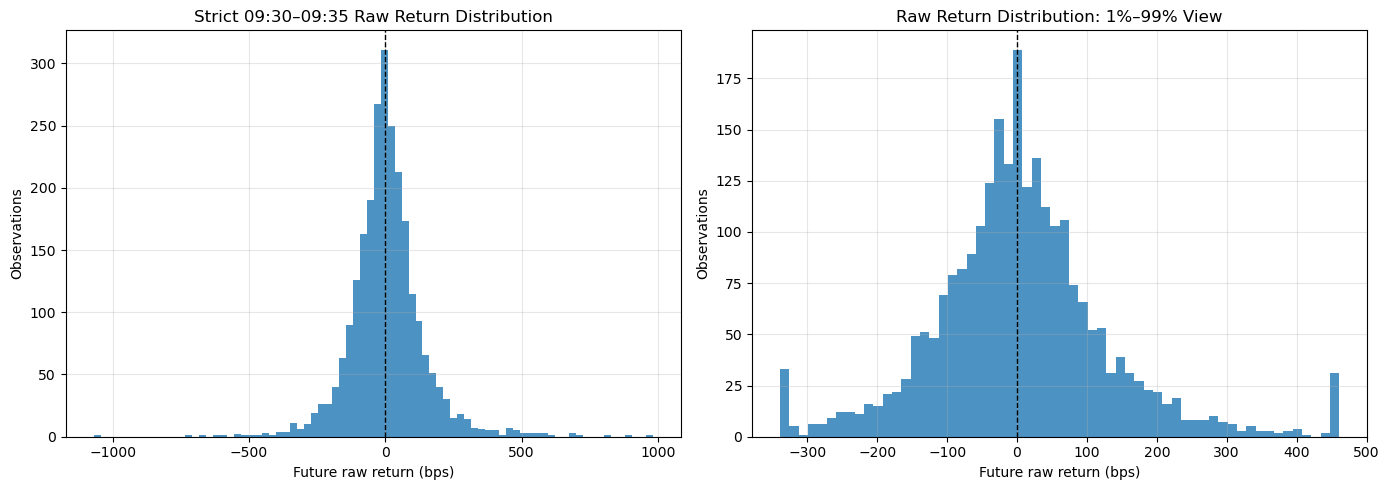

In [44]:
# ============================================================
# 20A. Raw Five-Minute Return Distribution
# ============================================================

raw_target_summary = (
    raw_return_master_df[
        RAW_MODEL_TARGET
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

display(
    raw_target_summary
)

raw_direction_summary = (
    raw_return_master_df[
        RAW_MODEL_DIRECTION_TARGET
    ]
    .value_counts(
        normalize=False
    )
    .sort_index()
    .rename("count")
    .to_frame()
)

raw_direction_summary[
    "ratio"
] = (
    raw_direction_summary[
        "count"
    ]
    / raw_direction_summary[
        "count"
    ].sum()
)

raw_direction_summary.index = (
    raw_direction_summary.index.map({
        0: "Non-positive",
        1: "Positive",
    })
)

display(
    raw_direction_summary
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

# Full distribution
axes[0].hist(
    raw_return_master_df[
        RAW_MODEL_TARGET
    ].dropna() * 10_000,
    bins=80,
    alpha=0.8,
)

axes[0].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[0].set_title(
    "Strict 09:30–09:35 Raw Return Distribution"
)

axes[0].set_xlabel(
    "Future raw return (bps)"
)

axes[0].set_ylabel(
    "Observations"
)

axes[0].grid(
    alpha=0.3
)

# Winsorized view for visualization only
raw_plot_return_bps = (
    raw_return_master_df[
        RAW_MODEL_TARGET
    ]
    .clip(
        lower=raw_return_master_df[
            RAW_MODEL_TARGET
        ].quantile(0.01),

        upper=raw_return_master_df[
            RAW_MODEL_TARGET
        ].quantile(0.99),
    )
    * 10_000
)

axes[1].hist(
    raw_plot_return_bps.dropna(),
    bins=60,
    alpha=0.8,
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Raw Return Distribution: 1%–99% View"
)

axes[1].set_xlabel(
    "Future raw return (bps)"
)

axes[1].set_ylabel(
    "Observations"
)

axes[1].grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


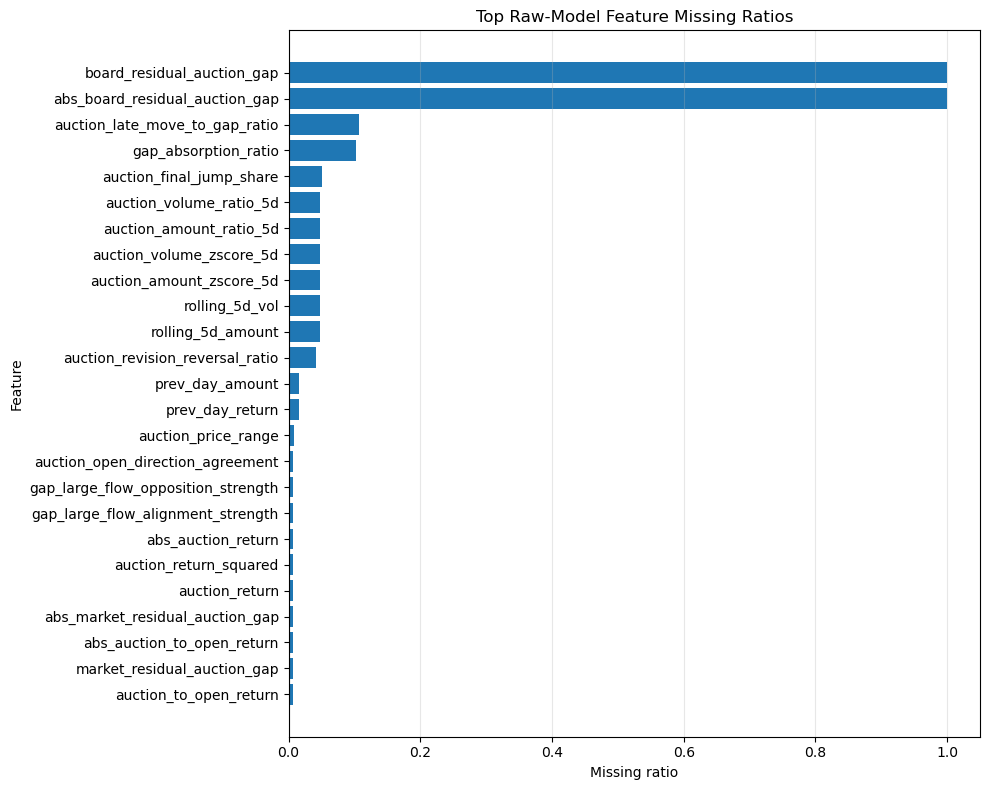

In [45]:
# ============================================================
# 20B. Feature Missing-Rate Visualization
# ============================================================

raw_missing_plot = (
    raw_feature_quality
    .sort_values(
        "missing_ratio",
        ascending=True,
    )
    .tail(25)
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    raw_missing_plot[
        "feature"
    ],
    raw_missing_plot[
        "missing_ratio"
    ],
)

plt.xlabel(
    "Missing ratio"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Raw-Model Feature Missing Ratios"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()
plt.show()


## 21 描述性单因子IC


In [46]:
# ============================================================
# 21. Descriptive Raw-Return Single-Factor IC
#
# This is a research diagnostic only.
# It is not used to select features using future OOS dates.
# ============================================================

raw_single_factor_rows = []

raw_daily_factor_ic_parts = []

for feature in raw_model_features:

    factor_part = (
        raw_return_master_df[
            [
                "date",
                "code",
                feature,
                RAW_MODEL_TARGET,
            ]
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .copy()
    )

    if (
        len(factor_part) < 30
        or factor_part[
            feature
        ].nunique() < 2
    ):
        continue

    pooled_pearson_ic = (
        factor_part[
            feature
        ]
        .corr(
            factor_part[
                RAW_MODEL_TARGET
            ],
            method="pearson",
        )
    )

    pooled_rank_ic = (
        factor_part[
            feature
        ]
        .corr(
            factor_part[
                RAW_MODEL_TARGET
            ],
            method="spearman",
        )
    )

    daily_ic = (
        factor_part
        .groupby("date")
        .apply(
            lambda day: (
                day[feature]
                .corr(
                    day[
                        RAW_MODEL_TARGET
                    ],
                    method="spearman",
                )
                if (
                    day[feature].nunique() > 1
                    and day[
                        RAW_MODEL_TARGET
                    ].nunique() > 1
                )
                else np.nan
            ),
            include_groups=False,
        )
        .dropna()
    )

    raw_single_factor_rows.append({
        "feature":
            feature,

        "pooled_pearson_ic":
            pooled_pearson_ic,

        "pooled_rank_ic":
            pooled_rank_ic,

        "mean_daily_rank_ic":
            daily_ic.mean(),

        "median_daily_rank_ic":
            daily_ic.median(),

        "daily_ic_std":
            daily_ic.std(),

        "positive_daily_ic_ratio":
            (daily_ic > 0).mean(),

        "n_dates":
            len(daily_ic),

        "n_obs":
            len(factor_part),
    })

    if not daily_ic.empty:

        daily_ic_part = (
            daily_ic
            .rename("daily_rank_ic")
            .reset_index()
        )

        daily_ic_part[
            "feature"
        ] = feature

        raw_daily_factor_ic_parts.append(
            daily_ic_part
        )

raw_single_factor_summary = (
    pd.DataFrame(
        raw_single_factor_rows
    )
)

raw_single_factor_summary[
    "abs_mean_daily_rank_ic"
] = (
    raw_single_factor_summary[
        "mean_daily_rank_ic"
    ].abs()
)

raw_single_factor_summary = (
    raw_single_factor_summary
    .sort_values(
        "abs_mean_daily_rank_ic",
        ascending=False,
    )
    .reset_index(drop=True)
)

raw_daily_factor_ic = (
    pd.concat(
        raw_daily_factor_ic_parts,
        ignore_index=True,
    )
    if raw_daily_factor_ic_parts
    else pd.DataFrame()
)

display(
    raw_single_factor_summary.head(30)
)


,feature,pooled_pearson_ic,pooled_rank_ic,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,n_dates,n_obs,abs_mean_daily_rank_ic
0,strict_opening_depth_imbalance_5,0.085425,0.098453,0.079802,0.079835,0.178187,0.682540,63,2504,0.079802
1,strict_opening_microprice_deviation,0.063039,0.076529,0.078205,0.098386,0.195242,0.698413,63,2504,0.078205
2,abs_market_residual_auction_gap,-0.069393,-0.043343,-0.066606,-0.047785,0.198128,0.333333,63,2488,0.066606
3,final_depth_imbalance,-0.034345,-0.055591,-0.063583,-0.056296,0.152529,0.253968,63,2504,0.063583
4,strict_opening_depth_imbalance,0.064911,0.063277,0.062601,0.076458,0.195224,0.698413,63,2504,0.062601
5,auction_late_move_to_gap_ratio,0.030940,0.033201,0.045361,0.083391,0.175905,0.603175,63,2238,0.045361
6,prev_day_return,-0.011580,0.003197,-0.044605,-0.065760,0.193934,0.403226,62,2464,0.044605
7,auction_to_open_return,-0.025397,-0.031675,-0.039549,-0.052128,0.195069,0.380952,63,2488,0.039549
8,abs_auction_return,-0.049328,-0.026256,-0.036928,-0.055748,0.199421,0.428571,63,2488,0.036928
9,auction_return_squared,-0.041386,-0.026256,-0.036928,-0.055748,0.199421,0.428571,63,2488,0.036928


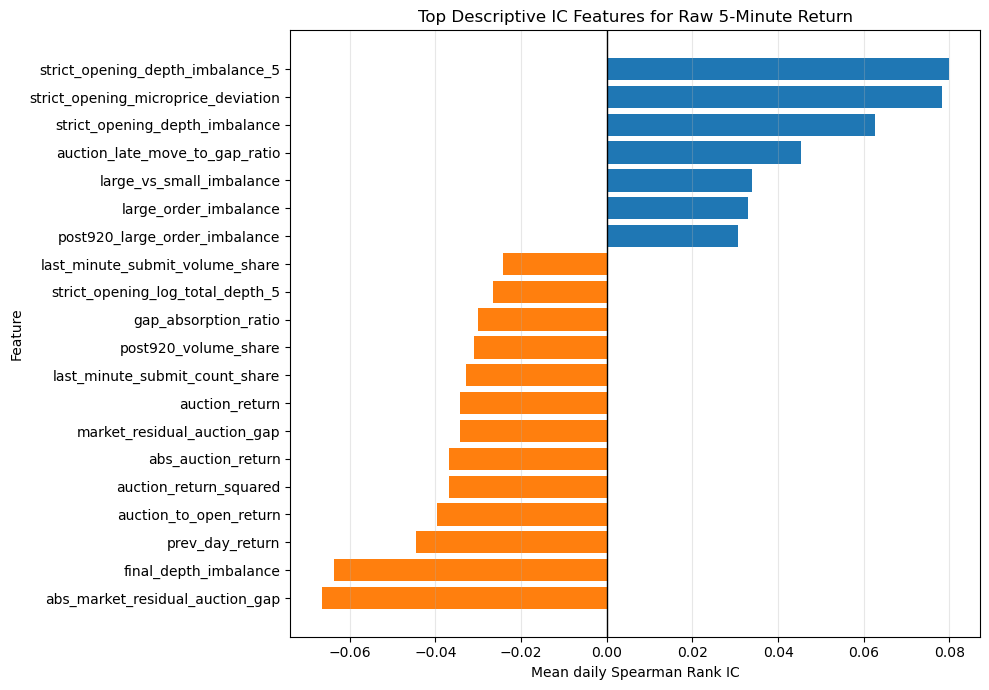

In [47]:
# ============================================================
# 21A. Top Raw-Return Single-Factor IC Plot
# ============================================================

RAW_TOP_IC_FEATURES = 20

raw_ic_plot = (
    raw_single_factor_summary
    .head(
        RAW_TOP_IC_FEATURES
    )
    .sort_values(
        "mean_daily_rank_ic"
    )
)

plt.figure(
    figsize=(10, 7)
)

colors = np.where(
    raw_ic_plot[
        "mean_daily_rank_ic"
    ] >= 0,
    "tab:blue",
    "tab:orange",
)

plt.barh(
    raw_ic_plot[
        "feature"
    ],
    raw_ic_plot[
        "mean_daily_rank_ic"
    ],
    color=colors,
)

plt.axvline(
    0,
    color="black",
    linewidth=1,
)

plt.xlabel(
    "Mean daily Spearman Rank IC"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Descriptive IC Features for Raw 5-Minute Return"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()
plt.show()


# Part VI. 因子树A：严格09:30盘口压力

## A1. 母因子

- `strict_opening_depth_imbalance_5`
- `strict_opening_microprice_deviation`
- `strict_opening_log_total_depth_5`

## A2. 需要逐步回答的问题

1. 一、三、五、十档中哪一层信息最稳定？
2. 数量不平衡和金额不平衡哪一种更适合跨股票比较？
3. 等权深度和距离加权深度谁更有效？
4. 竞价末盘口压力能否持续到严格09:30？
5. 同样的不平衡在厚/薄盘口、宽/窄价差下是否有不同效果？

## A3. 深化顺序

```text
档位宽度 → 权重方式 → 动态变化 → 流动性条件 → 独立增量
```

每次只改变一个定义，并始终与五档母因子在相同样本上比较。


In [48]:
# ============================================================
# Existing factor-family baseline
# ============================================================

factor_family_patterns = {
    "opening_book_pressure": [
        "strict_opening_", "final_depth_", "microprice",
    ],
    "gap_and_reversal": [
        "auction_gap", "auction_return", "residual_auction_gap",
        "gap_absorption", "auction_open_reversal",
    ],
    "large_order_structure": [
        "large_order", "large_flow", "large_vs_small",
        "late_large", "order_amount_hhi", "top5_order",
    ],
}

def assign_factor_family(feature):
    for family, patterns in factor_family_patterns.items():
        if any(pattern in feature for pattern in patterns):
            return family
    return "other"

factor_depth_baseline = raw_single_factor_summary.copy()
factor_depth_baseline["factor_family"] = (
    factor_depth_baseline["feature"].map(assign_factor_family)
)

display(
    factor_depth_baseline[
        factor_depth_baseline["factor_family"] != "other"
    ].sort_values(
        "abs_mean_daily_rank_ic",
        ascending=False,
    )
)


,feature,pooled_pearson_ic,pooled_rank_ic,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,n_dates,n_obs,abs_mean_daily_rank_ic,factor_family
0,strict_opening_depth_imbalance_5,0.085425,0.098453,0.079802,0.079835,0.178187,0.682540,63,2504,0.079802,opening_book_pressure
1,strict_opening_microprice_deviation,0.063039,0.076529,0.078205,0.098386,0.195242,0.698413,63,2504,0.078205,opening_book_pressure
2,abs_market_residual_auction_gap,-0.069393,-0.043343,-0.066606,-0.047785,0.198128,0.333333,63,2488,0.066606,gap_and_reversal
3,final_depth_imbalance,-0.034345,-0.055591,-0.063583,-0.056296,0.152529,0.253968,63,2504,0.063583,opening_book_pressure
4,strict_opening_depth_imbalance,0.064911,0.063277,0.062601,0.076458,0.195224,0.698413,63,2504,0.062601,opening_book_pressure
8,abs_auction_return,-0.049328,-0.026256,-0.036928,-0.055748,0.199421,0.428571,63,2488,0.036928,gap_and_reversal
9,auction_return_squared,-0.041386,-0.026256,-0.036928,-0.055748,0.199421,0.428571,63,2488,0.036928,gap_and_reversal
10,market_residual_auction_gap,-0.051312,-0.016865,-0.034198,-0.048148,0.202223,0.396825,63,2488,0.034198,gap_and_reversal
11,auction_return,-0.068116,-0.041671,-0.034198,-0.048148,0.202223,0.396825,63,2488,0.034198,gap_and_reversal
12,large_vs_small_imbalance,0.037666,0.030349,0.033978,-0.006567,0.179740,0.492063,63,2504,0.033978,large_order_structure


# Part VII. 因子树B：竞价缺口、吸收与反转

## B的研究问题

竞价价格相对昨收、市场和板块出现异常偏离后，09:30→09:35是继续沿缺口方向，
还是发生短期反转？

本树只回答：

1. 原始缺口、市场残差、板块残差哪个更稳定？
2. 高开和低开是否对称？
3. 极端缺口是否具有更强反转？
4. auction price到严格09:30之间已被吸收多少？
5. 09:30盘口支持缺口方向，还是确认反转方向？

不会搜索大量高开阈值。B完成后停止扩展因子树。

## B1. 统一缺口与严格09:30剩余缺口

`auction_return`描述竞价价格相对昨收的缺口；但预测起点是严格09:30，因此还要计算：

```text
remaining_open_gap = strict opening mid / previous close - 1
```

并进一步扣除当天市场中位数和板块中位数。

In [49]:
# ============================================================
# B1. Raw, Residual, and Strict-Opening Remaining Gaps
# ============================================================

required_gap_columns = {
    "code",
    "date",
    "future_return_5m_raw",
    "auction_return",
    "market_residual_auction_gap",
    "board_residual_auction_gap",
    "strict_opening_depth_imbalance_5",
}
missing_gap_columns = (
    required_gap_columns
    - set(factor_research_df.columns)
)
assert not missing_gap_columns, (
    "factor_research_df is missing gap columns: "
    f"{sorted(missing_gap_columns)}"
)

gap_context_columns = [
    column
    for column in [
        "auction_to_open_return",
        "gap_absorption_ratio",
        "auction_open_reversal",
        "strict_opening_mid",
        "pre_close",
        "board",
        "rolling_5d_amount",
        "auction_trade_amount",
    ]
    if column in factor_research_df.columns
]

gap_tree_df = (
    factor_research_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
            "auction_return",
            "market_residual_auction_gap",
            "board_residual_auction_gap",
            "strict_opening_depth_imbalance_5",
        ]
        + gap_context_columns
    ]
    .drop_duplicates(["code", "date"])
    .copy()
)

for column in [
    "auction_return",
    "market_residual_auction_gap",
    "board_residual_auction_gap",
    "strict_opening_depth_imbalance_5",
] + gap_context_columns:
    if column not in {"board"}:
        gap_tree_df[column] = pd.to_numeric(
            gap_tree_df[column],
            errors="coerce",
        )

# Exact strict-opening remaining gap when prices are available.
if {
    "strict_opening_mid",
    "pre_close",
}.issubset(gap_tree_df.columns):
    gap_tree_df["remaining_open_gap"] = (
        gap_tree_df["strict_opening_mid"]
        / gap_tree_df["pre_close"].replace(0, np.nan)
        - 1
    )
elif "auction_to_open_return" in gap_tree_df.columns:
    gap_tree_df["remaining_open_gap"] = (
        (1 + gap_tree_df["auction_return"])
        * (1 + gap_tree_df["auction_to_open_return"])
        - 1
    )
else:
    gap_tree_df["remaining_open_gap"] = np.nan

gap_tree_df["market_median_remaining_open_gap"] = (
    gap_tree_df.groupby("date")[
        "remaining_open_gap"
    ].transform("median")
)
gap_tree_df["market_residual_remaining_open_gap"] = (
    gap_tree_df["remaining_open_gap"]
    - gap_tree_df["market_median_remaining_open_gap"]
)

if "board" in gap_tree_df.columns:
    gap_tree_df["board_median_remaining_open_gap"] = (
        gap_tree_df.groupby(["date", "board"])[
            "remaining_open_gap"
        ].transform("median")
    )
    gap_tree_df["board_residual_remaining_open_gap"] = (
        gap_tree_df["remaining_open_gap"]
        - gap_tree_df["board_median_remaining_open_gap"]
    )
else:
    gap_tree_df["board_residual_remaining_open_gap"] = np.nan

# Orient all gap factors as reversal signals: larger means more bullish.
GAP_BASE_COLUMNS = [
    "auction_return",
    "market_residual_auction_gap",
    "board_residual_auction_gap",
    "remaining_open_gap",
    "market_residual_remaining_open_gap",
    "board_residual_remaining_open_gap",
]

GAP_REVERSAL_FEATURES = []
for gap_column in GAP_BASE_COLUMNS:
    if gap_column in gap_tree_df.columns:
        reversal_name = f"reversal_{gap_column}"
        gap_tree_df[reversal_name] = -gap_tree_df[gap_column]
        GAP_REVERSAL_FEATURES.append(reversal_name)

print("Gap-tree observations:", len(gap_tree_df))
print("Gap-tree dates:", gap_tree_df["date"].nunique())
display(
    gap_tree_df[
        ["code", "date", "future_return_5m_raw"]
        + GAP_BASE_COLUMNS
    ].head()
)

Gap-tree observations: 2504
Gap-tree dates: 63


,code,date,future_return_5m_raw,auction_return,market_residual_auction_gap,board_residual_auction_gap,remaining_open_gap,market_residual_remaining_open_gap,board_residual_remaining_open_gap
0,000713.SZ,2026-01-05,-0.001507,0.001511,0.000223,NaN,0.002266,-0.000914,NaN
1,000713.SZ,2026-01-06,0.004481,0.002994,0.001694,NaN,0.002246,0.001035,NaN
2,000713.SZ,2026-01-07,-0.001483,-0.002963,-0.001084,NaN,-0.000741,0.000668,NaN
3,000713.SZ,2026-01-08,0.000000,0.000000,0.002613,NaN,0.000742,0.002456,NaN
4,000713.SZ,2026-01-09,0.001485,-0.004438,-0.003795,NaN,-0.003698,-0.002107,NaN


## B2. 基准缺口选择

所有定义先转成“反转方向”：高开对应负信号、低开对应正信号。统一评价Raw、
Market residual、Board residual，以及严格09:30仍然剩余的缺口。

In [50]:
# ============================================================
# Temporary B helper compatibility patch
# Run once immediately before B2
# ============================================================

def _rank_corr(x, y, minimum=5):
    pair = pd.concat(
        [
            pd.to_numeric(x, errors="coerce"),
            pd.to_numeric(y, errors="coerce"),
        ],
        axis=1,
    ).replace([np.inf, -np.inf], np.nan).dropna()

    if (
        len(pair) < minimum
        or pair.iloc[:, 0].nunique() < 2
        or pair.iloc[:, 1].nunique() < 2
    ):
        return np.nan

    # Spearman correlation without requiring scipy
    ranked = pair.rank(method="average")
    return ranked.iloc[:, 0].corr(ranked.iloc[:, 1])


def _daily_quintile_spread(frame):
    required_columns = {
        "factor_value",
        "future_return_5m_raw",
    }
    missing_columns = required_columns - set(frame.columns)

    if missing_columns:
        raise KeyError(
            "_daily_quintile_spread is missing columns: "
            f"{sorted(missing_columns)}"
        )

    pair = (
        frame[
            [
                "factor_value",
                "future_return_5m_raw",
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if (
        len(pair) < 10
        or pair["factor_value"].nunique() < 5
    ):
        return np.nan

    percentile_rank = (
        pair["factor_value"]
        .rank(method="average", pct=True)
    )

    low_group = pair.loc[
        percentile_rank <= 0.20,
        "future_return_5m_raw",
    ]
    high_group = pair.loc[
        percentile_rank > 0.80,
        "future_return_5m_raw",
    ]

    if len(low_group) == 0 or len(high_group) == 0:
        return np.nan

    return high_group.mean() - low_group.mean()


def _rank_corr_minimum(x, y, minimum=5):
    """
    Spearman rank correlation with a configurable minimum sample size.
    """
    pair = pd.concat(
        [
            pd.to_numeric(x, errors="coerce"),
            pd.to_numeric(y, errors="coerce"),
        ],
        axis=1,
    ).replace([np.inf, -np.inf], np.nan).dropna()

    if (
        len(pair) < minimum
        or pair.iloc[:, 0].nunique() < 2
        or pair.iloc[:, 1].nunique() < 2
    ):
        return np.nan

    ranked = pair.rank(method="average")
    return ranked.iloc[:, 0].corr(ranked.iloc[:, 1])



In [51]:
# ============================================================
# B2. Unified Reversal-Signal Evaluation
# ============================================================

gap_reversal_long = (
    gap_tree_df[
        ["code", "date", "future_return_5m_raw"]
        + GAP_REVERSAL_FEATURES
    ]
    .melt(
        id_vars=["code", "date", "future_return_5m_raw"],
        value_vars=GAP_REVERSAL_FEATURES,
        var_name="feature",
        value_name="factor_value",
    )
)

gap_daily_metrics = (
    gap_reversal_long.groupby(
        ["feature", "date"],
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "daily_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(frame),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

gap_reversal_summary = (
    gap_reversal_long.groupby(
        "feature",
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["factor_value"].notna().sum(),
                "coverage_ratio": frame["factor_value"].notna().mean(),
                "pooled_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .merge(
        gap_daily_metrics.groupby(
            "feature",
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            daily_ic_std=("daily_rank_ic", "std"),
            positive_daily_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
            mean_q5_q1_bps=(
                "daily_q5_q1",
                lambda x: x.mean() * 10_000,
            ),
            positive_q5_q1_day_ratio=(
                "daily_q5_q1",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index(),
        on="feature",
        how="left",
        validate="one_to_one",
    )
)
gap_reversal_summary["icir"] = (
    gap_reversal_summary["mean_daily_rank_ic"]
    / gap_reversal_summary["daily_ic_std"]
)
gap_reversal_summary = (
    gap_reversal_summary.sort_values(
        "mean_daily_rank_ic",
        ascending=False,
    )
    .reset_index(drop=True)
)
display(gap_reversal_summary)

,feature,n_obs,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,reversal_remaining_open_gap,2504.0,1.00000,0.061357,63,0.065658,0.081238,0.217345,0.682540,18.260127,0.571429,0.302093
1,reversal_market_residual_remaining_open_gap,2504.0,1.00000,0.038871,63,0.065658,0.081238,0.217345,0.682540,18.260127,0.571429,0.302093
2,reversal_auction_return,2488.0,0.99361,0.041671,63,0.034198,0.048148,0.202223,0.603175,10.035007,0.539683,0.169110
3,reversal_market_residual_auction_gap,2488.0,0.99361,0.016865,63,0.034198,0.048148,0.202223,0.603175,10.035007,0.539683,0.169110
4,reversal_board_residual_auction_gap,0.0,0.00000,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,reversal_board_residual_remaining_open_gap,0.0,0.00000,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## B3. 高开与低开不对称

在市场残差缺口为正和为负的股票中分别计算反转IC、方向调整收益和准确率。
不能用零填充后直接比较，因为零值会改变横截面排序。

In [52]:
# ============================================================
# B3. Positive vs Negative Residual-Gap Asymmetry
# ============================================================

ASYMMETRY_GAP = "market_residual_auction_gap"
asymmetry_rows = []

for gap_side, side_mask in [
    ("Positive residual gap", gap_tree_df[ASYMMETRY_GAP] > 0),
    ("Negative residual gap", gap_tree_df[ASYMMETRY_GAP] < 0),
]:
    side_frame = gap_tree_df.loc[side_mask].copy()
    side_frame["reversal_signal"] = -side_frame[ASYMMETRY_GAP]
    side_frame["reversal_direction"] = np.sign(
        side_frame["reversal_signal"]
    )
    side_frame["reversal_signed_return_bps"] = (
        side_frame["reversal_direction"]
        * side_frame["future_return_5m_raw"]
        * 10_000
    )

    daily_ic = (
        side_frame.groupby("date", observed=True)
        .apply(
            lambda frame: _rank_corr_minimum(
                frame["reversal_signal"],
                frame["future_return_5m_raw"],
                8,
            ),
            include_groups=False,
        )
        .dropna()
    )

    asymmetry_rows.append(
        {
            "gap_side": gap_side,
            "n_obs": len(side_frame),
            "n_dates": side_frame["date"].nunique(),
            "n_ic_dates": len(daily_ic),
            "mean_daily_rank_ic": daily_ic.mean(),
            "median_daily_rank_ic": daily_ic.median(),
            "positive_ic_ratio": (daily_ic > 0).mean(),
            "mean_reversal_signed_return_bps": side_frame[
                "reversal_signed_return_bps"
            ].mean(),
            "reversal_direction_accuracy": (
                side_frame["reversal_signed_return_bps"] > 0
            ).mean(),
        }
    )

gap_asymmetry_summary = pd.DataFrame(asymmetry_rows)
display(gap_asymmetry_summary)

,gap_side,n_obs,n_dates,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio,mean_reversal_signed_return_bps,reversal_direction_accuracy
0,Positive residual gap,1211,63,63,0.103030,0.150877,0.666667,-1.966994,0.491329
1,Negative residual gap,1213,63,63,-0.028689,-0.035981,0.428571,7.644135,0.488046


## B4. 极端缺口的非线性

使用每日市场残差缺口绝对值分五组，分别报告未来方向调整收益和绝对收益。
若极端组反转更强，Q5应具有更高的反转收益；若只提高绝对收益，则它是机会强度，
不是更可靠的反转方向。

In [53]:
# ============================================================
# B4. Residual-Gap Magnitude Quintiles
# ============================================================

gap_extreme_df = gap_tree_df[
    [
        "code",
        "date",
        "future_return_5m_raw",
        ASYMMETRY_GAP,
    ]
].dropna().copy()

gap_extreme_df["abs_residual_gap"] = (
    gap_extreme_df[ASYMMETRY_GAP].abs()
)
gap_extreme_df["gap_magnitude_percentile"] = (
    gap_extreme_df.groupby("date")[
        "abs_residual_gap"
    ].rank(method="average", pct=True)
)
gap_extreme_df["gap_magnitude_quintile"] = np.ceil(
    gap_extreme_df["gap_magnitude_percentile"] * 5
).clip(1, 5).astype(int)
gap_extreme_df["reversal_direction"] = -np.sign(
    gap_extreme_df[ASYMMETRY_GAP]
)
gap_extreme_df["reversal_signed_return_bps"] = (
    gap_extreme_df["reversal_direction"]
    * gap_extreme_df["future_return_5m_raw"]
    * 10_000
)
gap_extreme_df["abs_future_return_bps"] = (
    gap_extreme_df["future_return_5m_raw"].abs()
    * 10_000
)

gap_magnitude_quintile_summary = (
    gap_extreme_df.groupby(
        "gap_magnitude_quintile",
        observed=True,
    )
    .agg(
        n_obs=("code", "size"),
        n_dates=("date", "nunique"),
        mean_abs_residual_gap=(
            "abs_residual_gap",
            "mean",
        ),
        mean_reversal_signed_return_bps=(
            "reversal_signed_return_bps",
            "mean",
        ),
        median_reversal_signed_return_bps=(
            "reversal_signed_return_bps",
            "median",
        ),
        reversal_direction_accuracy=(
            "reversal_signed_return_bps",
            lambda x: (x > 0).mean(),
        ),
        mean_abs_future_return_bps=(
            "abs_future_return_bps",
            "mean",
        ),
    )
    .reset_index()
)
display(gap_magnitude_quintile_summary)

,gap_magnitude_quintile,n_obs,n_dates,mean_abs_residual_gap,mean_reversal_signed_return_bps,median_reversal_signed_return_bps,reversal_direction_accuracy,mean_abs_future_return_bps
0,1,486,63,0.000578,-0.172615,0.000000,0.378601,72.060929
1,2,498,63,0.002150,-5.093909,-0.000000,0.473896,75.201909
2,3,499,63,0.003992,11.343630,10.520779,0.527054,79.756810
3,4,501,63,0.007275,-4.168676,0.000000,0.493014,92.457350
4,5,504,63,0.019839,11.783728,3.907583,0.509921,150.052915


## B5. Opening盘口确认反转还是支持延续

定义：

```text
reversal confirmed:
sign(Opening imbalance) == sign(-residual gap)

continuation supported:
sign(Opening imbalance) == sign(residual gap)
```

冲突状态只用于机制分析，不立即生成交易过滤规则。

In [54]:
# ============================================================
# B5. Residual Gap × Strict Opening-Book Mechanism
# ============================================================

gap_tree_df["gap_reversal_direction"] = -np.sign(
    gap_tree_df[ASYMMETRY_GAP]
)
gap_tree_df["opening_pressure_direction"] = np.sign(
    gap_tree_df["strict_opening_depth_imbalance_5"]
)
gap_tree_df["gap_opening_state"] = np.select(
    [
        (
            gap_tree_df["opening_pressure_direction"]
            == gap_tree_df["gap_reversal_direction"]
        ),
        (
            gap_tree_df["opening_pressure_direction"]
            == -gap_tree_df["gap_reversal_direction"]
        ),
    ],
    [
        "Opening confirms reversal",
        "Opening supports continuation",
    ],
    default="Zero / unavailable",
)

gap_tree_df["gap_reversal_signed_return_bps"] = (
    gap_tree_df["gap_reversal_direction"]
    * gap_tree_df["future_return_5m_raw"]
    * 10_000
)
gap_tree_df["opening_signed_return_bps"] = (
    gap_tree_df["opening_pressure_direction"]
    * gap_tree_df["future_return_5m_raw"]
    * 10_000
)

gap_opening_state_summary = (
    gap_tree_df.groupby(
        "gap_opening_state",
        observed=True,
    )
    .agg(
        n_obs=("code", "size"),
        n_dates=("date", "nunique"),
        mean_gap_reversal_return_bps=(
            "gap_reversal_signed_return_bps",
            "mean",
        ),
        gap_reversal_accuracy=(
            "gap_reversal_signed_return_bps",
            lambda x: (x > 0).mean(),
        ),
        mean_opening_return_bps=(
            "opening_signed_return_bps",
            "mean",
        ),
        opening_accuracy=(
            "opening_signed_return_bps",
            lambda x: (x > 0).mean(),
        ),
    )
    .reset_index()
)
display(gap_opening_state_summary)

# Same-scale rank combination when Opening confirms reversal.
gap_rank = (
    gap_tree_df.groupby("date")[ASYMMETRY_GAP]
    .rank(method="average", pct=True)
)
opening_rank = (
    gap_tree_df.groupby("date")[
        "strict_opening_depth_imbalance_5"
    ].rank(method="average", pct=True)
)
gap_reversal_rank = 1.0 - gap_rank

gap_tree_df["gap_opening_reversal_confirmed_signal"] = np.where(
    gap_tree_df["gap_opening_state"].eq(
        "Opening confirms reversal"
    ),
    (gap_reversal_rank + opening_rank) / 2,
    opening_rank,
)

,gap_opening_state,n_obs,n_dates,mean_gap_reversal_return_bps,gap_reversal_accuracy,mean_opening_return_bps,opening_accuracy
0,Opening confirms reversal,1313,63,13.682137,0.532369,13.682137,0.532369
1,Opening supports continuation,1109,63,-10.021534,0.439134,10.021534,0.540126
2,Zero / unavailable,82,25,0.599113,0.012195,-3.820963,0.426829


## B6. 吸收与严格Opening剩余缺口

比较竞价缺口和严格09:30剩余缺口。如果剩余缺口反转更强，说明真正重要的是09:30
尚未被吸收的偏离；如果竞价缺口更强，则竞价定价过程本身包含信息。

In [55]:
# ============================================================
# B6. Auction-to-Open Absorption and Confirmed Combination
# ============================================================

gap_mechanism_features = [
    "reversal_market_residual_auction_gap",
    "reversal_market_residual_remaining_open_gap",
    "gap_opening_reversal_confirmed_signal",
]
gap_mechanism_features = [
    column
    for column in gap_mechanism_features
    if column in gap_tree_df.columns
]

gap_mechanism_long = (
    gap_tree_df[
        ["code", "date", "future_return_5m_raw"]
        + gap_mechanism_features
    ]
    .melt(
        id_vars=["code", "date", "future_return_5m_raw"],
        value_vars=gap_mechanism_features,
        var_name="feature",
        value_name="factor_value",
    )
)

gap_mechanism_daily = (
    gap_mechanism_long.groupby(
        ["feature", "date"],
        observed=True,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "daily_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(frame),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

gap_mechanism_summary = (
    gap_mechanism_daily.groupby(
        "feature",
        observed=True,
    )
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
        positive_q5_q1_day_ratio=(
            "daily_q5_q1",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)
gap_mechanism_summary["icir"] = (
    gap_mechanism_summary["mean_daily_rank_ic"]
    / gap_mechanism_summary["daily_ic_std"]
)
display(gap_mechanism_summary)

,feature,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,gap_opening_reversal_confirmed_signal,63,0.080728,0.103861,0.187826,0.666667,27.275151,0.603175,0.429801
1,reversal_market_residual_auction_gap,63,0.034198,0.048148,0.202223,0.603175,10.035007,0.539683,0.169110
2,reversal_market_residual_remaining_open_gap,63,0.065658,0.081238,0.217345,0.682540,18.260127,0.571429,0.302093


## B7. 日期、板块与流动性稳健性

只对市场残差反转和严格Opening剩余缺口反转做前后日期、板块和历史流动性分层。

In [56]:
# ============================================================
# B7. Gap-Reversal Robustness
# ============================================================

GAP_ROBUST_FEATURES = [
    feature
    for feature in [
        "reversal_market_residual_auction_gap",
        "reversal_market_residual_remaining_open_gap",
    ]
    if feature in gap_tree_df.columns
]

gap_robust_long = (
    gap_tree_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + GAP_ROBUST_FEATURES
        + (
            ["board"]
            if "board" in gap_tree_df.columns
            else []
        )
        + (
            ["rolling_5d_amount"]
            if "rolling_5d_amount" in gap_tree_df.columns
            else []
        )
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + (
            ["board"]
            if "board" in gap_tree_df.columns
            else []
        )
        + (
            ["rolling_5d_amount"]
            if "rolling_5d_amount" in gap_tree_df.columns
            else []
        ),
        value_vars=GAP_ROBUST_FEATURES,
        var_name="feature",
        value_name="factor_value",
    )
)

gap_dates = np.array(sorted(gap_robust_long["date"].unique()))
gap_robust_long["subperiod"] = np.where(
    gap_robust_long["date"].isin(set(gap_dates[:-21])),
    "First period",
    "Last 21 dates",
)

if "board" not in gap_robust_long.columns:
    gap_robust_long["board"] = np.select(
        [
            gap_robust_long["code"].str.startswith(
                ("300", "301")
            ),
            gap_robust_long["code"].str.startswith(
                ("688", "689")
            ),
        ],
        ["ChiNext", "STAR"],
        default="Main board",
    )


def _gap_grouped_summary(group_column):
    daily = (
        gap_robust_long.groupby(
            ["feature", group_column, "date"],
            observed=True,
        )
        .apply(
            lambda frame: _rank_corr_minimum(
                frame["factor_value"],
                frame["future_return_5m_raw"],
                5,
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )
    return (
        daily.groupby(
            ["feature", group_column],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )


gap_subperiod_robustness = _gap_grouped_summary("subperiod")
gap_board_robustness = _gap_grouped_summary("board")
display(gap_subperiod_robustness)
display(gap_board_robustness)

if "rolling_5d_amount" in gap_robust_long.columns:
    gap_liquidity_rank = (
        gap_robust_long.groupby(
            ["feature", "date"],
            observed=True,
        )["rolling_5d_amount"]
        .rank(method="average", pct=True)
    )
    gap_robust_long["liquidity_group"] = pd.cut(
        gap_liquidity_rank,
        bins=[0, 1 / 3, 2 / 3, 1],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )
    gap_liquidity_robustness = _gap_grouped_summary(
        "liquidity_group"
    )
    display(gap_liquidity_robustness)

,feature,subperiod,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,reversal_market_residual_auction_gap,First period,42,0.038037,0.066132,0.619048
1,reversal_market_residual_auction_gap,Last 21 dates,21,0.026520,0.015963,0.571429
2,reversal_market_residual_remaining_open_gap,First period,42,0.071196,0.080582,0.690476
3,reversal_market_residual_remaining_open_gap,Last 21 dates,21,0.054583,0.082739,0.666667


,feature,board,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,reversal_market_residual_auction_gap,ChiNext,63,0.053474,0.166667,0.555556
1,reversal_market_residual_auction_gap,Main board,63,0.041074,0.081223,0.603175
2,reversal_market_residual_auction_gap,STAR,63,0.060383,0.023810,0.507937
3,reversal_market_residual_remaining_open_gap,ChiNext,63,0.054029,0.047619,0.523810
4,reversal_market_residual_remaining_open_gap,Main board,63,0.091840,0.139130,0.698413
5,reversal_market_residual_remaining_open_gap,STAR,63,0.089191,0.047619,0.523810


,feature,liquidity_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,reversal_market_residual_auction_gap,Low,60,0.089303,0.085165,0.616667
1,reversal_market_residual_auction_gap,Medium,60,0.046666,0.021479,0.533333
2,reversal_market_residual_auction_gap,High,60,-0.043339,-0.050022,0.466667
3,reversal_market_residual_remaining_open_gap,Low,60,0.160303,0.178571,0.700000
4,reversal_market_residual_remaining_open_gap,Medium,60,0.099435,0.098901,0.583333
5,reversal_market_residual_remaining_open_gap,High,60,-0.040288,-0.035714,0.450000


## B8. 因子树B保留规则

最多保留一个Gap方向因子。优先顺序：

1. 严格09:30剩余缺口的市场/板块残差反转；
2. 竞价缺口的市场/板块残差反转；
3. Opening确认组合仅在配对增量稳定时保留。

要求mean/median daily IC同向、前后日期及板块不过度反转，并且经济定义在09:30时
完全可见。B结束后不再新增因子树。

# Part VIII. 因子树C：大单与参与者结构

## C1. 母因子

- `large_order_imbalance`
- `post920_large_order_imbalance`
- `large_order_amount_share`
- `large_vs_small_imbalance`
- `late_large_vs_full_large_shift`
- `large_flow_concentration`

## C2. 解释边界

Level-2委托数据不能确认账户身份。本研究只构造
`institution-like committed order-flow proxy`，不直接声称识别机构。

## C3. 下一步：扩展 Notebook 04 的大单因子工厂

当前 `large_order_imbalance` 使用固定 50 万元阈值，只能回答一个非常
有限的问题。下一次特征导出至少应加入：

| 维度 | 候选定义 |
|---|---|
| 固定金额 | 10万、30万、50万、100万、200万 |
| 相对规模 | 股票当日 P90、P95、P99；相对历史典型订单规模 |
| 时间窗口 | 09:15–09:20、09:20–09:24、09:24–09:25、最后60秒、最后30秒 |
| 方向 | 买入、卖出、净不平衡 |
| 结构 | 金额占比、笔数占比、集中度、Top-N占比 |
| 动态 | 持续、增强、衰减、买转卖、卖转买 |

阈值比较必须使用统一指标，并报告多重尝试数量。不能只展示全样本中
表现最好的阈值。

## C4. 深化顺序

```text
固定金额级别
→ 相对股票自身的订单规模
→ 09:20后承诺性
→ 最后60/30秒持续性
→ 买转卖/卖转买
→ 与小单和09:30盘口的确认关系
```


## C1. 读取Notebook 04的大单实验长表

先运行Notebook 04，生成：

```text
04_large_order_factor_grid_long.csv
```

本单元只检查跨notebook接口并与严格收益率标签合并，不在此处修改阈值。


In [57]:
# ============================================================
# C1. Load Notebook 04 Large-Order Factor Grid
# ============================================================

from pathlib import Path

LARGE_ORDER_GRID_CANDIDATES = [
    Path("04_large_order_factor_grid_long.csv"),
    Path("../notebooks/04_large_order_factor_grid_long.csv"),
    Path(
        r"C:\Users\work\OneDrive\Documents"
        r"\level2-research\notebooks"
        r"\04_large_order_factor_grid_long.csv"
    ),
]

LARGE_ORDER_GRID_PATH = next(
    (
        path
        for path in LARGE_ORDER_GRID_CANDIDATES
        if path.exists()
    ),
    None,
)

if LARGE_ORDER_GRID_PATH is None:
    raise FileNotFoundError(
        "Run Notebook 04 through Part VIII first. "
        "Missing 04_large_order_factor_grid_long.csv."
    )

large_order_factor_grid_long = pd.read_csv(
    LARGE_ORDER_GRID_PATH
)

large_order_factor_grid_long["code"] = (
    large_order_factor_grid_long["code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

large_order_factor_grid_long["date"] = (
    pd.to_datetime(
        large_order_factor_grid_long["date"],
        errors="coerce",
    )
    .dt.normalize()
)

required_large_order_grid_columns = {
    "code",
    "date",
    "threshold_type",
    "threshold_label",
    "threshold_value",
    "auction_window",
    "coverage_flag",
    "n_large_orders",
    "large_amount_share",
    "large_count_share",
    "large_order_imbalance",
    "large_order_hhi",
}

missing_large_order_grid_columns = sorted(
    required_large_order_grid_columns.difference(
        large_order_factor_grid_long.columns
    )
)

if missing_large_order_grid_columns:
    raise KeyError(
        "Notebook 04 large-order grid is missing columns: "
        f"{missing_large_order_grid_columns}"
    )

large_order_grid_key = [
    "code",
    "date",
    "threshold_type",
    "threshold_label",
    "auction_window",
]

large_order_grid_duplicate_n = (
    large_order_factor_grid_long
    .duplicated(large_order_grid_key)
    .sum()
)

assert large_order_grid_duplicate_n == 0

large_order_label_table = (
    factor_research_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
            "future_direction_5m_raw",
        ]
    ]
    .drop_duplicates(["code", "date"])
)

large_order_factor_research_long = (
    large_order_factor_grid_long
    .merge(
        large_order_label_table,
        on=["code", "date"],
        how="inner",
        validate="many_to_one",
    )
)

large_order_grid_interface_summary = pd.DataFrame({
    "metric": [
        "grid_rows",
        "merged_research_rows",
        "grid_dates",
        "merged_dates",
        "grid_stocks",
        "merged_stocks",
        "duplicate_factor_keys",
        "target_missing_ratio",
    ],
    "value": [
        len(large_order_factor_grid_long),
        len(large_order_factor_research_long),
        large_order_factor_grid_long["date"].nunique(),
        large_order_factor_research_long["date"].nunique(),
        large_order_factor_grid_long["code"].nunique(),
        large_order_factor_research_long["code"].nunique(),
        large_order_grid_duplicate_n,
        large_order_factor_research_long[
            "future_return_5m_raw"
        ].isna().mean(),
    ],
})

assert (
    large_order_factor_research_long[
        "future_return_5m_raw"
    ].notna().all()
)

print(
    "Loaded large-order grid:",
    LARGE_ORDER_GRID_PATH.resolve(),
)

display(large_order_grid_interface_summary)
display(large_order_factor_research_long.head(20))


Loaded large-order grid: C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_large_order_factor_grid_long.csv


,metric,value
0,grid_rows,25200.0
1,merged_research_rows,25040.0
2,grid_dates,63.0
3,merged_dates,63.0
4,grid_stocks,40.0
5,merged_stocks,40.0
6,duplicate_factor_keys,0.0
7,target_missing_ratio,0.0


,code,date,total_order_count,total_order_amount,n_large_orders,large_total_amount,large_buy_amount,large_sell_amount,largest_large_order_amount,coverage_flag,large_order_imbalance,large_amount_share,large_count_share,largest_order_share,large_order_hhi,threshold_type,threshold_label,threshold_value,auction_window,window_start_seconds,window_end_seconds,future_return_5m_raw,future_direction_5m_raw
0,000713.SZ,2026-01-05,660,20274353.9,32,11705468.9,264912.0,11440556.9,2573480.0,1,-0.954737,0.577353,0.048485,0.126933,0.027966,fixed_amount,100k,100000.0,full,33300,33900,-0.001507,0
1,000713.SZ,2026-01-05,88,3203454.0,5,1542536.0,132600.0,1409936.0,728000.0,1,-0.828075,0.481523,0.056818,0.227255,0.073298,fixed_amount,100k,100000.0,post920,33600,33900,-0.001507,0
2,000713.SZ,2026-01-05,660,20274353.9,10,7994606.9,0.0,7994606.9,2573480.0,1,-1.000000,0.394321,0.015152,0.126933,0.026325,fixed_amount,300k,300000.0,full,33300,33900,-0.001507,0
3,000713.SZ,2026-01-05,88,3203454.0,2,1137136.0,0.0,1137136.0,728000.0,1,-1.000000,0.354972,0.022727,0.227255,0.067956,fixed_amount,300k,300000.0,post920,33600,33900,-0.001507,0
4,000713.SZ,2026-01-05,660,20274353.9,5,6037246.9,0.0,6037246.9,2573480.0,1,-1.000000,0.297778,0.007576,0.126933,0.024445,fixed_amount,500k,500000.0,full,33300,33900,-0.001507,0
5,000713.SZ,2026-01-05,88,3203454.0,1,728000.0,0.0,728000.0,728000.0,1,-1.000000,0.227255,0.011364,0.227255,0.051645,fixed_amount,500k,500000.0,post920,33600,33900,-0.001507,0
6,000713.SZ,2026-01-05,660,20274353.9,2,3978520.0,0.0,3978520.0,2573480.0,1,-1.000000,0.196234,0.003030,0.126933,0.020915,fixed_amount,1m,1000000.0,full,33300,33900,-0.001507,0
7,000713.SZ,2026-01-05,88,3203454.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,1m,1000000.0,post920,33600,33900,-0.001507,0
8,000713.SZ,2026-01-05,660,20274353.9,1,2573480.0,0.0,2573480.0,2573480.0,1,-1.000000,0.126933,0.001515,0.126933,0.016112,fixed_amount,2m,2000000.0,full,33300,33900,-0.001507,0
9,000713.SZ,2026-01-05,88,3203454.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,2m,2000000.0,post920,33600,33900,-0.001507,0


## C2. 构造统一的大单裂变因子

第一轮固定比较：

```text
5个金额阈值 × 2个竞价窗口 × 5种大单定义
```

其中：

- `imbalance_zero_filled`：没有达到阈值的大单时记为0，覆盖全部股票日，是主比较口径；
- `imbalance_conditional`：只在确实出现该级别大单时评价，用于回答“大单出现后方向是否有效”；
- `large_amount_share`：大单金额占该窗口全部委托金额的比例；
- `large_count_share`：大单笔数占比；
- `large_order_hhi`：大单金额集中度。

`conditional` 与全样本指标的样本不同，因此不能只比较其IC大小，必须同时报告覆盖率。

In [58]:
# ============================================================
# C2. Build Comparable Large-Order Factor Variants
# ============================================================

required_large_order_columns = {
    "code",
    "date",
    "threshold_label",
    "threshold_value",
    "auction_window",
    "coverage_flag",
    "large_order_imbalance",
    "large_amount_share",
    "large_count_share",
    "large_order_hhi",
    "future_return_5m_raw",
}

missing_large_order_columns = (
    required_large_order_columns
    - set(large_order_factor_research_long.columns)
)

assert not missing_large_order_columns, (
    "large_order_factor_research_long is missing required columns: "
    f"{sorted(missing_large_order_columns)}"
)

large_order_eval_df = large_order_factor_research_long.copy()
large_order_eval_df["date"] = pd.to_datetime(
    large_order_eval_df["date"],
    errors="coerce",
).dt.normalize()

large_order_eval_df["imbalance_zero_filled"] = (
    large_order_eval_df["large_order_imbalance"]
    .fillna(0.0)
)

# Keep NaN when no qualifying order exists.
large_order_eval_df["imbalance_conditional"] = (
    large_order_eval_df["large_order_imbalance"]
    .where(large_order_eval_df["coverage_flag"].eq(1))
)

LARGE_ORDER_FACTOR_COLUMNS = [
    "imbalance_zero_filled",
    "imbalance_conditional",
    "large_amount_share",
    "large_count_share",
    "large_order_hhi",
]

large_order_factor_long = (
    large_order_eval_df[
        [
            "code",
            "date",
            "threshold_label",
            "threshold_value",
            "auction_window",
            "coverage_flag",
            "future_return_5m_raw",
        ]
        + LARGE_ORDER_FACTOR_COLUMNS
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "threshold_label",
            "threshold_value",
            "auction_window",
            "coverage_flag",
            "future_return_5m_raw",
        ],
        value_vars=LARGE_ORDER_FACTOR_COLUMNS,
        var_name="factor_definition",
        value_name="factor_value",
    )
)

assert large_order_factor_long["future_return_5m_raw"].notna().all()

display(
    large_order_factor_long.groupby(
        [
            "auction_window",
            "threshold_label",
            "factor_definition",
        ],
        observed=True,
    )
    .agg(
        n_rows=("code", "size"),
        n_available=("factor_value", "count"),
        coverage_ratio=("factor_value", lambda x: x.notna().mean()),
        n_unique=("factor_value", "nunique"),
    )
    .reset_index()
)

,auction_window,threshold_label,factor_definition,n_rows,n_available,coverage_ratio,n_unique
0,full,100k,imbalance_conditional,2504,2504,1.000000,2454
1,full,100k,imbalance_zero_filled,2504,2504,1.000000,2454
2,full,100k,large_amount_share,2504,2504,1.000000,2504
3,full,100k,large_count_share,2504,2504,1.000000,2219
4,full,100k,large_order_hhi,2504,2504,1.000000,2504
5,full,1m,imbalance_conditional,2504,1605,0.640974,570
6,full,1m,imbalance_zero_filled,2504,2504,1.000000,571
7,full,1m,large_amount_share,2504,2504,1.000000,1606
8,full,1m,large_count_share,2504,2504,1.000000,1187
9,full,1m,large_order_hhi,2504,2504,1.000000,1606


## C3. 日度 Rank IC、ICIR 与五分组收益

评价以“每天40只股票的横截面排序”为核心：

- `mean_daily_rank_ic`：每日 Spearman IC 的均值；
- `icir`：日度IC均值除以日度IC标准差；
- `positive_daily_ic_ratio`：原始方向上IC大于0的日期比例；
- `mean_oriented_q5_q1_bps`：先按平均IC方向统一正负，再计算高分组减低分组收益；
- `monotonicity`：五组平均收益与组号的秩相关。

方向统一仅用于解释分组结果；原始IC仍完整保留，避免隐藏反转型因子。

In [59]:
# ============================================================
# C3. Unified Cross-Sectional Evaluation
# ============================================================

MIN_CROSS_SECTION_OBS = 10


def _rank_corr(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if (
        len(valid) < MIN_CROSS_SECTION_OBS
        or valid["x"].nunique() < 2
        or valid["y"].nunique() < 2
    ):
        return np.nan
    return valid["x"].rank().corr(valid["y"].rank())


def _daily_quintile_spread(frame):
    valid = frame[
        ["factor_value", "future_return_5m_raw"]
    ].dropna().copy()
    if (
        len(valid) < MIN_CROSS_SECTION_OBS
        or valid["factor_value"].nunique() < 5
    ):
        return np.nan

    percentile_rank = valid["factor_value"].rank(
        method="average",
        pct=True,
    )
    valid["quintile"] = np.ceil(
        percentile_rank * 5
    ).clip(1, 5).astype(int)

    means = valid.groupby(
        "quintile",
        observed=True,
    )["future_return_5m_raw"].mean()

    if 1 not in means.index or 5 not in means.index:
        return np.nan
    return means.loc[5] - means.loc[1]


configuration_columns = [
    "auction_window",
    "threshold_label",
    "threshold_value",
    "factor_definition",
]

daily_large_order_metrics = (
    large_order_factor_long.groupby(
        configuration_columns + ["date"],
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["factor_value"].notna().sum(),
                "daily_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(frame),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

large_order_configuration_summary = (
    large_order_factor_long.groupby(
        configuration_columns,
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_rows": len(frame),
                "n_obs": frame["factor_value"].notna().sum(),
                "n_dates": frame.loc[
                    frame["factor_value"].notna(),
                    "date",
                ].nunique(),
                "coverage_ratio": frame["factor_value"].notna().mean(),
                "pooled_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

daily_summary = (
    daily_large_order_metrics.groupby(
        configuration_columns,
        observed=True,
        sort=False,
    )
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_daily_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
        median_daily_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.median() * 10_000,
        ),
        positive_q5_q1_day_ratio=(
            "daily_q5_q1",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)

large_order_configuration_summary = (
    large_order_configuration_summary.merge(
        daily_summary,
        on=configuration_columns,
        how="left",
        validate="one_to_one",
    )
)

large_order_configuration_summary["icir"] = (
    large_order_configuration_summary["mean_daily_rank_ic"]
    / large_order_configuration_summary["daily_ic_std"]
)

large_order_configuration_summary["factor_orientation"] = np.where(
    large_order_configuration_summary["mean_daily_rank_ic"].ge(0),
    1.0,
    -1.0,
)

large_order_configuration_summary["abs_mean_daily_rank_ic"] = (
    large_order_configuration_summary["mean_daily_rank_ic"].abs()
)

large_order_configuration_summary["oriented_positive_ic_ratio"] = np.where(
    large_order_configuration_summary["factor_orientation"].eq(1),
    large_order_configuration_summary["positive_daily_ic_ratio"],
    1.0 - large_order_configuration_summary["positive_daily_ic_ratio"],
)

large_order_configuration_summary["mean_oriented_q5_q1_bps"] = (
    large_order_configuration_summary["mean_daily_q5_q1_bps"]
    * large_order_configuration_summary["factor_orientation"]
)

large_order_configuration_summary = (
    large_order_configuration_summary.sort_values(
        [
            "abs_mean_daily_rank_ic",
            "mean_oriented_q5_q1_bps",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(large_order_configuration_summary)

,auction_window,threshold_label,threshold_value,factor_definition,n_rows,n_obs,n_dates,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_daily_q5_q1_bps,median_daily_q5_q1_bps,positive_q5_q1_day_ratio,icir,factor_orientation,abs_mean_daily_rank_ic,oriented_positive_ic_ratio,mean_oriented_q5_q1_bps
0,full,2m,2000000.0,imbalance_conditional,2504.0,758.0,63.0,0.302716,0.029510,48,-0.049392,-0.028011,0.278752,0.479167,NaN,NaN,NaN,-0.177189,-1.0,0.049392,0.520833,NaN
1,post920,500k,500000.0,imbalance_conditional,2504.0,1443.0,63.0,0.576278,0.026876,63,0.044180,0.051057,0.222631,0.587302,66.571012,36.536221,0.705882,0.198445,1.0,0.044180,0.587302,66.571012
2,full,500k,500000.0,imbalance_conditional,2504.0,2235.0,63.0,0.892572,0.040705,63,0.041437,0.011302,0.170320,0.539683,39.011709,30.152252,0.680000,0.243288,1.0,0.041437,0.539683,39.011709
3,full,500k,500000.0,imbalance_zero_filled,2504.0,2504.0,63.0,1.000000,0.033243,63,0.036647,0.030476,0.172282,0.555556,20.313108,16.411226,0.581395,0.212714,1.0,0.036647,0.555556,20.313108
4,post920,500k,500000.0,imbalance_zero_filled,2504.0,2504.0,63.0,1.000000,0.018025,63,0.030700,0.001723,0.188915,0.507937,20.341318,8.155267,0.557377,0.162507,1.0,0.030700,0.507937,20.341318
5,full,300k,300000.0,large_count_share,2504.0,2504.0,63.0,1.000000,0.020363,63,0.030220,0.024016,0.188628,0.539683,7.973404,2.816245,0.523810,0.160208,1.0,0.030220,0.539683,7.973404
6,full,300k,300000.0,imbalance_conditional,2504.0,2429.0,63.0,0.970048,0.043630,63,0.028052,0.014843,0.171930,0.523810,10.812831,2.541442,0.508475,0.163157,1.0,0.028052,0.523810,10.812831
7,full,300k,300000.0,imbalance_zero_filled,2504.0,2504.0,63.0,1.000000,0.040365,63,0.026515,0.009491,0.177338,0.507937,5.660901,-4.901270,0.451613,0.149516,1.0,0.026515,0.507937,5.660901
8,post920,2m,2000000.0,imbalance_conditional,2504.0,326.0,62.0,0.130192,0.046293,2,-0.025934,-0.025934,0.769147,0.500000,NaN,NaN,NaN,-0.033718,-1.0,0.025934,0.500000,NaN
9,post920,2m,2000000.0,imbalance_zero_filled,2504.0,2504.0,63.0,1.000000,0.025858,62,0.024346,0.052410,0.205954,0.548387,111.177309,40.397809,0.631579,0.118212,1.0,0.024346,0.548387,111.177309


## C4. 前后子样本稳定性

63个交易日按时间切为前42日和后21日。这里不追求每段都显著，而是检查：

- IC方向是否一致；
- 效果是否完全由某一小段日期贡献；
- 高阈值的正结果是否只是低覆盖率导致的偶然结果。

In [60]:
# ============================================================
# C4. First-42 / Last-21 Stability
# ============================================================

ordered_dates = np.array(
    sorted(large_order_factor_long["date"].dropna().unique())
)

split_index = max(len(ordered_dates) - 21, 1)
first_period_dates = set(ordered_dates[:split_index])

daily_large_order_metrics["subperiod"] = np.where(
    daily_large_order_metrics["date"].isin(first_period_dates),
    "First period",
    "Last 21 dates",
)

large_order_subperiod_summary = (
    daily_large_order_metrics.groupby(
        configuration_columns + ["subperiod"],
        observed=True,
    )
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
    )
    .reset_index()
)

subperiod_ic_wide = (
    large_order_subperiod_summary.pivot_table(
        index=configuration_columns,
        columns="subperiod",
        values="mean_daily_rank_ic",
    )
    .reset_index()
)

large_order_configuration_summary = (
    large_order_configuration_summary.merge(
        subperiod_ic_wide,
        on=configuration_columns,
        how="left",
        validate="one_to_one",
    )
)

large_order_configuration_summary["subperiod_sign_consistent"] = (
    np.sign(
        large_order_configuration_summary["First period"]
    )
    == np.sign(
        large_order_configuration_summary["Last 21 dates"]
    )
)

display(
    large_order_configuration_summary[
        configuration_columns
        + [
            "coverage_ratio",
            "mean_daily_rank_ic",
            "First period",
            "Last 21 dates",
            "subperiod_sign_consistent",
        ]
    ]
)

,auction_window,threshold_label,threshold_value,factor_definition,coverage_ratio,mean_daily_rank_ic,First period,Last 21 dates,subperiod_sign_consistent
0,full,2m,2000000.0,imbalance_conditional,0.302716,-0.049392,-0.016036,-0.193936,True
1,post920,500k,500000.0,imbalance_conditional,0.576278,0.044180,0.053660,0.025219,True
2,full,500k,500000.0,imbalance_conditional,0.892572,0.041437,0.049741,0.024829,True
3,full,500k,500000.0,imbalance_zero_filled,1.000000,0.036647,0.039778,0.030385,True
4,post920,500k,500000.0,imbalance_zero_filled,1.000000,0.030700,0.035953,0.020195,True
5,full,300k,300000.0,large_count_share,1.000000,0.030220,0.050376,-0.010093,False
6,full,300k,300000.0,imbalance_conditional,0.970048,0.028052,0.032712,0.018730,True
7,full,300k,300000.0,imbalance_zero_filled,1.000000,0.026515,0.029020,0.021505,True
8,post920,2m,2000000.0,imbalance_conditional,0.130192,-0.025934,0.517935,-0.569803,False
9,post920,2m,2000000.0,imbalance_zero_filled,1.000000,0.024346,-0.003095,0.081974,False


## C5. 候选闸门

第一轮采用保守闸门，而不是只选择最高IC：

1. 覆盖率至少30%；
2. 至少40个有效IC日期；
3. 平均日度Rank IC绝对值至少0.02；
4. 前后子样本方向一致；
5. 按因子方向调整后，至少55%的日期IC为正。

候选闸门是研究筛选工具，不等于未来样本显著性结论。

In [61]:
# ============================================================
# C5. Candidate Gate and Compact Ranking
# ============================================================

large_order_configuration_summary["candidate_pass"] = (
    large_order_configuration_summary["coverage_ratio"].ge(0.30)
    & large_order_configuration_summary["n_ic_dates"].ge(40)
    & large_order_configuration_summary[
        "abs_mean_daily_rank_ic"
    ].ge(0.02)
    & large_order_configuration_summary[
        "subperiod_sign_consistent"
    ].fillna(False)
    & large_order_configuration_summary[
        "oriented_positive_ic_ratio"
    ].ge(0.55)
)

candidate_columns = (
    configuration_columns
    + [
        "coverage_ratio",
        "n_ic_dates",
        "mean_daily_rank_ic",
        "median_daily_rank_ic",
        "icir",
        "oriented_positive_ic_ratio",
        "mean_oriented_q5_q1_bps",
        "First period",
        "Last 21 dates",
        "subperiod_sign_consistent",
        "candidate_pass",
    ]
)

large_order_candidate_table = (
    large_order_configuration_summary[candidate_columns]
    .sort_values(
        [
            "candidate_pass",
            "abs_mean_daily_rank_ic"
            if "abs_mean_daily_rank_ic" in candidate_columns
            else "oriented_positive_ic_ratio",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

# Re-sort with an explicit metric without requiring it in the display columns.
large_order_candidate_table = (
    large_order_configuration_summary
    .sort_values(
        ["candidate_pass", "abs_mean_daily_rank_ic"],
        ascending=[False, False],
    )[candidate_columns]
    .reset_index(drop=True)
)

print(
    "Passing configurations:",
    int(large_order_candidate_table["candidate_pass"].sum()),
)
display(large_order_candidate_table)

large_order_selected_candidates = (
    large_order_candidate_table.loc[
        large_order_candidate_table["candidate_pass"]
    ]
    .head(8)
    .copy()
)

display(large_order_selected_candidates)

Passing configurations: 3


,auction_window,threshold_label,threshold_value,factor_definition,coverage_ratio,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,icir,oriented_positive_ic_ratio,mean_oriented_q5_q1_bps,First period,Last 21 dates,subperiod_sign_consistent,candidate_pass
0,post920,500k,500000.0,imbalance_conditional,0.576278,63,0.044180,0.051057,0.198445,0.587302,66.571012,0.053660,0.025219,True,True
1,full,500k,500000.0,imbalance_zero_filled,1.000000,63,0.036647,0.030476,0.212714,0.555556,20.313108,0.039778,0.030385,True,True
2,post920,100k,100000.0,large_count_share,1.000000,63,0.020019,0.036787,0.108772,0.571429,3.326833,0.022424,0.015210,True,True
3,full,2m,2000000.0,imbalance_conditional,0.302716,48,-0.049392,-0.028011,-0.177189,0.520833,NaN,-0.016036,-0.193936,True,False
4,full,500k,500000.0,imbalance_conditional,0.892572,63,0.041437,0.011302,0.243288,0.539683,39.011709,0.049741,0.024829,True,False
5,post920,500k,500000.0,imbalance_zero_filled,1.000000,63,0.030700,0.001723,0.162507,0.507937,20.341318,0.035953,0.020195,True,False
6,full,300k,300000.0,large_count_share,1.000000,63,0.030220,0.024016,0.160208,0.539683,7.973404,0.050376,-0.010093,False,False
7,full,300k,300000.0,imbalance_conditional,0.970048,63,0.028052,0.014843,0.163157,0.523810,10.812831,0.032712,0.018730,True,False
8,full,300k,300000.0,imbalance_zero_filled,1.000000,63,0.026515,0.009491,0.149516,0.507937,5.660901,0.029020,0.021505,True,False
9,post920,2m,2000000.0,imbalance_conditional,0.130192,2,-0.025934,-0.025934,-0.033718,0.500000,NaN,0.517935,-0.569803,False,False


,auction_window,threshold_label,threshold_value,factor_definition,coverage_ratio,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,icir,oriented_positive_ic_ratio,mean_oriented_q5_q1_bps,First period,Last 21 dates,subperiod_sign_consistent,candidate_pass
0,post920,500k,500000.0,imbalance_conditional,0.576278,63,0.044180,0.051057,0.198445,0.587302,66.571012,0.053660,0.025219,True,True
1,full,500k,500000.0,imbalance_zero_filled,1.000000,63,0.036647,0.030476,0.212714,0.555556,20.313108,0.039778,0.030385,True,True
2,post920,100k,100000.0,large_count_share,1.000000,63,0.020019,0.036787,0.108772,0.571429,3.326833,0.022424,0.015210,True,True


## C6. 阈值与窗口热力图

热力图先看 `imbalance_zero_filled`，因为它在所有阈值上使用相同股票日样本。
`imbalance_conditional` 仅作为“大单出现以后”的机制诊断，不应与全覆盖因子直接比大小。

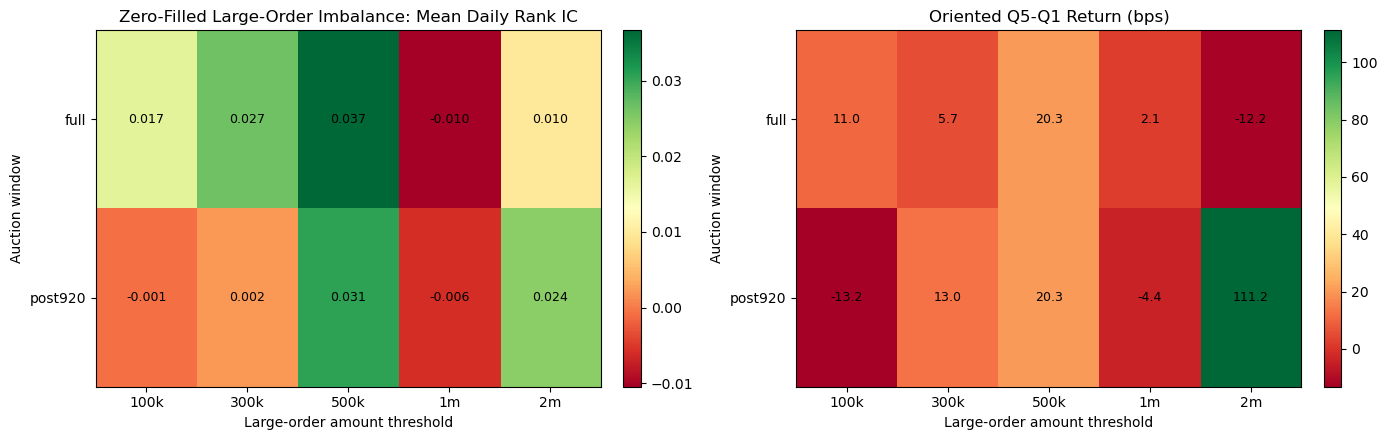

In [62]:
# ============================================================
# C6. Threshold × Window Diagnostic Heatmaps
# ============================================================

import matplotlib.pyplot as plt

heatmap_source = (
    large_order_configuration_summary.loc[
        large_order_configuration_summary[
            "factor_definition"
        ].eq("imbalance_zero_filled")
    ]
    .copy()
)

threshold_order = ["100k", "300k", "500k", "1m", "2m"]
window_order = ["full", "post920"]

ic_heatmap = (
    heatmap_source.pivot(
        index="auction_window",
        columns="threshold_label",
        values="mean_daily_rank_ic",
    )
    .reindex(index=window_order, columns=threshold_order)
)

qspread_heatmap = (
    heatmap_source.pivot(
        index="auction_window",
        columns="threshold_label",
        values="mean_oriented_q5_q1_bps",
    )
    .reindex(index=window_order, columns=threshold_order)
)


def _draw_heatmap(axis, values, title, value_format):
    image = axis.imshow(values.values, aspect="auto", cmap="RdYlGn")
    axis.set_xticks(range(len(values.columns)))
    axis.set_xticklabels(values.columns)
    axis.set_yticks(range(len(values.index)))
    axis.set_yticklabels(values.index)
    axis.set_xlabel("Large-order amount threshold")
    axis.set_ylabel("Auction window")
    axis.set_title(title)

    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            value = values.iloc[row, column]
            label = "NA" if pd.isna(value) else value_format.format(value)
            axis.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                fontsize=9,
            )
    return image


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

image_1 = _draw_heatmap(
    axes[0],
    ic_heatmap,
    "Zero-Filled Large-Order Imbalance: Mean Daily Rank IC",
    "{:.3f}",
)
fig.colorbar(image_1, ax=axes[0], fraction=0.046, pad=0.04)

image_2 = _draw_heatmap(
    axes[1],
    qspread_heatmap,
    "Oriented Q5-Q1 Return (bps)",
    "{:.1f}",
)
fig.colorbar(image_2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## C7. 本轮输出如何解释

运行 C2–C6 后按以下顺序判断：

1. 先看 `imbalance_zero_filled`，在完全相同股票日样本上比较阈值和窗口；
2. 再看 `imbalance_conditional`，判断该级别大单真正出现时方向是否更有效；
3. 如果 conditional IC较高但覆盖率很低，只能定义为事件因子；
4. 检查 `amount_share/count_share/HHI` 是否提供区别于方向不平衡的新信息；
5. 最多保留1–2个经济含义不同的大单变体；
6. 最终候选仍需做流动性、板块分层和未来新增日期验证。

本轮结束后，再决定是否继续裂变为买方大单、卖方大单、机构型连续下单、
大单反转与大单—开盘盘口一致性。

# Part VIII-D. 500k大单机制深化

第一轮阈值比较表明，500k大单方向是当前大单因子树的核心。
本部分不再增加模型，而是回答四个具体问题：

1. 信息来自买方大单还是卖方大单？
2. 09:20前与09:20后是持续、加强还是反转？
3. 大单方向与09:30五档盘口一致时是否更可信？
4. 结果能否跨日期、流动性和板块保持同方向？

同时，前面的五分组函数已改为 `rank(method="average")`。相同的零值不会再
按照行顺序被强行拆入不同五分组，因此稀疏阈值的Q5−Q1更可信。

In [63]:
# ============================================================
# C8. Build One-Row-per-Stock-Day 500k Mechanism Table
# ============================================================

required_500k_columns = {
    "code",
    "date",
    "auction_window",
    "threshold_value",
    "coverage_flag",
    "total_order_amount",
    "large_total_amount",
    "large_buy_amount",
    "large_sell_amount",
    "large_order_imbalance",
    "future_return_5m_raw",
}

missing_500k_columns = (
    required_500k_columns
    - set(large_order_factor_research_long.columns)
)
assert not missing_500k_columns, (
    "500k mechanism table is missing columns: "
    f"{sorted(missing_500k_columns)}"
)

grid_500k = (
    large_order_factor_research_long.loc[
        large_order_factor_research_long[
            "threshold_value"
        ].eq(500_000.0)
    ]
    .copy()
)

full_500k = (
    grid_500k.loc[grid_500k["auction_window"].eq("full")]
    .drop(columns=["auction_window"])
    .add_suffix("_full")
    .rename(
        columns={
            "code_full": "code",
            "date_full": "date",
            "future_return_5m_raw_full": "future_return_5m_raw",
        }
    )
)

post_500k = (
    grid_500k.loc[grid_500k["auction_window"].eq("post920")]
    .drop(
        columns=[
            "auction_window",
            "future_return_5m_raw",
        ]
    )
    .add_suffix("_post920")
    .rename(
        columns={
            "code_post920": "code",
            "date_post920": "date",
        }
    )
)

factor_500k_df = full_500k.merge(
    post_500k,
    on=["code", "date"],
    how="inner",
    validate="one_to_one",
)


def _safe_ratio(numerator, denominator):
    return (
        numerator
        / denominator.replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)


def _signed_imbalance(buy_amount, sell_amount):
    return _safe_ratio(
        buy_amount - sell_amount,
        buy_amount + sell_amount,
    )


# 09:15-09:20 = full window minus post920 window.
for amount_name in [
    "total_order_amount",
    "large_total_amount",
    "large_buy_amount",
    "large_sell_amount",
]:
    factor_500k_df[f"{amount_name}_pre920"] = (
        factor_500k_df[f"{amount_name}_full"]
        - factor_500k_df[f"{amount_name}_post920"]
    ).clip(lower=0.0)

factor_500k_df["full_500k_imbalance"] = (
    factor_500k_df["large_order_imbalance_full"]
    .fillna(0.0)
)
factor_500k_df["post920_500k_imbalance"] = (
    factor_500k_df["large_order_imbalance_post920"]
    .fillna(0.0)
)
factor_500k_df["pre920_500k_imbalance"] = (
    _signed_imbalance(
        factor_500k_df["large_buy_amount_pre920"],
        factor_500k_df["large_sell_amount_pre920"],
    )
    .fillna(0.0)
)

# Positive means the late auction becomes more buy-oriented.
factor_500k_df["late_imbalance_shift"] = (
    factor_500k_df["post920_500k_imbalance"]
    - factor_500k_df["pre920_500k_imbalance"]
)

# Separate buy and sell pressure. Sell pressure is signed negatively so that
# a larger value always means a more bullish direction.
factor_500k_df["full_500k_buy_pressure"] = _safe_ratio(
    factor_500k_df["large_buy_amount_full"],
    factor_500k_df["total_order_amount_full"],
).fillna(0.0)
factor_500k_df["full_500k_sell_pressure"] = -_safe_ratio(
    factor_500k_df["large_sell_amount_full"],
    factor_500k_df["total_order_amount_full"],
).fillna(0.0)
factor_500k_df["post920_500k_buy_pressure"] = _safe_ratio(
    factor_500k_df["large_buy_amount_post920"],
    factor_500k_df["total_order_amount_post920"],
).fillna(0.0)
factor_500k_df["post920_500k_sell_pressure"] = -_safe_ratio(
    factor_500k_df["large_sell_amount_post920"],
    factor_500k_df["total_order_amount_post920"],
).fillna(0.0)

factor_500k_df["full_500k_presence"] = (
    factor_500k_df["coverage_flag_full"].astype(float)
)
factor_500k_df["post920_500k_presence"] = (
    factor_500k_df["coverage_flag_post920"].astype(float)
)

factor_500k_df["late_direction_reversal"] = (
    np.sign(factor_500k_df["pre920_500k_imbalance"])
    * np.sign(factor_500k_df["post920_500k_imbalance"])
).eq(-1).astype(float)

factor_500k_df["late_direction_persistence"] = (
    np.sign(factor_500k_df["pre920_500k_imbalance"])
    * np.sign(factor_500k_df["post920_500k_imbalance"])
).eq(1).astype(float)

# Merge the strongest strict opening-book signal for confirmation tests.
opening_confirmation_columns = [
    column
    for column in [
        "strict_opening_depth_imbalance_5",
        "strict_opening_microprice_deviation",
        "rolling_5d_amount",
    ]
    if column in factor_research_df.columns
]

opening_confirmation_df = (
    factor_research_df[
        ["code", "date"] + opening_confirmation_columns
    ]
    .drop_duplicates(["code", "date"])
)

factor_500k_df = factor_500k_df.merge(
    opening_confirmation_df,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

if "strict_opening_depth_imbalance_5" in factor_500k_df.columns:
    open_pressure = factor_500k_df[
        "strict_opening_depth_imbalance_5"
    ].fillna(0.0)

    factor_500k_df["full_500k_open_agreement"] = (
        np.sign(factor_500k_df["full_500k_imbalance"])
        .eq(np.sign(open_pressure))
        & factor_500k_df["full_500k_imbalance"].ne(0)
        & open_pressure.ne(0)
    ).astype(float)

    factor_500k_df["post920_500k_open_agreement"] = (
        np.sign(factor_500k_df["post920_500k_imbalance"])
        .eq(np.sign(open_pressure))
        & factor_500k_df["post920_500k_imbalance"].ne(0)
        & open_pressure.ne(0)
    ).astype(float)

    # Signed confirmed pressure: zero when large orders and opening book
    # disagree; retains direction when they agree.
    factor_500k_df["full_500k_confirmed_pressure"] = np.where(
        factor_500k_df["full_500k_open_agreement"].eq(1),
        (
            factor_500k_df["full_500k_imbalance"]
            + open_pressure
        ) / 2.0,
        0.0,
    )
    factor_500k_df["post920_500k_confirmed_pressure"] = np.where(
        factor_500k_df["post920_500k_open_agreement"].eq(1),
        (
            factor_500k_df["post920_500k_imbalance"]
            + open_pressure
        ) / 2.0,
        0.0,
    )

assert factor_500k_df.duplicated(["code", "date"]).sum() == 0

print("500k stock-day rows:", len(factor_500k_df))
print("500k dates:", factor_500k_df["date"].nunique())
print("500k stocks:", factor_500k_df["code"].nunique())
display(factor_500k_df.head())

500k stock-day rows: 2504
500k dates: 63
500k stocks: 40


,code,date,total_order_count_full,total_order_amount_full,n_large_orders_full,large_total_amount_full,large_buy_amount_full,large_sell_amount_full,largest_large_order_amount_full,coverage_flag_full,large_order_imbalance_full,large_amount_share_full,large_count_share_full,largest_order_share_full,large_order_hhi_full,threshold_type_full,threshold_label_full,threshold_value_full,window_start_seconds_full,window_end_seconds_full,future_return_5m_raw,future_direction_5m_raw_full,total_order_count_post920,total_order_amount_post920,n_large_orders_post920,large_total_amount_post920,large_buy_amount_post920,large_sell_amount_post920,largest_large_order_amount_post920,coverage_flag_post920,large_order_imbalance_post920,large_amount_share_post920,large_count_share_post920,largest_order_share_post920,large_order_hhi_post920,threshold_type_post920,threshold_label_post920,threshold_value_post920,window_start_seconds_post920,window_end_seconds_post920,future_direction_5m_raw_post920,total_order_amount_pre920,large_total_amount_pre920,large_buy_amount_pre920,large_sell_amount_pre920,full_500k_imbalance,post920_500k_imbalance,pre920_500k_imbalance,late_imbalance_shift,full_500k_buy_pressure,full_500k_sell_pressure,post920_500k_buy_pressure,post920_500k_sell_pressure,full_500k_presence,post920_500k_presence,late_direction_reversal,late_direction_persistence,strict_opening_depth_imbalance_5,strict_opening_microprice_deviation,rolling_5d_amount,full_500k_open_agreement,post920_500k_open_agreement,full_500k_confirmed_pressure,post920_500k_confirmed_pressure
0,000713.SZ,2026-01-05,660,20274353.9,5,6037246.9,0.0,6037246.9,2573480.0,1,-1.000000,0.297778,0.007576,0.126933,0.024445,fixed_amount,500k,500000.0,33300,33900,-0.001507,0,88,3203454.0,1,728000.0,0.0,728000.0,728000.0,1,-1.000000,0.227255,0.011364,0.227255,0.051645,fixed_amount,500k,500000.0,33600,33900,0,17070899.9,5309246.9,0.0,5309246.9,-1.000000,-1.000000,-1.000000,0.000000,0.000000,-0.297778,0.000000,-0.227255,1.0,1.0,0.0,1.0,-0.323380,0.000159,NaN,1.0,1.0,-0.661690,-0.661690
1,000782.SZ,2026-01-05,262,8812710.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,500k,500000.0,33300,33900,0.002010,1,57,1714961.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,500k,500000.0,33600,33900,1,7097749.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000,0.0,0.0,0.0,0.0,0.019608,0.000000,NaN,0.0,0.0,0.000000,0.000000
2,000816.SZ,2026-01-05,1682,46785526.0,12,10584160.0,3871432.0,6712728.0,1966471.0,1,-0.268448,0.226227,0.007134,0.042032,0.005009,fixed_amount,500k,500000.0,33300,33900,-0.013495,0,454,15428417.0,4,3757917.0,1904961.0,1852956.0,1021761.0,1,0.013839,0.243571,0.008811,0.066226,0.014875,fixed_amount,500k,500000.0,33600,33900,0,31357109.0,6826243.0,1966471.0,4859772.0,-0.268448,0.013839,-0.423850,0.437688,0.082748,-0.143479,0.123471,-0.120100,1.0,1.0,1.0,0.0,0.357314,0.001191,NaN,0.0,1.0,0.000000,0.185576
3,000863.SZ,2026-01-05,1556,134786923.0,42,82101365.0,59790286.0,22311079.0,6320000.0,1,0.456499,0.609120,0.026992,0.046889,0.017042,fixed_amount,500k,500000.0,33300,33900,-0.048857,0,801,98379685.0,32,62882986.0,44534134.0,18348852.0,6320000.0,1,0.416413,0.639187,0.039950,0.064241,0.023628,fixed_amount,500k,500000.0,33600,33900,0,36407238.0,19218379.0,15256152.0,3962227.0,0.456499,0.416413,0.587663,-0.171250,0.443591,-0.165529,0.452676,-0.186511,1.0,1.0,0.0,1.0,0.842386,0.000775,NaN,1.0,1.0,0.649443,0.629399
4,001215.SZ,2026-01-05,202,8949878.0,2,1784139.0,0.0,1784139.0,1102304.0,1,-1.000000,0.199348,0.009901,0.123164,0.020973,fixed_amount,500k,500000.0,33300,33900,0.022822,1,52,2161084.0,0,0.0,0.0,0.0,0.0,0,NaN,0.000000,0.000000,0.000000,0.000000,fixed_amount,500k,500000.0,33600,33900,1,6788794.0,1784139.0,0.0,1784139.0,-1.000000,0.000000,-1.000000,1.000000,0.000000,-0.199348,0.000000,-0.000000,1.0,0.0,0.0,0.0,-0.689046,-0.000782,NaN,1.0,0.0,-0.844523,0.000000


## C9. 500k裂变因子统一排名

这里保持标签、股票池和日期完全一致。二元存在/反转指标不适合强行分成五组，
因此其IC可作为机制诊断，Q5−Q1可能为空。连续因子继续报告IC和tie-safe分组收益。

In [64]:
# ============================================================
# C9. Evaluate 500k Mechanism Variants
# ============================================================

FACTOR_500K_CANDIDATES = [
    "full_500k_imbalance",
    "post920_500k_imbalance",
    "pre920_500k_imbalance",
    "late_imbalance_shift",
    "full_500k_buy_pressure",
    "full_500k_sell_pressure",
    "post920_500k_buy_pressure",
    "post920_500k_sell_pressure",
    "full_500k_presence",
    "post920_500k_presence",
    "late_direction_reversal",
    "late_direction_persistence",
]

FACTOR_500K_CANDIDATES += [
    column
    for column in [
        "full_500k_confirmed_pressure",
        "post920_500k_confirmed_pressure",
    ]
    if column in factor_500k_df.columns
]

factor_500k_long = (
    factor_500k_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + FACTOR_500K_CANDIDATES
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
        ],
        value_vars=FACTOR_500K_CANDIDATES,
        var_name="factor",
        value_name="factor_value",
    )
)

daily_500k_metrics = (
    factor_500k_long.groupby(
        ["factor", "date"],
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["factor_value"].notna().sum(),
                "daily_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(frame),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

factor_500k_summary = (
    factor_500k_long.groupby(
        "factor",
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["factor_value"].notna().sum(),
                "coverage_ratio": frame["factor_value"].notna().mean(),
                "n_unique": frame["factor_value"].nunique(),
                "pooled_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .merge(
        daily_500k_metrics.groupby(
            "factor",
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            daily_ic_std=("daily_rank_ic", "std"),
            positive_daily_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
            mean_q5_q1_bps=(
                "daily_q5_q1",
                lambda x: x.mean() * 10_000,
            ),
            positive_q5_q1_day_ratio=(
                "daily_q5_q1",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index(),
        on="factor",
        how="left",
        validate="one_to_one",
    )
)

factor_500k_summary["icir"] = (
    factor_500k_summary["mean_daily_rank_ic"]
    / factor_500k_summary["daily_ic_std"]
)
factor_500k_summary["abs_mean_daily_rank_ic"] = (
    factor_500k_summary["mean_daily_rank_ic"].abs()
)

factor_500k_summary = (
    factor_500k_summary.sort_values(
        "abs_mean_daily_rank_ic",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(factor_500k_summary)

,factor,n_obs,coverage_ratio,n_unique,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir,abs_mean_daily_rank_ic
0,full_500k_confirmed_pressure,2504.0,1.0,1156.0,0.085091,63,0.080966,0.064526,0.187680,0.698413,33.810030,0.555556,0.431405,0.080966
1,post920_500k_confirmed_pressure,2504.0,1.0,856.0,0.071393,63,0.067054,0.091845,0.204541,0.603175,31.747572,0.516129,0.327828,0.067054
2,full_500k_imbalance,2504.0,1.0,1236.0,0.033243,63,0.036647,0.030476,0.172282,0.555556,20.313108,0.581395,0.212714,0.036647
3,pre920_500k_imbalance,2504.0,1.0,933.0,0.031195,63,0.032838,0.031118,0.164827,0.603175,33.729435,0.625000,0.199229,0.032838
4,full_500k_buy_pressure,2504.0,1.0,1369.0,0.035483,63,0.032830,-0.002260,0.181709,0.492063,38.194642,0.722222,0.180674,0.032830
5,post920_500k_imbalance,2504.0,1.0,607.0,0.018025,63,0.030700,0.001723,0.188915,0.507937,20.341318,0.557377,0.162507,0.030700
6,post920_500k_buy_pressure,2504.0,1.0,829.0,0.016604,63,0.029553,0.034592,0.184508,0.603175,NaN,NaN,0.160172,0.029553
7,post920_500k_sell_pressure,2504.0,1.0,1220.0,0.011246,63,0.015415,-0.017028,0.180247,0.476190,44.499949,0.750000,0.085520,0.015415
8,late_direction_reversal,2504.0,1.0,2.0,0.012441,63,0.015308,0.014178,0.187424,0.555556,NaN,NaN,0.081677,0.015308
9,late_direction_persistence,2504.0,1.0,2.0,-0.014808,63,-0.011685,-0.002316,0.140650,0.492063,NaN,NaN,-0.083076,0.011685


## C10. 日期稳定性与bootstrap区间

Bootstrap的抽样单位是交易日，而不是单条股票记录，从而保留同一天横截面的依赖结构。
区间跨过0不代表因子一定无效，但说明当前63日证据尚不足以确认稳定性。

In [65]:
# ============================================================
# C10. Date-Level Bootstrap for Top 500k Variants
# ============================================================

BOOTSTRAP_ITERATIONS = 5000
BOOTSTRAP_SEED = 20260720

top_500k_factors = (
    factor_500k_summary.loc[
        factor_500k_summary["n_ic_dates"].ge(40),
        "factor",
    ]
    .head(8)
    .tolist()
)

rng_500k = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_rows = []

for factor_name in top_500k_factors:
    ic_values = (
        daily_500k_metrics.loc[
            daily_500k_metrics["factor"].eq(factor_name),
            "daily_rank_ic",
        ]
        .dropna()
        .to_numpy()
    )

    if len(ic_values) == 0:
        continue

    bootstrap_means = np.empty(BOOTSTRAP_ITERATIONS)
    for iteration in range(BOOTSTRAP_ITERATIONS):
        bootstrap_means[iteration] = rng_500k.choice(
            ic_values,
            size=len(ic_values),
            replace=True,
        ).mean()

    observed_mean = ic_values.mean()
    bootstrap_rows.append(
        {
            "factor": factor_name,
            "n_dates": len(ic_values),
            "observed_mean_daily_ic": observed_mean,
            "bootstrap_ci_low": np.quantile(
                bootstrap_means,
                0.025,
            ),
            "bootstrap_ci_high": np.quantile(
                bootstrap_means,
                0.975,
            ),
            "bootstrap_same_sign_probability": (
                (bootstrap_means > 0).mean()
                if observed_mean >= 0
                else (bootstrap_means < 0).mean()
            ),
        }
    )

factor_500k_bootstrap = (
    pd.DataFrame(bootstrap_rows)
    .sort_values(
        "observed_mean_daily_ic",
        key=lambda x: x.abs(),
        ascending=False,
    )
    .reset_index(drop=True)
)

display(factor_500k_bootstrap)

,factor,n_dates,observed_mean_daily_ic,bootstrap_ci_low,bootstrap_ci_high,bootstrap_same_sign_probability
0,full_500k_confirmed_pressure,63,0.080966,0.034403,0.126443,0.9998
1,post920_500k_confirmed_pressure,63,0.067054,0.017896,0.117699,0.9942
2,full_500k_imbalance,63,0.036647,-0.004917,0.078262,0.9556
3,pre920_500k_imbalance,63,0.032838,-0.006912,0.072281,0.9420
4,full_500k_buy_pressure,63,0.032830,-0.013192,0.076558,0.9184
5,post920_500k_imbalance,63,0.030700,-0.016081,0.076625,0.9010
6,post920_500k_buy_pressure,63,0.029553,-0.018139,0.074186,0.8984
7,post920_500k_sell_pressure,63,0.015415,-0.028308,0.059167,0.7494


## C11. 与开盘盘口的重复度和增量机制

若500k因子与五档深度不平衡高度相关，它可能只是较早、较噪的盘口代理；
若相关性不高但“确认型压力”更强，则说明大单方向提供了独立的资金行为信息。

In [66]:
# ============================================================
# C11. Cross-Sectional Rank Correlation and Confirmation Test
# ============================================================

correlation_candidates = [
    column
    for column in [
        "full_500k_imbalance",
        "post920_500k_imbalance",
        "pre920_500k_imbalance",
        "late_imbalance_shift",
        "full_500k_buy_pressure",
        "full_500k_sell_pressure",
        "strict_opening_depth_imbalance_5",
        "strict_opening_microprice_deviation",
    ]
    if column in factor_500k_df.columns
]

ranked_500k_for_correlation = (
    factor_500k_df[
        ["date"] + correlation_candidates
    ]
    .copy()
)

ranked_500k_for_correlation[correlation_candidates] = (
    ranked_500k_for_correlation.groupby("date")[
        correlation_candidates
    ]
    .rank(method="average", pct=True)
)

factor_500k_rank_correlation = (
    ranked_500k_for_correlation[
        correlation_candidates
    ].corr(method="pearson")
)

display(factor_500k_rank_correlation)

if "full_500k_open_agreement" in factor_500k_df.columns:
    agreement_summary = (
        factor_500k_df.assign(
            agreement_state=np.select(
                [
                    factor_500k_df[
                        "full_500k_open_agreement"
                    ].eq(1),
                    factor_500k_df[
                        "full_500k_presence"
                    ].eq(0),
                ],
                [
                    "Large order and opening book agree",
                    "No full-window 500k order",
                ],
                default="Large order and opening book conflict",
            )
        )
        .groupby(
            "agreement_state",
            observed=True,
        )
        .agg(
            n_obs=("code", "size"),
            n_dates=("date", "nunique"),
            mean_return_bps=(
                "future_return_5m_raw",
                lambda x: x.mean() * 10_000,
            ),
            positive_return_ratio=(
                "future_return_5m_raw",
                lambda x: (x > 0).mean(),
            ),
        )
        .reset_index()
    )
    display(agreement_summary)

,full_500k_imbalance,post920_500k_imbalance,pre920_500k_imbalance,late_imbalance_shift,full_500k_buy_pressure,full_500k_sell_pressure,strict_opening_depth_imbalance_5,strict_opening_microprice_deviation
full_500k_imbalance,1.000000,0.433041,0.766259,-0.237273,0.717617,0.523091,0.101344,0.059156
post920_500k_imbalance,0.433041,1.000000,0.044596,0.665283,0.288398,0.322171,0.191865,0.093192
pre920_500k_imbalance,0.766259,0.044596,1.000000,-0.652380,0.496982,0.489294,0.003519,-0.006377
late_imbalance_shift,-0.237273,0.665283,-0.652380,1.000000,-0.120274,-0.142503,0.138274,0.057740
full_500k_buy_pressure,0.717617,0.288398,0.496982,-0.120274,1.000000,-0.003422,0.111736,0.062037
full_500k_sell_pressure,0.523091,0.322171,0.489294,-0.142503,-0.003422,1.000000,0.053958,0.023465
strict_opening_depth_imbalance_5,0.101344,0.191865,0.003519,0.138274,0.111736,0.053958,1.000000,0.403994
strict_opening_microprice_deviation,0.059156,0.093192,-0.006377,0.057740,0.062037,0.023465,0.403994,1.000000


,agreement_state,n_obs,n_dates,mean_return_bps,positive_return_ratio
0,Large order and opening book agree,1158,63,1.887928,0.457686
1,Large order and opening book conflict,1077,63,8.800600,0.513463
2,No full-window 500k order,269,62,0.809144,0.453532


## C12. 分层稳健性

流动性使用历史 `rolling_5d_amount` 做每日横截面三分组；板块根据证券代码做描述性分层。
由于每层股票数较少，这里主要检查方向是否灾难性反转，不以单层显著性作为筛选标准。

In [67]:
# ============================================================
# C12. Liquidity and Board Robustness
# ============================================================

robustness_factor_names = (
    factor_500k_summary.loc[
        factor_500k_summary["n_ic_dates"].ge(40),
        "factor",
    ]
    .head(5)
    .tolist()
)

robustness_500k_long = (
    factor_500k_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + robustness_factor_names
        + (
            ["rolling_5d_amount"]
            if "rolling_5d_amount" in factor_500k_df.columns
            else []
        )
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + (
            ["rolling_5d_amount"]
            if "rolling_5d_amount" in factor_500k_df.columns
            else []
        ),
        value_vars=robustness_factor_names,
        var_name="factor",
        value_name="factor_value",
    )
)

robustness_500k_long["board"] = np.select(
    [
        robustness_500k_long["code"].str.startswith(
            ("300", "301")
        ),
        robustness_500k_long["code"].str.startswith(
            ("688", "689")
        ),
    ],
    ["ChiNext", "STAR"],
    default="Main board",
)


def _daily_rank_ic_by_group(frame, group_columns):
    return (
        frame.groupby(
            group_columns + ["date"],
            observed=True,
        )
        .apply(
            lambda x: _rank_corr(
                x["factor_value"],
                x["future_return_5m_raw"],
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )


board_daily_ic = _daily_rank_ic_by_group(
    robustness_500k_long,
    ["factor", "board"],
)

board_robustness_500k = (
    board_daily_ic.groupby(
        ["factor", "board"],
        observed=True,
    )
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        positive_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)

display(board_robustness_500k)

if "rolling_5d_amount" in robustness_500k_long.columns:
    liquidity_rank = (
        robustness_500k_long.groupby(
            ["factor", "date"],
            observed=True,
        )["rolling_5d_amount"]
        .rank(method="average", pct=True)
    )

    robustness_500k_long["liquidity_group"] = pd.cut(
        liquidity_rank,
        bins=[0.0, 1 / 3, 2 / 3, 1.0],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

    liquidity_daily_ic = _daily_rank_ic_by_group(
        robustness_500k_long.dropna(
            subset=["liquidity_group"]
        ),
        ["factor", "liquidity_group"],
    )

    liquidity_robustness_500k = (
        liquidity_daily_ic.groupby(
            ["factor", "liquidity_group"],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )

    display(liquidity_robustness_500k)
else:
    print(
        "rolling_5d_amount is unavailable; "
        "liquidity robustness was skipped."
    )

,factor,board,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,full_500k_buy_pressure,ChiNext,0,NaN,NaN,NaN
1,full_500k_buy_pressure,Main board,63,0.014346,-0.009607,0.476190
2,full_500k_buy_pressure,STAR,0,NaN,NaN,NaN
3,full_500k_confirmed_pressure,ChiNext,0,NaN,NaN,NaN
4,full_500k_confirmed_pressure,Main board,63,0.053730,0.039616,0.603175
5,full_500k_confirmed_pressure,STAR,0,NaN,NaN,NaN
6,full_500k_imbalance,ChiNext,0,NaN,NaN,NaN
7,full_500k_imbalance,Main board,63,0.004881,-0.009904,0.492063
8,full_500k_imbalance,STAR,0,NaN,NaN,NaN
9,post920_500k_confirmed_pressure,ChiNext,0,NaN,NaN,NaN


,factor,liquidity_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,full_500k_buy_pressure,Low,60,0.019644,0.041779,0.566667
1,full_500k_buy_pressure,Medium,60,0.000195,-0.036799,0.416667
2,full_500k_buy_pressure,High,60,0.048634,0.084256,0.616667
3,full_500k_confirmed_pressure,Low,60,0.112822,0.155361,0.633333
4,full_500k_confirmed_pressure,Medium,60,0.069184,0.025368,0.583333
5,full_500k_confirmed_pressure,High,60,0.050536,0.066142,0.583333
6,full_500k_imbalance,Low,60,0.030268,0.071874,0.566667
7,full_500k_imbalance,Medium,60,0.032393,0.007872,0.500000
8,full_500k_imbalance,High,60,0.027444,0.049785,0.550000
9,post920_500k_confirmed_pressure,Low,55,0.051233,0.063164,0.509091


## C13. Opening-only 与 500k 增量比较

`confirmed_pressure`直接包含开盘五档深度，因此其高IC不能自动归因于500k大单。
本节在完全相同的股票日上比较：

1. `Opening Only`：只使用09:30五档深度不平衡；
2. `500k Only`：只使用全竞价期500k净方向；
3. `Equal Rank Combination`：两者每日横截面rank等权；
4. `Confirmed Pressure`：两者同号时保留，否则归零。

真正的增量标准是组合相对 `Opening Only` 的每日IC差值，而不是组合IC本身较高。

In [68]:
# ============================================================
# C13. Same-Sample Opening vs 500k Signal Comparison
# ============================================================

OPENING_FACTOR = "strict_opening_depth_imbalance_5"

assert OPENING_FACTOR in factor_500k_df.columns, (
    f"{OPENING_FACTOR} is unavailable. "
    "Run the opening-factor construction cells first."
)

incremental_500k_df = factor_500k_df[
    [
        "code",
        "date",
        "future_return_5m_raw",
        OPENING_FACTOR,
        "full_500k_imbalance",
        "full_500k_confirmed_pressure",
    ]
].dropna(
    subset=[
        "future_return_5m_raw",
        OPENING_FACTOR,
        "full_500k_imbalance",
    ]
).copy()

# Daily percentile ranks put the two inputs on the same scale.
incremental_500k_df["opening_rank"] = (
    incremental_500k_df.groupby("date")[
        OPENING_FACTOR
    ].rank(method="average", pct=True)
)
incremental_500k_df["full_500k_rank"] = (
    incremental_500k_df.groupby("date")[
        "full_500k_imbalance"
    ].rank(method="average", pct=True)
)

incremental_500k_df["Opening Only"] = (
    incremental_500k_df["opening_rank"]
)
incremental_500k_df["500k Only"] = (
    incremental_500k_df["full_500k_rank"]
)
incremental_500k_df["Equal Rank Combination"] = (
    incremental_500k_df[
        ["opening_rank", "full_500k_rank"]
    ].mean(axis=1)
)
incremental_500k_df["Confirmed Pressure"] = (
    incremental_500k_df["full_500k_confirmed_pressure"]
)

INCREMENTAL_SIGNAL_COLUMNS = [
    "Opening Only",
    "500k Only",
    "Equal Rank Combination",
    "Confirmed Pressure",
]

incremental_signal_long = (
    incremental_500k_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + INCREMENTAL_SIGNAL_COLUMNS
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
        ],
        value_vars=INCREMENTAL_SIGNAL_COLUMNS,
        var_name="signal",
        value_name="signal_value",
    )
)

daily_incremental_signal_metrics = (
    incremental_signal_long.groupby(
        ["signal", "date"],
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["signal_value"].notna().sum(),
                "daily_rank_ic": _rank_corr(
                    frame["signal_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(
                    frame.rename(
                        columns={"signal_value": "factor_value"}
                    )
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

incremental_signal_summary = (
    daily_incremental_signal_metrics.groupby(
        "signal",
        observed=True,
    )
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
        positive_q5_q1_day_ratio=(
            "daily_q5_q1",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)

incremental_signal_summary["icir"] = (
    incremental_signal_summary["mean_daily_rank_ic"]
    / incremental_signal_summary["daily_ic_std"]
)

incremental_signal_summary = (
    incremental_signal_summary.sort_values(
        "mean_daily_rank_ic",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(incremental_signal_summary)

,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,Confirmed Pressure,63,0.080966,0.064526,0.187680,0.698413,33.810030,0.555556,0.431405
1,Opening Only,63,0.079802,0.079835,0.178187,0.682540,27.443708,0.619048,0.447857
2,Equal Rank Combination,63,0.078143,0.083599,0.187145,0.714286,35.709898,0.666667,0.417555
3,500k Only,63,0.036647,0.030476,0.172282,0.555556,20.313108,0.581395,0.212714


## C14. 每日IC增量与配对bootstrap

这里先在每个交易日计算：

```text
组合IC − Opening Only IC
```

然后对日期差值做bootstrap。由于两个模型使用同一天、同一股票池，这是比比较两条
独立置信区间更直接的增量检验。

In [69]:
# ============================================================
# C14. Paired Daily-IC Difference Bootstrap
# ============================================================

daily_ic_wide = (
    daily_incremental_signal_metrics.pivot(
        index="date",
        columns="signal",
        values="daily_rank_ic",
    )
    .sort_index()
)

comparison_signals = [
    "500k Only",
    "Equal Rank Combination",
    "Confirmed Pressure",
]

PAIRED_BOOTSTRAP_ITERATIONS = 10_000
PAIRED_BOOTSTRAP_SEED = 20260721
paired_rng = np.random.default_rng(PAIRED_BOOTSTRAP_SEED)
paired_increment_rows = []

for signal_name in comparison_signals:
    paired = daily_ic_wide[
        ["Opening Only", signal_name]
    ].dropna()
    differences = (
        paired[signal_name]
        - paired["Opening Only"]
    ).to_numpy()

    bootstrap_means = np.empty(PAIRED_BOOTSTRAP_ITERATIONS)
    for iteration in range(PAIRED_BOOTSTRAP_ITERATIONS):
        bootstrap_means[iteration] = paired_rng.choice(
            differences,
            size=len(differences),
            replace=True,
        ).mean()

    paired_increment_rows.append(
        {
            "comparison": f"{signal_name} minus Opening Only",
            "n_paired_dates": len(differences),
            "mean_daily_ic_difference": differences.mean(),
            "median_daily_ic_difference": np.median(differences),
            "positive_difference_ratio": (differences > 0).mean(),
            "bootstrap_ci_low": np.quantile(
                bootstrap_means,
                0.025,
            ),
            "bootstrap_ci_high": np.quantile(
                bootstrap_means,
                0.975,
            ),
            "probability_mean_difference_positive": (
                bootstrap_means > 0
            ).mean(),
        }
    )

paired_incremental_test = (
    pd.DataFrame(paired_increment_rows)
    .sort_values(
        "mean_daily_ic_difference",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(paired_incremental_test)

,comparison,n_paired_dates,mean_daily_ic_difference,median_daily_ic_difference,positive_difference_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_difference_positive
0,Confirmed Pressure minus Opening Only,63,0.001164,-0.000862,0.476190,-0.028460,0.030887,0.5301
1,Equal Rank Combination minus Opening Only,63,-0.001659,-0.001773,0.460317,-0.029963,0.028196,0.4560
2,500k Only minus Opening Only,63,-0.043155,-0.061042,0.380952,-0.094892,0.012206,0.0587


## C15. 500k对开盘盘口的横截面残差化

低相关性并不等于存在增量。本节每天用横截面回归去掉500k rank中可被开盘盘口
rank解释的部分：

```text
500k rank = α + β × opening rank + residual
```

若 `residual` 仍然具有稳定Rank IC，才说明500k包含盘口之外的信息。

In [70]:
# ============================================================
# C15. Daily Cross-Sectional Residualized 500k Signal
# ============================================================


def _daily_residualize_500k(frame):
    result = pd.Series(
        np.nan,
        index=frame.index,
        dtype=float,
    )
    valid = frame[
        ["opening_rank", "full_500k_rank"]
    ].dropna()

    if (
        len(valid) < MIN_CROSS_SECTION_OBS
        or valid["opening_rank"].nunique() < 2
        or valid["full_500k_rank"].nunique() < 2
    ):
        return result

    design = np.column_stack(
        [
            np.ones(len(valid)),
            valid["opening_rank"].to_numpy(),
        ]
    )
    coefficients = np.linalg.lstsq(
        design,
        valid["full_500k_rank"].to_numpy(),
        rcond=None,
    )[0]
    fitted = design @ coefficients
    result.loc[valid.index] = (
        valid["full_500k_rank"].to_numpy()
        - fitted
    )
    return result


incremental_500k_df["Residualized 500k"] = (
    incremental_500k_df.groupby(
        "date",
        group_keys=False,
    )
    .apply(
        _daily_residualize_500k,
        include_groups=False,
    )
    .sort_index()
)

daily_residualized_500k = (
    incremental_500k_df.groupby(
        "date",
        observed=True,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["Residualized 500k"].notna().sum(),
                "daily_rank_ic": _rank_corr(
                    frame["Residualized 500k"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(
                    frame[
                        [
                            "Residualized 500k",
                            "future_return_5m_raw",
                        ]
                    ].rename(
                        columns={
                            "Residualized 500k": "factor_value"
                        }
                    )
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

residualized_500k_summary = pd.DataFrame(
    {
        "metric": [
            "n_ic_dates",
            "mean_daily_rank_ic",
            "median_daily_rank_ic",
            "daily_ic_std",
            "icir",
            "positive_daily_ic_ratio",
            "mean_q5_q1_bps",
            "positive_q5_q1_day_ratio",
        ],
        "value": [
            daily_residualized_500k["daily_rank_ic"].notna().sum(),
            daily_residualized_500k["daily_rank_ic"].mean(),
            daily_residualized_500k["daily_rank_ic"].median(),
            daily_residualized_500k["daily_rank_ic"].std(),
            (
                daily_residualized_500k["daily_rank_ic"].mean()
                / daily_residualized_500k["daily_rank_ic"].std()
            ),
            (
                daily_residualized_500k["daily_rank_ic"].dropna() > 0
            ).mean(),
            daily_residualized_500k["daily_q5_q1"].mean() * 10_000,
            (
                daily_residualized_500k["daily_q5_q1"].dropna() > 0
            ).mean(),
        ],
    }
)

display(residualized_500k_summary)

# Date bootstrap for residual IC.
residual_ic_values = (
    daily_residualized_500k["daily_rank_ic"]
    .dropna()
    .to_numpy()
)
residual_bootstrap_means = np.empty(PAIRED_BOOTSTRAP_ITERATIONS)
for iteration in range(PAIRED_BOOTSTRAP_ITERATIONS):
    residual_bootstrap_means[iteration] = paired_rng.choice(
        residual_ic_values,
        size=len(residual_ic_values),
        replace=True,
    ).mean()

residualized_500k_bootstrap = pd.DataFrame(
    {
        "metric": [
            "observed_mean_daily_ic",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
            "probability_mean_ic_positive",
        ],
        "value": [
            residual_ic_values.mean(),
            np.quantile(residual_bootstrap_means, 0.025),
            np.quantile(residual_bootstrap_means, 0.975),
            (residual_bootstrap_means > 0).mean(),
        ],
    }
)

display(residualized_500k_bootstrap)

,metric,value
0,n_ic_dates,63.000000
1,mean_daily_rank_ic,0.031048
2,median_daily_rank_ic,0.030394
3,daily_ic_std,0.168791
4,icir,0.183945
5,positive_daily_ic_ratio,0.571429
6,mean_q5_q1_bps,14.739483
7,positive_q5_q1_day_ratio,0.571429


,metric,value
0,observed_mean_daily_ic,0.031048
1,bootstrap_ci_low,-0.010066
2,bootstrap_ci_high,0.072188
3,probability_mean_ic_positive,0.934100


## C16. 正确解释 agree / conflict：方向调整收益

普通平均收益会把“共同看多”和“共同看空”混在一起，无法判断方向是否预测正确。
这里分别计算：

```text
sign(500k imbalance) × future return
sign(opening depth imbalance) × future return
```

正值代表信号方向判断正确。

In [71]:
# ============================================================
# C16. Direction-Adjusted Agreement / Conflict Analysis
# ============================================================

agreement_direction_df = factor_500k_df[
    [
        "code",
        "date",
        "future_return_5m_raw",
        "full_500k_imbalance",
        "full_500k_presence",
        OPENING_FACTOR,
    ]
].copy()

agreement_direction_df["large_direction"] = np.sign(
    agreement_direction_df["full_500k_imbalance"]
)
agreement_direction_df["opening_direction"] = np.sign(
    agreement_direction_df[OPENING_FACTOR]
)

agreement_direction_df["agreement_state"] = np.select(
    [
        agreement_direction_df["full_500k_presence"].eq(0),
        (
            agreement_direction_df["large_direction"]
            * agreement_direction_df["opening_direction"]
        ).eq(1),
        (
            agreement_direction_df["large_direction"]
            * agreement_direction_df["opening_direction"]
        ).eq(-1),
    ],
    [
        "No full-window 500k order",
        "Agree",
        "Conflict",
    ],
    default="Zero-direction / unavailable",
)

agreement_direction_df["large_signed_return_bps"] = (
    agreement_direction_df["large_direction"]
    * agreement_direction_df["future_return_5m_raw"]
    * 10_000
)
agreement_direction_df["opening_signed_return_bps"] = (
    agreement_direction_df["opening_direction"]
    * agreement_direction_df["future_return_5m_raw"]
    * 10_000
)

agreement_direction_summary = (
    agreement_direction_df.groupby(
        "agreement_state",
        observed=True,
    )
    .agg(
        n_obs=("code", "size"),
        n_dates=("date", "nunique"),
        mean_large_signed_return_bps=(
            "large_signed_return_bps",
            "mean",
        ),
        median_large_signed_return_bps=(
            "large_signed_return_bps",
            "median",
        ),
        large_direction_accuracy=(
            "large_signed_return_bps",
            lambda x: (x > 0).mean(),
        ),
        mean_opening_signed_return_bps=(
            "opening_signed_return_bps",
            "mean",
        ),
        opening_direction_accuracy=(
            "opening_signed_return_bps",
            lambda x: (x > 0).mean(),
        ),
    )
    .reset_index()
)

display(agreement_direction_summary)

,agreement_state,n_obs,n_dates,mean_large_signed_return_bps,median_large_signed_return_bps,large_direction_accuracy,mean_opening_signed_return_bps,opening_direction_accuracy
0,Agree,1158,63,13.068141,14.577411,0.544041,13.068141,0.544041
1,Conflict,1075,63,-10.081575,-5.980861,0.437209,10.081575,0.528372
2,No full-window 500k order,269,62,0.000000,0.000000,0.000000,10.388880,0.501859
3,Zero-direction / unavailable,2,2,19.770730,19.770730,0.500000,0.000000,0.000000


## C17. 修正版板块稳健性

原板块表要求每天至少10只同板块股票，导致ChiNext/STAR没有有效日度IC。
修正版同时报告样本规模、pooled Rank IC，并将分层日度IC的最低横截面样本数降为5。
若某板块仍不足5只，只保留pooled结果，不夸大其时间稳定性。

In [72]:
# ============================================================
# C17. Corrected Board Robustness with Small-Group Diagnostics
# ============================================================

MIN_BOARD_CROSS_SECTION_OBS = 5


def _rank_corr_minimum(x, y, minimum_observations):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if (
        len(valid) < minimum_observations
        or valid["x"].nunique() < 2
        or valid["y"].nunique() < 2
    ):
        return np.nan
    return valid["x"].rank().corr(valid["y"].rank())


board_factor_names = [
    column
    for column in [
        "full_500k_imbalance",
        "full_500k_confirmed_pressure",
        "post920_500k_confirmed_pressure",
        OPENING_FACTOR,
    ]
    if column in factor_500k_df.columns
]

corrected_board_df = (
    factor_500k_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + board_factor_names
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
        ],
        value_vars=board_factor_names,
        var_name="factor",
        value_name="factor_value",
    )
)

corrected_board_df["board"] = np.select(
    [
        corrected_board_df["code"].str.startswith(
            ("300", "301")
        ),
        corrected_board_df["code"].str.startswith(
            ("688", "689")
        ),
    ],
    ["ChiNext", "STAR"],
    default="Main board",
)

daily_board_sample = (
    corrected_board_df.groupby(
        ["factor", "board", "date"],
        observed=True,
    )
    .agg(
        n_obs=("factor_value", "count"),
    )
    .reset_index()
)

corrected_board_daily_ic = (
    corrected_board_df.groupby(
        ["factor", "board", "date"],
        observed=True,
    )
    .apply(
        lambda frame: _rank_corr_minimum(
            frame["factor_value"],
            frame["future_return_5m_raw"],
            MIN_BOARD_CROSS_SECTION_OBS,
        ),
        include_groups=False,
    )
    .rename("daily_rank_ic")
    .reset_index()
)

corrected_board_summary = (
    corrected_board_df.groupby(
        ["factor", "board"],
        observed=True,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": len(frame),
                "n_dates": frame["date"].nunique(),
                "n_stocks": frame["code"].nunique(),
                "mean_daily_observations": (
                    frame.groupby("date").size().mean()
                ),
                "pooled_rank_ic": _rank_corr_minimum(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                    5,
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .merge(
        corrected_board_daily_ic.groupby(
            ["factor", "board"],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index(),
        on=["factor", "board"],
        how="left",
        validate="one_to_one",
    )
)

display(corrected_board_summary)

,factor,board,n_obs,n_dates,n_stocks,mean_daily_observations,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,full_500k_confirmed_pressure,ChiNext,503.0,63.0,8.0,7.984127,0.091280,62,0.049881,0.095794,0.596774
1,full_500k_confirmed_pressure,Main board,1497.0,63.0,24.0,23.761905,0.047402,63,0.053730,0.039616,0.603175
2,full_500k_confirmed_pressure,STAR,504.0,63.0,8.0,8.000000,0.193086,63,0.156530,0.170783,0.634921
3,full_500k_imbalance,ChiNext,503.0,63.0,8.0,7.984127,0.072892,63,0.043747,0.000000,0.492063
4,full_500k_imbalance,Main board,1497.0,63.0,24.0,23.761905,-0.009870,63,0.004881,-0.009904,0.492063
5,full_500k_imbalance,STAR,504.0,63.0,8.0,8.000000,0.151880,63,0.135751,0.167668,0.634921
6,post920_500k_confirmed_pressure,ChiNext,503.0,63.0,8.0,7.984127,0.107404,53,0.132081,0.171457,0.641509
7,post920_500k_confirmed_pressure,Main board,1497.0,63.0,24.0,23.761905,0.038205,63,0.037754,0.071982,0.619048
8,post920_500k_confirmed_pressure,STAR,504.0,63.0,8.0,8.000000,0.141939,63,0.118974,0.101469,0.603175
9,strict_opening_depth_imbalance_5,ChiNext,503.0,63.0,8.0,7.984127,0.145536,63,0.118123,0.142857,0.666667


## C18. 增量决策表

500k因子进入最终组合需要至少满足以下条件：

1. `Residualized 500k` 的平均日度IC大于0；
2. residual bootstrap同号概率至少90%；
3. `Equal Rank Combination − Opening Only` 的平均日度IC差值大于0；
4. 配对bootstrap中组合增量为正的概率至少90%；
5. 修正版流动性和板块结果没有无法解释的灾难性反转。

前四项通过意味着“存在初步增量证据”，不等于未来样本已经确认。

In [73]:
# ============================================================
# C18. Mechanical Incremental-Evidence Decision Table
# ============================================================

equal_rank_test = paired_incremental_test.loc[
    paired_incremental_test["comparison"].eq(
        "Equal Rank Combination minus Opening Only"
    )
].iloc[0]

residual_mean_ic = residual_ic_values.mean()
residual_positive_probability = (
    residual_bootstrap_means > 0
).mean()

incremental_decision_table = pd.DataFrame(
    [
        {
            "criterion": "Residualized 500k mean daily IC > 0",
            "value": residual_mean_ic,
            "pass": residual_mean_ic > 0,
        },
        {
            "criterion": (
                "Residualized 500k bootstrap P(mean IC > 0) >= 90%"
            ),
            "value": residual_positive_probability,
            "pass": residual_positive_probability >= 0.90,
        },
        {
            "criterion": (
                "Equal-rank combination mean IC difference > 0"
            ),
            "value": equal_rank_test["mean_daily_ic_difference"],
            "pass": (
                equal_rank_test["mean_daily_ic_difference"] > 0
            ),
        },
        {
            "criterion": (
                "Paired bootstrap P(combination increment > 0) >= 90%"
            ),
            "value": equal_rank_test[
                "probability_mean_difference_positive"
            ],
            "pass": (
                equal_rank_test[
                    "probability_mean_difference_positive"
                ] >= 0.90
            ),
        },
    ]
)

incremental_evidence_pass = (
    incremental_decision_table["pass"].all()
)

print(
    "Preliminary incremental evidence pass:",
    incremental_evidence_pass,
)
display(incremental_decision_table)

Preliminary incremental evidence pass: False


,criterion,value,pass
0,Residualized 500k mean daily IC > 0,0.031048,True
1,Residualized 500k bootstrap P(mean IC > 0) >= 90%,0.934100,True
2,Equal-rank combination mean IC difference > 0,-0.001659,False
3,Paired bootstrap P(combination increment > 0) ...,0.456000,False


## C19. 500k因子深化阶段总结

### 研究了什么

本阶段从固定50万元母因子出发，依次研究：

1. `100k/300k/500k/1m/2m`金额阈值；
2. `09:15–09:25`全竞价窗口和`09:20–09:25`晚期窗口；
3. 大单净方向、金额占比、笔数占比和集中度；
4. 500k买方压力、卖方压力、09:20前后方向变化和持续/反转；
5. 500k方向与09:30五档盘口的一致、冲突和确认机制；
6. 日期bootstrap、流动性和板块分层；
7. 500k相对开盘盘口的配对IC增量与横截面残差信息。

### 获得了什么

- 500k是当前最有解释力的大单档位；
- 有效信息主要来自买卖大单的净方向，不是单纯的大单数量、金额占比或HHI；
- 全竞价期500k净方向的mean daily Rank IC约为`0.0366`；
- 500k与开盘五档深度不平衡的横截面rank相关性约为`0.10`，并非简单复制；
- 500k对开盘盘口残差化后mean daily Rank IC约为`0.0310`，bootstrap均值为正概率约为`93.4%`；
- 但500k与开盘盘口50/50等权后没有提高平均日度IC；
- Confirmed Pressure的IC约为`0.0810`，与Opening Only的`0.0798`接近，配对增量不显著；
- 当500k与开盘盘口一致时，按方向调整后的平均收益约为`+13.1 bps`；
- 两者冲突时，500k方向对应约`-10.1 bps`，而盘口方向对应约`+10.1 bps`；
- 因此冲突时应信任09:30盘口，而不是较早的竞价大单方向；
- 500k在STAR/ChiNext更强，在主板较弱，存在明显板块异质性。

### 当前判断

`strict_opening_depth_imbalance_5`仍是核心主因子。500k净方向是一个低相关、
有初步独立信息的辅助候选，但不适合与盘口等权，也不能替代盘口。

下一步只检验一个预先限定的机械形式：

```text
Opening rank
+ 小权重 × Residualized 500k rank × 1(500k与盘口同向)
```

冲突时新增项为0，完整保留Opening信号；一致时才允许500k提供小幅增强。
候选权重固定为`0%、10%、20%、30%`，并且滚动OOS选择只能使用测试日前的历史标签。

## C20. 固定小权重敏感性

这一表用于观察权重曲线是否平滑，不用于事后锁定最优权重。若只有某一个孤立权重
表现突出，应视为数据挖掘风险。

In [74]:
# ============================================================
# C20. Fixed Small-Weight Agreement-Gated Signals
# ============================================================

SMALL_500K_WEIGHTS = [0.0, 0.10, 0.20, 0.30]

weighted_500k_df = incremental_500k_df.copy()

weighted_500k_df["residual_500k_rank"] = (
    weighted_500k_df.groupby("date")[
        "Residualized 500k"
    ].rank(method="average", pct=True)
)

weighted_500k_df["agreement_gate"] = (
    np.sign(weighted_500k_df["full_500k_imbalance"])
    .eq(
        np.sign(
            weighted_500k_df[OPENING_FACTOR]
        )
    )
    & weighted_500k_df["full_500k_imbalance"].ne(0)
    & weighted_500k_df[OPENING_FACTOR].ne(0)
).astype(float)

WEIGHT_SIGNAL_COLUMNS = []
for weight in SMALL_500K_WEIGHTS:
    signal_name = f"Opening + {int(weight * 100)}% gated residual 500k"
    WEIGHT_SIGNAL_COLUMNS.append(signal_name)

    weighted_500k_df[signal_name] = (
        weighted_500k_df["opening_rank"]
        + weight
        * (
            weighted_500k_df["residual_500k_rank"]
            - 0.5
        )
        * weighted_500k_df["agreement_gate"]
    )

weighted_signal_long = (
    weighted_500k_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
        + WEIGHT_SIGNAL_COLUMNS
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
        ],
        value_vars=WEIGHT_SIGNAL_COLUMNS,
        var_name="signal",
        value_name="signal_value",
    )
)

daily_weight_sensitivity = (
    weighted_signal_long.groupby(
        ["signal", "date"],
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "daily_rank_ic": _rank_corr(
                    frame["signal_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(
                    frame.rename(
                        columns={"signal_value": "factor_value"}
                    )
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

weight_sensitivity_summary = (
    daily_weight_sensitivity.groupby(
        "signal",
        observed=True,
    )
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
        positive_q5_q1_day_ratio=(
            "daily_q5_q1",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)
weight_sensitivity_summary["icir"] = (
    weight_sensitivity_summary["mean_daily_rank_ic"]
    / weight_sensitivity_summary["daily_ic_std"]
)
weight_sensitivity_summary["weight"] = (
    weight_sensitivity_summary["signal"]
    .str.extract(r"Opening \+ (\d+)%")[0]
    .astype(float)
    / 100.0
)
weight_sensitivity_summary = (
    weight_sensitivity_summary.sort_values("weight")
    .reset_index(drop=True)
)

display(weight_sensitivity_summary)

,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir,weight
0,Opening + 0% gated residual 500k,63,0.079802,0.079835,0.178187,0.682540,27.443708,0.619048,0.447857,0.0
1,Opening + 10% gated residual 500k,63,0.082796,0.083118,0.178991,0.682540,26.900357,0.619048,0.462568,0.1
2,Opening + 20% gated residual 500k,63,0.082449,0.075610,0.180295,0.666667,23.407848,0.619048,0.457300,0.2
3,Opening + 30% gated residual 500k,63,0.082488,0.075235,0.180713,0.666667,23.009237,0.571429,0.456457,0.3


## C21. 仅用历史日期选择权重的滚动OOS

每个测试日：

1. 只使用此前最多40个交易日；
2. 至少需要20个历史日；
3. 比较`0/10/20/30%`四个固定权重的历史平均日度IC；
4. 若并列，选择更小权重；
5. 将选出的权重应用到当天，不使用当天收益。

`0%`也在候选中，因此历史证据不足时模型可以自动退回Opening Only。

In [75]:
# ============================================================
# C21. Rolling OOS Historical Weight Selection
# ============================================================

MIN_WEIGHT_TRAIN_DATES = 20
MAX_WEIGHT_TRAIN_DATES = 40

ordered_weight_dates = np.array(
    sorted(weighted_500k_df["date"].dropna().unique())
)

weight_name_map = {
    weight: f"Opening + {int(weight * 100)}% gated residual 500k"
    for weight in SMALL_500K_WEIGHTS
}

daily_weight_ic_wide = (
    daily_weight_sensitivity.pivot(
        index="date",
        columns="signal",
        values="daily_rank_ic",
    )
    .sort_index()
)

rolling_weight_prediction_parts = []
rolling_weight_selection_rows = []

for test_position in range(
    MIN_WEIGHT_TRAIN_DATES,
    len(ordered_weight_dates),
):
    test_date = ordered_weight_dates[test_position]
    train_start = max(
        0,
        test_position - MAX_WEIGHT_TRAIN_DATES,
    )
    train_dates = ordered_weight_dates[
        train_start:test_position
    ]

    historical_means = {}
    for weight, signal_name in weight_name_map.items():
        historical_means[weight] = (
            daily_weight_ic_wide.loc[
                daily_weight_ic_wide.index.isin(train_dates),
                signal_name,
            ]
            .dropna()
            .mean()
        )

    eligible_scores = {
        weight: score
        for weight, score in historical_means.items()
        if pd.notna(score)
    }

    # max score, then smallest weight in a tie.
    selected_weight = sorted(
        eligible_scores,
        key=lambda weight: (
            -eligible_scores[weight],
            weight,
        ),
    )[0]
    selected_signal = weight_name_map[selected_weight]

    test_source = weighted_500k_df.loc[
        weighted_500k_df["date"].eq(test_date)
    ].copy()
    test_rows = test_source[
        [
            "code",
            "date",
            "future_return_5m_raw",
        ]
    ].copy()
    test_rows["opening_only_signal"] = test_source[
        "Opening + 0% gated residual 500k"
    ].to_numpy()
    test_rows["rolling_selected_signal"] = test_source[
        selected_signal
    ].to_numpy()
    test_rows["selected_weight"] = selected_weight
    test_rows["train_start_date"] = train_dates[0]
    test_rows["train_end_date"] = train_dates[-1]
    test_rows["n_train_dates"] = len(train_dates)
    rolling_weight_prediction_parts.append(test_rows)

    rolling_weight_selection_rows.append(
        {
            "test_date": test_date,
            "selected_weight": selected_weight,
            "selected_historical_mean_ic": eligible_scores[
                selected_weight
            ],
            "opening_historical_mean_ic": eligible_scores[0.0],
            "train_start_date": train_dates[0],
            "train_end_date": train_dates[-1],
            "n_train_dates": len(train_dates),
        }
    )

rolling_weight_predictions = pd.concat(
    rolling_weight_prediction_parts,
    ignore_index=True,
)
rolling_weight_selection = pd.DataFrame(
    rolling_weight_selection_rows
)

print(
    "Rolling OOS dates:",
    rolling_weight_predictions["date"].nunique(),
)
display(
    rolling_weight_selection["selected_weight"]
    .value_counts(normalize=False)
    .sort_index()
    .rename_axis("selected_weight")
    .to_frame("n_test_dates")
)
display(rolling_weight_selection.head(10))

Rolling OOS dates: 43


,n_test_dates
selected_weight,
0.1,27
0.2,4
0.3,12


,test_date,selected_weight,selected_historical_mean_ic,opening_historical_mean_ic,train_start_date,train_end_date,n_train_dates
0,2026-02-02,0.1,0.079456,0.077315,2026-01-05,2026-01-30,20
1,2026-02-03,0.1,0.080050,0.078324,2026-01-05,2026-02-02,21
2,2026-02-04,0.1,0.084161,0.082398,2026-01-05,2026-02-03,22
3,2026-02-05,0.1,0.080102,0.078310,2026-01-05,2026-02-04,23
4,2026-02-06,0.1,0.079532,0.077751,2026-01-05,2026-02-05,24
5,2026-02-09,0.1,0.094415,0.092195,2026-01-05,2026-02-06,25
6,2026-02-10,0.1,0.086638,0.083733,2026-01-05,2026-02-09,26
7,2026-02-11,0.1,0.083709,0.080636,2026-01-05,2026-02-10,27
8,2026-02-12,0.1,0.098703,0.095190,2026-01-05,2026-02-11,28
9,2026-02-13,0.1,0.105918,0.102290,2026-01-05,2026-02-12,29


## C22. 滚动OOS结果与配对增量

最终只比较同一批测试日期上的 Rolling Selected 与 Opening Only。
主判断指标仍是每日Rank IC差值；Q5−Q1作为极端组经济区分度的补充。

In [76]:
# ============================================================
# C22. Rolling OOS Paired Evaluation
# ============================================================


def _evaluate_two_oos_signals(frame):
    rows = []
    for signal_name, signal_column in [
        ("Opening Only OOS", "opening_only_signal"),
        ("Rolling Selected OOS", "rolling_selected_signal"),
    ]:
        for test_date, daily_frame in frame.groupby(
            "date",
            observed=True,
        ):
            rows.append(
                {
                    "signal": signal_name,
                    "date": test_date,
                    "daily_rank_ic": _rank_corr(
                        daily_frame[signal_column],
                        daily_frame["future_return_5m_raw"],
                    ),
                    "daily_q5_q1": _daily_quintile_spread(
                        daily_frame[
                            [
                                signal_column,
                                "future_return_5m_raw",
                            ]
                        ].rename(
                            columns={
                                signal_column: "factor_value"
                            }
                        )
                    ),
                }
            )
    return pd.DataFrame(rows)


rolling_oos_daily_metrics = _evaluate_two_oos_signals(
    rolling_weight_predictions
)

rolling_oos_summary = (
    rolling_oos_daily_metrics.groupby(
        "signal",
        observed=True,
    )
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
        positive_q5_q1_day_ratio=(
            "daily_q5_q1",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)
rolling_oos_summary["icir"] = (
    rolling_oos_summary["mean_daily_rank_ic"]
    / rolling_oos_summary["daily_ic_std"]
)

display(rolling_oos_summary)

rolling_oos_ic_wide = (
    rolling_oos_daily_metrics.pivot(
        index="date",
        columns="signal",
        values="daily_rank_ic",
    )
    .dropna()
)
rolling_oos_ic_difference = (
    rolling_oos_ic_wide["Rolling Selected OOS"]
    - rolling_oos_ic_wide["Opening Only OOS"]
).to_numpy()

ROLLING_OOS_BOOTSTRAP_ITERATIONS = 10_000
rolling_oos_rng = np.random.default_rng(20260722)
rolling_oos_bootstrap_means = np.empty(
    ROLLING_OOS_BOOTSTRAP_ITERATIONS
)

for iteration in range(ROLLING_OOS_BOOTSTRAP_ITERATIONS):
    rolling_oos_bootstrap_means[iteration] = (
        rolling_oos_rng.choice(
            rolling_oos_ic_difference,
            size=len(rolling_oos_ic_difference),
            replace=True,
        ).mean()
    )

rolling_oos_incremental_test = pd.DataFrame(
    {
        "metric": [
            "n_paired_oos_dates",
            "mean_daily_ic_difference",
            "median_daily_ic_difference",
            "positive_difference_ratio",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
            "probability_mean_difference_positive",
        ],
        "value": [
            len(rolling_oos_ic_difference),
            rolling_oos_ic_difference.mean(),
            np.median(rolling_oos_ic_difference),
            (rolling_oos_ic_difference > 0).mean(),
            np.quantile(
                rolling_oos_bootstrap_means,
                0.025,
            ),
            np.quantile(
                rolling_oos_bootstrap_means,
                0.975,
            ),
            (rolling_oos_bootstrap_means > 0).mean(),
        ],
    }
)

display(rolling_oos_incremental_test)

,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,Opening Only OOS,43,0.080959,0.079835,0.190934,0.674419,23.30128,0.604651,0.424015
1,Rolling Selected OOS,43,0.083167,0.083118,0.190210,0.674419,21.18835,0.604651,0.437237


,metric,value
0,n_paired_oos_dates,43.000000
1,mean_daily_ic_difference,0.002208
2,median_daily_ic_difference,0.002064
3,positive_difference_ratio,0.627907
4,bootstrap_ci_low,-0.001453
5,bootstrap_ci_high,0.006092
6,probability_mean_difference_positive,0.879700


## C23. 小权重机制决策规则

只有同时满足以下条件，500k小权重增强才进入最终机械组合：

1. Rolling OOS平均IC差值大于0；
2. Rolling OOS中组合优于Opening的日期比例大于50%；
3. 日期bootstrap中平均增量为正的概率至少90%；
4. 权重选择不是长期集中在单个高权重档位；
5. 新增未来日期验证后方向不反转。

若未通过，则保留500k作为研究解释和条件诊断，最终主信号仍使用Opening Only。

In [77]:
# ============================================================
# C23. Rolling OOS Small-Weight Decision
# ============================================================

rolling_oos_increment_lookup = (
    rolling_oos_incremental_test.set_index("metric")["value"]
)

rolling_oos_weight_decision = pd.DataFrame(
    [
        {
            "criterion": "Rolling OOS mean IC difference > 0",
            "value": rolling_oos_increment_lookup[
                "mean_daily_ic_difference"
            ],
            "pass": rolling_oos_increment_lookup[
                "mean_daily_ic_difference"
            ] > 0,
        },
        {
            "criterion": (
                "Rolling OOS positive IC-difference ratio > 50%"
            ),
            "value": rolling_oos_increment_lookup[
                "positive_difference_ratio"
            ],
            "pass": rolling_oos_increment_lookup[
                "positive_difference_ratio"
            ] > 0.50,
        },
        {
            "criterion": (
                "Bootstrap P(mean OOS increment > 0) >= 90%"
            ),
            "value": rolling_oos_increment_lookup[
                "probability_mean_difference_positive"
            ],
            "pass": rolling_oos_increment_lookup[
                "probability_mean_difference_positive"
            ] >= 0.90,
        },
    ]
)

rolling_oos_small_weight_pass = (
    rolling_oos_weight_decision["pass"].all()
)

print(
    "Rolling OOS small-weight enhancement pass:",
    rolling_oos_small_weight_pass,
)
display(rolling_oos_weight_decision)

Rolling OOS small-weight enhancement pass: False


,criterion,value,pass
0,Rolling OOS mean IC difference > 0,0.002208,True
1,Rolling OOS positive IC-difference ratio > 50%,0.627907,True
2,Bootstrap P(mean OOS increment > 0) >= 90%,0.879700,False


## C24. 500k因子保留规则

本轮最多保留两个500k因子：

1. 一个全样本方向因子，例如 `full_500k_imbalance`；
2. 一个机制不同的增量因子，例如晚期方向变化、买卖侧压力或盘口确认因子。

不能因为同一家族多个定义都为正就全部保留。最终候选需要满足：

- mean/median daily IC方向基本一致；
- 前后日期不发生灾难性反转；
- bootstrap区间或同号概率提供支持；
- 流动性/板块分层方向可解释；
- 与开盘盘口因子没有接近完全重复；
- 经济机制明确，且全部信息在09:30时可见。

# 因子树C阶段结论：500k大单方向

## C的完整研究逻辑

因子树C从“固定50万元是否合理”出发，而不是直接把旧大单因子送进模型：

```text
金额阈值
→ 时间窗口
→ 大单方向/数量/占比/集中度
→ 买方与卖方拆分
→ 09:20前后持续/反转
→ 与09:30盘口的一致/冲突
→ 残差增量
→ 小权重滚动OOS
```

第一层比较`100k/300k/500k/1m/2m`和`full/post920`，确认500k是覆盖率与
资金辨识度之间最合理的档位。第二层证明预测信息主要来自500k买卖净方向，
而不是金额占比、笔数占比或HHI。第三层发现09:20后的方向变化没有稳定增量，
全竞价期累计方向更适合作为母因子。第四层把500k方向与09:30五档盘口结合，
检验一致、冲突和残差机制。最后只允许500k以小权重、同向确认的方式进入
Opening主信号，并使用历史窗口滚动选择权重。

## C获得了什么

- `full_500k_imbalance` mean daily Rank IC约`0.0366`；
- 残差化后500k mean daily Rank IC约`0.0310`，bootstrap同号概率约`93.4%`；
- 500k与开盘五档深度rank相关性约`0.10`，存在一定独立信息；
- 当500k与盘口一致时，方向调整收益约`+13.1 bps`；
- 冲突时500k方向约`-10.1 bps`，盘口方向约`+10.1 bps`；
- 因此冲突时应该信任Opening，500k只能在同向时增强；
- 固定10%小权重的全样本IC/ICIR最好，但滚动OOS增量仅约`+0.0022`；
- 滚动OOS增量为正概率约`88.0%`，低于预设`90%`闸门；
- 500k在STAR/ChiNext更强、主板较弱，具有板块异质性。

## C对本项目的用途

因子树C不是最终预测值本身，而是最终相关性信号中的一个辅助机制：

1. 提供竞价期间较大资金净方向；
2. 判断09:30盘口压力是否得到竞价资金行为支持；
3. 在两者同向时提供最多10%的候选增强；
4. 在两者冲突时不覆盖更接近预测起点的Opening信息；
5. 作为未来新增日期holdout中的冻结候选，不再继续调阈值或权重。

当前正式状态：

```text
Opening depth imbalance = 主因子
500k net imbalance = 辅助研究因子
10% agreement-gated residual overlay = future-holdout candidate
```

因子树C到此冻结，避免继续围绕同一批63日数据过拟合。

# Part IX. 因子树D：相对竞价参与度

## D的研究问题

同样的竞价成交额，对不同股票含义不同。100万元对于低流动性股票可能是异常资金
进入，对高流动性股票可能只是正常噪声。因此D不研究绝对成交量，而研究：

> 今天的集合竞价参与度，相对该股票此前可见历史是否异常？

参与度可能有三种作用：

1. **方向因子**：异常参与度本身预测09:30→09:35涨跌；
2. **波动因子**：只预测未来绝对收益，不预测方向；
3. **可信度调节器**：不单独预测，但增强Opening、缺口或500k信号。

所有历史基准必须先`shift(1)`，确保当天数据不会进入自己的历史均值。

## D1. 泄漏安全的历史参与度特征

使用5/10/20个历史交易日分别构造：

- 竞价成交额相对历史中位数；
- 竞价成交量相对历史中位数；
- log成交额历史z-score；
- log成交量历史z-score。

同时保留每天的横截面参与度rank。历史窗口只是参数敏感性，不根据单个最高IC
直接挑选。

In [78]:
# ============================================================
# D1. Leakage-Safe Relative Auction Participation Features
# ============================================================

required_participation_columns = {
    "code",
    "date",
    "future_return_5m_raw",
    "auction_trade_amount",
    "auction_trade_volume",
}
missing_participation_columns = (
    required_participation_columns
    - set(factor_research_df.columns)
)
assert not missing_participation_columns, (
    "factor_research_df is missing participation columns: "
    f"{sorted(missing_participation_columns)}"
)

participation_base_columns = [
    "code",
    "date",
    "future_return_5m_raw",
    "auction_trade_amount",
    "auction_trade_volume",
]
participation_context_columns = [
    column
    for column in [
        "strict_opening_depth_imbalance_5",
        "market_residual_auction_gap",
        "rolling_5d_amount",
        "auction_price",
        "strict_opening_relative_spread",
    ]
    if column in factor_research_df.columns
]

participation_df = (
    factor_research_df[
        participation_base_columns
        + participation_context_columns
    ]
    .drop_duplicates(["code", "date"])
    .sort_values(["code", "date"])
    .reset_index(drop=True)
)

participation_df["auction_trade_amount"] = pd.to_numeric(
    participation_df["auction_trade_amount"],
    errors="coerce",
).clip(lower=0)
participation_df["auction_trade_volume"] = pd.to_numeric(
    participation_df["auction_trade_volume"],
    errors="coerce",
).clip(lower=0)

participation_df["log_auction_amount"] = np.log1p(
    participation_df["auction_trade_amount"]
)
participation_df["log_auction_volume"] = np.log1p(
    participation_df["auction_trade_volume"]
)

PARTICIPATION_WINDOWS = [5, 10, 20]
PARTICIPATION_FEATURES = []

for window in PARTICIPATION_WINDOWS:
    minimum_periods = max(3, window // 2)

    for raw_column, short_name in [
        ("auction_trade_amount", "amount"),
        ("auction_trade_volume", "volume"),
    ]:
        historical_median = (
            participation_df.groupby("code")[
                raw_column
            ]
            .transform(
                lambda values: (
                    values.shift(1)
                    .rolling(
                        window,
                        min_periods=minimum_periods,
                    )
                    .median()
                )
            )
        )

        ratio_name = (
            f"auction_{short_name}_to_hist_median_{window}d"
        )
        participation_df[ratio_name] = (
            participation_df[raw_column]
            / historical_median.replace(0, np.nan)
        ).replace([np.inf, -np.inf], np.nan)
        PARTICIPATION_FEATURES.append(ratio_name)

    for log_column, short_name in [
        ("log_auction_amount", "amount"),
        ("log_auction_volume", "volume"),
    ]:
        historical_mean = (
            participation_df.groupby("code")[
                log_column
            ]
            .transform(
                lambda values: (
                    values.shift(1)
                    .rolling(
                        window,
                        min_periods=minimum_periods,
                    )
                    .mean()
                )
            )
        )
        historical_std = (
            participation_df.groupby("code")[
                log_column
            ]
            .transform(
                lambda values: (
                    values.shift(1)
                    .rolling(
                        window,
                        min_periods=minimum_periods,
                    )
                    .std()
                )
            )
        )

        zscore_name = (
            f"auction_{short_name}_hist_zscore_{window}d"
        )
        participation_df[zscore_name] = (
            participation_df[log_column]
            - historical_mean
        ) / historical_std.replace(0, np.nan)
        PARTICIPATION_FEATURES.append(zscore_name)

participation_df["auction_amount_cross_section_rank"] = (
    participation_df.groupby("date")[
        "auction_trade_amount"
    ].rank(method="average", pct=True)
)
participation_df["auction_volume_cross_section_rank"] = (
    participation_df.groupby("date")[
        "auction_trade_volume"
    ].rank(method="average", pct=True)
)
PARTICIPATION_FEATURES += [
    "auction_amount_cross_section_rank",
    "auction_volume_cross_section_rank",
]

participation_quality = pd.DataFrame(
    {
        "feature": PARTICIPATION_FEATURES,
        "coverage_ratio": [
            participation_df[column].notna().mean()
            for column in PARTICIPATION_FEATURES
        ],
        "n_unique": [
            participation_df[column].nunique()
            for column in PARTICIPATION_FEATURES
        ],
    }
)

display(participation_quality)

,feature,coverage_ratio,n_unique
0,auction_amount_to_hist_median_5d,0.952077,2369
1,auction_volume_to_hist_median_5d,0.952077,2328
2,auction_amount_hist_zscore_5d,0.952077,2384
3,auction_volume_hist_zscore_5d,0.952077,2384
4,auction_amount_to_hist_median_10d,0.920128,2290
5,auction_volume_to_hist_median_10d,0.920128,2274
6,auction_amount_hist_zscore_10d,0.920128,2304
7,auction_volume_hist_zscore_10d,0.920128,2304
8,auction_amount_to_hist_median_20d,0.840256,2091
9,auction_volume_to_hist_median_20d,0.840256,2071


## D2. 参与度预测方向还是预测波动

同一特征分别评价两个标签：

```text
signed target    = future_return_5m_raw
magnitude target = abs(future_return_5m_raw)
```

如果Magnitude IC明显高于Signed IC，就不应把该参与度因子强行解释成看多/看空信号。

In [79]:
# ============================================================
# D2. Signed-Return vs Magnitude Evaluation
# ============================================================

participation_df["future_abs_return_5m_raw"] = (
    participation_df["future_return_5m_raw"].abs()
)


def _evaluate_participation_target(
    frame,
    feature_columns,
    target_column,
    target_name,
):
    long_frame = (
        frame[
            ["code", "date", target_column]
            + feature_columns
        ]
        .melt(
            id_vars=["code", "date", target_column],
            value_vars=feature_columns,
            var_name="feature",
            value_name="factor_value",
        )
    )

    daily = (
        long_frame.groupby(
            ["feature", "date"],
            observed=True,
            sort=False,
        )
        .apply(
            lambda daily_frame: _rank_corr(
                daily_frame["factor_value"],
                daily_frame[target_column],
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )

    summary = (
        long_frame.groupby(
            "feature",
            observed=True,
            sort=False,
        )
        .apply(
            lambda feature_frame: pd.Series(
                {
                    "n_obs": feature_frame[
                        "factor_value"
                    ].notna().sum(),
                    "coverage_ratio": feature_frame[
                        "factor_value"
                    ].notna().mean(),
                    "pooled_rank_ic": _rank_corr(
                        feature_frame["factor_value"],
                        feature_frame[target_column],
                    ),
                }
            ),
            include_groups=False,
        )
        .reset_index()
        .merge(
            daily.groupby(
                "feature",
                observed=True,
            )
            .agg(
                n_ic_dates=("daily_rank_ic", "count"),
                mean_daily_rank_ic=("daily_rank_ic", "mean"),
                median_daily_rank_ic=("daily_rank_ic", "median"),
                daily_ic_std=("daily_rank_ic", "std"),
                positive_daily_ic_ratio=(
                    "daily_rank_ic",
                    lambda x: (x.dropna() > 0).mean(),
                ),
            )
            .reset_index(),
            on="feature",
            how="left",
            validate="one_to_one",
        )
    )
    summary["icir"] = (
        summary["mean_daily_rank_ic"]
        / summary["daily_ic_std"]
    )
    summary["target_type"] = target_name
    return summary, daily


participation_signed_summary, participation_signed_daily = (
    _evaluate_participation_target(
        participation_df,
        PARTICIPATION_FEATURES,
        "future_return_5m_raw",
        "Signed return",
    )
)
participation_magnitude_summary, participation_magnitude_daily = (
    _evaluate_participation_target(
        participation_df,
        PARTICIPATION_FEATURES,
        "future_abs_return_5m_raw",
        "Absolute return",
    )
)

participation_target_comparison = (
    pd.concat(
        [
            participation_signed_summary,
            participation_magnitude_summary,
        ],
        ignore_index=True,
    )
    .sort_values(
        ["target_type", "mean_daily_rank_ic"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

display(participation_target_comparison)

,feature,n_obs,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,target_type
0,auction_amount_cross_section_rank,2504.0,1.000000,0.305439,63,0.304888,0.312008,0.167514,0.936508,1.820072,Absolute return
1,auction_volume_cross_section_rank,2504.0,1.000000,0.196844,63,0.197079,0.202542,0.161829,0.904762,1.217827,Absolute return
2,auction_amount_to_hist_median_20d,2104.0,0.840256,0.186310,53,0.159778,0.177213,0.148410,0.849057,1.076598,Absolute return
3,auction_volume_to_hist_median_20d,2104.0,0.840256,0.180985,53,0.150626,0.170201,0.147109,0.849057,1.023907,Absolute return
4,auction_amount_hist_zscore_20d,2104.0,0.840256,0.179653,53,0.149849,0.154409,0.146505,0.830189,1.022823,Absolute return
5,auction_volume_hist_zscore_20d,2104.0,0.840256,0.175349,53,0.143362,0.138837,0.148249,0.811321,0.967037,Absolute return
6,auction_amount_to_hist_median_10d,2304.0,0.920128,0.174113,58,0.141874,0.138086,0.145723,0.827586,0.973583,Absolute return
7,auction_volume_to_hist_median_10d,2304.0,0.920128,0.170045,58,0.135775,0.126642,0.145085,0.810345,0.935833,Absolute return
8,auction_amount_hist_zscore_10d,2304.0,0.920128,0.166998,58,0.134768,0.137923,0.143903,0.827586,0.936516,Absolute return
9,auction_volume_hist_zscore_10d,2304.0,0.920128,0.163415,58,0.126988,0.132330,0.142927,0.810345,0.888481,Absolute return


## D3. 历史窗口稳定性和母定义选择

不直接选择单个最高IC，而是看同一经济定义在5/10/20日窗口上是否方向一致。
若只有一个窗口有效，视为参数敏感；若三个窗口方向一致，再选择中间的10日定义
作为后续交互的预设母因子。

In [80]:
# ============================================================
# D3. Window-Family Stability
# ============================================================


def _participation_family(feature_name):
    if "amount_to_hist_median" in feature_name:
        return "Amount / historical median"
    if "volume_to_hist_median" in feature_name:
        return "Volume / historical median"
    if "amount_hist_zscore" in feature_name:
        return "Amount historical z-score"
    if "volume_hist_zscore" in feature_name:
        return "Volume historical z-score"
    if "amount_cross_section" in feature_name:
        return "Amount cross-sectional rank"
    if "volume_cross_section" in feature_name:
        return "Volume cross-sectional rank"
    return "Other"


participation_target_comparison["feature_family"] = (
    participation_target_comparison["feature"]
    .map(_participation_family)
)
participation_target_comparison["window_days"] = (
    participation_target_comparison["feature"]
    .str.extract(r"_(5|10|20)d$")[0]
    .astype(float)
)

participation_window_stability = (
    participation_target_comparison.loc[
        participation_target_comparison[
            "window_days"
        ].notna()
    ]
    .groupby(
        ["target_type", "feature_family"],
        observed=True,
    )
    .agg(
        n_windows=("window_days", "nunique"),
        minimum_coverage=("coverage_ratio", "min"),
        mean_of_window_ic=("mean_daily_rank_ic", "mean"),
        minimum_window_ic=("mean_daily_rank_ic", "min"),
        maximum_window_ic=("mean_daily_rank_ic", "max"),
        all_window_sign_consistent=(
            "mean_daily_rank_ic",
            lambda x: (
                (x > 0).all()
                or (x < 0).all()
            ),
        ),
    )
    .reset_index()
)

display(participation_window_stability)

# Pre-specified middle-window definitions for mechanism interactions.
PARTICIPATION_CORE_10D = [
    "auction_amount_to_hist_median_10d",
    "auction_volume_to_hist_median_10d",
    "auction_amount_hist_zscore_10d",
    "auction_volume_hist_zscore_10d",
]

,target_type,feature_family,n_windows,minimum_coverage,mean_of_window_ic,minimum_window_ic,maximum_window_ic,all_window_sign_consistent
0,Absolute return,Amount / historical median,3,0.840256,0.135763,0.105636,0.159778,True
1,Absolute return,Amount historical z-score,3,0.840256,0.128099,0.099681,0.149849,True
2,Absolute return,Volume / historical median,3,0.840256,0.129120,0.100958,0.150626,True
3,Absolute return,Volume historical z-score,3,0.840256,0.121524,0.094222,0.143362,True
4,Signed return,Amount / historical median,3,0.840256,-0.029535,-0.058922,-0.001016,True
5,Signed return,Amount historical z-score,3,0.840256,-0.022550,-0.047813,-0.000447,True
6,Signed return,Volume / historical median,3,0.840256,-0.025386,-0.054483,0.003410,False
7,Signed return,Volume historical z-score,3,0.840256,-0.017262,-0.040020,0.003757,False


## D4. 参与度是否增强Opening、缺口和500k

参与度若主要是可信度调节器，则单体方向IC可能很弱，但以下交互可能更稳定：

```text
Opening pressure × participation intensity
Residual auction gap × participation intensity
500k imbalance × participation intensity
```

交互使用10日历史金额z-score的每日横截面rank，避免极端z-score直接放大数值。

In [81]:
# ============================================================
# D4. Participation as a Confidence / Intensity Modulator
# ============================================================

PARTICIPATION_MODULATOR = "auction_amount_hist_zscore_10d"
assert PARTICIPATION_MODULATOR in participation_df.columns

participation_df["participation_modulator_rank"] = (
    participation_df.groupby("date")[
        PARTICIPATION_MODULATOR
    ].rank(method="average", pct=True)
)

# Centered positive multiplier ranges approximately from 0.5 to 1.5.
participation_df["participation_multiplier"] = (
    0.5 + participation_df["participation_modulator_rank"]
)

interaction_base_columns = []

if "strict_opening_depth_imbalance_5" in participation_df.columns:
    participation_df["opening_participation_amplified"] = (
        participation_df["strict_opening_depth_imbalance_5"]
        * participation_df["participation_multiplier"]
    )
    interaction_base_columns += [
        "strict_opening_depth_imbalance_5",
        "opening_participation_amplified",
    ]

if "market_residual_auction_gap" in participation_df.columns:
    participation_df["gap_participation_amplified"] = (
        participation_df["market_residual_auction_gap"]
        * participation_df["participation_multiplier"]
    )
    interaction_base_columns += [
        "market_residual_auction_gap",
        "gap_participation_amplified",
    ]

participation_500k_merge = factor_500k_df[
    ["code", "date", "full_500k_imbalance"]
].drop_duplicates(["code", "date"])

participation_df = participation_df.merge(
    participation_500k_merge,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)
participation_df["full_500k_imbalance"] = (
    participation_df["full_500k_imbalance"].fillna(0.0)
)
participation_df["large_order_participation_amplified"] = (
    participation_df["full_500k_imbalance"]
    * participation_df["participation_multiplier"]
)
interaction_base_columns += [
    "full_500k_imbalance",
    "large_order_participation_amplified",
]
interaction_base_columns = list(
    dict.fromkeys(interaction_base_columns)
)

participation_interaction_summary, participation_interaction_daily = (
    _evaluate_participation_target(
        participation_df,
        interaction_base_columns,
        "future_return_5m_raw",
        "Signed return",
    )
)

display(
    participation_interaction_summary.sort_values(
        "mean_daily_rank_ic",
        ascending=False,
    )
)

,feature,n_obs,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,target_type
1,opening_participation_amplified,2304.0,0.920128,0.106173,58,0.088063,0.090525,0.184862,0.689655,0.476374,Signed return
0,strict_opening_depth_imbalance_5,2504.0,1.000000,0.098453,63,0.079802,0.079835,0.178187,0.682540,0.447857,Signed return
5,large_order_participation_amplified,2304.0,0.920128,0.038410,58,0.039740,0.028115,0.162744,0.586207,0.244188,Signed return
4,full_500k_imbalance,2504.0,1.000000,0.033243,63,0.036647,0.030476,0.172282,0.555556,0.212714,Signed return
3,gap_participation_amplified,2289.0,0.914137,-0.014147,58,-0.033024,-0.035201,0.211569,0.413793,-0.156090,Signed return
2,market_residual_auction_gap,2488.0,0.993610,-0.016865,63,-0.034198,-0.048148,0.202223,0.396825,-0.169110,Signed return


## D5. 配对增量：交互是否优于母因子

每个交互必须和自己的母因子按日期配对比较。只有交互IC减母因子IC在多数日期为正，
才说明参与度提供了可信度增量。

In [82]:
# ============================================================
# D5. Paired Daily-IC Increment for Participation Interactions
# ============================================================

interaction_pairs = []
if {
    "strict_opening_depth_imbalance_5",
    "opening_participation_amplified",
}.issubset(interaction_base_columns):
    interaction_pairs.append(
        (
            "Opening",
            "strict_opening_depth_imbalance_5",
            "opening_participation_amplified",
        )
    )
if {
    "market_residual_auction_gap",
    "gap_participation_amplified",
}.issubset(interaction_base_columns):
    interaction_pairs.append(
        (
            "Market residual gap",
            "market_residual_auction_gap",
            "gap_participation_amplified",
        )
    )
interaction_pairs.append(
    (
        "500k imbalance",
        "full_500k_imbalance",
        "large_order_participation_amplified",
    )
)

interaction_daily_wide = (
    participation_interaction_daily.pivot(
        index="date",
        columns="feature",
        values="daily_rank_ic",
    )
)

PARTICIPATION_BOOTSTRAP_ITERATIONS = 10_000
participation_rng = np.random.default_rng(20260723)
participation_increment_rows = []

for mechanism, base_factor, amplified_factor in interaction_pairs:
    paired = interaction_daily_wide[
        [base_factor, amplified_factor]
    ].dropna()
    differences = (
        paired[amplified_factor]
        - paired[base_factor]
    ).to_numpy()

    bootstrap_means = np.empty(
        PARTICIPATION_BOOTSTRAP_ITERATIONS
    )
    for iteration in range(
        PARTICIPATION_BOOTSTRAP_ITERATIONS
    ):
        bootstrap_means[iteration] = participation_rng.choice(
            differences,
            size=len(differences),
            replace=True,
        ).mean()

    participation_increment_rows.append(
        {
            "mechanism": mechanism,
            "base_factor": base_factor,
            "amplified_factor": amplified_factor,
            "n_paired_dates": len(differences),
            "mean_daily_ic_increment": differences.mean(),
            "median_daily_ic_increment": np.median(differences),
            "positive_increment_ratio": (differences > 0).mean(),
            "bootstrap_ci_low": np.quantile(
                bootstrap_means,
                0.025,
            ),
            "bootstrap_ci_high": np.quantile(
                bootstrap_means,
                0.975,
            ),
            "probability_mean_increment_positive": (
                bootstrap_means > 0
            ).mean(),
        }
    )

participation_interaction_increment = pd.DataFrame(
    participation_increment_rows
)
display(participation_interaction_increment)

,mechanism,base_factor,amplified_factor,n_paired_dates,mean_daily_ic_increment,median_daily_ic_increment,positive_increment_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_increment_positive
0,Opening,strict_opening_depth_imbalance_5,opening_participation_amplified,58,-0.000505,-0.002005,0.431034,-0.009203,0.008210,0.4569
1,Market residual gap,market_residual_auction_gap,gap_participation_amplified,58,0.002506,-0.002392,0.448276,-0.003960,0.009247,0.7769
2,500k imbalance,full_500k_imbalance,large_order_participation_amplified,58,-0.001906,-0.009380,0.431034,-0.017570,0.013963,0.4002


## D6. 因子树D第一轮决策

第一轮只做角色识别：

- 若Signed IC稳定：进入方向候选；
- 若Magnitude IC明显更强：保留为波动/机会强度因子；
- 若单体弱但交互增量稳定：保留为可信度调节器；
- 若三者都不稳定：停止深化，不因为老板提到成交量就强行保留。

D完成第一轮后，最多选择一个母定义继续做流动性、板块和未来日期稳健性。

In [83]:
# ============================================================
# D6. Compact Role-Diagnosis Table
# ============================================================

signed_lookup = participation_signed_summary.set_index(
    "feature"
)["mean_daily_rank_ic"]
magnitude_lookup = participation_magnitude_summary.set_index(
    "feature"
)["mean_daily_rank_ic"]

participation_role_rows = []
for feature_name in PARTICIPATION_FEATURES:
    signed_ic = signed_lookup.get(feature_name, np.nan)
    magnitude_ic = magnitude_lookup.get(feature_name, np.nan)

    if (
        pd.notna(signed_ic)
        and abs(signed_ic) >= 0.02
        and abs(signed_ic) >= abs(magnitude_ic)
    ):
        provisional_role = "Directional candidate"
    elif (
        pd.notna(magnitude_ic)
        and magnitude_ic >= 0.02
        and magnitude_ic > abs(signed_ic)
    ):
        provisional_role = "Magnitude / opportunity candidate"
    else:
        provisional_role = "Weak standalone; interaction only"

    participation_role_rows.append(
        {
            "feature": feature_name,
            "signed_mean_daily_ic": signed_ic,
            "magnitude_mean_daily_ic": magnitude_ic,
            "provisional_role": provisional_role,
        }
    )

participation_role_table = (
    pd.DataFrame(participation_role_rows)
    .sort_values(
        "signed_mean_daily_ic",
        key=lambda values: values.abs(),
        ascending=False,
    )
    .reset_index(drop=True)
)

display(participation_role_table)

,feature,signed_mean_daily_ic,magnitude_mean_daily_ic,provisional_role
0,auction_amount_to_hist_median_20d,-0.058922,0.159778,Magnitude / opportunity candidate
1,auction_volume_to_hist_median_20d,-0.054483,0.150626,Magnitude / opportunity candidate
2,auction_amount_hist_zscore_20d,-0.047813,0.149849,Magnitude / opportunity candidate
3,auction_volume_hist_zscore_20d,-0.040020,0.143362,Magnitude / opportunity candidate
4,auction_amount_to_hist_median_10d,-0.028665,0.141874,Magnitude / opportunity candidate
5,auction_volume_to_hist_median_10d,-0.025083,0.135775,Magnitude / opportunity candidate
6,auction_volume_cross_section_rank,-0.023043,0.197079,Magnitude / opportunity candidate
7,auction_amount_hist_zscore_10d,-0.019388,0.134768,Magnitude / opportunity candidate
8,auction_volume_hist_zscore_10d,-0.015522,0.126988,Magnitude / opportunity candidate
9,auction_volume_hist_zscore_5d,0.003757,0.094222,Magnitude / opportunity candidate


Relative auction participation is a strong and temporally consistent predictor of the magnitude, rather than the direction, of the 09:30–09:35 return. Auction amount cross-sectional rank achieves a mean daily Rank IC of 0.305 with absolute return, while the 20-day self-normalized auction amount ratio achieves 0.160. Participation does not provide stable incremental directional information when multiplied by Opening, Gap, or 500k signals.

## D7. 完全相同样本上的5/10/20日比较

20日特征只覆盖后53个日期。为避免“20日窗口更强”只是样本时期不同造成，
所有窗口必须在20日特征可用的共同股票日上重新比较。

In [84]:
# ============================================================
# D7. Identical Common-Sample Window Comparison
# ============================================================

common_sample_anchor = "auction_amount_to_hist_median_20d"
participation_common_df = participation_df.loc[
    participation_df[common_sample_anchor].notna()
].copy()

common_signed_summary, common_signed_daily = (
    _evaluate_participation_target(
        participation_common_df,
        PARTICIPATION_FEATURES,
        "future_return_5m_raw",
        "Signed return - common sample",
    )
)
common_magnitude_summary, common_magnitude_daily = (
    _evaluate_participation_target(
        participation_common_df,
        PARTICIPATION_FEATURES,
        "future_abs_return_5m_raw",
        "Absolute return - common sample",
    )
)

participation_common_sample_comparison = (
    pd.concat(
        [common_signed_summary, common_magnitude_summary],
        ignore_index=True,
    )
    .sort_values(
        ["target_type", "mean_daily_rank_ic"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

print(
    "Common-sample observations:",
    len(participation_common_df),
)
print(
    "Common-sample dates:",
    participation_common_df["date"].nunique(),
)
display(participation_common_sample_comparison)

Common-sample observations: 2104
Common-sample dates: 53


,feature,n_obs,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,target_type
0,auction_amount_cross_section_rank,2104.0,1.0,0.287771,53,0.289764,0.308545,0.155781,0.943396,1.860066,Absolute return - common sample
1,auction_volume_cross_section_rank,2104.0,1.0,0.184788,53,0.186019,0.189878,0.152765,0.924528,1.217682,Absolute return - common sample
2,auction_amount_to_hist_median_20d,2104.0,1.0,0.186310,53,0.159778,0.177213,0.148410,0.849057,1.076598,Absolute return - common sample
3,auction_volume_to_hist_median_20d,2104.0,1.0,0.180985,53,0.150626,0.170201,0.147109,0.849057,1.023907,Absolute return - common sample
4,auction_amount_hist_zscore_20d,2104.0,1.0,0.179653,53,0.149849,0.154409,0.146505,0.830189,1.022823,Absolute return - common sample
5,auction_volume_hist_zscore_20d,2104.0,1.0,0.175349,53,0.143362,0.138837,0.148249,0.811321,0.967037,Absolute return - common sample
6,auction_amount_to_hist_median_10d,2104.0,1.0,0.170128,53,0.136685,0.141839,0.144469,0.830189,0.946119,Absolute return - common sample
7,auction_amount_hist_zscore_10d,2104.0,1.0,0.166348,53,0.130967,0.132833,0.146594,0.830189,0.893398,Absolute return - common sample
8,auction_volume_to_hist_median_10d,2104.0,1.0,0.166943,53,0.130085,0.127392,0.143678,0.811321,0.905390,Absolute return - common sample
9,auction_volume_hist_zscore_10d,2104.0,1.0,0.163668,53,0.123574,0.120450,0.145147,0.811321,0.851369,Absolute return - common sample


## D8. 绝对收益五分组与单调性

正式候选只保留：

- `auction_amount_cross_section_rank`：当天横截面机会强度；
- `auction_amount_to_hist_median_20d`：相对自身历史异常程度。

每天独立分五组，检查平均绝对收益是否从Q1到Q5基本单调。

In [85]:
# ============================================================
# D8. Daily Magnitude Quintiles and Monotonicity
# ============================================================

PARTICIPATION_FINALISTS = [
    "auction_amount_cross_section_rank",
    "auction_amount_to_hist_median_20d",
]

participation_quintile_parts = []
participation_daily_spread_rows = []

for feature_name in PARTICIPATION_FINALISTS:
    feature_frame = participation_df[
        [
            "code",
            "date",
            feature_name,
            "future_abs_return_5m_raw",
        ]
    ].dropna().copy()

    feature_frame["factor_percentile"] = (
        feature_frame.groupby("date")[feature_name]
        .rank(method="average", pct=True)
    )
    feature_frame["quintile"] = np.ceil(
        feature_frame["factor_percentile"] * 5
    ).clip(1, 5).astype(int)
    feature_frame["feature"] = feature_name
    participation_quintile_parts.append(feature_frame)

    for test_date, daily_frame in feature_frame.groupby(
        "date",
        observed=True,
    ):
        daily_means = daily_frame.groupby(
            "quintile",
            observed=True,
        )["future_abs_return_5m_raw"].mean()
        q5_q1 = (
            daily_means.loc[5] - daily_means.loc[1]
            if {1, 5}.issubset(daily_means.index)
            else np.nan
        )
        monotonicity = (
            pd.Series(daily_means.index).rank().corr(
                pd.Series(daily_means.values).rank()
            )
            if len(daily_means) >= 3
            else np.nan
        )
        participation_daily_spread_rows.append(
            {
                "feature": feature_name,
                "date": test_date,
                "daily_q5_q1_abs_return": q5_q1,
                "daily_quintile_monotonicity": monotonicity,
            }
        )

participation_quintile_long = pd.concat(
    participation_quintile_parts,
    ignore_index=True,
)
participation_daily_magnitude_spread = pd.DataFrame(
    participation_daily_spread_rows
)

participation_quintile_summary = (
    participation_quintile_long.groupby(
        ["feature", "quintile"],
        observed=True,
    )
    .agg(
        n_obs=("code", "size"),
        n_dates=("date", "nunique"),
        mean_abs_return_bps=(
            "future_abs_return_5m_raw",
            lambda x: x.mean() * 10_000,
        ),
        median_abs_return_bps=(
            "future_abs_return_5m_raw",
            lambda x: x.median() * 10_000,
        ),
    )
    .reset_index()
)

participation_monotonicity_summary = (
    participation_daily_magnitude_spread.groupby(
        "feature",
        observed=True,
    )
    .agg(
        n_dates=("daily_q5_q1_abs_return", "count"),
        mean_daily_q5_q1_bps=(
            "daily_q5_q1_abs_return",
            lambda x: x.mean() * 10_000,
        ),
        positive_q5_q1_ratio=(
            "daily_q5_q1_abs_return",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_daily_monotonicity=(
            "daily_quintile_monotonicity",
            "mean",
        ),
    )
    .reset_index()
)

display(participation_quintile_summary)
display(participation_monotonicity_summary)

,feature,quintile,n_obs,n_dates,mean_abs_return_bps,median_abs_return_bps
0,auction_amount_cross_section_rank,1,492,63,63.050140,41.672819
1,auction_amount_cross_section_rank,2,504,63,70.588658,52.783220
2,auction_amount_cross_section_rank,3,500,63,83.759051,61.861589
3,auction_amount_cross_section_rank,4,504,63,100.957413,79.260238
4,auction_amount_cross_section_rank,5,504,63,150.653577,114.461970
5,auction_amount_to_hist_median_20d,1,413,53,75.977787,55.081245
6,auction_amount_to_hist_median_20d,2,424,53,73.496442,57.735710
7,auction_amount_to_hist_median_20d,3,419,53,86.682928,65.314541
8,auction_amount_to_hist_median_20d,4,424,53,89.603349,65.717415
9,auction_amount_to_hist_median_20d,5,424,53,134.673154,88.639797


,feature,n_dates,mean_daily_q5_q1_bps,positive_q5_q1_ratio,mean_daily_monotonicity
0,auction_amount_cross_section_rank,63,87.620479,0.984127,0.646032
1,auction_amount_to_hist_median_20d,53,58.516961,0.849057,0.481132


## D9. 控制流动性、价格和开盘价差

横截面竞价金额可能只是大市值/高流动性股票的代理。每天在横截面上回归：

```text
participation rank
~ historical liquidity rank
+ price rank
+ opening spread rank
```

再评价参与度残差对未来绝对收益的Rank IC。残差仍有效，才说明参与度包含控制变量
之外的信息。

In [86]:
# ============================================================
# D9. Daily Cross-Sectional Confound Residualization
# ============================================================

participation_control_df = participation_df.copy()

CONTROL_SOURCE_COLUMNS = [
    column
    for column in [
        "rolling_5d_amount",
        "auction_price",
        "strict_opening_relative_spread",
    ]
    if column in participation_control_df.columns
]

for control_column in CONTROL_SOURCE_COLUMNS:
    transformed = pd.to_numeric(
        participation_control_df[control_column],
        errors="coerce",
    )
    if control_column in {"rolling_5d_amount", "auction_price"}:
        transformed = np.log1p(transformed.clip(lower=0))

    participation_control_df[
        f"{control_column}_rank"
    ] = (
        transformed.groupby(
            participation_control_df["date"]
        )
        .rank(method="average", pct=True)
    )

CONTROL_RANK_COLUMNS = [
    f"{column}_rank"
    for column in CONTROL_SOURCE_COLUMNS
]


def _daily_residualize_participation(
    frame,
    feature_name,
    controls,
):
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    feature_rank = frame[feature_name].rank(
        method="average",
        pct=True,
    )
    design_frame = pd.DataFrame(
        {"feature_rank": feature_rank},
        index=frame.index,
    )
    for control in controls:
        design_frame[control] = frame[control]

    valid = design_frame.dropna()
    if (
        len(valid) < MIN_CROSS_SECTION_OBS
        or valid["feature_rank"].nunique() < 2
    ):
        return result

    design = np.column_stack(
        [
            np.ones(len(valid)),
            valid[controls].to_numpy(),
        ]
    )
    coefficients = np.linalg.lstsq(
        design,
        valid["feature_rank"].to_numpy(),
        rcond=None,
    )[0]
    result.loc[valid.index] = (
        valid["feature_rank"].to_numpy()
        - design @ coefficients
    )
    return result


RESIDUAL_PARTICIPATION_FEATURES = []
for feature_name in PARTICIPATION_FINALISTS:
    residual_name = f"{feature_name}_residual"
    participation_control_df[residual_name] = (
        participation_control_df.groupby(
            "date",
            group_keys=False,
        )
        .apply(
            lambda frame: _daily_residualize_participation(
                frame,
                feature_name,
                CONTROL_RANK_COLUMNS,
            ),
            include_groups=False,
        )
        .sort_index()
    )
    RESIDUAL_PARTICIPATION_FEATURES.append(residual_name)

participation_residual_summary, participation_residual_daily = (
    _evaluate_participation_target(
        participation_control_df,
        RESIDUAL_PARTICIPATION_FEATURES,
        "future_abs_return_5m_raw",
        "Absolute return residual test",
    )
)

print("Controls:", CONTROL_RANK_COLUMNS)
display(participation_residual_summary)

Controls: ['rolling_5d_amount_rank', 'auction_price_rank', 'strict_opening_relative_spread_rank']


,feature,n_obs,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir,target_type
0,auction_amount_cross_section_rank_residual,2369.0,0.946086,0.131866,60,0.126558,0.144785,0.163707,0.733333,0.773078,Absolute return residual test
1,auction_amount_to_hist_median_20d_residual,2090.0,0.834665,0.120386,53,0.113024,0.128518,0.150183,0.773585,0.752577,Absolute return residual test


## D10. 日期、流动性与板块稳健性

分层只检查方向和数量级是否合理。小板块每天至少5只股票才计算日度IC，同时保留
pooled IC和样本数。

In [87]:
# ============================================================
# D10. Subperiod, Liquidity, and Board Robustness
# ============================================================

robustness_participation_long = (
    participation_df[
        [
            "code",
            "date",
            "future_abs_return_5m_raw",
        ]
        + PARTICIPATION_FINALISTS
        + (
            ["rolling_5d_amount"]
            if "rolling_5d_amount" in participation_df.columns
            else []
        )
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_abs_return_5m_raw",
        ]
        + (
            ["rolling_5d_amount"]
            if "rolling_5d_amount" in participation_df.columns
            else []
        ),
        value_vars=PARTICIPATION_FINALISTS,
        var_name="feature",
        value_name="factor_value",
    )
)

ordered_participation_dates = np.array(
    sorted(
        robustness_participation_long["date"]
        .dropna()
        .unique()
    )
)
participation_split = max(
    len(ordered_participation_dates) - 21,
    1,
)
first_participation_dates = set(
    ordered_participation_dates[:participation_split]
)
robustness_participation_long["subperiod"] = np.where(
    robustness_participation_long["date"].isin(
        first_participation_dates
    ),
    "First period",
    "Last 21 dates",
)

robustness_participation_long["board"] = np.select(
    [
        robustness_participation_long["code"].str.startswith(
            ("300", "301")
        ),
        robustness_participation_long["code"].str.startswith(
            ("688", "689")
        ),
    ],
    ["ChiNext", "STAR"],
    default="Main board",
)


def _grouped_magnitude_ic_summary(frame, group_column):
    daily = (
        frame.groupby(
            ["feature", group_column, "date"],
            observed=True,
        )
        .apply(
            lambda daily_frame: _rank_corr_minimum(
                daily_frame["factor_value"],
                daily_frame["future_abs_return_5m_raw"],
                5,
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )
    return (
        daily.groupby(
            ["feature", group_column],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )


participation_subperiod_robustness = (
    _grouped_magnitude_ic_summary(
        robustness_participation_long,
        "subperiod",
    )
)
participation_board_robustness = (
    _grouped_magnitude_ic_summary(
        robustness_participation_long,
        "board",
    )
)

display(participation_subperiod_robustness)
display(participation_board_robustness)

if "rolling_5d_amount" in robustness_participation_long.columns:
    liquidity_percentile = (
        robustness_participation_long.groupby(
            ["feature", "date"],
            observed=True,
        )["rolling_5d_amount"]
        .rank(method="average", pct=True)
    )
    robustness_participation_long["liquidity_group"] = pd.cut(
        liquidity_percentile,
        bins=[0, 1 / 3, 2 / 3, 1],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )
    participation_liquidity_robustness = (
        _grouped_magnitude_ic_summary(
            robustness_participation_long.dropna(
                subset=["liquidity_group"]
            ),
            "liquidity_group",
        )
    )
    display(participation_liquidity_robustness)

,feature,subperiod,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,auction_amount_cross_section_rank,First period,42,0.312402,0.316135,0.928571
1,auction_amount_cross_section_rank,Last 21 dates,21,0.289858,0.290807,0.952381
2,auction_amount_to_hist_median_20d,First period,32,0.161331,0.182415,0.843750
3,auction_amount_to_hist_median_20d,Last 21 dates,21,0.157412,0.173734,0.857143


,feature,board,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,auction_amount_cross_section_rank,ChiNext,63,0.330877,0.357143,0.888889
1,auction_amount_cross_section_rank,Main board,63,0.348646,0.358261,0.936508
2,auction_amount_cross_section_rank,STAR,63,0.165031,0.190476,0.714286
3,auction_amount_to_hist_median_20d,ChiNext,53,0.163026,0.190476,0.698113
4,auction_amount_to_hist_median_20d,Main board,53,0.175325,0.220870,0.773585
5,auction_amount_to_hist_median_20d,STAR,53,0.042089,0.119048,0.547170


,feature,liquidity_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,auction_amount_cross_section_rank,Low,60,0.128745,0.087912,0.650000
1,auction_amount_cross_section_rank,Medium,60,0.104160,0.112637,0.666667
2,auction_amount_cross_section_rank,High,60,0.236635,0.254945,0.816667
3,auction_amount_to_hist_median_20d,Low,53,0.060995,0.021978,0.566038
4,auction_amount_to_hist_median_20d,Medium,53,0.056543,0.065934,0.622642
5,auction_amount_to_hist_median_20d,High,53,0.244502,0.258242,0.811321


## D11. 高参与度是否提高Opening方向可靠性

参与度不直接乘进Opening。这里改为条件分析：分别看参与度Q1–Q5中Opening方向
准确率、方向调整收益和绝对收益。如果高参与度只提高绝对收益、不提高方向准确率，
它就只能作为机会强度，而不能作为方向置信度。

In [88]:
# ============================================================
# D11. Opening Reliability by Participation Quintile
# ============================================================

assert (
    "strict_opening_depth_imbalance_5"
    in participation_df.columns
)

opening_participation_condition_rows = []

for feature_name in PARTICIPATION_FINALISTS:
    condition_frame = participation_df[
        [
            "code",
            "date",
            feature_name,
            "strict_opening_depth_imbalance_5",
            "future_return_5m_raw",
            "future_abs_return_5m_raw",
        ]
    ].dropna().copy()

    percentile = (
        condition_frame.groupby("date")[feature_name]
        .rank(method="average", pct=True)
    )
    condition_frame["participation_quintile"] = np.ceil(
        percentile * 5
    ).clip(1, 5).astype(int)
    condition_frame["opening_direction"] = np.sign(
        condition_frame["strict_opening_depth_imbalance_5"]
    )
    condition_frame["opening_signed_return_bps"] = (
        condition_frame["opening_direction"]
        * condition_frame["future_return_5m_raw"]
        * 10_000
    )

    grouped = (
        condition_frame.groupby(
            "participation_quintile",
            observed=True,
        )
        .agg(
            n_obs=("code", "size"),
            n_dates=("date", "nunique"),
            opening_direction_accuracy=(
                "opening_signed_return_bps",
                lambda x: (x > 0).mean(),
            ),
            mean_opening_signed_return_bps=(
                "opening_signed_return_bps",
                "mean",
            ),
            mean_abs_return_bps=(
                "future_abs_return_5m_raw",
                lambda x: x.mean() * 10_000,
            ),
        )
        .reset_index()
    )
    grouped["feature"] = feature_name
    opening_participation_condition_rows.append(grouped)

opening_reliability_by_participation = pd.concat(
    opening_participation_condition_rows,
    ignore_index=True,
)
display(opening_reliability_by_participation)

,participation_quintile,n_obs,n_dates,opening_direction_accuracy,mean_opening_signed_return_bps,mean_abs_return_bps,feature
0,1,492,63,0.573171,14.482583,63.050140,auction_amount_cross_section_rank
1,2,504,63,0.494048,7.710398,70.588658,auction_amount_cross_section_rank
2,3,500,63,0.534000,8.511104,83.759051,auction_amount_cross_section_rank
3,4,504,63,0.551587,15.651312,100.957413,auction_amount_cross_section_rank
4,5,504,63,0.509921,11.130801,150.653577,auction_amount_cross_section_rank
5,1,413,53,0.523002,4.457225,75.977787,auction_amount_to_hist_median_20d
6,2,424,53,0.514151,9.291728,73.496442,auction_amount_to_hist_median_20d
7,3,419,53,0.532220,6.635440,86.682928,auction_amount_to_hist_median_20d
8,4,424,53,0.556604,8.580293,89.603349,auction_amount_to_hist_median_20d
9,5,424,53,0.549528,25.643031,134.673154,auction_amount_to_hist_median_20d


## D12. 滚动OOS绝对收益映射

这不是复杂模型。每个测试日将股票按参与度分五组，并只用此前最多40个交易日中
对应组的平均绝对收益作为预测。比较历史总体均值基准的MAE/RMSE，以及预测值的
横截面Rank IC。

In [89]:
# ============================================================
# D12. Rolling OOS Quintile Mapping for Absolute Return
# ============================================================

MIN_MAGNITUDE_TRAIN_DATES = 20
MAX_MAGNITUDE_TRAIN_DATES = 40
oos_magnitude_rows = []

for feature_name in PARTICIPATION_FINALISTS:
    feature_frame = participation_df[
        [
            "code",
            "date",
            feature_name,
            "future_abs_return_5m_raw",
        ]
    ].dropna().copy()
    feature_frame["factor_percentile"] = (
        feature_frame.groupby("date")[feature_name]
        .rank(method="average", pct=True)
    )
    feature_frame["quintile"] = np.ceil(
        feature_frame["factor_percentile"] * 5
    ).clip(1, 5).astype(int)

    feature_dates = np.array(
        sorted(feature_frame["date"].unique())
    )
    for test_position in range(
        MIN_MAGNITUDE_TRAIN_DATES,
        len(feature_dates),
    ):
        test_date = feature_dates[test_position]
        train_start = max(
            0,
            test_position - MAX_MAGNITUDE_TRAIN_DATES,
        )
        train_dates = feature_dates[
            train_start:test_position
        ]
        train_frame = feature_frame.loc[
            feature_frame["date"].isin(train_dates)
        ]
        test_frame = feature_frame.loc[
            feature_frame["date"].eq(test_date)
        ].copy()

        group_mapping = train_frame.groupby(
            "quintile",
            observed=True,
        )["future_abs_return_5m_raw"].mean()
        baseline_prediction = train_frame[
            "future_abs_return_5m_raw"
        ].mean()

        test_frame["predicted_abs_return"] = (
            test_frame["quintile"]
            .map(group_mapping)
            .fillna(baseline_prediction)
        )
        test_frame["baseline_abs_return"] = baseline_prediction
        test_frame["feature"] = feature_name
        test_frame["train_start_date"] = train_dates[0]
        test_frame["train_end_date"] = train_dates[-1]
        test_frame["n_train_dates"] = len(train_dates)
        oos_magnitude_rows.append(test_frame)

participation_magnitude_oos = pd.concat(
    oos_magnitude_rows,
    ignore_index=True,
)

magnitude_oos_summary_rows = []
for feature_name, feature_frame in participation_magnitude_oos.groupby(
    "feature",
    observed=True,
):
    actual = feature_frame["future_abs_return_5m_raw"]
    prediction = feature_frame["predicted_abs_return"]
    baseline = feature_frame["baseline_abs_return"]

    daily_ic = (
        feature_frame.groupby("date", observed=True)
        .apply(
            lambda daily_frame: _rank_corr(
                daily_frame["predicted_abs_return"],
                daily_frame["future_abs_return_5m_raw"],
            ),
            include_groups=False,
        )
        .dropna()
    )

    magnitude_oos_summary_rows.append(
        {
            "feature": feature_name,
            "n_obs": len(feature_frame),
            "n_dates": feature_frame["date"].nunique(),
            "model_mae_bps": (
                (actual - prediction).abs().mean() * 10_000
            ),
            "baseline_mae_bps": (
                (actual - baseline).abs().mean() * 10_000
            ),
            "mae_improvement_bps": (
                (
                    (actual - baseline).abs().mean()
                    - (actual - prediction).abs().mean()
                )
                * 10_000
            ),
            "model_rmse_bps": (
                np.sqrt(((actual - prediction) ** 2).mean())
                * 10_000
            ),
            "baseline_rmse_bps": (
                np.sqrt(((actual - baseline) ** 2).mean())
                * 10_000
            ),
            "rmse_improvement_bps": (
                (
                    np.sqrt(((actual - baseline) ** 2).mean())
                    - np.sqrt(((actual - prediction) ** 2).mean())
                )
                * 10_000
            ),
            "mean_daily_rank_ic": daily_ic.mean(),
            "positive_daily_ic_ratio": (
                (daily_ic > 0).mean()
            ),
        }
    )

participation_magnitude_oos_summary = pd.DataFrame(
    magnitude_oos_summary_rows
)
display(participation_magnitude_oos_summary)

assert (
    participation_magnitude_oos["train_end_date"]
    < participation_magnitude_oos["date"]
).all(), "Magnitude OOS mapping contains look-ahead."

,feature,n_obs,n_dates,model_mae_bps,baseline_mae_bps,mae_improvement_bps,model_rmse_bps,baseline_rmse_bps,rmse_improvement_bps,mean_daily_rank_ic,positive_daily_ic_ratio
0,auction_amount_cross_section_rank,1707,43,63.848234,67.332195,3.483960,92.903030,96.243135,3.340105,0.290663,0.930233
1,auction_amount_to_hist_median_20d,1312,33,65.660815,66.697913,1.037098,95.819482,98.052115,2.232633,0.134266,0.787879


## D13. 因子树D保留规则

最终最多保留：

1. 一个横截面机会强度因子；
2. 一个相对自身历史的异常参与度因子。

进入最终研究表需要满足：

- 共同样本Magnitude IC仍为正；
- Q1→Q5绝对收益基本单调；
- 控制流动性、价格和spread后残差IC仍为正；
- 日期、流动性和板块没有灾难性反转；
- 滚动OOS至少改善Rank IC，MAE/RMSE改善作为更严格的附加条件；
- 不将其误用为方向因子或直接与方向分数相乘。

# 因子树D阶段结论：相对竞价参与度

## D的完整逻辑

```text
绝对竞价金额/成交量
→ 相对自身5/10/20日历史
→ 横截面机会强度
→ Signed return与Absolute return分工
→ 同样本窗口比较
→ 五分组单调性
→ 流动性/价格/spread残差化
→ 日期/板块/流动性稳健性
→ 滚动OOS绝对收益映射
```

## D获得了什么

- `auction_amount_cross_section_rank` 对绝对收益的共同样本mean daily Rank IC约`0.290`；
- `auction_amount_to_hist_median_20d` 的Magnitude IC约`0.160`；
- 横截面金额Q1→Q5平均绝对收益约从`63 bps`升至`151 bps`；
- 横截面金额平均每日Q5−Q1约`87.6 bps`，正差日期约`98.4%`；
- 控制历史流动性、价格和Opening spread后，两因子残差IC仍约为`0.127/0.113`；
- 前后日期均稳定，横截面金额因子跨板块和流动性层为正；
- 20日历史比率在STAR及低/中流动性层较弱，主要在高流动性股票有效；
- 参与度没有稳定提高Opening方向准确率，也没有增强Opening/Gap/500k方向IC；
- 滚动OOS五分组映射可改善绝对收益预测的MAE和RMSE。

## D对本项目的用途

因子树D负责“机会强度”和“预期波动幅度”，不是看多/看空：

```text
auction_amount_cross_section_rank
    → 横截面Magnitude主因子

auction_amount_to_hist_median_20d
    → 相对自身历史的异常参与度解释因子
```

最终输出可同时包含方向排序和`predicted_abs_return_5m`。当前证据不支持把参与度
直接乘进方向分数。D到此冻结，避免把强Magnitude关系误用成方向预测。

# Part IX-A. 因子树A深化：严格09:30开盘盘口压力

现有最强方向母因子是：

```text
strict_opening_depth_imbalance_5
```

深化只回答四个问题：

1. 一档、三档、五档哪一层最稳定？
2. 距离加权是否优于五档等权？
3. 盘口压力集中在近端还是远端更有效？
4. Top-1、Top-5与microprice一致时是否提供增量？

所有特征仅使用严格09:30后10秒内的第一张完整快照，不使用09:30之后的路径变化。

## A4. 五档深度曲线裂变

在只有各档委托量、没有完整二至五档价格时，不构造伪造的金额深度或多档microprice。
本轮只使用可审计的数量深度：

- 1/3/5档累计不平衡；
- 近端逆档位加权不平衡；
- 远端档位加权不平衡；
- Top-1相对Top-5的集中度差；
- Top-1与Top-5方向一致的确认压力；
- 深层相对浅层的增量不平衡。

In [90]:
# ============================================================
# A4. Strict 09:30 Five-Level Depth-Curve Factory
# ============================================================

required_opening_depth_columns = {
    "code",
    "date",
    "bv0", "bv1", "bv2", "bv3", "bv4",
    "av0", "av1", "av2", "av3", "av4",
    "strict_opening_relative_spread",
    "strict_opening_microprice_deviation",
}
missing_opening_depth_columns = (
    required_opening_depth_columns
    - set(strict_snapshot_df.columns)
)
assert not missing_opening_depth_columns, (
    "strict_snapshot_df is missing depth columns: "
    f"{sorted(missing_opening_depth_columns)}"
)

opening_depth_columns = [
    "code",
    "date",
    "strict_opening_relative_spread",
    "strict_opening_microprice_deviation",
] + [
    f"{side}{level}"
    for side in ["bv", "av"]
    for level in range(5)
]

opening_tree_df = (
    strict_snapshot_df[opening_depth_columns]
    .drop_duplicates(["code", "date"])
    .merge(
        factor_research_df[
            ["code", "date", "future_return_5m_raw"]
            + [
                column
                for column in ["rolling_5d_amount"]
                if column in factor_research_df.columns
            ]
        ].drop_duplicates(["code", "date"]),
        on=["code", "date"],
        how="inner",
        validate="one_to_one",
    )
)

for side in ["bv", "av"]:
    for level in range(5):
        column = f"{side}{level}"
        opening_tree_df[column] = pd.to_numeric(
            opening_tree_df[column],
            errors="coerce",
        ).clip(lower=0)


def _depth_imbalance(bid_depth, ask_depth):
    denominator = bid_depth + ask_depth
    return (
        (bid_depth - ask_depth)
        / denominator.replace(0, np.nan)
    )


for levels in [1, 3, 5]:
    bid_depth = opening_tree_df[
        [f"bv{level}" for level in range(levels)]
    ].sum(axis=1, min_count=levels)
    ask_depth = opening_tree_df[
        [f"av{level}" for level in range(levels)]
    ].sum(axis=1, min_count=levels)
    opening_tree_df[f"opening_bid_depth_{levels}"] = bid_depth
    opening_tree_df[f"opening_ask_depth_{levels}"] = ask_depth
    opening_tree_df[f"opening_imbalance_{levels}"] = (
        _depth_imbalance(bid_depth, ask_depth)
    )

inverse_level_weights = np.array(
    [1.0, 0.5, 1 / 3, 0.25, 0.2]
)
far_level_weights = np.arange(1.0, 6.0)

for weight_name, weights in [
    ("near_weighted", inverse_level_weights),
    ("far_weighted", far_level_weights),
]:
    weighted_bid = sum(
        opening_tree_df[f"bv{level}"] * weights[level]
        for level in range(5)
    )
    weighted_ask = sum(
        opening_tree_df[f"av{level}"] * weights[level]
        for level in range(5)
    )
    opening_tree_df[
        f"opening_imbalance_{weight_name}"
    ] = _depth_imbalance(weighted_bid, weighted_ask)

opening_tree_df["opening_top1_bid_share"] = (
    opening_tree_df["bv0"]
    / opening_tree_df["opening_bid_depth_5"].replace(0, np.nan)
)
opening_tree_df["opening_top1_ask_share"] = (
    opening_tree_df["av0"]
    / opening_tree_df["opening_ask_depth_5"].replace(0, np.nan)
)
opening_tree_df["opening_near_concentration_difference"] = (
    opening_tree_df["opening_top1_bid_share"]
    - opening_tree_df["opening_top1_ask_share"]
)

opening_tree_df["opening_deep_minus_top_imbalance"] = (
    opening_tree_df["opening_imbalance_5"]
    - opening_tree_df["opening_imbalance_1"]
)

opening_tree_df["opening_top1_top5_agreement"] = (
    np.sign(opening_tree_df["opening_imbalance_1"])
    .eq(np.sign(opening_tree_df["opening_imbalance_5"]))
    & opening_tree_df["opening_imbalance_1"].ne(0)
    & opening_tree_df["opening_imbalance_5"].ne(0)
).astype(float)

opening_tree_df["opening_confirmed_depth_pressure"] = np.where(
    opening_tree_df["opening_top1_top5_agreement"].eq(1),
    (
        opening_tree_df["opening_imbalance_1"]
        + opening_tree_df["opening_imbalance_5"]
    ) / 2,
    0.0,
)

opening_tree_df["opening_depth_microprice_agreement"] = (
    np.sign(opening_tree_df["opening_imbalance_5"])
    .eq(
        np.sign(
            opening_tree_df[
                "strict_opening_microprice_deviation"
            ]
        )
    )
    & opening_tree_df["opening_imbalance_5"].ne(0)
    & opening_tree_df[
        "strict_opening_microprice_deviation"
    ].ne(0)
).astype(float)

opening_tree_df["opening_depth_microprice_confirmed"] = np.where(
    opening_tree_df[
        "opening_depth_microprice_agreement"
    ].eq(1),
    (
        opening_tree_df["opening_imbalance_5"]
        + opening_tree_df.groupby("date")[
            "strict_opening_microprice_deviation"
        ].rank(method="average", pct=True) * 2 - 1
    ) / 2,
    0.0,
)

OPENING_TREE_FEATURES = [
    "opening_imbalance_1",
    "opening_imbalance_3",
    "opening_imbalance_5",
    "opening_imbalance_near_weighted",
    "opening_imbalance_far_weighted",
    "opening_near_concentration_difference",
    "opening_deep_minus_top_imbalance",
    "opening_confirmed_depth_pressure",
    "strict_opening_microprice_deviation",
    "opening_depth_microprice_confirmed",
]

assert opening_tree_df.duplicated(["code", "date"]).sum() == 0
print("Opening-tree observations:", len(opening_tree_df))
print("Opening-tree dates:", opening_tree_df["date"].nunique())
display(
    opening_tree_df[
        ["code", "date", "future_return_5m_raw"]
        + OPENING_TREE_FEATURES
    ].head()
)

Opening-tree observations: 2504
Opening-tree dates: 63


,code,date,future_return_5m_raw,opening_imbalance_1,opening_imbalance_3,opening_imbalance_5,opening_imbalance_near_weighted,opening_imbalance_far_weighted,opening_near_concentration_difference,opening_deep_minus_top_imbalance,opening_confirmed_depth_pressure,strict_opening_microprice_deviation,opening_depth_microprice_confirmed
0,000713.SZ,2026-01-05,-0.001507,0.211009,-0.477329,-0.323380,-0.250428,-0.356142,0.088295,-0.534389,0.000000,0.000159,0.000000
1,000713.SZ,2026-01-06,0.004481,-0.929600,-0.696832,0.257635,-0.138853,0.435620,-0.355645,1.187235,0.000000,-0.000694,0.000000
2,000713.SZ,2026-01-07,-0.001483,0.942857,0.117094,0.132967,0.201753,0.080576,0.048599,-0.809891,0.537912,0.002097,0.566483
3,000713.SZ,2026-01-08,0.000000,-0.508610,-0.597749,-0.472270,-0.499901,-0.429040,-0.019956,0.036340,-0.490440,-0.000377,-0.505366
4,000713.SZ,2026-01-09,0.001485,0.721591,0.346040,0.187360,0.294625,0.080207,0.082556,-0.534231,0.454475,0.000536,0.468680


## A5. 同样本单因子评价

所有裂变定义使用同一严格Opening样本，统一报告日度Rank IC、ICIR、Q5−Q1和
方向稳定性。五档等权 `opening_imbalance_5` 是母因子基准。

In [91]:
# ============================================================
# A5. Unified Opening-Tree Evaluation
# ============================================================

opening_feature_long = (
    opening_tree_df[
        ["code", "date", "future_return_5m_raw"]
        + OPENING_TREE_FEATURES
    ]
    .melt(
        id_vars=["code", "date", "future_return_5m_raw"],
        value_vars=OPENING_TREE_FEATURES,
        var_name="feature",
        value_name="factor_value",
    )
)

opening_daily_metrics = (
    opening_feature_long.groupby(
        ["feature", "date"],
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "daily_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
                "daily_q5_q1": _daily_quintile_spread(frame),
            }
        ),
        include_groups=False,
    )
    .reset_index()
)

opening_tree_summary = (
    opening_feature_long.groupby(
        "feature",
        observed=True,
        sort=False,
    )
    .apply(
        lambda frame: pd.Series(
            {
                "n_obs": frame["factor_value"].notna().sum(),
                "coverage_ratio": frame["factor_value"].notna().mean(),
                "pooled_rank_ic": _rank_corr(
                    frame["factor_value"],
                    frame["future_return_5m_raw"],
                ),
            }
        ),
        include_groups=False,
    )
    .reset_index()
    .merge(
        opening_daily_metrics.groupby(
            "feature",
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            daily_ic_std=("daily_rank_ic", "std"),
            positive_daily_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
            mean_q5_q1_bps=(
                "daily_q5_q1",
                lambda x: x.mean() * 10_000,
            ),
            positive_q5_q1_day_ratio=(
                "daily_q5_q1",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index(),
        on="feature",
        how="left",
        validate="one_to_one",
    )
)
opening_tree_summary["icir"] = (
    opening_tree_summary["mean_daily_rank_ic"]
    / opening_tree_summary["daily_ic_std"]
)
opening_tree_summary["abs_mean_daily_rank_ic"] = (
    opening_tree_summary["mean_daily_rank_ic"].abs()
)
opening_tree_summary = (
    opening_tree_summary.sort_values(
        "abs_mean_daily_rank_ic",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(opening_tree_summary)

,feature,n_obs,coverage_ratio,pooled_rank_ic,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir,abs_mean_daily_rank_ic
0,opening_depth_microprice_confirmed,2504.0,1.0,0.099195,63,0.093141,0.116997,0.194968,0.698413,39.204491,0.682540,0.477723,0.093141
1,opening_imbalance_3,2504.0,1.0,0.101211,63,0.088050,0.104690,0.182405,0.730159,29.731584,0.619048,0.482718,0.088050
2,opening_imbalance_near_weighted,2504.0,1.0,0.101634,63,0.087265,0.093076,0.186397,0.714286,30.076879,0.634921,0.468170,0.087265
3,opening_confirmed_depth_pressure,2504.0,1.0,0.092904,63,0.085577,0.112949,0.191600,0.698413,36.380528,0.682540,0.446643,0.085577
4,opening_imbalance_5,2504.0,1.0,0.098453,63,0.079802,0.079835,0.178187,0.682540,27.443708,0.619048,0.447857,0.079802
5,strict_opening_microprice_deviation,2504.0,1.0,0.076529,63,0.078205,0.098386,0.195242,0.698413,33.886393,0.634921,0.400555,0.078205
6,opening_imbalance_far_weighted,2504.0,1.0,0.086884,63,0.073828,0.082176,0.166161,0.650794,19.616477,0.539683,0.444318,0.073828
7,opening_imbalance_1,2504.0,1.0,0.063277,63,0.062601,0.076458,0.195224,0.698413,23.419311,0.666667,0.320664,0.062601
8,opening_near_concentration_difference,2504.0,1.0,0.016367,63,0.021617,0.011955,0.182438,0.523810,12.947521,0.539683,0.118492,0.021617
9,opening_deep_minus_top_imbalance,2504.0,1.0,0.003247,63,-0.005160,-0.008401,0.156008,0.476190,-1.852123,0.492063,-0.033073,0.005160


## A6. 相对五档母因子的配对增量

逐日计算裂变因子IC减五档等权IC，并对日期差值做bootstrap。高单体IC但没有配对
增量的定义，不视为真正深化。

In [92]:
# ============================================================
# A6. Paired Increment vs Five-Level Equal-Weight Baseline
# ============================================================

OPENING_BASELINE = "opening_imbalance_5"
opening_daily_ic_wide = opening_daily_metrics.pivot(
    index="date",
    columns="feature",
    values="daily_rank_ic",
)

OPENING_BOOTSTRAP_ITERATIONS = 10_000
opening_rng = np.random.default_rng(20260724)
opening_increment_rows = []

for feature_name in OPENING_TREE_FEATURES:
    if feature_name == OPENING_BASELINE:
        continue
    paired = opening_daily_ic_wide[
        [OPENING_BASELINE, feature_name]
    ].dropna()
    differences = (
        paired[feature_name]
        - paired[OPENING_BASELINE]
    ).to_numpy()

    bootstrap_means = np.empty(OPENING_BOOTSTRAP_ITERATIONS)
    for iteration in range(OPENING_BOOTSTRAP_ITERATIONS):
        bootstrap_means[iteration] = opening_rng.choice(
            differences,
            size=len(differences),
            replace=True,
        ).mean()

    opening_increment_rows.append(
        {
            "feature": feature_name,
            "n_paired_dates": len(differences),
            "mean_daily_ic_increment": differences.mean(),
            "median_daily_ic_increment": np.median(differences),
            "positive_increment_ratio": (differences > 0).mean(),
            "bootstrap_ci_low": np.quantile(
                bootstrap_means, 0.025
            ),
            "bootstrap_ci_high": np.quantile(
                bootstrap_means, 0.975
            ),
            "probability_mean_increment_positive": (
                bootstrap_means > 0
            ).mean(),
        }
    )

opening_increment_test = (
    pd.DataFrame(opening_increment_rows)
    .sort_values(
        "mean_daily_ic_increment",
        ascending=False,
    )
    .reset_index(drop=True)
)
display(opening_increment_test)

,feature,n_paired_dates,mean_daily_ic_increment,median_daily_ic_increment,positive_increment_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_increment_positive
0,opening_depth_microprice_confirmed,63,0.013339,0.003490,0.539683,-0.012924,0.040332,0.8388
1,opening_imbalance_3,63,0.008248,0.011069,0.539683,-0.016096,0.032794,0.7462
2,opening_imbalance_near_weighted,63,0.007463,0.002814,0.523810,-0.005990,0.021363,0.8604
3,opening_confirmed_depth_pressure,63,0.005775,-0.002863,0.492063,-0.017291,0.028465,0.6847
4,strict_opening_microprice_deviation,63,-0.001597,-0.030394,0.460317,-0.045372,0.042301,0.4625
5,opening_imbalance_far_weighted,63,-0.005974,-0.008541,0.444444,-0.022325,0.010442,0.2328
6,opening_imbalance_1,63,-0.017201,-0.033202,0.428571,-0.054854,0.020435,0.1839
7,opening_near_concentration_difference,63,-0.058185,-0.066229,0.365079,-0.107379,-0.007836,0.0125
8,opening_deep_minus_top_imbalance,63,-0.084962,-0.105066,0.333333,-0.143000,-0.024542,0.0033


## A7. 同族相关性与条件稳定性

先检查裂变因子是否只是五档母因子的重命名。随后在宽/窄spread、厚/薄五档深度中
分别评价一档、五档和近端加权不平衡。

In [93]:
# ============================================================
# A7. Rank Correlation and Liquidity-State Robustness
# ============================================================

opening_ranked = opening_tree_df[
    ["date"] + OPENING_TREE_FEATURES
].copy()
opening_ranked[OPENING_TREE_FEATURES] = (
    opening_ranked.groupby("date")[OPENING_TREE_FEATURES]
    .rank(method="average", pct=True)
)
opening_tree_rank_correlation = (
    opening_ranked[OPENING_TREE_FEATURES]
    .corr(method="pearson")
)
display(opening_tree_rank_correlation)

opening_condition_df = opening_tree_df.copy()
opening_condition_df["spread_group"] = pd.qcut(
    opening_condition_df[
        "strict_opening_relative_spread"
    ].rank(method="first"),
    q=3,
    labels=["Narrow", "Medium", "Wide"],
)
opening_condition_df["depth_group"] = pd.qcut(
    (
        opening_condition_df["opening_bid_depth_5"]
        + opening_condition_df["opening_ask_depth_5"]
    ).rank(method="first"),
    q=3,
    labels=["Thin", "Medium", "Thick"],
)

OPENING_ROBUST_FEATURES = [
    "opening_imbalance_1",
    "opening_imbalance_5",
    "opening_imbalance_near_weighted",
]
opening_condition_long = (
    opening_condition_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
            "spread_group",
            "depth_group",
        ]
        + OPENING_ROBUST_FEATURES
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
            "spread_group",
            "depth_group",
        ],
        value_vars=OPENING_ROBUST_FEATURES,
        var_name="feature",
        value_name="factor_value",
    )
)


def _opening_condition_summary(group_column):
    daily = (
        opening_condition_long.groupby(
            ["feature", group_column, "date"],
            observed=True,
        )
        .apply(
            lambda frame: _rank_corr_minimum(
                frame["factor_value"],
                frame["future_return_5m_raw"],
                5,
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )
    return (
        daily.groupby(
            ["feature", group_column],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )


opening_spread_robustness = _opening_condition_summary(
    "spread_group"
)
opening_depth_robustness = _opening_condition_summary(
    "depth_group"
)

display(opening_spread_robustness)
display(opening_depth_robustness)

,opening_imbalance_1,opening_imbalance_3,opening_imbalance_5,opening_imbalance_near_weighted,opening_imbalance_far_weighted,opening_near_concentration_difference,opening_deep_minus_top_imbalance,opening_confirmed_depth_pressure,strict_opening_microprice_deviation,opening_depth_microprice_confirmed
opening_imbalance_1,1.000000,0.594426,0.474924,0.674150,0.293356,0.789317,-0.710252,0.832778,0.864367,0.792611
opening_imbalance_3,0.594426,1.000000,0.810012,0.897977,0.636459,0.288728,-0.051483,0.771513,0.507606,0.747237
opening_imbalance_5,0.474924,0.810012,1.000000,0.930736,0.935713,0.074277,0.200141,0.804395,0.403994,0.787127
opening_imbalance_near_weighted,0.674150,0.897977,0.930736,1.000000,0.780373,0.339674,-0.064709,0.883979,0.579839,0.857575
opening_imbalance_far_weighted,0.293356,0.636459,0.935713,0.780373,1.000000,-0.140927,0.370961,0.670586,0.249822,0.662967
opening_near_concentration_difference,0.789317,0.288728,0.074277,0.339674,-0.140927,1.000000,-0.843978,0.510648,0.682867,0.471383
opening_deep_minus_top_imbalance,-0.710252,-0.051483,0.200141,-0.064709,0.370961,-0.843978,1.000000,-0.327314,-0.660333,-0.301721
opening_confirmed_depth_pressure,0.832778,0.771513,0.804395,0.883979,0.670586,0.510648,-0.327314,1.000000,0.751882,0.963512
strict_opening_microprice_deviation,0.864367,0.507606,0.403994,0.579839,0.249822,0.682867,-0.660333,0.751882,1.000000,0.808825
opening_depth_microprice_confirmed,0.792611,0.747237,0.787127,0.857575,0.662967,0.471383,-0.301721,0.963512,0.808825,1.000000


,feature,spread_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_imbalance_1,Narrow,63,0.055082,0.061739,0.571429
1,opening_imbalance_1,Medium,63,0.018059,0.035714,0.523810
2,opening_imbalance_1,Wide,63,0.156786,0.125275,0.650794
3,opening_imbalance_5,Narrow,63,0.062810,0.064706,0.571429
4,opening_imbalance_5,Medium,63,0.091146,0.121012,0.619048
5,opening_imbalance_5,Wide,63,0.114557,0.126374,0.650794
6,opening_imbalance_near_weighted,Narrow,63,0.059759,0.034965,0.555556
7,opening_imbalance_near_weighted,Medium,63,0.090017,0.102941,0.571429
8,opening_imbalance_near_weighted,Wide,63,0.117354,0.174825,0.634921


,feature,depth_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_imbalance_1,Thin,63,0.061078,0.041002,0.555556
1,opening_imbalance_1,Medium,63,0.046648,0.053571,0.555556
2,opening_imbalance_1,Thick,63,0.081859,0.045455,0.587302
3,opening_imbalance_5,Thin,63,0.080933,0.116667,0.650794
4,opening_imbalance_5,Medium,63,0.084620,0.092857,0.650794
5,opening_imbalance_5,Thick,63,0.056413,0.027473,0.571429
6,opening_imbalance_near_weighted,Thin,63,0.065725,0.078571,0.587302
7,opening_imbalance_near_weighted,Medium,63,0.085071,0.098901,0.634921
8,opening_imbalance_near_weighted,Thick,63,0.086739,0.081319,0.603175


## A8. 日期与板块稳健性

候选至少需要在前42日/后21日同方向，并在主板、创业板、科创板中不存在无法解释的
灾难性反转。小板块每天至少5只股票才计算日度IC。

In [94]:
# ============================================================
# A8. Subperiod and Board Robustness
# ============================================================

opening_robust_long = opening_feature_long.loc[
    opening_feature_long["feature"].isin(
        OPENING_ROBUST_FEATURES
    )
].copy()
opening_dates = np.array(
    sorted(opening_robust_long["date"].unique())
)
opening_first_dates = set(opening_dates[:-21])
opening_robust_long["subperiod"] = np.where(
    opening_robust_long["date"].isin(opening_first_dates),
    "First period",
    "Last 21 dates",
)
opening_robust_long["board"] = np.select(
    [
        opening_robust_long["code"].str.startswith(
            ("300", "301")
        ),
        opening_robust_long["code"].str.startswith(
            ("688", "689")
        ),
    ],
    ["ChiNext", "STAR"],
    default="Main board",
)


def _opening_grouped_ic(group_column):
    daily = (
        opening_robust_long.groupby(
            ["feature", group_column, "date"],
            observed=True,
        )
        .apply(
            lambda frame: _rank_corr_minimum(
                frame["factor_value"],
                frame["future_return_5m_raw"],
                5,
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )
    return (
        daily.groupby(
            ["feature", group_column],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )


opening_subperiod_robustness = _opening_grouped_ic(
    "subperiod"
)
opening_board_robustness = _opening_grouped_ic("board")

display(opening_subperiod_robustness)
display(opening_board_robustness)

,feature,subperiod,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_imbalance_1,First period,42,0.075240,0.099392,0.714286
1,opening_imbalance_1,Last 21 dates,21,0.037325,0.048970,0.666667
2,opening_imbalance_5,First period,42,0.103838,0.109099,0.714286
3,opening_imbalance_5,Last 21 dates,21,0.031731,0.053069,0.619048
4,opening_imbalance_near_weighted,First period,42,0.109618,0.113696,0.761905
5,opening_imbalance_near_weighted,Last 21 dates,21,0.042560,0.073203,0.619048


,feature,board,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_imbalance_1,ChiNext,63,0.070729,0.142857,0.603175
1,opening_imbalance_1,Main board,63,0.052091,0.114124,0.587302
2,opening_imbalance_1,STAR,63,0.082737,0.071429,0.603175
3,opening_imbalance_5,ChiNext,63,0.118123,0.142857,0.666667
4,opening_imbalance_5,Main board,63,0.051370,0.085990,0.619048
5,opening_imbalance_5,STAR,63,0.105442,0.142857,0.634921
6,opening_imbalance_near_weighted,ChiNext,63,0.119998,0.142857,0.698413
7,opening_imbalance_near_weighted,Main board,63,0.063353,0.093043,0.634921
8,opening_imbalance_near_weighted,STAR,63,0.095616,0.095238,0.587302


## A9. Opening因子树第一轮保留规则

最多保留两个定义：

1. 一个稳定的累计/距离加权深度不平衡；
2. 一个经济机制不同且具有配对增量的确认或深浅结构因子。

若所有裂变定义都没有稳定击败五档母因子，则继续使用
`strict_opening_depth_imbalance_5`，不因深化过程而强行更换母因子。

## A10. 每日横截面spread/depth分层

上一张条件表使用全样本分组，可能混入固定股票属性和不同时期市场状态。本节每天
分别对40只股票的spread和五档总深度做三分组，再计算组内日度IC。

In [95]:
# ============================================================
# A10. Daily Cross-Sectional Spread / Depth Tertiles
# ============================================================

opening_daily_condition_df = opening_tree_df.copy()

opening_daily_condition_df["spread_percentile"] = (
    opening_daily_condition_df.groupby("date")[
        "strict_opening_relative_spread"
    ].rank(method="average", pct=True)
)
opening_daily_condition_df["total_depth_5"] = (
    opening_daily_condition_df["opening_bid_depth_5"]
    + opening_daily_condition_df["opening_ask_depth_5"]
)
opening_daily_condition_df["depth_percentile"] = (
    opening_daily_condition_df.groupby("date")[
        "total_depth_5"
    ].rank(method="average", pct=True)
)

opening_daily_condition_df["daily_spread_group"] = pd.cut(
    opening_daily_condition_df["spread_percentile"],
    bins=[0, 1 / 3, 2 / 3, 1],
    labels=["Narrow", "Medium", "Wide"],
    include_lowest=True,
)
opening_daily_condition_df["daily_depth_group"] = pd.cut(
    opening_daily_condition_df["depth_percentile"],
    bins=[0, 1 / 3, 2 / 3, 1],
    labels=["Thin", "Medium", "Thick"],
    include_lowest=True,
)

OPENING_FINALISTS = [
    "opening_imbalance_5",
    "opening_imbalance_3",
    "opening_depth_microprice_confirmed",
]

opening_daily_condition_long = (
    opening_daily_condition_df[
        [
            "code",
            "date",
            "future_return_5m_raw",
            "daily_spread_group",
            "daily_depth_group",
        ]
        + OPENING_FINALISTS
    ]
    .melt(
        id_vars=[
            "code",
            "date",
            "future_return_5m_raw",
            "daily_spread_group",
            "daily_depth_group",
        ],
        value_vars=OPENING_FINALISTS,
        var_name="feature",
        value_name="factor_value",
    )
)


def _daily_condition_ic_summary(group_column):
    daily = (
        opening_daily_condition_long.groupby(
            ["feature", group_column, "date"],
            observed=True,
        )
        .apply(
            lambda frame: _rank_corr_minimum(
                frame["factor_value"],
                frame["future_return_5m_raw"],
                5,
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )
    return (
        daily.groupby(
            ["feature", group_column],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )


opening_daily_spread_robustness = (
    _daily_condition_ic_summary("daily_spread_group")
)
opening_daily_depth_robustness = (
    _daily_condition_ic_summary("daily_depth_group")
)

display(opening_daily_spread_robustness)
display(opening_daily_depth_robustness)

,feature,daily_spread_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_depth_microprice_confirmed,Narrow,63,0.066761,0.101544,0.603175
1,opening_depth_microprice_confirmed,Medium,63,0.032857,0.064073,0.619048
2,opening_depth_microprice_confirmed,Wide,63,0.135538,0.160010,0.682540
3,opening_imbalance_3,Narrow,63,0.054335,0.043956,0.571429
4,opening_imbalance_3,Medium,63,0.055258,0.071429,0.571429
5,opening_imbalance_3,Wide,63,0.135388,0.213187,0.730159
6,opening_imbalance_5,Narrow,63,0.073411,0.071429,0.571429
7,opening_imbalance_5,Medium,63,0.028509,0.027473,0.539683
8,opening_imbalance_5,Wide,63,0.121835,0.116484,0.698413


,feature,daily_depth_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_depth_microprice_confirmed,Thin,63,0.106721,0.096084,0.603175
1,opening_depth_microprice_confirmed,Medium,63,0.069519,0.094717,0.587302
2,opening_depth_microprice_confirmed,Thick,63,0.078248,0.084639,0.571429
3,opening_imbalance_3,Thin,63,0.081966,0.082418,0.555556
4,opening_imbalance_3,Medium,63,0.063993,0.087912,0.603175
5,opening_imbalance_3,Thick,63,0.088571,0.125275,0.682540
6,opening_imbalance_5,Thin,63,0.106941,0.115385,0.650794
7,opening_imbalance_5,Medium,63,0.056140,0.032967,0.571429
8,opening_imbalance_5,Thick,63,0.059065,0.037363,0.603175


## A11. 后43日时间顺序配对诊断

Opening定义本身不需要训练。这里将前20日视为最低研究历史，只在后43日比较三个
冻结定义的日度IC、Q5−Q1及相对五档增量。

注意：候选定义已在当前63日研究中被观察过，因此这是chronological diagnostic，
不是严格未见过的future holdout。

In [96]:
# ============================================================
# A11. Chronological Last-43-Date Paired Diagnostic
# ============================================================

OPENING_DIAGNOSTIC_START = 20
ordered_opening_dates = np.array(
    sorted(opening_feature_long["date"].unique())
)
opening_diagnostic_dates = set(
    ordered_opening_dates[OPENING_DIAGNOSTIC_START:]
)

opening_chronological_daily = (
    opening_daily_metrics.loc[
        opening_daily_metrics["date"].isin(
            opening_diagnostic_dates
        )
        & opening_daily_metrics["feature"].isin(
            OPENING_FINALISTS
        )
    ]
    .copy()
)

opening_chronological_summary = (
    opening_chronological_daily.groupby(
        "feature",
        observed=True,
    )
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=(
            "daily_rank_ic",
            lambda x: (x.dropna() > 0).mean(),
        ),
        mean_q5_q1_bps=(
            "daily_q5_q1",
            lambda x: x.mean() * 10_000,
        ),
        positive_q5_q1_day_ratio=(
            "daily_q5_q1",
            lambda x: (x.dropna() > 0).mean(),
        ),
    )
    .reset_index()
)
opening_chronological_summary["icir"] = (
    opening_chronological_summary["mean_daily_rank_ic"]
    / opening_chronological_summary["daily_ic_std"]
)
display(opening_chronological_summary)

opening_chronological_wide = (
    opening_chronological_daily.pivot(
        index="date",
        columns="feature",
        values="daily_rank_ic",
    )
)

OPENING_CHRONO_BOOTSTRAP_ITERATIONS = 10_000
opening_chrono_rng = np.random.default_rng(20260725)
opening_chrono_rows = []

for feature_name in [
    "opening_imbalance_3",
    "opening_depth_microprice_confirmed",
]:
    paired = opening_chronological_wide[
        ["opening_imbalance_5", feature_name]
    ].dropna()
    difference = (
        paired[feature_name]
        - paired["opening_imbalance_5"]
    ).to_numpy()

    bootstrap_means = np.empty(
        OPENING_CHRONO_BOOTSTRAP_ITERATIONS
    )
    for iteration in range(
        OPENING_CHRONO_BOOTSTRAP_ITERATIONS
    ):
        bootstrap_means[iteration] = (
            opening_chrono_rng.choice(
                difference,
                size=len(difference),
                replace=True,
            ).mean()
        )

    opening_chrono_rows.append(
        {
            "feature": feature_name,
            "n_paired_dates": len(difference),
            "mean_daily_ic_increment": difference.mean(),
            "median_daily_ic_increment": np.median(difference),
            "positive_increment_ratio": (difference > 0).mean(),
            "bootstrap_ci_low": np.quantile(
                bootstrap_means, 0.025
            ),
            "bootstrap_ci_high": np.quantile(
                bootstrap_means, 0.975
            ),
            "probability_mean_increment_positive": (
                bootstrap_means > 0
            ).mean(),
        }
    )

opening_chronological_increment = pd.DataFrame(
    opening_chrono_rows
)
display(opening_chronological_increment)

,feature,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,opening_depth_microprice_confirmed,43,0.101694,0.122395,0.212043,0.697674,33.047140,0.674419,0.479593
1,opening_imbalance_3,43,0.087184,0.088197,0.199640,0.720930,24.075331,0.604651,0.436706
2,opening_imbalance_5,43,0.080959,0.079835,0.190934,0.674419,23.301280,0.604651,0.424015


,feature,n_paired_dates,mean_daily_ic_increment,median_daily_ic_increment,positive_increment_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_increment_positive
0,opening_imbalance_3,43,0.006225,0.003283,0.511628,-0.023149,0.035739,0.6515
1,opening_depth_microprice_confirmed,43,0.020736,0.004318,0.581395,-0.012457,0.055273,0.8872


## A12. 后21日衰减归因

将候选在前42日和后21日的效果分别按板块、每日spread三分组和每日depth三分组
拆开。目标是判断衰减来自某一板块/流动性状态，还是所有状态共同下降。

In [97]:
# ============================================================
# A12. Decay Attribution by Board and Daily Liquidity State
# ============================================================

opening_decay_long = opening_daily_condition_long.copy()
opening_decay_long["subperiod"] = np.where(
    opening_decay_long["date"].isin(
        set(ordered_opening_dates[:-21])
    ),
    "First 42 dates",
    "Last 21 dates",
)
opening_decay_long["board"] = np.select(
    [
        opening_decay_long["code"].str.startswith(
            ("300", "301")
        ),
        opening_decay_long["code"].str.startswith(
            ("688", "689")
        ),
    ],
    ["ChiNext", "STAR"],
    default="Main board",
)


def _opening_decay_summary(state_column):
    daily = (
        opening_decay_long.groupby(
            [
                "feature",
                "subperiod",
                state_column,
                "date",
            ],
            observed=True,
        )
        .apply(
            lambda frame: _rank_corr_minimum(
                frame["factor_value"],
                frame["future_return_5m_raw"],
                5,
            ),
            include_groups=False,
        )
        .rename("daily_rank_ic")
        .reset_index()
    )
    return (
        daily.groupby(
            ["feature", "subperiod", state_column],
            observed=True,
        )
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=(
                "daily_rank_ic",
                lambda x: (x.dropna() > 0).mean(),
            ),
        )
        .reset_index()
    )


opening_decay_by_board = _opening_decay_summary("board")
opening_decay_by_spread = _opening_decay_summary(
    "daily_spread_group"
)
opening_decay_by_depth = _opening_decay_summary(
    "daily_depth_group"
)

display(opening_decay_by_board)
display(opening_decay_by_spread)
display(opening_decay_by_depth)

,feature,subperiod,board,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_depth_microprice_confirmed,First 42 dates,ChiNext,42,0.133533,0.149274,0.595238
1,opening_depth_microprice_confirmed,First 42 dates,Main board,42,0.114028,0.131449,0.690476
2,opening_depth_microprice_confirmed,First 42 dates,STAR,42,0.132547,0.137953,0.619048
3,opening_depth_microprice_confirmed,Last 21 dates,ChiNext,21,0.048847,0.024398,0.523810
4,opening_depth_microprice_confirmed,Last 21 dates,Main board,21,0.002217,0.022013,0.571429
5,opening_depth_microprice_confirmed,Last 21 dates,STAR,21,0.063844,0.081832,0.571429
6,opening_imbalance_3,First 42 dates,ChiNext,42,0.172108,0.226190,0.714286
7,opening_imbalance_3,First 42 dates,Main board,42,0.098360,0.100674,0.738095
8,opening_imbalance_3,First 42 dates,STAR,42,0.079932,0.142857,0.619048
9,opening_imbalance_3,Last 21 dates,ChiNext,21,0.053288,0.119048,0.619048


,feature,subperiod,daily_spread_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_depth_microprice_confirmed,First 42 dates,Narrow,42,0.079614,0.106786,0.666667
1,opening_depth_microprice_confirmed,First 42 dates,Medium,42,0.051549,0.064871,0.642857
2,opening_depth_microprice_confirmed,First 42 dates,Wide,42,0.181730,0.266154,0.761905
3,opening_depth_microprice_confirmed,Last 21 dates,Narrow,21,0.041055,-0.003559,0.476190
4,opening_depth_microprice_confirmed,Last 21 dates,Medium,21,-0.004528,0.064073,0.571429
5,opening_depth_microprice_confirmed,Last 21 dates,Wide,21,0.043155,0.083167,0.523810
6,opening_imbalance_3,First 42 dates,Narrow,42,0.060927,0.043956,0.595238
7,opening_imbalance_3,First 42 dates,Medium,42,0.068470,0.063187,0.547619
8,opening_imbalance_3,First 42 dates,Wide,42,0.169439,0.227598,0.785714
9,opening_imbalance_3,Last 21 dates,Narrow,21,0.041149,0.032967,0.523810


,feature,subperiod,daily_depth_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,opening_depth_microprice_confirmed,First 42 dates,Thin,42,0.093250,0.045216,0.571429
1,opening_depth_microprice_confirmed,First 42 dates,Medium,42,0.145146,0.182323,0.690476
2,opening_depth_microprice_confirmed,First 42 dates,Thick,42,0.110673,0.109238,0.571429
3,opening_depth_microprice_confirmed,Last 21 dates,Thin,21,0.133664,0.101544,0.666667
4,opening_depth_microprice_confirmed,Last 21 dates,Medium,21,-0.081736,-0.094717,0.380952
5,opening_depth_microprice_confirmed,Last 21 dates,Thick,21,0.013398,0.082352,0.571429
6,opening_imbalance_3,First 42 dates,Thin,42,0.056206,0.057692,0.547619
7,opening_imbalance_3,First 42 dates,Medium,42,0.106586,0.109890,0.642857
8,opening_imbalance_3,First 42 dates,Thick,42,0.133575,0.130591,0.761905
9,opening_imbalance_3,Last 21 dates,Thin,21,0.133486,0.120879,0.571429


## A13. Opening树冻结决策

新定义只有同时满足以下条件才替代五档母因子：

1. 后43日平均日度IC高于五档；
2. 后43日配对增量为正日期超过50%；
3. 日期bootstrap中平均增量为正概率至少90%；
4. 后21日及主要板块/流动性状态不发生灾难性反转。

否则正式因子仍为五档等权，三档与microprice确认只作为future holdout候选。

In [98]:
# ============================================================
# A13. Mechanical Opening-Tree Freeze Table
# ============================================================

opening_freeze_rows = []
baseline_chrono_ic = (
    opening_chronological_summary.set_index("feature")
    .loc["opening_imbalance_5", "mean_daily_rank_ic"]
)

for feature_name in [
    "opening_imbalance_3",
    "opening_depth_microprice_confirmed",
]:
    feature_chrono_ic = (
        opening_chronological_summary.set_index("feature")
        .loc[feature_name, "mean_daily_rank_ic"]
    )
    increment_row = opening_chronological_increment.loc[
        opening_chronological_increment["feature"].eq(
            feature_name
        )
    ].iloc[0]

    opening_freeze_rows.append(
        {
            "feature": feature_name,
            "chronological_mean_daily_ic": feature_chrono_ic,
            "baseline_mean_daily_ic": baseline_chrono_ic,
            "mean_ic_increment": increment_row[
                "mean_daily_ic_increment"
            ],
            "positive_increment_ratio": increment_row[
                "positive_increment_ratio"
            ],
            "probability_increment_positive": increment_row[
                "probability_mean_increment_positive"
            ],
            "pass": (
                feature_chrono_ic > baseline_chrono_ic
                and increment_row[
                    "positive_increment_ratio"
                ] > 0.50
                and increment_row[
                    "probability_mean_increment_positive"
                ] >= 0.90
            ),
        }
    )

opening_freeze_decision = pd.DataFrame(opening_freeze_rows)
print(
    "Any Opening replacement passed:",
    opening_freeze_decision["pass"].any(),
)
display(opening_freeze_decision)

Any Opening replacement passed: False


,feature,chronological_mean_daily_ic,baseline_mean_daily_ic,mean_ic_increment,positive_increment_ratio,probability_increment_positive,pass
0,opening_imbalance_3,0.087184,0.080959,0.006225,0.511628,0.6515,False
1,opening_depth_microprice_confirmed,0.101694,0.080959,0.020736,0.581395,0.8872,False


# Part X. 因子冻结、条件增量与机械合成

本部分停止扩展新因子树，只回答三个问题：

1. A、B、C 是否携带重复的方向信息？
2. B、C 在控制 A 后是否仍有增量 Rank IC？
3. 如何把方向相关性分数和 D 的幅度信息转换成严格滚动样本外的 09:30→09:35 收益率预测？

冻结角色：

| 树 | 冻结变量 | 角色 |
|---|---|---|
| A | `strict_opening_depth_imbalance_5` | 主方向因子 |
| B | `gap_opening_reversal_confirmed_signal` | Opening 条件下的剩余缺口反转 |
| C | `full_500k_confirmed_pressure` | 小权重辅助/诊断 |
| D | `auction_amount_cross_section_rank` | 预期绝对收益和机会强度 |

所有方向信号先在每天横截面内转成中心化 rank score，避免量纲影响。

In [99]:
# ============================================================
# X1. Build the Frozen A/B/C/D Research Table
# ============================================================

required_stage_objects = {
    "opening_tree_df": "Run factor tree A through A9 first.",
    "gap_tree_df": "Run factor tree B through B7 first.",
    "factor_500k_df": "Run factor tree C through C11 first.",
    "participation_df": "Run factor tree D through D9 first.",
}
missing_stage_objects = [
    name for name in required_stage_objects if name not in globals()
]
assert not missing_stage_objects, (
    "Missing factor-tree objects: "
    + ", ".join(
        f"{name} ({required_stage_objects[name]})"
        for name in missing_stage_objects
    )
)

# Opening tree A standardizes the original strict column as opening_imbalance_5.
# Keep a fallback to the original name for compatibility with earlier notebook runs.
if "opening_imbalance_5" in opening_tree_df.columns:
    opening_frozen_source = opening_tree_df[
        ["code", "date", "future_return_5m_raw", "opening_imbalance_5"]
    ].rename(columns={"opening_imbalance_5": "strict_opening_depth_imbalance_5"})
elif "strict_opening_depth_imbalance_5" in opening_tree_df.columns:
    opening_frozen_source = opening_tree_df[
        ["code", "date", "future_return_5m_raw", "strict_opening_depth_imbalance_5"]
    ].copy()
elif (
    "factor_research_df" in globals()
    and "strict_opening_depth_imbalance_5" in factor_research_df.columns
):
    opening_frozen_source = factor_research_df[
        ["code", "date", "future_return_5m_raw", "strict_opening_depth_imbalance_5"]
    ].copy()
else:
    raise KeyError(
        "Opening factor is unavailable. Expected opening_imbalance_5 in "
        "opening_tree_df or strict_opening_depth_imbalance_5 in factor_research_df."
    )

frozen_sources = [
    opening_frozen_source,
    gap_tree_df[
        ["code", "date", "gap_opening_reversal_confirmed_signal"]
    ].copy(),
    factor_500k_df[
        ["code", "date", "full_500k_confirmed_pressure"]
    ].copy(),
    participation_df[
        ["code", "date", "auction_amount_cross_section_rank"]
    ].copy(),
]

factor_combine_df = frozen_sources[0]
for source in frozen_sources[1:]:
    factor_combine_df = factor_combine_df.merge(
        source,
        on=["code", "date"],
        how="left",
        validate="one_to_one",
    )

factor_combine_df["date"] = pd.to_datetime(
    factor_combine_df["date"],
    errors="raise",
).dt.normalize()

FROZEN_RAW_FACTORS = {
    "A_opening": "strict_opening_depth_imbalance_5",
    "B_gap_reversal": "gap_opening_reversal_confirmed_signal",
    "C_500k": "full_500k_confirmed_pressure",
    "D_magnitude": "auction_amount_cross_section_rank",
}

assert factor_combine_df.duplicated(["code", "date"]).sum() == 0
assert factor_combine_df["future_return_5m_raw"].notna().all()

for short_name, raw_column in FROZEN_RAW_FACTORS.items():
    rank_column = f"{short_name}_rank_score"
    factor_combine_df[rank_column] = (
        factor_combine_df.groupby("date", observed=True)[raw_column]
        .rank(method="average", pct=True)
        .sub(0.5)
        .mul(2.0)
    )

factor_combine_quality = pd.DataFrame(
    [
        {
            "factor": short_name,
            "raw_column": raw_column,
            "coverage_ratio": factor_combine_df[raw_column].notna().mean(),
            "n_unique": factor_combine_df[raw_column].nunique(dropna=True),
        }
        for short_name, raw_column in FROZEN_RAW_FACTORS.items()
    ]
)

print("Frozen-table observations:", len(factor_combine_df))
print("Frozen-table dates:", factor_combine_df["date"].nunique())
print("Frozen-table stocks:", factor_combine_df["code"].nunique())
display(factor_combine_quality)
display(factor_combine_df.head())

Frozen-table observations: 2504
Frozen-table dates: 63
Frozen-table stocks: 40


,factor,raw_column,coverage_ratio,n_unique
0,A_opening,strict_opening_depth_imbalance_5,1.0,2467
1,B_gap_reversal,gap_opening_reversal_confirmed_signal,1.0,557
2,C_500k,full_500k_confirmed_pressure,1.0,1156
3,D_magnitude,auction_amount_cross_section_rank,1.0,117


,code,date,future_return_5m_raw,strict_opening_depth_imbalance_5,gap_opening_reversal_confirmed_signal,full_500k_confirmed_pressure,auction_amount_cross_section_rank,A_opening_rank_score,B_gap_reversal_rank_score,C_500k_rank_score,D_magnitude_rank_score
0,000713.SZ,2026-01-05,-0.001507,-0.323380,0.400000,-0.661690,0.100000,-0.350000,-0.225000,-0.650000,-0.800000
1,000713.SZ,2026-01-06,0.004481,0.257635,0.750000,0.000000,0.200000,0.500000,0.575000,0.425000,-0.600000
2,000713.SZ,2026-01-07,-0.001483,0.132967,0.576923,0.000000,0.179487,0.025641,0.025641,0.230769,-0.641026
3,000713.SZ,2026-01-08,0.000000,-0.472270,0.286100,-0.736135,0.179487,-0.487179,-0.435897,-0.641026,-0.641026
4,000713.SZ,2026-01-09,0.001485,0.187360,0.662500,0.000000,0.300000,0.300000,0.250000,0.275000,-0.400000


## X2. 相关性与控制 A 后的条件增量

相关性矩阵用于识别重复信息。随后每天用横截面回归把 B、C 对 A 的可解释部分剔除，再检查残差与未来收益的 Rank IC。

这里的残差检验不是最终预测模型，只是回答：

```text
B 或 C 是否提供 A 之外的信息？
```

In [100]:
# ============================================================
# X2. Correlation and Conditional Increment Beyond A
# ============================================================

DIRECTION_SCORE_COLUMNS = [
    "A_opening_rank_score",
    "B_gap_reversal_rank_score",
    "C_500k_rank_score",
]

factor_direction_rank_correlation = (
    factor_combine_df[DIRECTION_SCORE_COLUMNS]
    .corr(method="spearman")
)
display(factor_direction_rank_correlation)


def _x_rank_corr(x, y, minimum=5):
    pair = pd.concat(
        [pd.to_numeric(x, errors="coerce"), pd.to_numeric(y, errors="coerce")],
        axis=1,
    ).replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < minimum or pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    ranked = pair.rank(method="average")
    return ranked.iloc[:, 0].corr(ranked.iloc[:, 1])


def _daily_residual(frame, dependent, controls):
    columns = [dependent] + controls
    valid = frame[columns].replace([np.inf, -np.inf], np.nan).dropna()
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    if len(valid) < len(controls) + 5 or valid[dependent].nunique() < 2:
        return result
    x = valid[controls].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(x)), x])
    y = valid[dependent].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x, y, rcond=None)[0]
    result.loc[valid.index] = y - x @ beta
    return result


factor_combine_df["B_residual_beyond_A"] = (
    factor_combine_df.groupby("date", group_keys=False, observed=True)
    .apply(
        lambda frame: _daily_residual(
            frame,
            "B_gap_reversal_rank_score",
            ["A_opening_rank_score"],
        ),
        include_groups=False,
    )
    .reindex(factor_combine_df.index)
)
factor_combine_df["C_residual_beyond_A_B"] = (
    factor_combine_df.groupby("date", group_keys=False, observed=True)
    .apply(
        lambda frame: _daily_residual(
            frame,
            "C_500k_rank_score",
            ["A_opening_rank_score", "B_gap_reversal_rank_score"],
        ),
        include_groups=False,
    )
    .reindex(factor_combine_df.index)
)

CONDITIONAL_TEST_FACTORS = [
    "A_opening_rank_score",
    "B_gap_reversal_rank_score",
    "B_residual_beyond_A",
    "C_500k_rank_score",
    "C_residual_beyond_A_B",
]

conditional_daily_rows = []
for (factor, date_value), daily in (
    factor_combine_df.melt(
        id_vars=["code", "date", "future_return_5m_raw"],
        value_vars=CONDITIONAL_TEST_FACTORS,
        var_name="factor",
        value_name="factor_value",
    )
    .groupby(["factor", "date"], observed=True, sort=False)
):
    conditional_daily_rows.append(
        {
            "factor": factor,
            "date": date_value,
            "daily_rank_ic": _x_rank_corr(
                daily["factor_value"],
                daily["future_return_5m_raw"],
            ),
        }
    )

conditional_daily_ic = pd.DataFrame(conditional_daily_rows)
conditional_increment_summary = (
    conditional_daily_ic.groupby("factor", observed=True)
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
    )
    .reset_index()
)
conditional_increment_summary["icir"] = (
    conditional_increment_summary["mean_daily_rank_ic"]
    / conditional_increment_summary["daily_ic_std"]
)
display(conditional_increment_summary.sort_values("mean_daily_rank_ic", ascending=False))

,A_opening_rank_score,B_gap_reversal_rank_score,C_500k_rank_score
A_opening_rank_score,1.000000,0.968559,0.662336
B_gap_reversal_rank_score,0.968559,1.000000,0.654025
C_500k_rank_score,0.662336,0.654025,1.000000


,factor,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir
3,C_500k_rank_score,63,0.080966,0.064526,0.187680,0.698413,0.431405
1,B_gap_reversal_rank_score,63,0.080728,0.103861,0.187826,0.666667,0.429801
0,A_opening_rank_score,63,0.079802,0.079835,0.178187,0.682540,0.447857
4,C_residual_beyond_A_B,63,0.034910,0.026647,0.165293,0.619048,0.211200
2,B_residual_beyond_A,63,0.006591,0.030206,0.178581,0.619048,0.036909


## X3. 预先固定的机械方向组合

只比较少量、具有明确角色的组合，不进行大规模权重搜索：

```text
A only       = A
A + B        = A + 0.25 × B
A + B + C    = A + 0.25 × B + 0.10 × C
```

B 是条件修正，因此权重低于 A；C 的既有样本外增量未达到冻结门槛，因此只允许更小权重。每个组合最后再次做每日横截面 rank，最终分数范围约为 `[-1, 1]`。

In [101]:
# ============================================================
# X3. Fixed Mechanical Direction Candidates
# ============================================================

FIXED_DIRECTION_WEIGHTS = {
    "A only": {"A_opening_rank_score": 1.00},
    "A + B": {
        "A_opening_rank_score": 1.00,
        "B_gap_reversal_rank_score": 0.25,
    },
    "A + B + C": {
        "A_opening_rank_score": 1.00,
        "B_gap_reversal_rank_score": 0.25,
        "C_500k_rank_score": 0.10,
    },
}

COMPOSITE_COLUMNS = {}
for candidate, weights in FIXED_DIRECTION_WEIGHTS.items():
    raw_column = "raw_" + candidate.lower().replace(" ", "_").replace("+", "plus")
    score_column = "score_" + candidate.lower().replace(" ", "_").replace("+", "plus")
    weighted_parts = [
        factor_combine_df[column].fillna(0.0) * weight
        for column, weight in weights.items()
    ]
    factor_combine_df[raw_column] = sum(weighted_parts)
    factor_combine_df[score_column] = (
        factor_combine_df.groupby("date", observed=True)[raw_column]
        .rank(method="average", pct=True)
        .sub(0.5)
        .mul(2.0)
    )
    COMPOSITE_COLUMNS[candidate] = score_column

composite_daily_rows = []
for candidate, score_column in COMPOSITE_COLUMNS.items():
    for date_value, daily in factor_combine_df.groupby("date", observed=True):
        composite_daily_rows.append(
            {
                "candidate": candidate,
                "date": date_value,
                "daily_rank_ic": _x_rank_corr(
                    daily[score_column],
                    daily["future_return_5m_raw"],
                ),
            }
        )

composite_daily_ic = pd.DataFrame(composite_daily_rows)
composite_full_sample_summary = (
    composite_daily_ic.groupby("candidate", observed=True)
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
    )
    .reset_index()
)
composite_full_sample_summary["icir"] = (
    composite_full_sample_summary["mean_daily_rank_ic"]
    / composite_full_sample_summary["daily_ic_std"]
)
display(composite_full_sample_summary.sort_values("mean_daily_rank_ic", ascending=False))

,candidate,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir
1,A + B + C,63,0.080896,0.092969,0.182396,0.698413,0.443521
0,A + B,63,0.080568,0.082176,0.180080,0.698413,0.447401
2,A only,63,0.079802,0.079835,0.178187,0.682540,0.447857


## X4. 严格 Rolling OOS 选择与收益率校准

每个测试日只使用此前最多 120 个交易日：

1. 根据历史日均 IC 在三个预先固定的机械组合中选择一个；
2. 使用历史数据将方向分数分成五组；
3. 每组历史平均实际收益率作为当日的 `predicted_return_5m`；
4. D 的历史幅度分组均值输出为 `predicted_abs_return_5m`；
5. 不使用测试日真实标签参与选择、分组或校准。

因此最终“大预测值”是历史横截面相关性信号的机械校准值，而不是假装高精度的结构模型点预测。

In [102]:
# ============================================================
# X4. Rolling OOS Selection and Mechanical Return Calibration
# ============================================================

MIN_COMBINE_TRAIN_DATES = 20
MAX_COMBINE_TRAIN_DATES = 120
ordered_combine_dates = sorted(factor_combine_df["date"].dropna().unique())
rolling_factor_prediction_parts = []
rolling_factor_selection_rows = []

for test_position in range(MIN_COMBINE_TRAIN_DATES, len(ordered_combine_dates)):
    test_date = ordered_combine_dates[test_position]
    train_dates = ordered_combine_dates[
        max(0, test_position - MAX_COMBINE_TRAIN_DATES):test_position
    ]
    train = factor_combine_df[factor_combine_df["date"].isin(train_dates)].copy()
    test = factor_combine_df[factor_combine_df["date"].eq(test_date)].copy()

    candidate_train_ic = {}
    for candidate, score_column in COMPOSITE_COLUMNS.items():
        daily_values = [
            _x_rank_corr(daily[score_column], daily["future_return_5m_raw"])
            for _, daily in train.groupby("date", observed=True)
        ]
        candidate_train_ic[candidate] = pd.Series(daily_values, dtype=float).mean()

    selected_candidate = max(
        candidate_train_ic,
        key=lambda name: (
            -np.inf
            if pd.isna(candidate_train_ic[name])
            else candidate_train_ic[name]
        ),
    )
    selected_score_column = COMPOSITE_COLUMNS[selected_candidate]

    # Direction-score quintiles are constructed separately each day.
    train["direction_bucket"] = (
        train.groupby("date", observed=True)[selected_score_column]
        .rank(method="average", pct=True)
        .mul(5)
        .apply(np.ceil)
        .clip(1, 5)
        .astype("Int64")
    )
    direction_lookup = (
        train.dropna(subset=["direction_bucket", "future_return_5m_raw"])
        .groupby("direction_bucket", observed=True)["future_return_5m_raw"]
        .mean()
    )

    test["direction_bucket"] = (
        test[selected_score_column]
        .rank(method="average", pct=True)
        .mul(5)
        .apply(np.ceil)
        .clip(1, 5)
        .astype("Int64")
    )
    test["predicted_return_5m"] = test["direction_bucket"].map(direction_lookup)

    # D calibrates opportunity magnitude only.
    train["magnitude_bucket"] = (
        train.groupby("date", observed=True)["D_magnitude_rank_score"]
        .rank(method="average", pct=True)
        .mul(5)
        .apply(np.ceil)
        .clip(1, 5)
        .astype("Int64")
    )
    magnitude_lookup = (
        train.dropna(subset=["magnitude_bucket", "future_return_5m_raw"])
        .assign(abs_future_return=lambda x: x["future_return_5m_raw"].abs())
        .groupby("magnitude_bucket", observed=True)["abs_future_return"]
        .mean()
    )
    test["magnitude_bucket"] = (
        test["D_magnitude_rank_score"]
        .rank(method="average", pct=True)
        .mul(5)
        .apply(np.ceil)
        .clip(1, 5)
        .astype("Int64")
    )
    test["predicted_abs_return_5m"] = test["magnitude_bucket"].map(magnitude_lookup)
    test["selected_direction_model"] = selected_candidate
    test["final_direction_score"] = test[selected_score_column]
    test["prediction_train_start"] = min(train_dates)
    test["prediction_train_end"] = max(train_dates)
    test["prediction_train_n_dates"] = len(train_dates)

    rolling_factor_prediction_parts.append(
        test[
            [
                "code",
                "date",
                "future_return_5m_raw",
                "selected_direction_model",
                "final_direction_score",
                "direction_bucket",
                "D_magnitude_rank_score",
                "magnitude_bucket",
                "predicted_return_5m",
                "predicted_abs_return_5m",
                "prediction_train_start",
                "prediction_train_end",
                "prediction_train_n_dates",
            ]
        ]
    )
    rolling_factor_selection_rows.append(
        {
            "date": test_date,
            "selected_direction_model": selected_candidate,
            **{
                f"train_mean_ic__{candidate}": value
                for candidate, value in candidate_train_ic.items()
            },
        }
    )

rolling_factor_predictions = pd.concat(
    rolling_factor_prediction_parts,
    ignore_index=True,
)
rolling_factor_selection = pd.DataFrame(rolling_factor_selection_rows)

assert (
    rolling_factor_predictions["prediction_train_end"]
    < rolling_factor_predictions["date"]
).all()
assert rolling_factor_predictions.duplicated(["code", "date"]).sum() == 0

display(
    rolling_factor_selection["selected_direction_model"]
    .value_counts()
    .rename_axis("selected_direction_model")
    .to_frame("n_test_dates")
)
display(rolling_factor_predictions.head(10))

,n_test_dates
selected_direction_model,
A + B,28
A + B + C,15


,code,date,future_return_5m_raw,selected_direction_model,final_direction_score,direction_bucket,D_magnitude_rank_score,magnitude_bucket,predicted_return_5m,predicted_abs_return_5m,prediction_train_start,prediction_train_end,prediction_train_n_dates
0,000713.SZ,2026-02-02,-0.015374,A + B,-0.10,3,0.65,5,0.000887,0.017156,2026-01-05,2026-01-30,20
1,000782.SZ,2026-02-02,0.022433,A + B,-0.65,1,0.00,3,-0.001352,0.009417,2026-01-05,2026-01-30,20
2,000816.SZ,2026-02-02,-0.012706,A + B,0.80,5,0.80,5,0.002413,0.017156,2026-01-05,2026-01-30,20
3,000863.SZ,2026-02-02,-0.028127,A + B,0.25,4,0.90,5,0.001823,0.017156,2026-01-05,2026-01-30,20
4,001215.SZ,2026-02-02,0.011595,A + B,0.00,3,-0.20,2,0.000887,0.007046,2026-01-05,2026-01-30,20
5,002240.SZ,2026-02-02,0.028125,A + B,0.85,5,0.95,5,0.002413,0.017156,2026-01-05,2026-01-30,20
6,002278.SZ,2026-02-02,0.027611,A + B,0.40,4,0.50,4,0.001823,0.010050,2026-01-05,2026-01-30,20
7,002438.SZ,2026-02-02,0.002343,A + B,-0.25,2,0.15,3,0.000835,0.009417,2026-01-05,2026-01-30,20
8,002441.SZ,2026-02-02,0.010194,A + B,-0.70,1,-0.60,1,-0.001352,0.005502,2026-01-05,2026-01-30,20
9,002451.SZ,2026-02-02,0.009130,A + B,0.90,5,0.20,3,0.002413,0.009417,2026-01-05,2026-01-30,20


## X5. 最终验收指标

最终同时报告：

- 每日 Rank IC：核心验收指标；
- 方向准确率；
- MAE/RMSE 与零收益预测基线；
- 预测五分组真实收益；
- D 幅度五分组的真实绝对收益；
- 每天被选择的机械组合。

若点预测误差改善有限但 Rank IC 稳定，最终结论应表述为“具有横截面排序能力”，不能表述为精确预测每只股票的 5 分钟收益率。

In [103]:
# ============================================================
# X5. Final OOS Evaluation and Deliverable Output
# ============================================================

oos = rolling_factor_predictions.dropna(
    subset=["predicted_return_5m", "future_return_5m_raw"]
).copy()

final_daily_ic = (
    oos.groupby("date", observed=True)
    .apply(
        lambda daily: _x_rank_corr(
            daily["predicted_return_5m"],
            daily["future_return_5m_raw"],
        ),
        include_groups=False,
    )
    .rename("daily_rank_ic")
    .reset_index()
)

actual = oos["future_return_5m_raw"].to_numpy(dtype=float)
prediction = oos["predicted_return_5m"].to_numpy(dtype=float)
model_mae = np.mean(np.abs(actual - prediction))
zero_mae = np.mean(np.abs(actual))
model_rmse = np.sqrt(np.mean((actual - prediction) ** 2))
zero_rmse = np.sqrt(np.mean(actual ** 2))

final_oos_metrics = pd.DataFrame(
    {
        "metric": [
            "n_predictions",
            "n_dates",
            "mean_daily_rank_ic",
            "median_daily_rank_ic",
            "positive_daily_ic_ratio",
            "direction_accuracy",
            "model_mae_bps",
            "zero_baseline_mae_bps",
            "mae_improvement_bps",
            "model_rmse_bps",
            "zero_baseline_rmse_bps",
            "rmse_improvement_bps",
            "oos_r2_vs_zero",
        ],
        "value": [
            len(oos),
            oos["date"].nunique(),
            final_daily_ic["daily_rank_ic"].mean(),
            final_daily_ic["daily_rank_ic"].median(),
            (final_daily_ic["daily_rank_ic"] > 0).mean(),
            (np.sign(prediction) == np.sign(actual)).mean(),
            model_mae * 1e4,
            zero_mae * 1e4,
            (zero_mae - model_mae) * 1e4,
            model_rmse * 1e4,
            zero_rmse * 1e4,
            (zero_rmse - model_rmse) * 1e4,
            1 - np.sum((actual - prediction) ** 2) / np.sum(actual ** 2),
        ],
    }
)

final_prediction_quintiles = (
    oos.groupby("direction_bucket", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        mean_predicted_return_bps=("predicted_return_5m", lambda x: x.mean() * 1e4),
        mean_actual_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_actual_return_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        positive_actual_ratio=("future_return_5m_raw", lambda x: (x > 0).mean()),
    )
    .reset_index()
)

final_magnitude_quintiles = (
    oos.groupby("magnitude_bucket", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        mean_predicted_abs_return_bps=("predicted_abs_return_5m", lambda x: x.mean() * 1e4),
        mean_actual_abs_return_bps=("future_return_5m_raw", lambda x: x.abs().mean() * 1e4),
    )
    .reset_index()
)

final_factor_predictions = rolling_factor_predictions[
    [
        "date",
        "code",
        "selected_direction_model",
        "final_direction_score",
        "predicted_return_5m",
        "predicted_abs_return_5m",
        "future_return_5m_raw",
        "prediction_train_start",
        "prediction_train_end",
    ]
].copy()
final_factor_predictions["predicted_return_5m_bps"] = (
    final_factor_predictions["predicted_return_5m"] * 1e4
)
final_factor_predictions["predicted_abs_return_5m_bps"] = (
    final_factor_predictions["predicted_abs_return_5m"] * 1e4
)

display(final_oos_metrics)
display(final_prediction_quintiles)
display(final_magnitude_quintiles)
display(final_factor_predictions.head(20))

,metric,value
0,n_predictions,1707.000000
1,n_dates,43.000000
2,mean_daily_rank_ic,0.081526
3,median_daily_rank_ic,0.102624
4,positive_daily_ic_ratio,0.627907
5,direction_accuracy,0.505565
6,model_mae_bps,92.086713
7,zero_baseline_mae_bps,91.846007
8,mae_improvement_bps,-0.240706
9,model_rmse_bps,132.908180


,direction_bucket,n_obs,mean_predicted_return_bps,mean_actual_return_bps,median_actual_return_bps,positive_actual_ratio
0,1,335,-13.020543,-9.638119,-12.782729,0.423881
1,2,344,2.373259,-6.424051,-10.659314,0.430233
2,3,340,6.513030,-0.254824,-2.821833,0.438235
3,4,344,19.181474,17.496677,11.997666,0.555233
4,5,344,20.744760,11.562329,10.359559,0.537791


,magnitude_bucket,n_obs,mean_predicted_abs_return_bps,mean_actual_abs_return_bps
0,1,335,60.113148,66.813037
1,2,344,70.469065,70.647282
2,3,340,87.676120,78.861770
3,4,344,102.450158,101.172154
4,5,344,155.354864,140.929883


,date,code,selected_direction_model,final_direction_score,predicted_return_5m,predicted_abs_return_5m,future_return_5m_raw,prediction_train_start,prediction_train_end,predicted_return_5m_bps,predicted_abs_return_5m_bps
0,2026-02-02,000713.SZ,A + B,-0.10,0.000887,0.017156,-0.015374,2026-01-05,2026-01-30,8.873828,171.559518
1,2026-02-02,000782.SZ,A + B,-0.65,-0.001352,0.009417,0.022433,2026-01-05,2026-01-30,-13.520110,94.165774
2,2026-02-02,000816.SZ,A + B,0.80,0.002413,0.017156,-0.012706,2026-01-05,2026-01-30,24.130772,171.559518
3,2026-02-02,000863.SZ,A + B,0.25,0.001823,0.017156,-0.028127,2026-01-05,2026-01-30,18.232118,171.559518
4,2026-02-02,001215.SZ,A + B,0.00,0.000887,0.007046,0.011595,2026-01-05,2026-01-30,8.873828,70.462616
5,2026-02-02,002240.SZ,A + B,0.85,0.002413,0.017156,0.028125,2026-01-05,2026-01-30,24.130772,171.559518
6,2026-02-02,002278.SZ,A + B,0.40,0.001823,0.010050,0.027611,2026-01-05,2026-01-30,18.232118,100.495721
7,2026-02-02,002438.SZ,A + B,-0.25,0.000835,0.009417,0.002343,2026-01-05,2026-01-30,8.352596,94.165774
8,2026-02-02,002441.SZ,A + B,-0.70,-0.001352,0.005502,0.010194,2026-01-05,2026-01-30,-13.520110,55.021028
9,2026-02-02,002451.SZ,A + B,0.90,0.002413,0.009417,0.009130,2026-01-05,2026-01-30,24.130772,94.165774


## X5-A. Rolling 组合相对固定 A 的配对样本外检验

前面的 rolling selector 每天可能选择 `A+B` 或 `A+B+C`。这里在完全相同的43个测试日上比较：

```text
selected composite daily IC - A-only daily IC
```

使用日期为单位的 bootstrap，避免把同一天的40只股票错误地当作40个独立时间样本。

In [104]:
# ============================================================
# X5-A. Paired OOS IC: Rolling Composite versus Fixed A
# ============================================================

selected_model_by_date = (
    rolling_factor_selection[
        ["date", "selected_direction_model"]
    ]
    .drop_duplicates("date")
    .set_index("date")["selected_direction_model"]
)

paired_oos_ic_rows = []
for date_value in sorted(selected_model_by_date.index):
    daily = factor_combine_df[
        factor_combine_df["date"].eq(date_value)
    ].copy()
    selected_candidate = selected_model_by_date.loc[date_value]
    selected_column = COMPOSITE_COLUMNS[selected_candidate]
    a_ic = _x_rank_corr(
        daily["A_opening_rank_score"],
        daily["future_return_5m_raw"],
    )
    selected_ic = _x_rank_corr(
        daily[selected_column],
        daily["future_return_5m_raw"],
    )
    paired_oos_ic_rows.append(
        {
            "date": date_value,
            "selected_direction_model": selected_candidate,
            "a_only_daily_ic": a_ic,
            "selected_composite_daily_ic": selected_ic,
            "selected_minus_a_ic": selected_ic - a_ic,
        }
    )

paired_oos_ic = pd.DataFrame(paired_oos_ic_rows)
paired_difference = paired_oos_ic["selected_minus_a_ic"].dropna().to_numpy()

PAIRED_FINAL_BOOTSTRAP_ITERATIONS = 10_000
paired_final_rng = np.random.default_rng(20260720)
paired_final_bootstrap = np.array(
    [
        paired_final_rng.choice(
            paired_difference,
            size=len(paired_difference),
            replace=True,
        ).mean()
        for _ in range(PAIRED_FINAL_BOOTSTRAP_ITERATIONS)
    ]
)

paired_oos_comparison = pd.DataFrame(
    {
        "metric": [
            "n_paired_oos_dates",
            "a_only_mean_daily_ic",
            "selected_composite_mean_daily_ic",
            "mean_selected_minus_a_ic",
            "median_selected_minus_a_ic",
            "positive_difference_ratio",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
            "probability_mean_difference_positive",
        ],
        "value": [
            len(paired_difference),
            paired_oos_ic["a_only_daily_ic"].mean(),
            paired_oos_ic["selected_composite_daily_ic"].mean(),
            paired_difference.mean(),
            np.median(paired_difference),
            (paired_difference > 0).mean(),
            np.quantile(paired_final_bootstrap, 0.025),
            np.quantile(paired_final_bootstrap, 0.975),
            (paired_final_bootstrap > 0).mean(),
        ],
    }
)
display(paired_oos_comparison)

,metric,value
0,n_paired_oos_dates,43.000000
1,a_only_mean_daily_ic,0.080959
2,selected_composite_mean_daily_ic,0.080108
3,mean_selected_minus_a_ic,-0.000850
4,median_selected_minus_a_ic,-0.000188
5,positive_difference_ratio,0.465116
6,bootstrap_ci_low,-0.003508
7,bootstrap_ci_high,0.001600
8,probability_mean_difference_positive,0.255100


## X5-B. C 在控制 A+B 后的残差增量 bootstrap

检验对象为每天的：

```text
Rank IC(C residual beyond A+B, future return)
```

若置信区间仍跨越零，则 C 继续作为 future-holdout 候选，而不能因为全样本均值为正就直接进入冻结模型。

In [105]:
# ============================================================
# X5-B. Date Bootstrap for C Residual Increment
# ============================================================

c_residual_daily_ic = (
    conditional_daily_ic.loc[
        conditional_daily_ic["factor"].eq("C_residual_beyond_A_B"),
        "daily_rank_ic",
    ]
    .dropna()
    .to_numpy()
)

C_RESIDUAL_BOOTSTRAP_ITERATIONS = 10_000
c_residual_rng = np.random.default_rng(500_2026)
c_residual_bootstrap = np.array(
    [
        c_residual_rng.choice(
            c_residual_daily_ic,
            size=len(c_residual_daily_ic),
            replace=True,
        ).mean()
        for _ in range(C_RESIDUAL_BOOTSTRAP_ITERATIONS)
    ]
)

c_residual_bootstrap_summary = pd.DataFrame(
    {
        "metric": [
            "n_ic_dates",
            "observed_mean_daily_ic",
            "median_daily_ic",
            "positive_daily_ic_ratio",
            "bootstrap_ci_low",
            "bootstrap_ci_high",
            "probability_mean_ic_positive",
        ],
        "value": [
            len(c_residual_daily_ic),
            c_residual_daily_ic.mean(),
            np.median(c_residual_daily_ic),
            (c_residual_daily_ic > 0).mean(),
            np.quantile(c_residual_bootstrap, 0.025),
            np.quantile(c_residual_bootstrap, 0.975),
            (c_residual_bootstrap > 0).mean(),
        ],
    }
)
display(c_residual_bootstrap_summary)

,metric,value
0,n_ic_dates,63.000000
1,observed_mean_daily_ic,0.034910
2,median_daily_ic,0.026647
3,positive_daily_ic_ratio,0.619048
4,bootstrap_ci_low,-0.004901
5,bootstrap_ci_high,0.075602
6,probability_mean_ic_positive,0.955800


## X5-C. 修正校准：先预测横截面超额收益，再还原 raw return

旧的直接 raw-return 分组均值会把历史市场涨跌漂移混进方向分数。修正为：

```text
future_excess_return_5m
    = stock raw return
    - 当日股票池中位数 raw return

predicted_raw_return_5m
    = predicted_excess_return_5m
    + 训练期历史日中位收益均值
```

测试日的股票池实际中位收益只用于事后评价，绝不会进入当日预测。

In [106]:
# ============================================================
# X5-C. Rolling Excess-Return Calibration and Raw Restoration
# ============================================================

corrected_prediction_parts = []

for test_date, selection_row in rolling_factor_selection.set_index("date").iterrows():
    selected_candidate = "A only"
    
    selected_score_column = COMPOSITE_COLUMNS["A only"]

    prediction_meta = rolling_factor_predictions[
        rolling_factor_predictions["date"].eq(test_date)
    ].iloc[0]
    train_start = prediction_meta["prediction_train_start"]
    train_end = prediction_meta["prediction_train_end"]

    train = factor_combine_df[
        factor_combine_df["date"].between(train_start, train_end)
    ].copy()
    test = factor_combine_df[
        factor_combine_df["date"].eq(test_date)
    ].copy()

    train["daily_raw_return_median"] = (
        train.groupby("date", observed=True)["future_return_5m_raw"]
        .transform("median")
    )
    train["future_excess_return_5m"] = (
        train["future_return_5m_raw"]
        - train["daily_raw_return_median"]
    )

    train["direction_bucket"] = (
        train.groupby("date", observed=True)[selected_score_column]
        .rank(method="average", pct=True)
        .mul(5)
        .apply(np.ceil)
        .clip(1, 5)
        .astype("Int64")
    )
    excess_lookup = (
        train.dropna(
            subset=["direction_bucket", "future_excess_return_5m"]
        )
        .groupby("direction_bucket", observed=True)[
            "future_excess_return_5m"
        ]
        .mean()
    )

    # Available at prediction time: only historical daily medians.
    historical_market_intercept = (
        train.groupby("date", observed=True)["future_return_5m_raw"]
        .median()
        .mean()
    )

    test["direction_bucket"] = (
        test[selected_score_column]
        .rank(method="average", pct=True)
        .mul(5)
        .apply(np.ceil)
        .clip(1, 5)
        .astype("Int64")
    )
    test["predicted_excess_return_5m"] = (
        test["direction_bucket"].map(excess_lookup)
    )
    test["historical_market_intercept_5m"] = historical_market_intercept
    test["corrected_predicted_return_5m"] = (
        test["predicted_excess_return_5m"]
        + historical_market_intercept
    )

    # Evaluation-only realized market return; never used above.
    realized_market_median = test["future_return_5m_raw"].median()
    test["actual_excess_return_5m"] = (
        test["future_return_5m_raw"] - realized_market_median
    )
    test["realized_market_median_5m_evaluation_only"] = (
        realized_market_median
    )
    test["selected_direction_model"] = selected_candidate
    test["final_direction_score"] = test[selected_score_column]
    test["prediction_train_start"] = train_start
    test["prediction_train_end"] = train_end

    corrected_prediction_parts.append(
        test[
            [
                "date",
                "code",
                "selected_direction_model",
                "final_direction_score",
                "direction_bucket",
                "predicted_excess_return_5m",
                "historical_market_intercept_5m",
                "corrected_predicted_return_5m",
                "actual_excess_return_5m",
                "future_return_5m_raw",
                "realized_market_median_5m_evaluation_only",
                "prediction_train_start",
                "prediction_train_end",
            ]
        ]
    )

corrected_factor_predictions = pd.concat(
    corrected_prediction_parts,
    ignore_index=True,
)

assert (
    corrected_factor_predictions["prediction_train_end"]
    < corrected_factor_predictions["date"]
).all()
assert corrected_factor_predictions.duplicated(["code", "date"]).sum() == 0

corrected_factor_predictions = corrected_factor_predictions.merge(
    rolling_factor_predictions[
        ["code", "date", "predicted_abs_return_5m"]
    ],
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

display(corrected_factor_predictions.head(10))

,date,code,selected_direction_model,final_direction_score,direction_bucket,predicted_excess_return_5m,historical_market_intercept_5m,corrected_predicted_return_5m,actual_excess_return_5m,future_return_5m_raw,realized_market_median_5m_evaluation_only,prediction_train_start,prediction_train_end,predicted_abs_return_5m
0,2026-02-02,000713.SZ,A only,-0.10,3,0.001790,-0.000236,0.001553,-0.020968,-0.015374,0.005594,2026-01-05,2026-01-30,0.017156
1,2026-02-02,000782.SZ,A only,-0.65,1,-0.000975,-0.000236,-0.001212,0.016839,0.022433,0.005594,2026-01-05,2026-01-30,0.009417
2,2026-02-02,000816.SZ,A only,0.80,5,0.002731,-0.000236,0.002494,-0.018300,-0.012706,0.005594,2026-01-05,2026-01-30,0.017156
3,2026-02-02,000863.SZ,A only,0.25,4,0.001462,-0.000236,0.001226,-0.033721,-0.028127,0.005594,2026-01-05,2026-01-30,0.017156
4,2026-02-02,001215.SZ,A only,0.00,3,0.001790,-0.000236,0.001553,0.006001,0.011595,0.005594,2026-01-05,2026-01-30,0.007046
5,2026-02-02,002240.SZ,A only,0.85,5,0.002731,-0.000236,0.002494,0.022531,0.028125,0.005594,2026-01-05,2026-01-30,0.017156
6,2026-02-02,002278.SZ,A only,0.40,4,0.001462,-0.000236,0.001226,0.022017,0.027611,0.005594,2026-01-05,2026-01-30,0.010050
7,2026-02-02,002438.SZ,A only,-0.25,2,0.000833,-0.000236,0.000596,-0.003251,0.002343,0.005594,2026-01-05,2026-01-30,0.009417
8,2026-02-02,002441.SZ,A only,-0.70,1,-0.000975,-0.000236,-0.001212,0.004600,0.010194,0.005594,2026-01-05,2026-01-30,0.005502
9,2026-02-02,002451.SZ,A only,0.90,5,0.002731,-0.000236,0.002494,0.003537,0.009130,0.005594,2026-01-05,2026-01-30,0.009417


In [107]:
# ============================================================
# X5-D. Corrected Excess and Raw Return Evaluation
# ============================================================

corrected_oos = corrected_factor_predictions.dropna(
    subset=[
        "predicted_excess_return_5m",
        "corrected_predicted_return_5m",
        "actual_excess_return_5m",
        "future_return_5m_raw",
    ]
).copy()

corrected_daily_ic = (
    corrected_oos.groupby("date", observed=True)
    .apply(
        lambda daily: _x_rank_corr(
            daily["predicted_excess_return_5m"],
            daily["actual_excess_return_5m"],
        ),
        include_groups=False,
    )
    .rename("daily_rank_ic")
    .reset_index()
)

raw_actual = corrected_oos["future_return_5m_raw"].to_numpy(dtype=float)
raw_prediction = corrected_oos["corrected_predicted_return_5m"].to_numpy(dtype=float)
excess_actual = corrected_oos["actual_excess_return_5m"].to_numpy(dtype=float)
excess_prediction = corrected_oos["predicted_excess_return_5m"].to_numpy(dtype=float)

def _prediction_metrics(actual, prediction, prefix):
    model_mae = np.mean(np.abs(actual - prediction))
    zero_mae = np.mean(np.abs(actual))
    model_rmse = np.sqrt(np.mean((actual - prediction) ** 2))
    zero_rmse = np.sqrt(np.mean(actual ** 2))
    return {
        f"{prefix}_model_mae_bps": model_mae * 1e4,
        f"{prefix}_zero_mae_bps": zero_mae * 1e4,
        f"{prefix}_mae_improvement_bps": (zero_mae - model_mae) * 1e4,
        f"{prefix}_model_rmse_bps": model_rmse * 1e4,
        f"{prefix}_zero_rmse_bps": zero_rmse * 1e4,
        f"{prefix}_rmse_improvement_bps": (zero_rmse - model_rmse) * 1e4,
        f"{prefix}_oos_r2_vs_zero": (
            1
            - np.sum((actual - prediction) ** 2)
            / np.sum(actual ** 2)
        ),
        f"{prefix}_direction_accuracy": (
            np.sign(actual) == np.sign(prediction)
        ).mean(),
    }

corrected_metric_values = {
    "n_predictions": len(corrected_oos),
    "n_dates": corrected_oos["date"].nunique(),
    "mean_daily_rank_ic": corrected_daily_ic["daily_rank_ic"].mean(),
    "median_daily_rank_ic": corrected_daily_ic["daily_rank_ic"].median(),
    "positive_daily_ic_ratio": (
        corrected_daily_ic["daily_rank_ic"] > 0
    ).mean(),
    **_prediction_metrics(raw_actual, raw_prediction, "raw"),
    **_prediction_metrics(excess_actual, excess_prediction, "excess"),
}
corrected_oos_metrics = pd.DataFrame(
    {
        "metric": list(corrected_metric_values),
        "value": list(corrected_metric_values.values()),
    }
)

corrected_prediction_quintiles = (
    corrected_oos.groupby("direction_bucket", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        mean_predicted_excess_bps=(
            "predicted_excess_return_5m",
            lambda x: x.mean() * 1e4,
        ),
        mean_actual_excess_bps=(
            "actual_excess_return_5m",
            lambda x: x.mean() * 1e4,
        ),
        mean_corrected_raw_prediction_bps=(
            "corrected_predicted_return_5m",
            lambda x: x.mean() * 1e4,
        ),
        mean_actual_raw_return_bps=(
            "future_return_5m_raw",
            lambda x: x.mean() * 1e4,
        ),
    )
    .reset_index()
)

display(corrected_oos_metrics)
display(corrected_prediction_quintiles)

,metric,value
0,n_predictions,1707.000000
1,n_dates,43.000000
2,mean_daily_rank_ic,0.076050
3,median_daily_rank_ic,0.081165
4,positive_daily_ic_ratio,0.651163
5,raw_model_mae_bps,92.184724
6,raw_zero_mae_bps,91.846007
7,raw_mae_improvement_bps,-0.338716
8,raw_model_rmse_bps,132.930050
9,raw_zero_rmse_bps,132.925958


,direction_bucket,n_obs,mean_predicted_excess_bps,mean_actual_excess_bps,mean_corrected_raw_prediction_bps,mean_actual_raw_return_bps
0,1,335,-12.506624,-12.071951,-12.369347,-10.808193
1,2,344,1.126803,-6.703442,1.268935,-5.629460
2,3,340,9.785108,-1.928668,9.923236,-0.490138
3,4,344,15.121018,16.275770,15.263150,17.349753
4,5,344,21.645643,11.212720,21.787775,12.286702


### 修正后正式交付字段

后续应优先使用：

```text
final_direction_score
predicted_excess_return_5m
predicted_abs_return_5m
corrected_predicted_return_5m
```

原来的 `predicted_return_5m` 保留为初步 raw 分组校准结果，但不再作为最终推荐输出。

## X5-E. 最终一次对照：固定 A 的一参数 rolling slope 校准
该对照不改变因子、不搜索权重，也不使用测试日标签。每个测试日只用历史窗口估计：
actual_excess_return
    = raw return - 当日股票池平均 raw return

rolling_slope
    = sum(A_score × actual_excess_return)
      / sum(A_score²)

predicted_excess_return
    = max(rolling_slope, 0) × A_score

predicted_raw_return
    = predicted_excess_return
      + 历史日平均收益的滚动均值
斜率限制为非负，是因为 A 的方向已在研究阶段冻结；若历史斜率转负，则当日方向预测收缩为零，而不是偷偷反转因子。

In [108]:
# ============================================================
# X5-E1. One-Parameter Rolling Slope Calibration
# ============================================================

SLOPE_SCORE_COLUMN = COMPOSITE_COLUMNS["A only"]
one_parameter_parts = []

for test_date in sorted(rolling_factor_selection["date"].unique()):
    prediction_meta = rolling_factor_predictions[
        rolling_factor_predictions["date"].eq(test_date)
    ].iloc[0]
    train_start = prediction_meta["prediction_train_start"]
    train_end = prediction_meta["prediction_train_end"]

    train = factor_combine_df[
        factor_combine_df["date"].between(train_start, train_end)
    ].copy()
    test = factor_combine_df[
        factor_combine_df["date"].eq(test_date)
    ].copy()

    train["daily_raw_return_mean"] = (
        train.groupby("date", observed=True)["future_return_5m_raw"]
        .transform("mean")
    )
    train["actual_excess_return_5m"] = (
        train["future_return_5m_raw"]
        - train["daily_raw_return_mean"]
    )

    slope_sample = train[
        [SLOPE_SCORE_COLUMN, "actual_excess_return_5m"]
    ].replace([np.inf, -np.inf], np.nan).dropna()
    denominator = np.square(
        slope_sample[SLOPE_SCORE_COLUMN].to_numpy(dtype=float)
    ).sum()
    raw_slope = (
        (
            slope_sample[SLOPE_SCORE_COLUMN].to_numpy(dtype=float)
            * slope_sample["actual_excess_return_5m"].to_numpy(dtype=float)
        ).sum()
        / denominator
        if denominator > 0
        else np.nan
    )
    nonnegative_slope = max(raw_slope, 0.0) if pd.notna(raw_slope) else 0.0

    historical_market_intercept = (
        train.groupby("date", observed=True)["future_return_5m_raw"]
        .mean()
        .mean()
    )
    realized_market_mean = test["future_return_5m_raw"].mean()

    test["selected_direction_model"] = "A only"
    test["final_direction_score"] = test[SLOPE_SCORE_COLUMN]
    test["rolling_raw_slope"] = raw_slope
    test["rolling_nonnegative_slope"] = nonnegative_slope
    test["predicted_excess_return_5m"] = (
        nonnegative_slope * test["final_direction_score"]
    )
    test["historical_market_intercept_5m"] = historical_market_intercept
    test["slope_predicted_return_5m"] = (
        test["predicted_excess_return_5m"]
        + historical_market_intercept
    )
    test["actual_excess_return_5m"] = (
        test["future_return_5m_raw"] - realized_market_mean
    )
    test["realized_market_mean_5m_evaluation_only"] = realized_market_mean
    test["prediction_train_start"] = train_start
    test["prediction_train_end"] = train_end

    one_parameter_parts.append(
        test[
            [
                "date",
                "code",
                "selected_direction_model",
                "final_direction_score",
                "rolling_raw_slope",
                "rolling_nonnegative_slope",
                "predicted_excess_return_5m",
                "historical_market_intercept_5m",
                "slope_predicted_return_5m",
                "actual_excess_return_5m",
                "future_return_5m_raw",
                "realized_market_mean_5m_evaluation_only",
                "prediction_train_start",
                "prediction_train_end",
            ]
        ]
    )

one_parameter_predictions = pd.concat(
    one_parameter_parts,
    ignore_index=True,
).merge(
    rolling_factor_predictions[
        ["code", "date", "predicted_abs_return_5m"]
    ],
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

assert (
    one_parameter_predictions["prediction_train_end"]
    < one_parameter_predictions["date"]
).all()
assert one_parameter_predictions.duplicated(["code", "date"]).sum() == 0

one_parameter_slope_summary = pd.DataFrame(
    {
        "metric": [
            "n_test_dates",
            "mean_raw_slope",
            "median_raw_slope",
            "minimum_raw_slope",
            "maximum_raw_slope",
            "zeroed_slope_date_ratio",
        ],
        "value": [
            one_parameter_predictions["date"].nunique(),
            one_parameter_predictions.groupby("date")["rolling_raw_slope"].first().mean(),
            one_parameter_predictions.groupby("date")["rolling_raw_slope"].first().median(),
            one_parameter_predictions.groupby("date")["rolling_raw_slope"].first().min(),
            one_parameter_predictions.groupby("date")["rolling_raw_slope"].first().max(),
            (
                one_parameter_predictions.groupby("date")[
                    "rolling_nonnegative_slope"
                ].first().eq(0)
            ).mean(),
        ],
    }
)

display(one_parameter_slope_summary)
display(one_parameter_predictions.head(10))

,metric,value
0,n_test_dates,43.000000
1,mean_raw_slope,0.002068
2,median_raw_slope,0.002062
3,minimum_raw_slope,0.001851
4,maximum_raw_slope,0.002370
5,zeroed_slope_date_ratio,0.000000


,date,code,selected_direction_model,final_direction_score,rolling_raw_slope,rolling_nonnegative_slope,predicted_excess_return_5m,historical_market_intercept_5m,slope_predicted_return_5m,actual_excess_return_5m,future_return_5m_raw,realized_market_mean_5m_evaluation_only,prediction_train_start,prediction_train_end,predicted_abs_return_5m
0,2026-02-02,000713.SZ,A only,-0.10,0.002131,0.002131,-0.000213,0.000937,0.000724,-0.020466,-0.015374,0.005092,2026-01-05,2026-01-30,0.017156
1,2026-02-02,000782.SZ,A only,-0.65,0.002131,0.002131,-0.001385,0.000937,-0.000448,0.017341,0.022433,0.005092,2026-01-05,2026-01-30,0.009417
2,2026-02-02,000816.SZ,A only,0.80,0.002131,0.002131,0.001704,0.000937,0.002641,-0.017799,-0.012706,0.005092,2026-01-05,2026-01-30,0.017156
3,2026-02-02,000863.SZ,A only,0.25,0.002131,0.002131,0.000533,0.000937,0.001469,-0.033220,-0.028127,0.005092,2026-01-05,2026-01-30,0.017156
4,2026-02-02,001215.SZ,A only,0.00,0.002131,0.002131,0.000000,0.000937,0.000937,0.006503,0.011595,0.005092,2026-01-05,2026-01-30,0.007046
5,2026-02-02,002240.SZ,A only,0.85,0.002131,0.002131,0.001811,0.000937,0.002748,0.023032,0.028125,0.005092,2026-01-05,2026-01-30,0.017156
6,2026-02-02,002278.SZ,A only,0.40,0.002131,0.002131,0.000852,0.000937,0.001789,0.022519,0.027611,0.005092,2026-01-05,2026-01-30,0.010050
7,2026-02-02,002438.SZ,A only,-0.25,0.002131,0.002131,-0.000533,0.000937,0.000404,-0.002750,0.002343,0.005092,2026-01-05,2026-01-30,0.009417
8,2026-02-02,002441.SZ,A only,-0.70,0.002131,0.002131,-0.001491,0.000937,-0.000555,0.005101,0.010194,0.005092,2026-01-05,2026-01-30,0.005502
9,2026-02-02,002451.SZ,A only,0.90,0.002131,0.002131,0.001917,0.000937,0.002854,0.004038,0.009130,0.005092,2026-01-05,2026-01-30,0.009417


In [109]:
# ============================================================
# X5-E2. Same-Sample Calibration Comparison
# ============================================================

def _same_sample_metric_row(
    model_name,
    frame,
    raw_prediction_column,
    excess_prediction_column,
):
    clean = frame.dropna(
        subset=[
            raw_prediction_column,
            excess_prediction_column,
            "future_return_5m_raw",
            "actual_excess_return_5m",
        ]
    ).copy()
    raw_actual = clean["future_return_5m_raw"].to_numpy(dtype=float)
    raw_prediction = clean[raw_prediction_column].to_numpy(dtype=float)
    excess_actual = clean["actual_excess_return_5m"].to_numpy(dtype=float)
    excess_prediction = clean[excess_prediction_column].to_numpy(dtype=float)

    daily_ic = (
        clean.groupby("date", observed=True)
        .apply(
            lambda daily: _x_rank_corr(
                daily[excess_prediction_column],
                daily["actual_excess_return_5m"],
            ),
            include_groups=False,
        )
        .dropna()
    )
    return {
        "calibration": model_name,
        "n_obs": len(clean),
        "n_dates": clean["date"].nunique(),
        "mean_daily_rank_ic": daily_ic.mean(),
        "positive_daily_ic_ratio": (daily_ic > 0).mean(),
        "raw_mae_bps": np.mean(np.abs(raw_actual - raw_prediction)) * 1e4,
        "raw_rmse_bps": np.sqrt(np.mean((raw_actual - raw_prediction) ** 2)) * 1e4,
        "raw_direction_accuracy": (
            np.sign(raw_actual) == np.sign(raw_prediction)
        ).mean(),
        "excess_mae_bps": (
            np.mean(np.abs(excess_actual - excess_prediction)) * 1e4
        ),
        "excess_rmse_bps": (
            np.sqrt(np.mean((excess_actual - excess_prediction) ** 2)) * 1e4
        ),
        "excess_direction_accuracy": (
            np.sign(excess_actual) == np.sign(excess_prediction)
        ).mean(),
    }


# Recenter the five-bucket actual excess target to the daily mean so both
# calibration methods are evaluated against the exact same target definition.
bucket_comparison = corrected_factor_predictions.copy()
bucket_comparison["actual_excess_return_5m"] = (
    bucket_comparison["future_return_5m_raw"]
    - bucket_comparison.groupby("date", observed=True)["future_return_5m_raw"]
    .transform("mean")
)

calibration_comparison = pd.DataFrame(
    [
        _same_sample_metric_row(
            "Five-bucket A-only",
            bucket_comparison,
            "corrected_predicted_return_5m",
            "predicted_excess_return_5m",
        ),
        _same_sample_metric_row(
            "One-parameter slope A-only",
            one_parameter_predictions,
            "slope_predicted_return_5m",
            "predicted_excess_return_5m",
        ),
    ]
)
display(calibration_comparison)


# Date-paired error comparison: negative difference favors one-parameter slope.
bucket_errors = (
    bucket_comparison.assign(
        raw_abs_error=lambda x: (
            x["future_return_5m_raw"]
            - x["corrected_predicted_return_5m"]
        ).abs(),
        raw_squared_error=lambda x: np.square(
            x["future_return_5m_raw"]
            - x["corrected_predicted_return_5m"]
        ),
    )
    .groupby("date", observed=True)
    .agg(
        bucket_daily_mae=("raw_abs_error", "mean"),
        bucket_daily_mse=("raw_squared_error", "mean"),
    )
)
slope_errors = (
    one_parameter_predictions.assign(
        raw_abs_error=lambda x: (
            x["future_return_5m_raw"]
            - x["slope_predicted_return_5m"]
        ).abs(),
        raw_squared_error=lambda x: np.square(
            x["future_return_5m_raw"]
            - x["slope_predicted_return_5m"]
        ),
    )
    .groupby("date", observed=True)
    .agg(
        slope_daily_mae=("raw_abs_error", "mean"),
        slope_daily_mse=("raw_squared_error", "mean"),
    )
)
paired_calibration_errors = bucket_errors.join(slope_errors, how="inner")
paired_calibration_errors["slope_minus_bucket_mae"] = (
    paired_calibration_errors["slope_daily_mae"]
    - paired_calibration_errors["bucket_daily_mae"]
)
paired_calibration_errors["slope_minus_bucket_mse"] = (
    paired_calibration_errors["slope_daily_mse"]
    - paired_calibration_errors["bucket_daily_mse"]
)

CALIBRATION_BOOTSTRAP_ITERATIONS = 10_000
calibration_rng = np.random.default_rng(930_935)
mae_difference = paired_calibration_errors[
    "slope_minus_bucket_mae"
].to_numpy()
mse_difference = paired_calibration_errors[
    "slope_minus_bucket_mse"
].to_numpy()
mae_bootstrap = np.array(
    [
        calibration_rng.choice(
            mae_difference,
            size=len(mae_difference),
            replace=True,
        ).mean()
        for _ in range(CALIBRATION_BOOTSTRAP_ITERATIONS)
    ]
)
mse_bootstrap = np.array(
    [
        calibration_rng.choice(
            mse_difference,
            size=len(mse_difference),
            replace=True,
        ).mean()
        for _ in range(CALIBRATION_BOOTSTRAP_ITERATIONS)
    ]
)

paired_calibration_comparison = pd.DataFrame(
    {
        "metric": [
            "n_paired_dates",
            "mean_slope_minus_bucket_mae_bps",
            "mae_difference_ci_low_bps",
            "mae_difference_ci_high_bps",
            "probability_slope_mae_lower",
            "mean_slope_minus_bucket_mse_bps2",
            "mse_difference_ci_low_bps2",
            "mse_difference_ci_high_bps2",
            "probability_slope_mse_lower",
        ],
        "value": [
            len(paired_calibration_errors),
            mae_difference.mean() * 1e4,
            np.quantile(mae_bootstrap, 0.025) * 1e4,
            np.quantile(mae_bootstrap, 0.975) * 1e4,
            (mae_bootstrap < 0).mean(),
            mse_difference.mean() * 1e8,
            np.quantile(mse_bootstrap, 0.025) * 1e8,
            np.quantile(mse_bootstrap, 0.975) * 1e8,
            (mse_bootstrap < 0).mean(),
        ],
    }
)
display(paired_calibration_comparison)

,calibration,n_obs,n_dates,mean_daily_rank_ic,positive_daily_ic_ratio,raw_mae_bps,raw_rmse_bps,raw_direction_accuracy,excess_mae_bps,excess_rmse_bps,excess_direction_accuracy
0,Five-bucket A-only,1707,43,0.076050,0.651163,92.184724,132.930050,0.500879,86.883689,126.108922,0.524312
1,One-parameter slope A-only,1707,43,0.080959,0.674419,92.037409,132.867284,0.506737,86.356344,125.821291,0.533685


,metric,value
0,n_paired_dates,43.000000
1,mean_slope_minus_bucket_mae_bps,-0.149169
2,mae_difference_ci_low_bps,-0.342955
3,mae_difference_ci_high_bps,0.043757
4,probability_slope_mae_lower,0.936200
5,mean_slope_minus_bucket_mse_bps2,-16.239520
6,mse_difference_ci_low_bps2,-70.225018
7,mse_difference_ci_high_bps2,36.862282
8,probability_slope_mse_lower,0.731900


| 树 | 代表机制 | 结论 |
|---|---|---|
| A | 09:30盘口压力 | 核心方向因子 |
| B | 缺口吸收与反转 | 与A高度重复，作为机制解释 |
| C | 500k大单压力 | 有独立增量迹象，第二方向候选 |
| D | 异常竞价参与度 | 强幅度因子，不负责方向 |

##### A的核心表现
OOS mean daily Rank IC       ≈ 0.081

Positive IC day ratio        ≈ 67.4%

Excess direction accuracy    ≈ 53.4%

说明 A 能够预测股票之间的相对强弱，但不能精确预测单股涨跌幅。

## X6. 这一阶段的判定规则

1. 如果 `B_residual_beyond_A` 的日均 IC 仍为正且稳定，B 可进入组合；否则只保留为机制解释。
2. 如果 `C_residual_beyond_A_B` 接近零，C 不进入最终方向分数。
3. 最终组合必须依据 rolling train 选择，而不是依据测试日结果选择。
4. `predicted_return_5m` 是方向分数历史分组均值，是真正的收益率预测输出。
5. `predicted_abs_return_5m` 是 D 给出的机会幅度，不代表方向。
6. future holdout 到来后，冻结因子、权重、分组和窗口，不得重新挑选。

final_direction_score
    = daily_rank(strict_opening_depth_imbalance_5)

predicted_excess_return_5m
    = A-score历史分组对应的平均超额收益

predicted_abs_return_5m
    = D-magnitude历史分组对应的平均绝对收益

predicted_raw_return_5m
    = predicted_excess_return_5m
    + historical_market_intercept

# Part XI. 当前结论与下一步

- 严格09:30→09:35标签已建立并通过质量审计；
- 开盘五档深度不平衡和microprice deviation是当前最强单因子；
- 竞价缺口的市场/板块残差及其绝对值具有反转信息；
- Notebook 04已经完成固定金额阈值 × full/post920窗口的大单长表；
- C2–C6现在统一比较大单方向、金额占比、笔数占比和集中度；
- 复杂模型暂不作为主线，当前重点是少量重要母因子的机制裂变。

## 分步执行安排

### Step 1 — 已完成

统一标签、数据质量检查、基础因子库和描述性IC排名。

### Step 2 — 已完成

Notebook 04生成100k/300k/500k/1m/2m × full/post920的大单裂变长表。

### Step 3 — 当前步骤

运行C2–C6，对大单裂变因子进行同口径评价并保留最多1–2个候选。

### Step 4

根据胜出结果继续研究买卖方向、机构型连续下单、大单反转及盘口确认机制。

### Step 5

依次深化盘口压力、竞价缺口和相对参与度；每棵树最多保留1–2个因子。

### Step 6

对最终4–6个因子做去相关、等权rank组合和日期/流动性/板块稳健性。

### Step 7

冻结定义，等待新增日期进行一次性未来验证。

# Part XII. 研究主线重构：从结果因子转向形成机制

## 12.1 研究方向调整

目前已经围绕 09:30→09:35 五分钟收益率建立并初步分析了四棵因子树：

| 因子树 | 原始研究问题 | 当前定位 |
|---|---|---|
| A：09:30 开盘盘口压力 | 开盘瞬间买卖盘是否存在方向性不平衡 | 当前最稳定的方向起点，但单因子预测仍较弱 |
| B：竞价缺口、吸收与反转 | auction price 相对昨收的偏离会延续还是反转 | 与 A 高度相关，主要用于解释价格偏离如何被 09:30 盘口确认 |
| C：500k 大单压力 | 大额订单是否代表更有信息的参与者 | 存在一定独立增量，是后续辅助方向因子的重点候选 |
| D：相对竞价参与度 | 当日竞价量相对历史是否异常 | 对未来绝对收益较强，主要负责机会幅度而非方向 |

现阶段不能因为 A 的 IC 最高就直接把它当作最终答案。A 只是当前样本中相对较好的起点，其本质仍是 09:30 的最终盘口状态，并没有解释该状态是如何形成的。

核心研究方法是：

```text
从一个已有因子出发
→ 从经济学角度理解它
→ 拆解其形成过程
→ 构造可解释的新因子
→ 做单因子与稳健性检验
→ 保留有效机制、否定无效机制
→ 沿最有效分支继续拆解
```

研究重点不只是得到一个 IC 最高的变量，而是展示因子如何经过多轮机制拆解和证伪，逐步接近答案。

## 12.2 将四棵树重组为价格形成链条

四棵树不再被视为四个并列的最终因子，而是集合竞价到开盘价格形成过程中的不同环节：

```text
D：参与强度——今天有多少资金参与、是否异常活跃
        ↓
C：订单结构——资金来自大单还是小单、买卖方向如何
        ↓
B：价格形成——订单如何推动竞价价格、缺口如何吸收或反转
        ↓
A：最终盘口——09:30 最终形成怎样的买卖盘结构
        ↓
09:30→09:35 未来收益和波动幅度
```

该链条允许研究：参与者是谁、如何提交订单、订单如何改变价格、最终形成什么盘口，以及这些信息中哪些能够预测未来五分钟收益。

## 12.3 从 A 出发：09:30 盘口压力是如何形成的？

当前 A 的定义为：

```text
opening_depth_imbalance_5
= (bid_depth_5 - ask_depth_5)
  / (bid_depth_5 + ask_depth_5)
```

同样的正向不平衡可能来自完全不同的经济状态：

1. 买方挂单异常增加；
2. 卖方挂单异常减少；
3. 买方增加且卖方同时减少；
4. 总深度很薄，少量挂单造成高不平衡；
5. 最后阶段突然出现大额买单；
6. 竞价价格已经充分反映买方信息，开盘后信号衰减；
7. 盘口压力得到 microprice、竞价缺口或大单方向确认；
8. 盘口挂单可能快速撤销，并不代表真实成交意愿。

因此，下一阶段首先拆解 A 的来源，而不是继续搜索新的综合模型。

## 12.4 A 的第一轮拆解框架

### A1. 买方深度、卖方深度和总深度

构造：

```text
opening_bid_depth_5
opening_ask_depth_5
opening_total_depth_5
opening_bid_depth_rank
opening_ask_depth_rank
bid_pressure_residual
ask_scarcity
```

回答：A 有效是因为真实买方深度增加，还是因为卖盘稀缺？同样的 imbalance 在厚盘口和薄盘口中是否具有不同含义？

### A2. 盘口层级结构

分别研究：

```text
L1
L1–L3
L4–L5
near depth
deep depth
top-versus-deep difference
bid/ask depth decay
```

回答：有效信息集中在最优价附近，还是来自更深层盘口？深层挂单在什么条件下是信息，在什么条件下只是噪声？

### A3. 价格确认

使用：

```text
microprice deviation
opening spread
mid relative to auction price
remaining opening gap
```

区分：

```text
盘口与 microprice 同方向
盘口与 microprice 冲突
盘口支持竞价缺口延续
盘口确认竞价缺口反转
```

回答：盘口量是否得到价格变化确认？发生冲突时，价格信息和挂单信息谁更可靠？

### A4. 非线性和买卖不对称

检验：

```text
A decile
abs(A)
extreme positive A
extreme negative A
```

回答：A 与未来收益是否近似线性？极端买压是否被过度定价？买压和卖压的预测效率是否对称？中性区是否应该预测为零？

### A5. 盘口可靠性条件

按以下事前状态检验：

```text
spread：窄 / 中 / 宽
total depth：薄 / 中 / 厚
liquidity：低 / 中 / 高
board：主板 / 创业板 / 科创板
D：低 / 高竞价参与度
C：有 / 无 500k 大单确认
```

目标不是事后挑选表现最好的子样本，而是识别 A 在什么市场结构下具有合理、稳定的经济含义。

## 12.5 成交量与价格形成的进一步拆解

成交量侧重点包括：

```text
总成交量与成交额
相对过去 5/10/20 日的异常参与度
后半段和最后一分钟占比
大单与小单占比
买卖方向不平衡
订单笔数、平均订单规模和集中度
```

价格侧重点包括：

```text
早期竞价价格变化
09:20 后价格变化
最后一分钟价格跳跃
最终竞价缺口
09:25→09:30 缺口吸收
价格修正次数
方向持续与尾段反转
```

价格和成交量需要联合解释：

| 状态 | 待验证的经济解释 |
|---|---|
| 价升量增 | 价格变化得到资金参与确认 |
| 价升量缩 | 薄盘口或报价推动，信号可靠性较低 |
| 价平量增 | 大量订单被对手方吸收 |
| 大单买入但价格不涨 | 上方卖压强或潜在吸收行为 |
| 尾段放量拉升 | 新信息进入或短期价格冲击 |
| 尾段放量后开盘反转 | 竞价价格冲击可能过度 |

## 12.6 后续辅助因子的优先级

A 完成机制拆解后，优先研究 C，而不是直接加入与 A 高度重复的 B。

当前证据为：

```text
corr(A, B) ≈ 0.969
B residual beyond A IC ≈ 0.007

corr(A, C) ≈ 0.662
C residual beyond A+B IC ≈ 0.035
```

因此下一阶段重点检验：

```text
C_residual
= C - cross-sectional projection(C on A)

candidate_direction_score
= deepened_A + small_weight × C_residual
```

C 只有在严格 rolling OOS 和日期 bootstrap 中稳定提供增量时，才能成为第二方向因子。D 继续独立负责机会幅度；B 继续负责解释竞价缺口与最终盘口之间的形成机制。

## 12.7 预先声明的迭代顺序

```text
第一步：拆解 A 的买方深度、卖方深度和总深度
第二步：研究 A 的盘口层级来源
第三步：研究 A 的价格确认与冲突状态
第四步：研究 A 的非线性、买卖不对称和可靠性条件
第五步：冻结深化后的 A，并与当前 A 做 paired rolling OOS
第六步：对 C 做正交化和参与者结构深化
第七步：检验 deepened A + C residual
第八步：保留 D 作为幅度输出
第九步：在 future holdout 中冻结验证，不重新选因子或调权重
```

本阶段评价重点为：经济解释、覆盖率、每日 Rank IC、ICIR、分组收益、日期 bootstrap、前后时期稳定性、板块和流动性稳健性，以及严格 rolling OOS 增量。点预测 MAE 仅作为辅助指标，不再替代因子机制研究。

# Part XII-A. A1 深化：09:30 盘口压力来自买盘增加还是卖盘稀缺？

## A1.1 研究问题与预先假设

当前核心因子：

```text
A = (bid_depth_5 - ask_depth_5) / (bid_depth_5 + ask_depth_5)
```

一个高 A 值至少可能由三种机制形成：

1. **Bid expansion**：买方五档深度异常增加；
2. **Ask scarcity**：卖方五档深度异常减少；
3. **Thin-book amplification**：买卖总深度很薄，少量挂单造成极端比例。

本轮不先构造新的综合模型，而是逐项检验：

- 买方深度和卖方稀缺分别是否具有方向 IC；
- 两者同时出现时，收益是否更强；
- A 在薄、中、厚盘口中的效果是否一致；
- 控制另一侧盘口和总深度后，哪一侧仍保留独立信息。

In [121]:
# ============================================================
# A1.2 Build Bid, Ask, and Total-Depth Components
# ============================================================

required_a1_columns = {
    "code", "date", "future_return_5m_raw",
    "bv0", "bv1", "bv2", "bv3", "bv4",
    "av0", "av1", "av2", "av3", "av4",
}
missing_a1_columns = required_a1_columns - set(opening_tree_df.columns)
assert not missing_a1_columns, (
    "opening_tree_df is missing A1 columns: "
    f"{sorted(missing_a1_columns)}. Run the strict Opening-tree factory first."
)

a1_depth_df = opening_tree_df.copy()
a1_depth_df["date"] = pd.to_datetime(
    a1_depth_df["date"], errors="raise"
).dt.normalize()

bid_columns = [f"bv{level}" for level in range(5)]
ask_columns = [f"av{level}" for level in range(5)]
for column in bid_columns + ask_columns:
    a1_depth_df[column] = pd.to_numeric(
        a1_depth_df[column], errors="coerce"
    )
    assert not (a1_depth_df[column].dropna() < 0).any(), (
        f"Negative depth found in {column}."
    )

a1_depth_df["opening_bid_depth_5"] = a1_depth_df[bid_columns].sum(
    axis=1, min_count=1
)
a1_depth_df["opening_ask_depth_5"] = a1_depth_df[ask_columns].sum(
    axis=1, min_count=1
)
a1_depth_df["opening_total_depth_5"] = (
    a1_depth_df["opening_bid_depth_5"]
    + a1_depth_df["opening_ask_depth_5"]
)
a1_depth_df["opening_imbalance_5_a1"] = np.where(
    a1_depth_df["opening_total_depth_5"] > 0,
    (
        a1_depth_df["opening_bid_depth_5"]
        - a1_depth_df["opening_ask_depth_5"]
    ) / a1_depth_df["opening_total_depth_5"],
    np.nan,
)

for source in [
    "opening_bid_depth_5",
    "opening_ask_depth_5",
    "opening_total_depth_5",
]:
    a1_depth_df[f"log_{source}"] = np.log1p(
        a1_depth_df[source].clip(lower=0)
    )

def _a1_centered_daily_rank(series):
    return series.rank(method="average", pct=True).sub(0.5).mul(2.0)

a1_depth_df["bid_depth_rank_score"] = (
    a1_depth_df.groupby("date", observed=True)["log_opening_bid_depth_5"]
    .transform(_a1_centered_daily_rank)
)
a1_depth_df["ask_depth_rank_score"] = (
    a1_depth_df.groupby("date", observed=True)["log_opening_ask_depth_5"]
    .transform(_a1_centered_daily_rank)
)
a1_depth_df["ask_scarcity_rank_score"] = -a1_depth_df[
    "ask_depth_rank_score"
]
a1_depth_df["total_depth_rank_score"] = (
    a1_depth_df.groupby("date", observed=True)["log_opening_total_depth_5"]
    .transform(_a1_centered_daily_rank)
)
a1_depth_df["a_imbalance_rank_score"] = (
    a1_depth_df.groupby("date", observed=True)["opening_imbalance_5_a1"]
    .transform(_a1_centered_daily_rank)
)

assert a1_depth_df.duplicated(["code", "date"]).sum() == 0

a1_component_quality = pd.DataFrame(
    [
        {
            "feature": column,
            "coverage_ratio": a1_depth_df[column].notna().mean(),
            "n_unique": a1_depth_df[column].nunique(dropna=True),
            "mean": a1_depth_df[column].mean(),
            "std": a1_depth_df[column].std(),
        }
        for column in [
            "opening_bid_depth_5",
            "opening_ask_depth_5",
            "opening_total_depth_5",
            "opening_imbalance_5_a1",
        ]
    ]
)

print("A1 observations:", len(a1_depth_df))
print("A1 dates:", a1_depth_df["date"].nunique())
print("A1 stocks:", a1_depth_df["code"].nunique())
display(a1_component_quality)
display(
    a1_depth_df[
        [
            "code", "date", "future_return_5m_raw",
            "opening_bid_depth_5", "opening_ask_depth_5",
            "opening_total_depth_5", "opening_imbalance_5_a1",
            "bid_depth_rank_score", "ask_scarcity_rank_score",
            "total_depth_rank_score",
        ]
    ].head()
)

A1 observations: 2504
A1 dates: 63
A1 stocks: 40


,feature,coverage_ratio,n_unique,mean,std
0,opening_bid_depth_5,1.0,1589,107638.453275,278189.606139
1,opening_ask_depth_5,1.0,1612,85048.789936,163751.121441
2,opening_total_depth_5,1.0,2015,192687.243211,373345.419691
3,opening_imbalance_5_a1,1.0,2467,0.030925,0.492005


,code,date,future_return_5m_raw,opening_bid_depth_5,opening_ask_depth_5,opening_total_depth_5,opening_imbalance_5_a1,bid_depth_rank_score,ask_scarcity_rank_score,total_depth_rank_score
0,000713.SZ,2026-01-05,-0.001507,99700,195000,294700,-0.323380,0.500000,-0.850000,0.700000
1,000713.SZ,2026-01-06,0.004481,153300,90491,243791,0.257635,0.600000,-0.500000,0.550000
2,000713.SZ,2026-01-07,-0.001483,470900,360369,831269,0.132967,0.846154,-0.948718,0.846154
3,000713.SZ,2026-01-08,0.000000,117800,328640,446440,-0.472270,0.538462,-0.897436,0.641026
4,000713.SZ,2026-01-09,0.001485,280300,191840,472140,0.187360,0.850000,-0.700000,0.850000


## A1.3 单独评估买方深度、卖方稀缺和总深度

所有深度变量先做每日横截面排名，避免股票规模和绝对股数主导比较。`ask_scarcity_rank_score` 的正值表示卖方深度相对更少，因此若卖盘稀缺推动未来上涨，其 IC 应为正。

In [122]:
# ============================================================
# A1.3 Component IC and Daily Quintile Spread
# ============================================================

def _a1_rank_corr(x, y, minimum=5):
    pair = pd.concat(
        [pd.to_numeric(x, errors="coerce"), pd.to_numeric(y, errors="coerce")],
        axis=1,
    ).replace([np.inf, -np.inf], np.nan).dropna()
    if (
        len(pair) < minimum
        or pair.iloc[:, 0].nunique() < 2
        or pair.iloc[:, 1].nunique() < 2
    ):
        return np.nan
    ranked = pair.rank(method="average")
    return ranked.iloc[:, 0].corr(ranked.iloc[:, 1])

def _a1_daily_q5_q1(frame, feature):
    pair = frame[[feature, "future_return_5m_raw"]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(pair) < 10 or pair[feature].nunique() < 5:
        return np.nan
    percentile = pair[feature].rank(method="average", pct=True)
    low = pair.loc[percentile <= 0.2, "future_return_5m_raw"]
    high = pair.loc[percentile > 0.8, "future_return_5m_raw"]
    if len(low) == 0 or len(high) == 0:
        return np.nan
    return (high.mean() - low.mean()) * 1e4

A1_COMPONENT_FACTORS = [
    "a_imbalance_rank_score",
    "bid_depth_rank_score",
    "ask_scarcity_rank_score",
    "total_depth_rank_score",
]

a1_daily_rows = []
for feature in A1_COMPONENT_FACTORS:
    for date_value, daily in a1_depth_df.groupby("date", observed=True):
        a1_daily_rows.append(
            {
                "feature": feature,
                "date": date_value,
                "daily_rank_ic": _a1_rank_corr(
                    daily[feature], daily["future_return_5m_raw"]
                ),
                "daily_q5_q1_bps": _a1_daily_q5_q1(daily, feature),
            }
        )

a1_component_daily_metrics = pd.DataFrame(a1_daily_rows)
a1_component_summary = (
    a1_component_daily_metrics.groupby("feature", observed=True)
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        mean_q5_q1_bps=("daily_q5_q1_bps", "mean"),
        positive_q5_q1_day_ratio=("daily_q5_q1_bps", lambda x: (x.dropna() > 0).mean()),
    )
    .reset_index()
)
a1_component_summary["icir"] = (
    a1_component_summary["mean_daily_rank_ic"]
    / a1_component_summary["daily_ic_std"]
)
display(a1_component_summary.sort_values("mean_daily_rank_ic", ascending=False))

,feature,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,a_imbalance_rank_score,63,0.079802,0.079835,0.178187,0.682540,27.443708,0.619048,0.447857
1,ask_scarcity_rank_score,63,0.047622,0.047563,0.210162,0.587302,4.641482,0.507937,0.226595
2,bid_depth_rank_score,63,0.013247,0.034243,0.206762,0.603175,11.783352,0.492063,0.064068
3,total_depth_rank_score,63,-0.026681,-0.005254,0.218518,0.492063,0.696335,0.523810,-0.122100


## A1.4 买方深度 × 卖方稀缺的联合状态

把每天的买方深度和卖方稀缺分别分成低、中、高三组，重点比较：

```text
High bid + High ask scarcity：买方强且卖方稀缺
High bid + Low ask scarcity：买卖双方都厚
Low bid + High ask scarcity：双方都薄
Low bid + Low ask scarcity：买方弱且卖方厚
```

这一步用于区分“真实买压”和“薄盘口比例放大”。

In [123]:
# ============================================================
# A1.4 Joint Bid-Depth and Ask-Scarcity States
# ============================================================

def _a1_tercile_label(series):
    percentile = series.rank(method="average", pct=True)
    return pd.cut(
        percentile,
        bins=[0.0, 1/3, 2/3, 1.0],
        labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

a1_depth_df["bid_depth_state"] = (
    a1_depth_df.groupby("date", observed=True)["log_opening_bid_depth_5"]
    .transform(_a1_tercile_label)
)
a1_depth_df["ask_scarcity_state"] = (
    a1_depth_df.groupby("date", observed=True)["ask_scarcity_rank_score"]
    .transform(_a1_tercile_label)
)
a1_depth_df["bid_ask_joint_state"] = (
    "Bid " + a1_depth_df["bid_depth_state"].astype(str)
    + " / Ask scarcity " + a1_depth_df["ask_scarcity_state"].astype(str)
)

a1_joint_state_summary = (
    a1_depth_df.groupby("bid_ask_joint_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_return_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        positive_return_ratio=("future_return_5m_raw", lambda x: (x > 0).mean()),
        mean_imbalance=("opening_imbalance_5_a1", "mean"),
        mean_total_depth=("opening_total_depth_5", "mean"),
    )
    .reset_index()
    .sort_values("mean_return_bps", ascending=False)
)
display(a1_joint_state_summary)

,bid_ask_joint_state,n_obs,n_dates,mean_return_bps,median_return_bps,positive_return_ratio,mean_imbalance,mean_total_depth
0,Bid High / Ask scarcity High,73,45,21.013833,21.861337,0.561644,0.831995,178403.575342
6,Bid Medium / Ask scarcity High,269,63,14.390176,17.316017,0.579926,0.522866,31984.933086
2,Bid High / Ask scarcity Medium,234,63,13.966907,11.057200,0.534188,0.553339,213837.935897
1,Bid High / Ask scarcity Low,562,63,7.907756,0.000000,0.460854,0.027833,593327.537367
3,Bid Low / Ask scarcity High,526,63,6.317364,0.000000,0.498099,0.005904,11938.306084
8,Bid Medium / Ask scarcity Medium,349,63,-0.211078,-4.221190,0.461318,0.013059,56598.610315
7,Bid Medium / Ask scarcity Low,205,63,-5.622432,-13.927577,0.414634,-0.547742,180325.175610
5,Bid Low / Ask scarcity Medium,238,63,-7.023865,-17.083938,0.403361,-0.524702,33937.781513
4,Bid Low / Ask scarcity Low,48,35,-34.588431,-31.843350,0.416667,-0.824393,131187.062500


## A1.5 A 在薄、中、厚盘口中的表现

若 A 只在薄盘口中有效，可能是流动性稀缺导致的机械价格冲击；若在厚盘口中仍有效，则更接近持续的真实订单压力。

In [124]:
# ============================================================
# A1.5 Conditional IC by Daily Total-Depth Tercile
# ============================================================

a1_depth_df["daily_total_depth_group"] = (
    a1_depth_df.groupby("date", observed=True)["log_opening_total_depth_5"]
    .transform(_a1_tercile_label)
    .map({"Low": "Thin", "Medium": "Medium", "High": "Thick"})
)

a1_depth_condition_rows = []
for feature in [
    "a_imbalance_rank_score",
    "bid_depth_rank_score",
    "ask_scarcity_rank_score",
]:
    for (depth_group, date_value), daily in a1_depth_df.groupby(
        ["daily_total_depth_group", "date"], observed=True
    ):
        a1_depth_condition_rows.append(
            {
                "feature": feature,
                "daily_total_depth_group": depth_group,
                "date": date_value,
                "daily_rank_ic": _a1_rank_corr(
                    daily[feature],
                    daily["future_return_5m_raw"],
                    minimum=6,
                ),
            }
        )

a1_depth_condition_daily = pd.DataFrame(a1_depth_condition_rows)
a1_depth_condition_summary = (
    a1_depth_condition_daily.groupby(
        ["feature", "daily_total_depth_group"], observed=True
    )
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        positive_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
    )
    .reset_index()
)
display(a1_depth_condition_summary)

,feature,daily_total_depth_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,a_imbalance_rank_score,Medium,63,0.056140,0.032967,0.571429
1,a_imbalance_rank_score,Thick,63,0.059065,0.037363,0.603175
2,a_imbalance_rank_score,Thin,63,0.106941,0.115385,0.650794
3,ask_scarcity_rank_score,Medium,63,0.072880,0.032967,0.587302
4,ask_scarcity_rank_score,Thick,63,0.036566,0.077349,0.587302
5,ask_scarcity_rank_score,Thin,63,0.047735,0.033012,0.539683
6,bid_depth_rank_score,Medium,63,0.035726,0.043956,0.555556
7,bid_depth_rank_score,Thick,63,0.040026,0.054945,0.555556
8,bid_depth_rank_score,Thin,63,0.088981,0.126374,0.682540


## A1.6 控制另一侧盘口后的独立信息

仅比较买方深度和卖方稀缺的单因子 IC 仍可能受到共同规模影响。这里每天在横截面内做纯特征残差化：

```text
bid residual
= bid-depth rank - projection(bid-depth rank on ask-depth rank and total depth)

ask-scarcity residual
= ask-scarcity rank - projection(ask-scarcity rank on bid-depth rank and total depth)
```

残差化不使用未来收益，只用于识别哪一侧盘口提供独立结构信息。

In [125]:
# ============================================================
# A1.6 Feature Residualization and Date Bootstrap
# ============================================================

def _a1_feature_residual(frame, dependent, controls):
    valid = frame[[dependent] + controls].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    result = pd.Series(np.nan, index=frame.index, dtype=float)
    if len(valid) < len(controls) + 5 or valid[dependent].nunique() < 2:
        return result
    x = valid[controls].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(x)), x])
    y = valid[dependent].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x, y, rcond=None)[0]
    result.loc[valid.index] = y - x @ beta
    return result

a1_depth_df["bid_residual_beyond_ask_total"] = (
    a1_depth_df.groupby("date", group_keys=False, observed=True)
    .apply(
        lambda frame: _a1_feature_residual(
            frame,
            "bid_depth_rank_score",
            ["ask_depth_rank_score", "total_depth_rank_score"],
        ),
        include_groups=False,
    )
    .reindex(a1_depth_df.index)
)
a1_depth_df["ask_scarcity_residual_beyond_bid_total"] = (
    a1_depth_df.groupby("date", group_keys=False, observed=True)
    .apply(
        lambda frame: _a1_feature_residual(
            frame,
            "ask_scarcity_rank_score",
            ["bid_depth_rank_score", "total_depth_rank_score"],
        ),
        include_groups=False,
    )
    .reindex(a1_depth_df.index)
)

A1_RESIDUAL_FACTORS = [
    "bid_residual_beyond_ask_total",
    "ask_scarcity_residual_beyond_bid_total",
]
a1_residual_daily_rows = []
for feature in A1_RESIDUAL_FACTORS:
    for date_value, daily in a1_depth_df.groupby("date", observed=True):
        a1_residual_daily_rows.append(
            {
                "feature": feature,
                "date": date_value,
                "daily_rank_ic": _a1_rank_corr(
                    daily[feature], daily["future_return_5m_raw"]
                ),
            }
        )
a1_residual_daily_ic = pd.DataFrame(a1_residual_daily_rows)

A1_BOOTSTRAP_ITERATIONS = 10_000
a1_bootstrap_rng = np.random.default_rng(930_1)
a1_residual_bootstrap_rows = []
for feature, feature_daily in a1_residual_daily_ic.groupby(
    "feature", observed=True
):
    values = feature_daily["daily_rank_ic"].dropna().to_numpy()
    bootstrap_means = np.array(
        [
            a1_bootstrap_rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(A1_BOOTSTRAP_ITERATIONS)
        ]
    )
    a1_residual_bootstrap_rows.append(
        {
            "feature": feature,
            "n_ic_dates": len(values),
            "observed_mean_daily_ic": values.mean(),
            "median_daily_ic": np.median(values),
            "positive_daily_ic_ratio": (values > 0).mean(),
            "bootstrap_ci_low": np.quantile(bootstrap_means, 0.025),
            "bootstrap_ci_high": np.quantile(bootstrap_means, 0.975),
            "probability_mean_ic_positive": (bootstrap_means > 0).mean(),
        }
    )

a1_residual_bootstrap_summary = pd.DataFrame(
    a1_residual_bootstrap_rows
)
display(a1_residual_bootstrap_summary)

,feature,n_ic_dates,observed_mean_daily_ic,median_daily_ic,positive_daily_ic_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_ic_positive
0,ask_scarcity_residual_beyond_bid_total,63,-0.002322,0.018574,0.539683,-0.037904,0.033879,0.4467
1,bid_residual_beyond_ask_total,63,0.067523,0.062667,0.698413,0.030991,0.103067,0.9999


## A1.7 本轮判定规则

根据输出依次判断：

1. 若 `bid_depth_rank_score` 明显强于 `ask_scarcity_rank_score`，继续向订单新增、大单买入和尾段买单来源拆解；
2. 若卖方稀缺更强，继续研究卖单撤销、卖方深度衰减和薄盘口效应；
3. 若只有 `High bid / High ask scarcity` 有效，下一轮研究买卖双方的联合确认，而不是单独使用任一侧；
4. 若 A 主要在 Thin 组有效，其经济含义更接近流动性稀缺和价格冲击；
5. 若 A 在 Thick 组仍稳定有效，更支持持续订单压力或信息型交易解释；
6. 只有 bootstrap 区间和后续 rolling OOS 支持的分支，才进入下一轮深化。

本轮暂不改变最终 A，也不把新变量直接加入最终预测公式。先识别机制，再决定下一次拆解方向。

# Part XII-B. A2 形成机制：竞价订单如何传递为 09:30 Opening Pressure？

## A2.1 本轮研究问题

A1 只完成了静态组成检查。A2 不再拆同一张 09:30 快照，而是向前追踪形成过程：

```text
09:15–09:20 可撤单阶段的初始意愿
        ↓
09:20–09:25 不可撤单阶段的 committed flow
        ↓
09:24–09:25 最后一分钟更新
        ↓
订单规模结构与价格路径
        ↓
09:30 Opening imbalance A
        ↓
09:30–09:35 future return
```

本轮回答五个不能仅靠常识确定的问题：

1. A 是早期持续形成，还是不可撤单阶段/最后一分钟才形成？
2. 竞价订单压力是否真正传递到 09:30 Opening？
3. A 得到大单、小单或广泛订单共识确认时，可靠性是否不同？
4. 订单压力得到价格路径和成交参与度确认时，A 的 IC 是否提高？
5. 用这些形成变量解释 A 后，A 的剩余部分是否仍预测未来收益？

注意：价格路径使用买一卖一中点构造的 visible-price proxy，不解释为官方虚拟撮合价格。

In [126]:
# ============================================================
# A2.2 Formation-Feature Interface and Quality Audit
# ============================================================

from pathlib import Path

A2_FEATURE_CANDIDATES = [
    Path("04_auction_feature_table.csv"),
    Path("notebooks/04_auction_feature_table.csv"),
    Path(r"C:\Users\work\OneDrive\Documents\level2-research\notebooks\04_auction_feature_table.csv"),
]
A2_FEATURE_PATH = next(
    (path for path in A2_FEATURE_CANDIDATES if path.exists()),
    None,
)
if A2_FEATURE_PATH is None:
    raise FileNotFoundError(
        "04_auction_feature_table.csv was not found. Run Notebook 4 export first."
    )

a2_auction_features = pd.read_csv(A2_FEATURE_PATH)
a2_auction_features["date"] = pd.to_datetime(
    a2_auction_features["date"], errors="raise"
).dt.normalize()
a2_auction_features["code"] = a2_auction_features["code"].astype(str)

A2_REQUIRED_FEATURES = [
    # Formation time
    "pre920_submit_imbalance",
    "post920_submit_imbalance",
    "last_minute_submit_imbalance",
    "post920_volume_share",
    "last_minute_submit_volume_share",
    # Participant/order-size structure
    "large_order_imbalance",
    "small_order_imbalance",
    "post920_large_order_imbalance",
    "large_order_amount_share",
    "top5_order_amount_share",
    "order_amount_hhi",
    # Price formation
    "last_minute_price_change",
    "auction_price_range",
    "auction_price_volatility",
    "price_path_smoothness",
    "price_reversal_rate",
    # Participation/magnitude
    "auction_trade_amount",
]
missing_a2_features = [
    column for column in A2_REQUIRED_FEATURES
    if column not in a2_auction_features.columns
]
assert not missing_a2_features, (
    "Notebook 4 export is missing A2 formation fields: "
    f"{missing_a2_features}"
)
assert a2_auction_features.duplicated(["code", "date"]).sum() == 0

a2_opening_base = a1_depth_df[
    [
        "code", "date", "future_return_5m_raw",
        "opening_imbalance_5_a1", "a_imbalance_rank_score",
        "opening_total_depth_5", "total_depth_rank_score",
    ]
].copy()
a2_opening_base["code"] = a2_opening_base["code"].astype(str)
a2_opening_base["date"] = pd.to_datetime(
    a2_opening_base["date"], errors="raise"
).dt.normalize()

a2_formation_df = a2_opening_base.merge(
    a2_auction_features[
        ["code", "date"] + A2_REQUIRED_FEATURES
    ],
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

for column in A2_REQUIRED_FEATURES:
    a2_formation_df[column] = pd.to_numeric(
        a2_formation_df[column], errors="coerce"
    )

# New formation-path variables, not static A components.
a2_formation_df["committed_update"] = (
    a2_formation_df["post920_submit_imbalance"]
    - a2_formation_df["pre920_submit_imbalance"]
)
a2_formation_df["late_update_vs_committed"] = (
    a2_formation_df["last_minute_submit_imbalance"]
    - a2_formation_df["post920_submit_imbalance"]
)
a2_formation_df["large_small_divergence"] = (
    a2_formation_df["large_order_imbalance"]
    - a2_formation_df["small_order_imbalance"]
)

A2_FORMATION_FEATURES = [
    "pre920_submit_imbalance",
    "post920_submit_imbalance",
    "last_minute_submit_imbalance",
    "committed_update",
    "late_update_vs_committed",
    "post920_volume_share",
    "last_minute_submit_volume_share",
    "large_order_imbalance",
    "small_order_imbalance",
    "post920_large_order_imbalance",
    "large_small_divergence",
    "large_order_amount_share",
    "top5_order_amount_share",
    "order_amount_hhi",
    "last_minute_price_change",
    "auction_price_range",
    "auction_price_volatility",
    "price_path_smoothness",
    "price_reversal_rate",
    "auction_trade_amount",
]

a2_feature_quality = pd.DataFrame(
    [
        {
            "feature": feature,
            "coverage_ratio": a2_formation_df[feature].notna().mean(),
            "missing_ratio": a2_formation_df[feature].isna().mean(),
            "n_unique": a2_formation_df[feature].nunique(dropna=True),
        }
        for feature in A2_FORMATION_FEATURES
    ]
)

print("A2 observations:", len(a2_formation_df))
print("A2 dates:", a2_formation_df["date"].nunique())
print("A2 stocks:", a2_formation_df["code"].nunique())
display(a2_feature_quality)

A2 observations: 2504
A2 dates: 63
A2 stocks: 40


,feature,coverage_ratio,missing_ratio,n_unique
0,pre920_submit_imbalance,1.000000,0.000000,2503
1,post920_submit_imbalance,1.000000,0.000000,2504
2,last_minute_submit_imbalance,1.000000,0.000000,2496
3,committed_update,1.000000,0.000000,2504
4,late_update_vs_committed,1.000000,0.000000,2504
5,post920_volume_share,1.000000,0.000000,2504
6,last_minute_submit_volume_share,1.000000,0.000000,2504
7,large_order_imbalance,1.000000,0.000000,1256
8,small_order_imbalance,1.000000,0.000000,2504
9,post920_large_order_imbalance,1.000000,0.000000,627


## A2.3 哪些形成变量能够解释 A，而不仅仅是预测收益？

对每个形成变量同时计算两种每日横截面 Rank IC：

```text
formation_to_A_ic      = corr(formation feature, Opening A)
formation_to_return_ic = corr(formation feature, future return)
```

只有同时满足“能够解释 A”且“方向与未来收益一致”的变量，才可能是 A 的形成机制。仅对收益有 IC、但与 A 无关的变量属于独立预测因子；仅与 A 相关、但不预测收益的变量可能只是形成噪声。

In [127]:
# ============================================================
# A2.3 Formation → Opening and Formation → Return Map
# ============================================================

def _a2_rank_corr(x, y, minimum=6):
    pair = pd.concat(
        [pd.to_numeric(x, errors="coerce"), pd.to_numeric(y, errors="coerce")],
        axis=1,
    ).replace([np.inf, -np.inf], np.nan).dropna()
    if (
        len(pair) < minimum
        or pair.iloc[:, 0].nunique() < 2
        or pair.iloc[:, 1].nunique() < 2
    ):
        return np.nan
    ranked = pair.rank(method="average")
    return ranked.iloc[:, 0].corr(ranked.iloc[:, 1])

a2_channel_rows = []
for feature in A2_FORMATION_FEATURES:
    for date_value, daily in a2_formation_df.groupby("date", observed=True):
        a2_channel_rows.append(
            {
                "feature": feature,
                "date": date_value,
                "formation_to_A_ic": _a2_rank_corr(
                    daily[feature], daily["a_imbalance_rank_score"]
                ),
                "formation_to_return_ic": _a2_rank_corr(
                    daily[feature], daily["future_return_5m_raw"]
                ),
            }
        )

a2_channel_daily = pd.DataFrame(a2_channel_rows)
a2_formation_channel_summary = (
    a2_channel_daily.groupby("feature", observed=True)
    .agg(
        n_dates_A=("formation_to_A_ic", "count"),
        mean_formation_to_A_ic=("formation_to_A_ic", "mean"),
        positive_formation_to_A_ratio=("formation_to_A_ic", lambda x: (x.dropna() > 0).mean()),
        n_dates_return=("formation_to_return_ic", "count"),
        mean_formation_to_return_ic=("formation_to_return_ic", "mean"),
        positive_formation_to_return_ratio=("formation_to_return_ic", lambda x: (x.dropna() > 0).mean()),
    )
    .reset_index()
)
a2_formation_channel_summary["same_direction_channel"] = (
    np.sign(a2_formation_channel_summary["mean_formation_to_A_ic"])
    == np.sign(a2_formation_channel_summary["mean_formation_to_return_ic"])
)
a2_formation_channel_summary["channel_strength"] = (
    a2_formation_channel_summary["mean_formation_to_A_ic"].abs()
    * a2_formation_channel_summary["mean_formation_to_return_ic"].abs()
)
display(
    a2_formation_channel_summary.sort_values(
        "channel_strength", ascending=False
    )
)

,feature,n_dates_A,mean_formation_to_A_ic,positive_formation_to_A_ratio,n_dates_return,mean_formation_to_return_ic,positive_formation_to_return_ratio,same_direction_channel,channel_strength
7,last_minute_price_change,63,0.186002,0.920635,63,-0.049409,0.412698,False,0.009190
3,committed_update,63,0.255908,0.984127,63,-0.028058,0.444444,False,0.007180
12,post920_large_order_imbalance,63,0.189954,0.888889,63,0.030711,0.523810,True,0.005834
13,post920_submit_imbalance,63,0.306258,1.000000,63,-0.015039,0.428571,False,0.004606
5,large_order_imbalance,63,0.104792,0.730159,63,0.032859,0.539683,True,0.003443
8,last_minute_submit_imbalance,63,0.271635,0.936508,63,-0.010064,0.523810,False,0.002734
14,post920_volume_share,63,0.077721,0.650794,63,-0.031022,0.428571,False,0.002411
9,last_minute_submit_volume_share,63,0.098093,0.666667,63,-0.024180,0.444444,False,0.002372
18,small_order_imbalance,63,0.159634,0.825397,63,-0.010333,0.492063,False,0.001649
6,large_small_divergence,63,0.044768,0.587302,63,0.033978,0.492063,True,0.001521


## A2.4 形成路径状态：A 什么时候更可信？

本节不把 B/C/D 直接加权进 A，而是将它们转换为形成状态，比较同一个 A 在不同状态下的每日 IC。

预先定义：

```text
Temporal persistence：pre920、post920、last-minute 三阶段方向是否持续
Auction→Opening transmission：post920 pressure 是否与 A 同方向
Large/small consensus：大单和小单是否共同确认 A
Price confirmation：最后一分钟可见价格变化是否与 A 同方向
Participation：当日竞价成交额处于横截面高还是低
```

In [128]:
# ============================================================
# A2.4 Build Formation States and Conditional A Reliability
# ============================================================

def _a2_sign(series, tolerance=1e-12):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values > tolerance, 1, np.where(values < -tolerance, -1, 0))

a2_formation_df["pre_sign"] = _a2_sign(
    a2_formation_df["pre920_submit_imbalance"]
)
a2_formation_df["post_sign"] = _a2_sign(
    a2_formation_df["post920_submit_imbalance"]
)
a2_formation_df["late_sign"] = _a2_sign(
    a2_formation_df["last_minute_submit_imbalance"]
)
a2_formation_df["opening_sign"] = _a2_sign(
    a2_formation_df["a_imbalance_rank_score"]
)
a2_formation_df["large_sign"] = _a2_sign(
    a2_formation_df["large_order_imbalance"]
)
a2_formation_df["small_sign"] = _a2_sign(
    a2_formation_df["small_order_imbalance"]
)
a2_formation_df["price_sign"] = _a2_sign(
    a2_formation_df["last_minute_price_change"]
)

three_nonzero = (
    a2_formation_df[["pre_sign", "post_sign", "late_sign"]]
    .ne(0).all(axis=1)
)
three_equal = (
    a2_formation_df["pre_sign"].eq(a2_formation_df["post_sign"])
    & a2_formation_df["post_sign"].eq(a2_formation_df["late_sign"])
)
post_late_equal = (
    a2_formation_df["post_sign"].eq(a2_formation_df["late_sign"])
    & a2_formation_df["post_sign"].ne(0)
)
a2_formation_df["temporal_path_state"] = np.select(
    [
        three_nonzero & three_equal,
        post_late_equal,
        a2_formation_df["post_sign"].ne(a2_formation_df["late_sign"])
        & a2_formation_df["post_sign"].ne(0)
        & a2_formation_df["late_sign"].ne(0),
    ],
    ["Persistent all stages", "Late confirms committed", "Late reversal"],
    default="Zero / unavailable",
)

a2_formation_df["auction_opening_transmission"] = np.select(
    [
        a2_formation_df["post_sign"].eq(a2_formation_df["opening_sign"])
        & a2_formation_df["post_sign"].ne(0),
        a2_formation_df["post_sign"].ne(a2_formation_df["opening_sign"])
        & a2_formation_df["post_sign"].ne(0)
        & a2_formation_df["opening_sign"].ne(0),
    ],
    ["Committed pressure transmitted", "Committed pressure reversed by opening"],
    default="Zero / unavailable",
)

a2_formation_df["participant_confirmation"] = np.select(
    [
        a2_formation_df["large_sign"].eq(a2_formation_df["opening_sign"])
        & a2_formation_df["small_sign"].eq(a2_formation_df["opening_sign"])
        & a2_formation_df["opening_sign"].ne(0),
        a2_formation_df["large_sign"].eq(a2_formation_df["opening_sign"])
        & a2_formation_df["large_sign"].ne(0),
        a2_formation_df["small_sign"].eq(a2_formation_df["opening_sign"])
        & a2_formation_df["small_sign"].ne(0),
        a2_formation_df["large_sign"].eq(-a2_formation_df["small_sign"])
        & a2_formation_df["large_sign"].ne(0),
    ],
    [
        "Large and small both confirm A",
        "Large only confirms A",
        "Small only confirms A",
        "Large-small conflict",
    ],
    default="Zero / unavailable",
)

a2_formation_df["price_confirmation"] = np.select(
    [
        a2_formation_df["price_sign"].eq(a2_formation_df["opening_sign"])
        & a2_formation_df["price_sign"].ne(0),
        a2_formation_df["price_sign"].eq(-a2_formation_df["opening_sign"])
        & a2_formation_df["price_sign"].ne(0),
    ],
    ["Late price confirms A", "Late price conflicts with A"],
    default="Zero / unavailable",
)

a2_formation_df["participation_group"] = (
    a2_formation_df.groupby("date", observed=True)["auction_trade_amount"]
    .rank(method="average", pct=True)
    .pipe(
        lambda x: pd.cut(
            x,
            bins=[0, 1/3, 2/3, 1],
            labels=["Low", "Medium", "High"],
            include_lowest=True,
        )
    )
)

A2_STATE_COLUMNS = [
    "temporal_path_state",
    "auction_opening_transmission",
    "participant_confirmation",
    "price_confirmation",
    "participation_group",
]

a2_state_daily_rows = []
for state_column in A2_STATE_COLUMNS:
    for (state, date_value), daily in a2_formation_df.groupby(
        [state_column, "date"], observed=True
    ):
        if pd.isna(state) or str(state) == "Zero / unavailable":
            continue
        a2_state_daily_rows.append(
            {
                "state_family": state_column,
                "state": str(state),
                "date": date_value,
                "n_obs": len(daily),
                "A_daily_rank_ic": _a2_rank_corr(
                    daily["a_imbalance_rank_score"],
                    daily["future_return_5m_raw"],
                    minimum=8,
                ),
                "A_direction_accuracy": (
                    np.sign(daily["a_imbalance_rank_score"])
                    == np.sign(daily["future_return_5m_raw"])
                ).mean(),
            }
        )

a2_state_daily = pd.DataFrame(a2_state_daily_rows)
a2_state_reliability_summary = (
    a2_state_daily.groupby(["state_family", "state"], observed=True)
    .agg(
        n_ic_dates=("A_daily_rank_ic", "count"),
        mean_daily_observations=("n_obs", "mean"),
        mean_A_daily_rank_ic=("A_daily_rank_ic", "mean"),
        median_A_daily_rank_ic=("A_daily_rank_ic", "median"),
        positive_A_ic_ratio=("A_daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        mean_A_direction_accuracy=("A_direction_accuracy", "mean"),
    )
    .reset_index()
    .sort_values(["state_family", "mean_A_daily_rank_ic"], ascending=[True, False])
)
display(a2_state_reliability_summary)

,state_family,state,n_ic_dates,mean_daily_observations,mean_A_daily_rank_ic,median_A_daily_rank_ic,positive_A_ic_ratio,mean_A_direction_accuracy
0,auction_opening_transmission,Committed pressure reversed by opening,63,15.936508,0.118314,0.161765,0.698413,0.550370
1,auction_opening_transmission,Committed pressure transmitted,63,22.920635,0.040885,0.008470,0.507937,0.519681
3,participant_confirmation,Large only confirms A,1,4.238095,0.523810,0.523810,1.000000,0.544803
2,participant_confirmation,Large and small both confirm A,61,13.793651,0.094260,0.073529,0.639344,0.538415
5,participant_confirmation,Small only confirms A,15,5.841270,0.081457,0.047619,0.600000,0.516107
4,participant_confirmation,Large-small conflict,0,1.000000,NaN,NaN,NaN,0.000000
8,participation_group,Medium,63,13.000000,0.144898,0.153846,0.698413,0.537241
7,participation_group,Low,63,12.936508,0.086743,0.049451,0.587302,0.522690
6,participation_group,High,63,13.809524,0.026405,0.024176,0.539683,0.507413
10,price_confirmation,Late price conflicts with A,52,10.301587,0.200514,0.200000,0.730769,0.599034


## A2.5 竞价压力如何传递到 Opening？

除了条件 IC，再直接描述四类传递结果：

- committed pressure 与 A 同向，并在未来继续有效；
- committed pressure 与 A 同向，但未来反转；
- committed pressure 在 Opening 前被反转；
- A 在竞价后期没有明确订单压力支持。

这里报告方向调整后的收益，而不是只看无条件平均收益。

In [129]:
# ============================================================
# A2.5 Transmission Mechanism Payoff
# ============================================================

transmission_df = a2_formation_df.copy()
transmission_df["A_signed_return_bps"] = (
    np.sign(transmission_df["a_imbalance_rank_score"])
    * transmission_df["future_return_5m_raw"]
    * 1e4
)
transmission_df["post_pressure_signed_return_bps"] = (
    np.sign(transmission_df["post920_submit_imbalance"])
    * transmission_df["future_return_5m_raw"]
    * 1e4
)

a2_transmission_payoff = (
    transmission_df.groupby("auction_opening_transmission", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_A_signed_return_bps=("A_signed_return_bps", "mean"),
        median_A_signed_return_bps=("A_signed_return_bps", "median"),
        A_direction_accuracy=("A_signed_return_bps", lambda x: (x > 0).mean()),
        mean_post_pressure_signed_return_bps=("post_pressure_signed_return_bps", "mean"),
        post_pressure_direction_accuracy=("post_pressure_signed_return_bps", lambda x: (x > 0).mean()),
        mean_abs_future_return_bps=("future_return_5m_raw", lambda x: x.abs().mean() * 1e4),
    )
    .reset_index()
)
display(a2_transmission_payoff)

,auction_opening_transmission,n_obs,n_dates,mean_A_signed_return_bps,median_A_signed_return_bps,A_direction_accuracy,mean_post_pressure_signed_return_bps,post_pressure_direction_accuracy,mean_abs_future_return_bps
0,Committed pressure reversed by opening,1004,63,14.316952,10.786494,0.551793,-14.316952,0.409363,90.793413
1,Committed pressure transmitted,1444,63,6.714078,7.800825,0.520776,6.714078,0.520776,96.192291
2,Zero / unavailable,56,55,0.893304,0.000000,0.017857,-7.397979,0.410714,93.402893


## A2.6 形成机制能解释多少 A？

使用少量、预先声明的形成变量，每天在横截面内解释 A：

```text
post920 committed pressure
late update versus committed stage
large-versus-small divergence
last-minute visible price move
auction participation rank
```

回归只使用特征，不使用未来收益。随后比较：

```text
explained A component → future return IC
unexplained A residual → future return IC
original A → future return IC
```

这一步不是建立最终预测模型，而是判断 A 的预测力是否能够被可观察的竞价形成过程解释。

In [130]:
# ============================================================
# A2.6 Daily Cross-Sectional Mediation Decomposition
# ============================================================

A2_MEDIATORS_RAW = [
    "post920_submit_imbalance",
    "late_update_vs_committed",
    "large_small_divergence",
    "last_minute_price_change",
    "auction_trade_amount",
]

for feature in A2_MEDIATORS_RAW:
    rank_column = f"rank__{feature}"
    a2_formation_df[rank_column] = (
        a2_formation_df.groupby("date", observed=True)[feature]
        .rank(method="average", pct=True)
        .sub(0.5)
        .mul(2.0)
    )
A2_MEDIATOR_RANKS = [f"rank__{feature}" for feature in A2_MEDIATORS_RAW]

def _a2_decompose_daily_A(frame):
    columns = ["a_imbalance_rank_score"] + A2_MEDIATOR_RANKS
    valid = frame[columns].replace([np.inf, -np.inf], np.nan).dropna()
    explained = pd.Series(np.nan, index=frame.index, dtype=float)
    residual = pd.Series(np.nan, index=frame.index, dtype=float)
    if len(valid) < len(A2_MEDIATOR_RANKS) + 10:
        return pd.DataFrame({"A_explained": explained, "A_residual": residual})
    x = valid[A2_MEDIATOR_RANKS].to_numpy(dtype=float)
    x = np.column_stack([np.ones(len(x)), x])
    y = valid["a_imbalance_rank_score"].to_numpy(dtype=float)
    beta = np.linalg.lstsq(x, y, rcond=None)[0]
    fitted = x @ beta
    explained.loc[valid.index] = fitted
    residual.loc[valid.index] = y - fitted
    return pd.DataFrame({"A_explained": explained, "A_residual": residual})

a2_decomposition_parts = []
for _, daily in a2_formation_df.groupby("date", observed=True):
    a2_decomposition_parts.append(_a2_decompose_daily_A(daily))
a2_decomposition = pd.concat(a2_decomposition_parts).sort_index()
a2_formation_df[["A_explained_by_formation", "A_unexplained_residual"]] = (
    a2_decomposition[["A_explained", "A_residual"]].rename(
        columns={
            "A_explained": "A_explained_by_formation",
            "A_residual": "A_unexplained_residual",
        }
    )
)

A2_DECOMPOSITION_FACTORS = [
    "a_imbalance_rank_score",
    "A_explained_by_formation",
    "A_unexplained_residual",
]
a2_decomposition_daily_rows = []
for feature in A2_DECOMPOSITION_FACTORS:
    for date_value, daily in a2_formation_df.groupby("date", observed=True):
        a2_decomposition_daily_rows.append(
            {
                "feature": feature,
                "date": date_value,
                "daily_rank_ic": _a2_rank_corr(
                    daily[feature], daily["future_return_5m_raw"]
                ),
                "A_explained_r2": (
                    1 - np.nanvar(daily["A_unexplained_residual"])
                    / np.nanvar(daily["a_imbalance_rank_score"])
                    if feature == "a_imbalance_rank_score"
                    and np.nanvar(daily["a_imbalance_rank_score"]) > 0
                    else np.nan
                ),
            }
        )

a2_decomposition_daily = pd.DataFrame(a2_decomposition_daily_rows)
a2_mediation_summary = (
    a2_decomposition_daily.groupby("feature", observed=True)
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        mean_A_explained_r2=("A_explained_r2", "mean"),
    )
    .reset_index()
)
a2_mediation_summary["icir"] = (
    a2_mediation_summary["mean_daily_rank_ic"]
    / a2_mediation_summary["daily_ic_std"]
)
display(a2_mediation_summary)

# Bootstrap explained and residual IC separately by date.
A2_BOOTSTRAP_ITERATIONS = 10_000
a2_bootstrap_rng = np.random.default_rng(920_925)
a2_mediation_bootstrap_rows = []
for feature, daily_values in a2_decomposition_daily.groupby("feature", observed=True):
    values = daily_values["daily_rank_ic"].dropna().to_numpy()
    bootstrap_means = np.array(
        [
            a2_bootstrap_rng.choice(values, size=len(values), replace=True).mean()
            for _ in range(A2_BOOTSTRAP_ITERATIONS)
        ]
    )
    a2_mediation_bootstrap_rows.append(
        {
            "feature": feature,
            "n_dates": len(values),
            "observed_mean_daily_ic": values.mean(),
            "bootstrap_ci_low": np.quantile(bootstrap_means, 0.025),
            "bootstrap_ci_high": np.quantile(bootstrap_means, 0.975),
            "probability_mean_ic_positive": (bootstrap_means > 0).mean(),
        }
    )
a2_mediation_bootstrap_summary = pd.DataFrame(
    a2_mediation_bootstrap_rows
)
display(a2_mediation_bootstrap_summary)

,feature,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_A_explained_r2,icir
0,A_explained_by_formation,63,-0.009141,-0.013445,0.160225,0.47619,NaN,-0.057051
1,A_unexplained_residual,63,0.084222,0.079174,0.179064,0.68254,NaN,0.470348
2,a_imbalance_rank_score,63,0.079802,0.079835,0.178187,0.68254,0.204765,0.447857


,feature,n_dates,observed_mean_daily_ic,bootstrap_ci_low,bootstrap_ci_high,probability_mean_ic_positive
0,A_explained_by_formation,63,-0.009141,-0.048584,0.030076,0.3219
1,A_unexplained_residual,63,0.084222,0.040318,0.128046,0.9999
2,a_imbalance_rank_score,63,0.079802,0.037498,0.123011,1.0000


## A2.7 本轮判定规则

A2 输出后按以下顺序解释：

1. `formation_to_A_ic` 高但 `formation_to_return_ic` 低：该变量参与形成 A，但不是有效信息来源；
2. 两者同向且稳定：该变量可能是 A 的有效形成通道；
3. `Committed pressure transmitted` 中 A 的 IC 明显更高：不可撤单阶段的压力传递具有信息含量；
4. `Late reversal` 中 A 失效或反向：尾段反转是 A 的风险状态；
5. 大单和小单共同确认优于单侧确认：广泛订单共识比少数大单冲击更可信；
6. price confirmation 提高 A：量价一致性支持 continuation；若冲突更强，则可能是吸收或反转机制；
7. `A_explained_by_formation` 有 IC：可观察竞价形成过程解释了 A 的预测力；
8. `A_unexplained_residual` 仍有稳定 IC：最终 Opening 快照还包含竞价特征表未覆盖的新信息。

本轮仍不直接修改最终 A 权重。先根据形成通道结果选择唯一最有价值的下一分支，再继续拆解，避免重新变成宽度搜索。

我沿着 A 的形成过程，将竞价订单分为可撤单阶段、不可撤单阶段、最后一分钟更新，并加入大单结构、价格路径和参与度。结果发现，这些形成变量可以解释约20%的09:30盘口不平衡，但可解释部分没有未来收益预测力；真正有效的是形成过程无法解释的 Opening residual，其日均 Rank IC 为0.084，bootstrap区间完全大于零。进一步发现，当09:30盘口反转不可撤单阶段的订单方向，或与最后一分钟价格方向冲突时，A的预测力显著增强。这表明 A 更可能是一个 Opening surprise/repricing 信号，而不是简单的持续订单压力。

# Part XII-C. A3 Opening Surprise：严格样本外验证开盘重新定价
## A3.1 核心假设
A2 的全样本解释性分析发现：竞价形成变量可以解释约 20% 的 A，但被解释部分没有未来收益 IC，未解释残差反而更强。

该结果可能存在全样本拟合偏差，因此 A3 使用严格 rolling OOS：

历史日期：学习竞价过程通常会形成怎样的 Opening A

测试日期：仅输入当日 09:30 前可见形成变量，预测 expected A

opening_surprise
= actual Opening A - expected A from auction formation

需要检验：
```text
历史形成关系能否在新日期预测 A；
OOS opening_surprise 是否比原始 A 有更高 IC；
surprise 是否在前后时期、板块、流动性和参与度状态下稳定；
如果没有稳定增量，则 A2 只保留为机制解释，不升级最终因子。
模型只预测 A，不使用未来收益训练；因此它是形成机制模型，不是收益率模型。
```

### A3 小结：竞价形成信息能否解释 09:30 开盘盘口压力？

#### 研究问题

A2 发现，竞价阶段的订单流和价格变化能够解释一部分 09:30 开盘盘口压力，但这些“可预期成分”本身没有明显的未来收益预测力。

因此，A3 使用严格的滚动样本外方法，尝试回答：

1. 竞价阶段的信息能够在多大程度上预测 09:30 opening imbalance？
2. 09:30 实际盘口压力中，超出竞价阶段预期的部分是否更有预测力？
3. 哪一种竞价—开盘背离最值得继续深化？

#### 方法

每个测试日仅使用此前日期的数据，通过以下竞价形成变量预测当日的 opening imbalance：

- 09:20 后新增委托不平衡；
- 后期订单压力相对早期压力的变化；
- 大单与小单方向分歧；
- 竞价最后一分钟价格变化；
- 竞价成交金额。

由此构造：

```text
Expected A
= 根据竞价阶段信息预测出的 09:30 盘口压力

Opening Surprise
= 实际 09:30 盘口压力 - Expected A

# Part XII-D. A4 Price–Book Divergence：价格是否充分吸收开盘盘口压力？
## A4.1 研究假设与冻结设计
经济假设：竞价末段价格变化代表已经完成的价格发现，09:30 opening imbalance 代表开盘时尚未完全成交的供需压力。如果二者不一致，盘口可能包含尚未被价格吸收的信息。
```text
本轮冻结比较三个信号：
Raw A                     = 09:30 opening imbalance rank
Fixed divergence          = Raw A - late-price-change rank
Rolling price-book residual
                          = Raw A - E[Raw A | late price, historical dates]
                          
第三个信号只用测试日前的历史日期估计价格与盘口的通常关系，不使用未来收益，也不在测试期调权。它用于检验固定 A-price 的等权设定是否稳健。


升级标准预先设定为：
相对 Raw A 的 OOS 配对平均 IC 增量大于 0；
日期 bootstrap 中增量为正的概率不低于 90%；
最近 21 个 OOS 日期的 IC 不低于 Raw A；
提升不只来自单一板块或单一流动性/参与度状态；
背离强度与方向调整收益具有合理的单调关系。
注意：last_minute_price_change 来自竞价可见盘口中间价路径的代理变量，并非官方虚拟撮合价。

In [133]:
# ============================================================
# A4.2 Leakage-Safe Rolling Price–Book Residual
# Directly rebuilt from A2; no A3 dependency
# ============================================================

# ---------- 1. Required upstream object ----------
assert "a2_formation_df" in globals(), (
    "A4.2 requires a2_formation_df. "
    "Please run A2.2 first."
)

A4_REQUIRED_COLUMNS = [
    "code",
    "date",
    "future_return_5m_raw",
    "a_imbalance_rank_score",
    "last_minute_price_change",
]

missing_a4_columns = [
    column
    for column in A4_REQUIRED_COLUMNS
    if column not in a2_formation_df.columns
]

assert not missing_a4_columns, (
    "a2_formation_df is missing required A4 columns: "
    f"{missing_a4_columns}. "
    "Rerun A2.2 using the current Notebook 4 export."
)


# ---------- 2. Helper: safe cross-sectional Rank IC ----------
def _a4_rank_corr(x, y, minimum=6):
    pair = pd.concat(
        [
            pd.to_numeric(x, errors="coerce"),
            pd.to_numeric(y, errors="coerce"),
        ],
        axis=1,
    )

    pair.columns = ["x", "y"]

    pair = (
        pair
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(pair) < minimum:
        return np.nan

    if pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan

    return pair["x"].corr(pair["y"], method="spearman")


# ---------- 3. Build the clean A4 research interface ----------
a4_full = a2_formation_df.copy()

a4_full["date"] = pd.to_datetime(
    a4_full["date"],
    errors="raise",
).dt.normalize()

a4_full["code"] = a4_full["code"].astype(str)

for column in [
    "future_return_5m_raw",
    "a_imbalance_rank_score",
    "last_minute_price_change",
]:
    a4_full[column] = pd.to_numeric(
        a4_full[column],
        errors="coerce",
    )

assert a4_full.duplicated(["code", "date"]).sum() == 0, (
    "a2_formation_df contains duplicate code-date rows."
)


# Convert late price change into a daily cross-sectional score
a4_full["a4_rank__last_minute_price_change"] = (
    a4_full
    .groupby("date", observed=True)["last_minute_price_change"]
    .rank(method="average", pct=True)
    .sub(0.5)
    .mul(2.0)
)

a4_price_column = "a4_rank__last_minute_price_change"
a4_a_column = "a_imbalance_rank_score"


# ---------- 4. Frozen rolling-OOS settings ----------
A4_MIN_TRAIN_DATES = 20
A4_MAX_TRAIN_DATES = 120
A4_RIDGE_ALPHA = 1.0
A4_BOOTSTRAP_ITERATIONS = 10_000

a4_dates = sorted(
    pd.to_datetime(
        a4_full["date"].dropna().unique()
    )
)

assert len(a4_dates) > A4_MIN_TRAIN_DATES, (
    "A4.2 needs more than "
    f"{A4_MIN_TRAIN_DATES} dates, but only "
    f"{len(a4_dates)} are available."
)


# ---------- 5. Strict chronological rolling estimation ----------
a4_oos_parts = []
a4_model_rows = []

for test_position in range(
    A4_MIN_TRAIN_DATES,
    len(a4_dates),
):
    test_date = a4_dates[test_position]

    train_dates = a4_dates[
        max(
            0,
            test_position - A4_MAX_TRAIN_DATES,
        ):
        test_position
    ]

    train = a4_full[
        a4_full["date"].isin(train_dates)
    ].copy()

    test = a4_full[
        a4_full["date"].eq(test_date)
    ].copy()

    train_pair = (
        train[
            [
                a4_price_column,
                a4_a_column,
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    assert len(train_pair) > 0, (
        f"No valid A4 training observations before {test_date}."
    )

    x_train = train_pair[
        a4_price_column
    ].to_numpy(dtype=float)

    y_train = train_pair[
        a4_a_column
    ].to_numpy(dtype=float)

    # Intercept is unpenalized; only the price slope is penalized.
    design = np.column_stack(
        [
            np.ones(len(x_train)),
            x_train,
        ]
    )

    penalty = np.diag(
        [
            0.0,
            A4_RIDGE_ALPHA,
        ]
    )

    beta = np.linalg.solve(
        design.T @ design + penalty,
        design.T @ y_train,
    )

    # Expected opening pressure given the historical
    # relationship between late price and Opening A.
    test["expected_A_from_late_price"] = (
        beta[0]
        + beta[1] * test[a4_price_column]
    )

    # Information in the 09:30 book not already explained
    # by the late auction price path.
    test["price_book_residual_raw"] = (
        test[a4_a_column]
        - test["expected_A_from_late_price"]
    )

    test["price_book_residual_rank_score"] = (
        test["price_book_residual_raw"]
        .rank(method="average", pct=True)
        .sub(0.5)
        .mul(2.0)
    )

    # Fixed one-for-one divergence is retained only
    # as a transparent diagnostic benchmark.
    test["fixed_price_book_divergence"] = (
        test[a4_a_column]
        - test[a4_price_column]
    )

    test["a4_train_start"] = min(train_dates)
    test["a4_train_end"] = max(train_dates)
    test["a4_train_n_dates"] = len(train_dates)

    a4_model_rows.append(
        {
            "date": test_date,
            "train_start": min(train_dates),
            "train_end": max(train_dates),
            "train_n_dates": len(train_dates),
            "price_to_A_intercept": beta[0],
            "price_to_A_slope": beta[1],
            "test_price_to_A_rank_corr": _a4_rank_corr(
                test[a4_price_column],
                test[a4_a_column],
            ),
        }
    )

    a4_oos_parts.append(test)


# ---------- 6. Combine OOS predictions ----------
assert a4_oos_parts, (
    "A4 rolling loop produced no OOS predictions."
)

a4_oos = (
    pd.concat(
        a4_oos_parts,
        ignore_index=True,
    )
    .sort_values(["date", "code"])
    .reset_index(drop=True)
)

a4_price_model_diagnostics = pd.DataFrame(
    a4_model_rows
)


# ---------- 7. Leakage and integrity checks ----------
assert (
    a4_oos["a4_train_end"]
    < a4_oos["date"]
).all(), (
    "A4 leakage detected: a training end date is not "
    "strictly earlier than its test date."
)

assert a4_oos.duplicated(
    ["code", "date"]
).sum() == 0

expected_a4_oos_dates = (
    len(a4_dates)
    - A4_MIN_TRAIN_DATES
)

assert (
    a4_oos["date"].nunique()
    == expected_a4_oos_dates
), (
    "Unexpected number of A4 OOS dates: "
    f"expected {expected_a4_oos_dates}, "
    f"got {a4_oos['date'].nunique()}."
)


# ---------- 8. Diagnostics ----------
a4_diagnostic_summary = pd.DataFrame(
    {
        "metric": [
            "n_oos_dates",
            "n_oos_observations",
            "mean_historical_price_to_A_slope",
            "minimum_historical_price_to_A_slope",
            "maximum_historical_price_to_A_slope",
            "mean_test_price_to_A_rank_corr",
        ],
        "value": [
            a4_oos["date"].nunique(),
            len(a4_oos),
            a4_price_model_diagnostics[
                "price_to_A_slope"
            ].mean(),
            a4_price_model_diagnostics[
                "price_to_A_slope"
            ].min(),
            a4_price_model_diagnostics[
                "price_to_A_slope"
            ].max(),
            a4_price_model_diagnostics[
                "test_price_to_A_rank_corr"
            ].mean(),
        ],
    }
)

display(a4_diagnostic_summary)

display(
    a4_oos[
        [
            "date",
            "code",
            "future_return_5m_raw",
            a4_a_column,
            a4_price_column,
            "fixed_price_book_divergence",
            "price_book_residual_rank_score",
            "expected_A_from_late_price",
            "a4_train_start",
            "a4_train_end",
        ]
    ].head(10)
)

,metric,value
0,n_oos_dates,43.000000
1,n_oos_observations,1707.000000
2,mean_historical_price_to_A_slope,0.214671
3,minimum_historical_price_to_A_slope,0.189163
4,maximum_historical_price_to_A_slope,0.255088
5,mean_test_price_to_A_rank_corr,0.158752


,date,code,future_return_5m_raw,a_imbalance_rank_score,a4_rank__last_minute_price_change,fixed_price_book_divergence,price_book_residual_rank_score,expected_A_from_late_price,a4_train_start,a4_train_end
0,2026-02-02,000713.SZ,-0.015374,-0.10,-0.538462,0.438462,0.076923,-0.110101,2026-01-05,2026-01-30
1,2026-02-02,000782.SZ,0.022433,-0.65,-0.948718,0.298718,-0.487179,-0.212435,2026-01-05,2026-01-30
2,2026-02-02,000816.SZ,-0.012706,0.80,-0.384615,1.184615,0.897436,-0.071726,2026-01-05,2026-01-30
3,2026-02-02,000863.SZ,-0.028127,0.25,0.692308,-0.442308,0.128205,0.196899,2026-01-05,2026-01-30
4,2026-02-02,001215.SZ,0.011595,0.00,0.282051,-0.282051,-0.128205,0.094566,2026-01-05,2026-01-30
5,2026-02-02,002240.SZ,0.028125,0.85,0.897436,-0.047436,0.641026,0.248066,2026-01-05,2026-01-30
6,2026-02-02,002278.SZ,0.027611,0.40,0.948718,-0.548718,0.282051,0.260857,2026-01-05,2026-01-30
7,2026-02-02,002438.SZ,0.002343,-0.25,-0.743590,0.493590,-0.076923,-0.161268,2026-01-05,2026-01-30
8,2026-02-02,002441.SZ,0.010194,-0.70,0.282051,-0.982051,-0.743590,0.094566,2026-01-05,2026-01-30
9,2026-02-02,002451.SZ,0.009130,0.90,0.794872,0.105128,0.692308,0.222482,2026-01-05,2026-01-30


### A4.3 三个信号的同日期样本外比较
固定背离是 A3 中发现的候选；rolling residual 是不依赖任意等权差值的机制版本。所有比较使用完全相同的 43 个 OOS 日期，并对“候选 IC − Raw A IC”进行日期级 bootstrap。

In [134]:
# ============================================================
# A4.3 Paired OOS IC, Q5-Q1 and Date Bootstrap
# ============================================================

def _a4_rank_corr(x, y, minimum=6):
    pair = pd.DataFrame({"x": x, "y": y}).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(pair) < minimum or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan
    return pair["x"].rank(method="average").corr(
        pair["y"].rank(method="average")
    )

def _a4_daily_q5_q1(frame, feature):
    pair = frame[[feature, "future_return_5m_raw"]].replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(pair) < 10 or pair[feature].nunique() < 5:
        return np.nan
    pct = pair[feature].rank(method="average", pct=True)
    return (
        pair.loc[pct > 0.8, "future_return_5m_raw"].mean()
        - pair.loc[pct <= 0.2, "future_return_5m_raw"].mean()
    ) * 1e4

A4_SIGNALS = {
    "Raw A": a4_a_column,
    "Fixed A minus late price": "fixed_price_book_divergence",
    "Rolling price-book residual": "price_book_residual_rank_score",
}

a4_daily_rows = []
for signal_name, feature in A4_SIGNALS.items():
    for date_value, daily in a4_oos.groupby("date", observed=True):
        a4_daily_rows.append({
            "signal": signal_name,
            "date": date_value,
            "daily_rank_ic": _a4_rank_corr(
                daily[feature], daily["future_return_5m_raw"]
            ),
            "daily_q5_q1_bps": _a4_daily_q5_q1(daily, feature),
        })
a4_daily_signal = pd.DataFrame(a4_daily_rows)

a4_signal_summary = (
    a4_daily_signal.groupby("signal", observed=True)
    .agg(
        n_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        mean_q5_q1_bps=("daily_q5_q1_bps", "mean"),
        positive_q5_q1_day_ratio=("daily_q5_q1_bps", lambda x: (x.dropna() > 0).mean()),
    ).reset_index()
)
a4_signal_summary["icir"] = (
    a4_signal_summary["mean_daily_rank_ic"] / a4_signal_summary["daily_ic_std"]
)
display(a4_signal_summary.sort_values("mean_daily_rank_ic", ascending=False))

a4_ic_wide = a4_daily_signal.pivot(index="date", columns="signal", values="daily_rank_ic")
a4_bootstrap_rng = np.random.default_rng(930_4)
a4_paired_rows = []
for candidate in ["Fixed A minus late price", "Rolling price-book residual"]:
    difference = (a4_ic_wide[candidate] - a4_ic_wide["Raw A"]).dropna().to_numpy()
    bootstrap = np.array([
        a4_bootstrap_rng.choice(difference, size=len(difference), replace=True).mean()
        for _ in range(A4_BOOTSTRAP_ITERATIONS)
    ])
    a4_paired_rows.append({
        "candidate": candidate,
        "n_paired_dates": len(difference),
        "mean_candidate_minus_A_ic": difference.mean(),
        "median_candidate_minus_A_ic": np.median(difference),
        "positive_difference_ratio": (difference > 0).mean(),
        "bootstrap_ci_low": np.quantile(bootstrap, 0.025),
        "bootstrap_ci_high": np.quantile(bootstrap, 0.975),
        "probability_mean_increment_positive": (bootstrap > 0).mean(),
    })
a4_paired_test = pd.DataFrame(a4_paired_rows)
display(a4_paired_test)

,signal,n_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,mean_q5_q1_bps,positive_q5_q1_day_ratio,icir
0,Fixed A minus late price,43,0.099352,0.086310,0.185058,0.720930,29.373853,0.720930,0.536872
2,Rolling price-book residual,43,0.092342,0.107085,0.186582,0.744186,18.429799,0.581395,0.494913
1,Raw A,43,0.080959,0.079835,0.190934,0.674419,23.301280,0.604651,0.424015


,candidate,n_paired_dates,mean_candidate_minus_A_ic,median_candidate_minus_A_ic,positive_difference_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_mean_increment_positive
0,Fixed A minus late price,43,0.018393,0.006475,0.534884,-0.037181,0.074302,0.7388
1,Rolling price-book residual,43,0.011383,0.001595,0.558140,-0.001939,0.025724,0.9512


### A4.4 背离方向与背离强度
```text
仅有整体 IC 不足以证明经济机制。本节进一步区分：
Price down / Opening buy：价格偏弱，但 09:30 买方盘口占优；
Price up / Opening sell：价格偏强，但 09:30 卖方盘口占优；
Both bullish / Both bearish：价格与盘口方向一致；
Mixed / near zero：至少一侧接近中性。
同时按固定背离绝对值分组，检验背离越大时，按背离方向调整后的收益是否增强。

In [135]:
# ============================================================
# A4.4 Directional States and Divergence-Magnitude Monotonicity
# ============================================================

A4_ZERO_TOLERANCE = 0.05

def _a4_direction_state(row):
    a_value = row[a4_a_column]
    p_value = row[a4_price_column]
    if not np.isfinite(a_value) or not np.isfinite(p_value):
        return "Unavailable"
    if abs(a_value) <= A4_ZERO_TOLERANCE or abs(p_value) <= A4_ZERO_TOLERANCE:
        return "Mixed / near zero"
    if a_value > 0 and p_value < 0:
        return "Price down / Opening buy"
    if a_value < 0 and p_value > 0:
        return "Price up / Opening sell"
    if a_value > 0 and p_value > 0:
        return "Both bullish"
    return "Both bearish"

a4_oos["price_book_state"] = a4_oos.apply(_a4_direction_state, axis=1)
a4_oos["fixed_divergence_direction"] = np.sign(
    a4_oos["fixed_price_book_divergence"]
)
a4_oos["divergence_signed_return_bps"] = (
    a4_oos["fixed_divergence_direction"]
    * a4_oos["future_return_5m_raw"] * 1e4
)
a4_oos["A_signed_return_bps"] = (
    np.sign(a4_oos[a4_a_column])
    * a4_oos["future_return_5m_raw"] * 1e4
)

a4_state_summary = (
    a4_oos.groupby("price_book_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_raw_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        mean_A_signed_return_bps=("A_signed_return_bps", "mean"),
        mean_divergence_signed_return_bps=("divergence_signed_return_bps", "mean"),
        divergence_direction_accuracy=("divergence_signed_return_bps", lambda x: (x > 0).mean()),
        mean_fixed_divergence=("fixed_price_book_divergence", "mean"),
    ).reset_index()
)
display(a4_state_summary.sort_values("mean_divergence_signed_return_bps", ascending=False))

a4_oos["absolute_divergence_quintile"] = (
    a4_oos.groupby("date", observed=True)["fixed_price_book_divergence"]
    .transform(lambda x: pd.qcut(
        x.abs().rank(method="first"), 5, labels=False, duplicates="drop"
    ) + 1)
)
a4_magnitude_summary = (
    a4_oos.groupby("absolute_divergence_quintile", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_absolute_divergence=("fixed_price_book_divergence", lambda x: x.abs().mean()),
        mean_divergence_signed_return_bps=("divergence_signed_return_bps", "mean"),
        median_divergence_signed_return_bps=("divergence_signed_return_bps", "median"),
        divergence_direction_accuracy=("divergence_signed_return_bps", lambda x: (x > 0).mean()),
        mean_abs_future_return_bps=("future_return_5m_raw", lambda x: x.abs().mean() * 1e4),
    ).reset_index()
)
display(a4_magnitude_summary)

,price_book_state,n_obs,n_dates,mean_raw_return_bps,mean_A_signed_return_bps,mean_divergence_signed_return_bps,divergence_direction_accuracy,mean_fixed_divergence
2,Mixed / near zero,139,42,0.735070,4.556937,19.783297,0.532374,-0.009892
3,Price down / Opening buy,325,43,15.684687,15.684687,15.684687,0.544615,0.992685
4,Price up / Opening sell,331,43,-12.284759,12.284759,12.284759,0.567976,-0.983791
0,Both bearish,415,43,-6.153724,6.153724,2.176328,0.501205,-0.014603
1,Both bullish,459,43,10.262923,10.262923,-8.141087,0.488017,0.018024
5,Unavailable,38,23,31.070680,18.152470,NaN,0.000000,NaN


,absolute_divergence_quintile,n_obs,n_dates,mean_absolute_divergence,mean_divergence_signed_return_bps,median_divergence_signed_return_bps,divergence_direction_accuracy,mean_abs_future_return_bps
0,1.0,342,43,0.093460,-9.120000,0.000000,0.467836,94.310255
1,2.0,331,43,0.288626,5.588693,3.411805,0.510574,86.674635
2,3.0,323,43,0.510887,5.207141,3.572705,0.504644,90.761823
3,4.0,331,43,0.800914,0.702580,3.912363,0.513595,89.820038
4,5.0,342,43,1.274340,24.663146,23.866382,0.611111,100.337110


### A4.5 时间与市场状态稳健性及冻结结论
最后在相同 OOS 日期内比较三个信号的前后时期、板块、流动性和竞价参与度表现。A4 不根据这些结果重新调权；分层只用于判断增量是否由单一状态驱动。

In [136]:
# ============================================================
# A4.5 Robustness and Predeclared Promotion Decision
# ============================================================

a4_test_dates = sorted(a4_oos["date"].unique())
a4_last_21_dates = set(a4_test_dates[-21:])
a4_oos["a4_oos_subperiod"] = np.where(
    a4_oos["date"].isin(a4_last_21_dates),
    "Last 21 OOS dates", "Earlier OOS dates",
)

if "liquidity_group" not in a4_oos.columns and "rolling_5d_amount" in a4_oos.columns:
    a4_oos["liquidity_group"] = (
        a4_oos.groupby("date", observed=True)["rolling_5d_amount"]
        .rank(method="average", pct=True)
        .pipe(lambda x: pd.cut(
            x, bins=[0, 1/3, 2/3, 1], labels=["Low", "Medium", "High"],
            include_lowest=True,
        ))
    )

def _a4_grouped_summary(frame, group_column, minimum=6):
    rows = []
    for signal_name, feature in A4_SIGNALS.items():
        for (group_value, date_value), daily in frame.groupby(
            [group_column, "date"], observed=True
        ):
            rows.append({
                "signal": signal_name,
                group_column: group_value,
                "date": date_value,
                "daily_rank_ic": _a4_rank_corr(
                    daily[feature], daily["future_return_5m_raw"], minimum=minimum
                ),
            })
    daily = pd.DataFrame(rows)
    return (
        daily.groupby(["signal", group_column], observed=True)
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        ).reset_index()
    )

a4_subperiod_robustness = _a4_grouped_summary(a4_oos, "a4_oos_subperiod", minimum=8)
display(a4_subperiod_robustness)

for group_column in ["board", "liquidity_group", "participation_group"]:
    if group_column in a4_oos.columns:
        result = _a4_grouped_summary(a4_oos, group_column, minimum=6)
        globals()[f"a4_{group_column}_robustness"] = result
        display(result)

paired_lookup = a4_paired_test.set_index("candidate")
subperiod_lookup = a4_subperiod_robustness.set_index(
    ["signal", "a4_oos_subperiod"]
)["mean_daily_rank_ic"]
raw_last_ic = subperiod_lookup.get(("Raw A", "Last 21 OOS dates"), np.nan)

a4_decision_rows = []
for candidate in ["Fixed A minus late price", "Rolling price-book residual"]:
    paired = paired_lookup.loc[candidate]
    candidate_last_ic = subperiod_lookup.get((candidate, "Last 21 OOS dates"), np.nan)
    checks = {
        "Mean paired OOS IC increment > 0": paired["mean_candidate_minus_A_ic"] > 0,
        "Bootstrap P(increment > 0) >= 90%": paired["probability_mean_increment_positive"] >= 0.90,
        "Last-21 IC >= Raw A": candidate_last_ic >= raw_last_ic,
    }
    a4_decision_rows.append({
        "candidate": candidate,
        "mean_paired_ic_increment": paired["mean_candidate_minus_A_ic"],
        "probability_increment_positive": paired["probability_mean_increment_positive"],
        "last_21_mean_ic": candidate_last_ic,
        "raw_A_last_21_mean_ic": raw_last_ic,
        "core_criteria_pass": all(checks.values()),
        "failed_core_checks": "; ".join(name for name, passed in checks.items() if not passed),
    })
a4_promotion_decision = pd.DataFrame(a4_decision_rows)
display(a4_promotion_decision)

print(
    "Interpretation rule: even if core_criteria_pass is True, inspect the state, "
    "magnitude and regime tables before promoting a candidate."
)

,signal,a4_oos_subperiod,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Fixed A minus late price,Earlier OOS dates,22,0.125026,0.097218,0.772727
1,Fixed A minus late price,Last 21 OOS dates,21,0.072456,0.056863,0.666667
2,Raw A,Earlier OOS dates,22,0.127949,0.114822,0.727273
3,Raw A,Last 21 OOS dates,21,0.031731,0.053069,0.619048
4,Rolling price-book residual,Earlier OOS dates,22,0.136268,0.159962,0.863636
5,Rolling price-book residual,Last 21 OOS dates,21,0.046323,0.081430,0.619048


,signal,participation_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Fixed A minus late price,High,43,0.037590,-0.010989,0.488372
1,Fixed A minus late price,Low,43,0.124509,0.076923,0.604651
2,Fixed A minus late price,Medium,43,0.147930,0.181319,0.744186
3,Raw A,High,43,0.012088,0.006593,0.511628
4,Raw A,Low,43,0.080547,0.076923,0.604651
5,Raw A,Medium,43,0.166292,0.159341,0.767442
6,Rolling price-book residual,High,43,0.016381,0.063736,0.558140
7,Rolling price-book residual,Low,43,0.110065,0.076923,0.674419
8,Rolling price-book residual,Medium,43,0.172688,0.175824,0.744186


,candidate,mean_paired_ic_increment,probability_increment_positive,last_21_mean_ic,raw_A_last_21_mean_ic,core_criteria_pass,failed_core_checks
0,Fixed A minus late price,0.018393,0.7388,0.072456,0.031731,False,Bootstrap P(increment > 0) >= 90%
1,Rolling price-book residual,0.011383,0.9512,0.046323,0.031731,True,


Interpretation rule: even if core_criteria_pass is True, inspect the state, magnitude and regime tables before promoting a candidate.


## A4.7 Rolling residual 的机制确认

A4.2–A4.5 中通过核心统计门槛的是 `Rolling price-book residual`，但 A4.4 的方向与幅度表使用的是固定 `A − price`。因此，本节只补齐 rolling residual 本身的机制证据，不生成新因子、不搜索新权重。

需要回答四个问题：

1. residual 为正和为负时，未来收益方向是否对称且符合预期？
2. residual 绝对值越大，方向调整收益是否增强？
3. residual 相对 Raw A 的增量主要来自价格—盘口冲突状态，还是同向状态？
4. 最极端的 20% residual 是否贡献了主要信息？

这里的 residual 定义仍然严格使用测试日前历史日期估计：

```text
Rolling residual = Actual opening A − Historical E[A | late price]
```

In [137]:
# ============================================================
# A4.7a Rolling-Residual Sign and Magnitude Mechanism
# ============================================================

required_a47_objects = ["a4_oos", "a4_paired_test", "A4_BOOTSTRAP_ITERATIONS"]
missing_a47_objects = [name for name in required_a47_objects if name not in globals()]
assert not missing_a47_objects, (
    f"Missing A4 objects: {missing_a47_objects}. Run A4.2-A4.5 first."
)

a47 = a4_oos.copy()
A47_RESIDUAL = "price_book_residual_rank_score"
A47_RAW_RESIDUAL = "price_book_residual_raw"

a47["residual_direction"] = np.sign(a47[A47_RESIDUAL])
a47["residual_signed_return_bps"] = (
    a47["residual_direction"] * a47["future_return_5m_raw"] * 1e4
)
a47["residual_side"] = np.select(
    [a47[A47_RESIDUAL] > 0, a47[A47_RESIDUAL] < 0],
    ["Positive residual", "Negative residual"],
    default="Zero residual",
)

a47_side_summary = (
    a47.groupby("residual_side", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_residual_score=(A47_RESIDUAL, "mean"),
        mean_raw_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_raw_return_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        mean_residual_signed_return_bps=("residual_signed_return_bps", "mean"),
        residual_direction_accuracy=("residual_signed_return_bps", lambda x: (x > 0).mean()),
    ).reset_index()
)
display(a47_side_summary)

# Daily quintiles of absolute rolling residual; threshold is fixed before inspection.
a47["absolute_residual_quintile"] = (
    a47.groupby("date", observed=True)[A47_RESIDUAL]
    .transform(lambda x: pd.qcut(
        x.abs().rank(method="first"), 5, labels=False, duplicates="drop"
    ) + 1)
)
a47_residual_magnitude_summary = (
    a47.groupby("absolute_residual_quintile", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_absolute_residual=(A47_RESIDUAL, lambda x: x.abs().mean()),
        mean_residual_signed_return_bps=("residual_signed_return_bps", "mean"),
        median_residual_signed_return_bps=("residual_signed_return_bps", "median"),
        residual_direction_accuracy=("residual_signed_return_bps", lambda x: (x > 0).mean()),
        mean_abs_future_return_bps=("future_return_5m_raw", lambda x: x.abs().mean() * 1e4),
    ).reset_index()
)
display(a47_residual_magnitude_summary)

a47["residual_extremity"] = np.where(
    a47["absolute_residual_quintile"].eq(5),
    "Extreme 20% residual", "Non-extreme 80%",
)
a47_extreme_summary = (
    a47.groupby("residual_extremity", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_residual_signed_return_bps=("residual_signed_return_bps", "mean"),
        median_residual_signed_return_bps=("residual_signed_return_bps", "median"),
        residual_direction_accuracy=("residual_signed_return_bps", lambda x: (x > 0).mean()),
    ).reset_index()
)
display(a47_extreme_summary)

,residual_side,n_obs,n_dates,mean_residual_score,mean_raw_return_bps,median_raw_return_bps,mean_residual_signed_return_bps,residual_direction_accuracy
0,Negative residual,802,43,-0.493625,-7.564981,-10.727730,7.564981,0.542394
1,Positive residual,845,43,0.519393,13.295842,7.079646,13.295842,0.528994
2,Zero residual,60,41,0.000000,-11.614282,-5.845541,0.000000,0.000000


,absolute_residual_quintile,n_obs,n_dates,mean_absolute_residual,mean_residual_signed_return_bps,median_residual_signed_return_bps,residual_direction_accuracy,mean_abs_future_return_bps
0,1.0,342,43,0.102604,5.521966,0.000000,0.453216,94.313528
1,2.0,331,43,0.303892,11.158496,10.442774,0.534743,85.200572
2,3.0,323,43,0.500516,15.248579,14.566929,0.566563,87.375045
3,4.0,331,43,0.696262,1.115477,7.429421,0.534743,89.686686
4,5.0,342,43,0.897563,18.788341,16.877695,0.555556,105.088176


,residual_extremity,n_obs,n_dates,mean_residual_signed_return_bps,median_residual_signed_return_bps,residual_direction_accuracy
0,Extreme 20% residual,342,43,18.788341,16.877695,0.555556
1,Non-extreme 80%,1365,43,8.196299,6.228589,0.506960


## A4.8 Residual 的增量来自冲突还是同向状态？

将价格—盘口关系压缩为三个预先定义的机制状态：

```text
Conflict：late price 与 opening A 符号相反；
Aligned：late price 与 opening A 符号相同；
Near zero / unavailable：至少一个信号接近零或缺失。
```

在每个状态内部，对 Raw A 和 rolling residual 做同日期 IC 比较。这里不根据结果选择状态或阈值，只判断 residual 是普遍修正，还是主要用于冲突样本。

In [138]:
# ============================================================
# A4.8 Conditional Increment: Conflict versus Aligned
# ============================================================

def _a47_mechanism_group(row, tolerance=0.05):
    a_value = row[a4_a_column]
    price_value = row[a4_price_column]
    if not np.isfinite(a_value) or not np.isfinite(price_value):
        return "Near zero / unavailable"
    if abs(a_value) <= tolerance or abs(price_value) <= tolerance:
        return "Near zero / unavailable"
    if np.sign(a_value) == np.sign(price_value):
        return "Aligned price and opening"
    return "Price-opening conflict"

a47["price_book_mechanism"] = a47.apply(_a47_mechanism_group, axis=1)

A47_COMPARE_SIGNALS = {
    "Raw A": a4_a_column,
    "Rolling price-book residual": A47_RESIDUAL,
}

a47_conditional_daily_rows = []
for (mechanism, date_value), daily in a47.groupby(
    ["price_book_mechanism", "date"], observed=True
):
    for signal_name, feature in A47_COMPARE_SIGNALS.items():
        a47_conditional_daily_rows.append({
            "price_book_mechanism": mechanism,
            "date": date_value,
            "signal": signal_name,
            "n_obs": len(daily),
            "daily_rank_ic": _a4_rank_corr(
                daily[feature], daily["future_return_5m_raw"], minimum=5
            ),
        })
a47_conditional_daily = pd.DataFrame(a47_conditional_daily_rows)

a47_conditional_summary = (
    a47_conditional_daily.groupby(
        ["price_book_mechanism", "signal"], observed=True
    )
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_observations=("n_obs", "mean"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        positive_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
    ).reset_index()
)
display(a47_conditional_summary)

a47_conditional_wide = a47_conditional_daily.pivot_table(
    index=["price_book_mechanism", "date"],
    columns="signal", values="daily_rank_ic", aggfunc="first",
).reset_index()

a47_conditional_increment_rows = []
a47_rng = np.random.default_rng(930_47)
for mechanism, group in a47_conditional_wide.groupby(
    "price_book_mechanism", observed=True
):
    difference = (
        group["Rolling price-book residual"] - group["Raw A"]
    ).dropna().to_numpy()
    if len(difference) == 0:
        continue
    bootstrap = np.array([
        a47_rng.choice(difference, size=len(difference), replace=True).mean()
        for _ in range(A4_BOOTSTRAP_ITERATIONS)
    ])
    a47_conditional_increment_rows.append({
        "price_book_mechanism": mechanism,
        "n_paired_dates": len(difference),
        "mean_residual_minus_A_ic": difference.mean(),
        "median_residual_minus_A_ic": np.median(difference),
        "positive_difference_ratio": (difference > 0).mean(),
        "bootstrap_ci_low": np.quantile(bootstrap, 0.025),
        "bootstrap_ci_high": np.quantile(bootstrap, 0.975),
        "probability_increment_positive": (bootstrap > 0).mean(),
    })
a47_conditional_increment = pd.DataFrame(a47_conditional_increment_rows)
display(a47_conditional_increment)

# Compact evidence table; interpretation remains descriptive, not a new selection rule.
side_lookup = a47_side_summary.set_index("residual_side")
magnitude_lookup = a47_residual_magnitude_summary.set_index(
    "absolute_residual_quintile"
)
positive_side_mean = side_lookup.loc["Positive residual", "mean_raw_return_bps"]
negative_side_mean = side_lookup.loc["Negative residual", "mean_raw_return_bps"]
extreme_signed = magnitude_lookup.loc[5, "mean_residual_signed_return_bps"]
nonextreme_signed = magnitude_lookup.loc[[1, 2, 3, 4], "mean_residual_signed_return_bps"].mean()

a47_mechanism_checks = pd.DataFrame({
    "criterion": [
        "Positive residual has positive mean return",
        "Negative residual has negative mean return",
        "Extreme residual signed return > non-extreme average",
        "Overall rolling residual passed A4 core criteria",
    ],
    "value": [
        positive_side_mean,
        negative_side_mean,
        extreme_signed - nonextreme_signed,
        bool(a4_promotion_decision.loc[
            a4_promotion_decision["candidate"].eq("Rolling price-book residual"),
            "core_criteria_pass",
        ].iloc[0]),
    ],
    "pass": [
        positive_side_mean > 0,
        negative_side_mean < 0,
        extreme_signed > nonextreme_signed,
        bool(a4_promotion_decision.loc[
            a4_promotion_decision["candidate"].eq("Rolling price-book residual"),
            "core_criteria_pass",
        ].iloc[0]),
    ],
})
display(a47_mechanism_checks)

print(
    "Role rule: broad positive increment in both Conflict and Aligned supports an "
    "independent replacement candidate; concentration in Conflict or extreme residuals "
    "supports a conditional mechanism/filter role."
)

,price_book_mechanism,signal,n_ic_dates,mean_daily_observations,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Aligned price and opening,Raw A,43,20.325581,0.062788,0.062338,0.604651
1,Aligned price and opening,Rolling price-book residual,43,20.325581,0.053132,0.085714,0.604651
2,Near zero / unavailable,Raw A,7,4.116279,-0.032208,0.100000,0.571429
3,Near zero / unavailable,Rolling price-book residual,5,4.116279,-0.045132,-0.029928,0.400000
4,Price-opening conflict,Raw A,43,15.255814,0.176249,0.167697,0.697674
5,Price-opening conflict,Rolling price-book residual,43,15.255814,0.188142,0.142857,0.720930


,price_book_mechanism,n_paired_dates,mean_residual_minus_A_ic,median_residual_minus_A_ic,positive_difference_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_increment_positive
0,Aligned price and opening,43,-0.009656,0.000000,0.441860,-0.020733,0.000629,0.0323
1,Near zero / unavailable,5,0.041387,0.006593,0.600000,0.001319,0.102001,0.9910
2,Price-opening conflict,43,0.011893,0.004396,0.534884,-0.000923,0.024569,0.9646


,criterion,value,pass
0,Positive residual has positive mean return,13.295842,True
1,Negative residual has negative mean return,-7.564981,True
2,Extreme residual signed return > non-extreme a...,10.527211,True
3,Overall rolling residual passed A4 core criteria,True,True


Role rule: broad positive increment in both Conflict and Aligned supports an independent replacement candidate; concentration in Conflict or extreme residuals supports a conditional mechanism/filter role.


竞价末段价格只能解释部分 09:30 盘口压力；剔除这部分“价格已经反映的信息”后，剩余盘口压力具有更稳定的收益相关性。当竞价末段价格与09:30盘口方向一致时，原始 opening pressure 已足够表达方向信息，进一步剔除价格成分反而损失预测力。当两者方向冲突时，未来收益更倾向跟随09:30最终盘口，且剔除历史价格—盘口正常关系后的异常残余具有额外预测力。该增量在极端 residual 样本中更明显。

## A4.9 最终角色判定

### 判定结果

```text
Rolling price-book residual
= Conditional mechanism / filter

# Part XIII. D 因子树深化：成交参与是如何形成的？

## D1.1 从“成交金额高”转向形成机制

A 因子树已经冻结：Raw A 保留为基础方向因子，rolling price-book residual 只作为价格—盘口冲突时的锁定条件候选。继续使用同一批 OOS 日期微调 A 会增加过拟合风险，因此研究转向 D 因子树。

此前结果表明，竞价成交金额的每日横截面排名对未来 5 分钟**绝对收益**具有很强相关性，但它主要预测机会大小，不直接预测涨跌方向。D1 不再重复验证“成交金额越高，未来波动越大”，而是研究成交金额由什么形成：

```text
Auction participation
├─ Breadth：是否由大量订单/成交共同形成
├─ Ticket size：平均每笔成交或委托规模
├─ Concentration：是否集中于少数大单
├─ Timing：是否主要在竞价后段突然形成
└─ Price discovery：形成过程中价格是否剧烈调整
```

核心问题：

> 同样高的竞价成交金额，广泛参与、少数大单集中、尾段突然放量和剧烈价格发现，哪一种真正对应 09:30–09:35 的大幅价格运动？

D1 是机制筛选，不训练未来收益模型。

In [139]:
# ============================================================
# D1.2 Build Participation-Formation Research Table
# ============================================================

assert "a2_formation_df" in globals(), "Run A2.2-A2.6 first."

d1 = a2_formation_df.copy()
d1["date"] = pd.to_datetime(d1["date"], errors="raise").dt.normalize()

# Restore the full File-4 participation interface. A2 intentionally carried only
# formation predictors, so D1 must merge breadth/volume/execution fields explicitly.
assert "a2_auction_features" in globals(), "Run A2.2 first."
d1_feature_source = a2_auction_features.copy()
d1_feature_source["date"] = pd.to_datetime(
    d1_feature_source["date"], errors="raise"
).dt.normalize()
D1_ADDITIONAL_COLUMNS = [
    "n_submit_orders", "n_orders", "auction_trade_count",
    "auction_trade_volume", "total_submit_volume", "avg_submit_size",
    "last_minute_submit_count_share",
]
d1_columns_to_merge = [
    column for column in D1_ADDITIONAL_COLUMNS
    if column in d1_feature_source.columns and column not in d1.columns
]
if d1_columns_to_merge:
    d1 = d1.merge(
        d1_feature_source[["code", "date"] + d1_columns_to_merge],
        on=["code", "date"], how="left", validate="one_to_one",
    )
print("Additional D1 columns merged:", d1_columns_to_merge)
assert d1.duplicated(["code", "date"]).sum() == 0
assert "future_return_5m_raw" in d1.columns
assert "auction_trade_amount" in d1.columns

d1["abs_future_return_5m"] = d1["future_return_5m_raw"].abs()

def _d1_daily_rank_score(frame, raw_column, output_column):
    frame[output_column] = (
        frame.groupby("date", observed=True)[raw_column]
        .rank(method="average", pct=True)
        .sub(0.5).mul(2.0)
    )
    return output_column

def _d1_first_available(frame, candidates):
    return next((column for column in candidates if column in frame.columns), None)

# Mother factor: cross-sectional auction-amount rank.
_d1_daily_rank_score(d1, "auction_trade_amount", "d1_amount_rank_score")

# Resolve only columns actually exported by File 4; missing optional branches are skipped.
d1_trade_count_col = _d1_first_available(
    d1, ["n_submit_orders", "auction_trade_count", "n_orders"]
)
d1_volume_col = _d1_first_available(
    d1, ["auction_trade_volume", "total_submit_volume"]
)

D1_RAW_MECHANISMS = {
    "Large-order amount share": "large_order_amount_share",
    "Top-5 order amount share": "top5_order_amount_share",
    "Order amount HHI": "order_amount_hhi",
    "Post-09:20 volume share": "post920_volume_share",
    "Last-minute volume share": "last_minute_submit_volume_share",
    "Auction price range": "auction_price_range",
    "Auction price volatility": "auction_price_volatility",
    "Price-path smoothness": "price_path_smoothness",
}
if d1_trade_count_col is not None:
    D1_RAW_MECHANISMS["Participation breadth"] = d1_trade_count_col
if d1_volume_col is not None:
    D1_RAW_MECHANISMS["Auction volume"] = d1_volume_col

D1_RAW_MECHANISMS = {
    name: column for name, column in D1_RAW_MECHANISMS.items()
    if column in d1.columns
}

# Proper submission-side size measure; do not mix executed amount with submit count.
if "avg_submit_size" in d1.columns:
    D1_RAW_MECHANISMS["Average submitted size"] = "avg_submit_size"

D1_SCORE_COLUMNS = {}
for mechanism_name, raw_column in D1_RAW_MECHANISMS.items():
    score_column = "d1__" + "".join(
        character.lower() if character.isalnum() else "_"
        for character in mechanism_name
    ).strip("_") + "__rank_score"
    _d1_daily_rank_score(d1, raw_column, score_column)
    D1_SCORE_COLUMNS[mechanism_name] = score_column

d1_quality_rows = []
for mechanism_name, raw_column in {
    "Auction amount": "auction_trade_amount", **D1_RAW_MECHANISMS
}.items():
    values = pd.to_numeric(d1[raw_column], errors="coerce").replace([np.inf, -np.inf], np.nan)
    d1_quality_rows.append({
        "mechanism": mechanism_name,
        "raw_column": raw_column,
        "coverage_ratio": values.notna().mean(),
        "n_unique": values.nunique(dropna=True),
    })
d1_quality = pd.DataFrame(d1_quality_rows)

display(d1_quality)
print("D1 trade-count column:", d1_trade_count_col)
print("D1 volume column:", d1_volume_col)
print("D1 mechanism branches:", list(D1_SCORE_COLUMNS))

Additional D1 columns merged: ['n_submit_orders', 'n_orders', 'auction_trade_count', 'auction_trade_volume', 'total_submit_volume', 'avg_submit_size', 'last_minute_submit_count_share']


,mechanism,raw_column,coverage_ratio,n_unique
0,Auction amount,auction_trade_amount,1.000000,2484
1,Large-order amount share,large_order_amount_share,1.000000,2236
2,Top-5 order amount share,top5_order_amount_share,1.000000,2504
3,Order amount HHI,order_amount_hhi,1.000000,2504
4,Post-09:20 volume share,post920_volume_share,1.000000,2504
5,Last-minute volume share,last_minute_submit_volume_share,1.000000,2504
6,Auction price range,auction_price_range,0.991214,2371
7,Auction price volatility,auction_price_volatility,0.988818,2397
8,Price-path smoothness,price_path_smoothness,0.988818,1851
9,Participation breadth,n_submit_orders,1.000000,1211


D1 trade-count column: n_submit_orders
D1 volume column: auction_trade_volume
D1 mechanism branches: ['Large-order amount share', 'Top-5 order amount share', 'Order amount HHI', 'Post-09:20 volume share', 'Last-minute volume share', 'Auction price range', 'Auction price volatility', 'Price-path smoothness', 'Participation breadth', 'Auction volume', 'Average submitted size']


## D1.3 双通道机制地图

对每个形成变量同时计算：

```text
Formation → D IC
= 它能否解释为什么当日该股票竞价成交金额较高

Formation → |Return| IC
= 它能否直接解释未来5分钟价格运动幅度
```

解释顺序：

- 两条通道都强：可能是 D 的有效形成机制；
- 只解释 D、不解释未来幅度：只是成交金额的组成部分；
- 不解释 D、但解释未来幅度：可能是与 D 独立的新幅度因子；
- 两条都弱：停止深化。

In [140]:
# ============================================================
# D1.3 Formation → Participation and Formation → Magnitude Map
# ============================================================

def _d1_rank_corr(x, y, minimum=6):
    pair = pd.DataFrame({"x": x, "y": y}).replace(
        [np.inf, -np.inf], np.nan
    ).dropna()
    if len(pair) < minimum or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan
    return pair["x"].rank(method="average").corr(
        pair["y"].rank(method="average")
    )

def _d1_daily_ic_series(frame, feature, target, minimum=6):
    rows = []
    for date_value, daily in frame.groupby("date", observed=True):
        rows.append({
            "date": date_value,
            "daily_rank_ic": _d1_rank_corr(daily[feature], daily[target], minimum),
        })
    return pd.DataFrame(rows)

d1_map_rows = []
for mechanism_name, score_column in D1_SCORE_COLUMNS.items():
    to_d = _d1_daily_ic_series(d1, score_column, "d1_amount_rank_score")
    to_magnitude = _d1_daily_ic_series(d1, score_column, "abs_future_return_5m")
    d1_map_rows.append({
        "mechanism": mechanism_name,
        "score_column": score_column,
        "n_dates_to_D": to_d["daily_rank_ic"].count(),
        "mean_formation_to_D_ic": to_d["daily_rank_ic"].mean(),
        "positive_formation_to_D_ratio": (to_d["daily_rank_ic"].dropna() > 0).mean(),
        "n_dates_to_abs_return": to_magnitude["daily_rank_ic"].count(),
        "mean_formation_to_abs_return_ic": to_magnitude["daily_rank_ic"].mean(),
        "positive_abs_return_ic_ratio": (to_magnitude["daily_rank_ic"].dropna() > 0).mean(),
    })
d1_mechanism_map = pd.DataFrame(d1_map_rows)
d1_mechanism_map["channel_strength"] = (
    d1_mechanism_map["mean_formation_to_D_ic"].abs()
    * d1_mechanism_map["mean_formation_to_abs_return_ic"].abs()
)
d1_mechanism_map["same_direction_channel"] = (
    np.sign(d1_mechanism_map["mean_formation_to_D_ic"])
    == np.sign(d1_mechanism_map["mean_formation_to_abs_return_ic"])
)
display(d1_mechanism_map.sort_values("channel_strength", ascending=False))

# Mother-factor benchmark on the same target.
d1_mother_daily = _d1_daily_ic_series(
    d1, "d1_amount_rank_score", "abs_future_return_5m"
)
d1_mother_summary = pd.DataFrame({
    "metric": [
        "n_dates", "mean_daily_rank_ic", "median_daily_rank_ic",
        "daily_ic_std", "positive_daily_ic_ratio", "icir",
    ],
    "value": [
        d1_mother_daily["daily_rank_ic"].count(),
        d1_mother_daily["daily_rank_ic"].mean(),
        d1_mother_daily["daily_rank_ic"].median(),
        d1_mother_daily["daily_rank_ic"].std(),
        (d1_mother_daily["daily_rank_ic"].dropna() > 0).mean(),
        d1_mother_daily["daily_rank_ic"].mean() / d1_mother_daily["daily_rank_ic"].std(),
    ],
})
display(d1_mother_summary)

,mechanism,score_column,n_dates_to_D,mean_formation_to_D_ic,positive_formation_to_D_ratio,n_dates_to_abs_return,mean_formation_to_abs_return_ic,positive_abs_return_ic_ratio,channel_strength,same_direction_channel
4,Last-minute volume share,d1__last_minute_volume_share__rank_score,63,0.685809,1.000000,63,0.312604,0.968254,0.214387,True
3,Post-09:20 volume share,d1__post_09_20_volume_share__rank_score,63,0.637659,1.000000,63,0.310892,0.968254,0.198243,True
9,Auction volume,d1__auction_volume__rank_score,63,0.782743,1.000000,63,0.197079,0.904762,0.154262,True
8,Participation breadth,d1__participation_breadth__rank_score,63,0.672880,1.000000,63,0.115914,0.761905,0.077996,True
2,Order amount HHI,d1__order_amount_hhi__rank_score,63,-0.564256,0.000000,63,-0.112171,0.253968,0.063293,True
1,Top-5 order amount share,d1__top_5_order_amount_share__rank_score,63,-0.545720,0.000000,63,-0.101922,0.253968,0.055621,True
5,Auction price range,d1__auction_price_range__rank_score,63,0.306532,1.000000,63,0.130706,0.761905,0.040065,True
0,Large-order amount share,d1__large_order_amount_share__rank_score,63,0.264326,1.000000,63,0.143181,0.793651,0.037846,True
6,Auction price volatility,d1__auction_price_volatility__rank_score,63,0.061112,0.619048,63,0.066717,0.634921,0.004077,True
10,Average submitted size,d1__average_submitted_size__rank_score,63,-0.019508,0.428571,63,-0.051708,0.380952,0.001009,True


,metric,value
0,n_dates,63.000000
1,mean_daily_rank_ic,0.304888
2,median_daily_rank_ic,0.312008
3,daily_ic_std,0.167514
4,positive_daily_ic_ratio,0.936508
5,icir,1.820072


## D1.4 Submission breadth × submitted size

本节严格使用同一侧口径：

```text
Submission breadth = n_submit_orders
Average submitted size = avg_submit_size
```

它回答高竞价参与来自更多新增委托，还是更大的单笔新增委托。成交侧与委托→成交转化由 D1.4b 单独处理。

In [141]:
# ============================================================
# D1.4 Breadth–Ticket States and Participation Residual
# ============================================================

if d1_trade_count_col is None:
    print("Skipped D1.4: no trade/order-count column is available in File 4 export.")
    d1_breadth_ticket_state = pd.DataFrame()
    d1_participation_residual_summary = pd.DataFrame()
else:
    breadth_col = D1_SCORE_COLUMNS["Participation breadth"]
    ticket_col = D1_SCORE_COLUMNS["Average submitted size"]

    def _d1_tercile(series):
        pct = series.rank(method="average", pct=True)
        return pd.cut(
            pct, bins=[0, 1/3, 2/3, 1], labels=["Low", "Medium", "High"],
            include_lowest=True,
        )

    d1["d1_breadth_group"] = d1.groupby("date", observed=True)[breadth_col].transform(_d1_tercile)
    d1["d1_ticket_group"] = d1.groupby("date", observed=True)[ticket_col].transform(_d1_tercile)
    d1["d1_breadth_ticket_state"] = (
        d1["d1_breadth_group"].astype(str)
        + " breadth / " + d1["d1_ticket_group"].astype(str) + " ticket"
    )

    d1_breadth_ticket_state = (
        d1.groupby("d1_breadth_ticket_state", observed=True)
        .agg(
            n_obs=("future_return_5m_raw", "size"),
            n_dates=("date", "nunique"),
            mean_auction_amount=("auction_trade_amount", "mean"),
            mean_abs_return_bps=("abs_future_return_5m", lambda x: x.mean() * 1e4),
            median_abs_return_bps=("abs_future_return_5m", lambda x: x.median() * 1e4),
            mean_signed_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        ).reset_index()
    )
    display(d1_breadth_ticket_state.sort_values("mean_abs_return_bps", ascending=False))

    residual_parts = []
    for date_value, daily in d1.groupby("date", observed=True):
        daily = daily.copy()
        valid = daily[["d1_amount_rank_score", breadth_col, ticket_col]].dropna()
        daily["d1_participation_residual"] = np.nan
        if len(valid) >= 10:
            X = np.column_stack([
                np.ones(len(valid)), valid[breadth_col], valid[ticket_col]
            ])
            y = valid["d1_amount_rank_score"].to_numpy(dtype=float)
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
            daily.loc[valid.index, "d1_participation_residual"] = y - X @ beta
        residual_parts.append(daily)
    d1 = pd.concat(residual_parts, ignore_index=True)
    d1["d1_participation_residual_rank_score"] = (
        d1.groupby("date", observed=True)["d1_participation_residual"]
        .rank(method="average", pct=True).sub(0.5).mul(2.0)
    )

    d1_residual_daily = _d1_daily_ic_series(
        d1, "d1_participation_residual_rank_score", "abs_future_return_5m"
    )
    d1_participation_residual_summary = pd.DataFrame({
        "metric": [
            "n_dates", "mean_daily_rank_ic", "median_daily_rank_ic",
            "positive_daily_ic_ratio", "bootstrap_ci_low", "bootstrap_ci_high",
            "probability_mean_ic_positive",
        ],
        "value": [
            d1_residual_daily["daily_rank_ic"].count(),
            d1_residual_daily["daily_rank_ic"].mean(),
            d1_residual_daily["daily_rank_ic"].median(),
            (d1_residual_daily["daily_rank_ic"].dropna() > 0).mean(),
            np.nan, np.nan, np.nan,
        ],
    })
    residual_values = d1_residual_daily["daily_rank_ic"].dropna().to_numpy()
    if len(residual_values):
        rng = np.random.default_rng(930_51)
        boot = np.array([
            rng.choice(residual_values, size=len(residual_values), replace=True).mean()
            for _ in range(10_000)
        ])
        d1_participation_residual_summary.loc[4, "value"] = np.quantile(boot, 0.025)
        d1_participation_residual_summary.loc[5, "value"] = np.quantile(boot, 0.975)
        d1_participation_residual_summary.loc[6, "value"] = (boot > 0).mean()
    display(d1_participation_residual_summary)

,d1_breadth_ticket_state,n_obs,n_dates,mean_auction_amount,mean_abs_return_bps,median_abs_return_bps,mean_signed_return_bps
0,High breadth / High ticket,373,63,7.791435e+06,120.897601,80.840744,9.675925
1,High breadth / Low ticket,220,63,8.800293e+06,111.929970,84.399958,5.561515
2,High breadth / Medium ticket,275,63,4.594395e+06,101.235478,72.276717,-1.382691
4,Low breadth / Low ticket,404,63,8.454529e+05,100.340577,66.338380,9.285561
7,Medium breadth / Low ticket,191,63,1.736492e+06,89.574988,62.593357,3.631804
5,Low breadth / Medium ticket,227,63,6.096866e+05,86.238573,50.125313,-3.918305
8,Medium breadth / Medium ticket,317,63,1.074965e+06,84.855931,61.811341,19.857917
3,Low breadth / High ticket,184,63,3.131197e+05,72.317889,57.885038,-7.654740
6,Medium breadth / High ticket,313,63,8.152916e+05,64.860283,46.496181,-3.234380


,metric,value
0,n_dates,63.000000
1,mean_daily_rank_ic,0.294266
2,median_daily_rank_ic,0.312566
3,positive_daily_ic_ratio,0.952381
4,bootstrap_ci_low,0.250848
5,bootstrap_ci_high,0.336001
6,probability_mean_ic_positive,1.000000


## D1.4b 规范拆解：委托、成交与转化确认

本节不再使用混合口径。分别研究：

```text
委托侧：n_submit_orders、avg_submit_size
成交侧：auction_trade_count、auction_trade_amount / auction_trade_count
转化侧：auction_trade_volume / total_submit_volume
尾段侧：last-minute count share、last-minute volume share
```

额外构造两个机制量：

- `last_minute_within_post920`：09:20后委托中有多少集中在09:24–09:25；
- `last_minute_size_intensity`：尾段委托量排名减去尾段委托笔数排名，用于区分尾段“大单化”与单纯订单数量增加。

这些变量只用于解释未来绝对收益，不用于预测方向。

In [142]:
# ============================================================
# D1.4b Clean Submission / Execution / Conversion Mechanisms
# ============================================================

D14B_REQUIRED = [
    "n_submit_orders", "avg_submit_size", "auction_trade_count",
    "auction_trade_volume", "auction_trade_amount", "total_submit_volume",
    "last_minute_submit_count_share", "last_minute_submit_volume_share",
    "post920_volume_share",
]
missing_d14b = [column for column in D14B_REQUIRED if column not in d1.columns]
assert not missing_d14b, (
    f"D1.4b missing columns: {missing_d14b}. Rerun the corrected D1.2 first."
)

def _d14b_safe_divide(numerator, denominator):
    num = pd.to_numeric(numerator, errors="coerce")
    den = pd.to_numeric(denominator, errors="coerce")
    result = num / den.where(den > 0)
    return result.replace([np.inf, -np.inf], np.nan)

d1["d14b_average_execution_ticket"] = _d14b_safe_divide(
    d1["auction_trade_amount"], d1["auction_trade_count"]
)
d1["d14b_execution_volume_ratio"] = _d14b_safe_divide(
    d1["auction_trade_volume"], d1["total_submit_volume"]
)
d1["d14b_last_minute_within_post920"] = _d14b_safe_divide(
    d1["last_minute_submit_volume_share"], d1["post920_volume_share"]
)

D14B_RAW_FEATURES = {
    "Submission breadth": "n_submit_orders",
    "Average submitted size": "avg_submit_size",
    "Execution breadth": "auction_trade_count",
    "Average execution ticket": "d14b_average_execution_ticket",
    "Execution volume ratio": "d14b_execution_volume_ratio",
    "Last-minute count share": "last_minute_submit_count_share",
    "Last-minute volume share": "last_minute_submit_volume_share",
    "Post-09:20 volume share": "post920_volume_share",
    "Last-minute within post-09:20": "d14b_last_minute_within_post920",
}

D14B_SCORE_COLUMNS = {}
for feature_name, raw_column in D14B_RAW_FEATURES.items():
    score_column = "d14b__" + "".join(
        ch.lower() if ch.isalnum() else "_" for ch in feature_name
    ).strip("_") + "__rank_score"
    _d1_daily_rank_score(d1, raw_column, score_column)
    D14B_SCORE_COLUMNS[feature_name] = score_column

d1["d14b_last_minute_size_intensity"] = (
    d1[D14B_SCORE_COLUMNS["Last-minute volume share"]]
    - d1[D14B_SCORE_COLUMNS["Last-minute count share"]]
)
D14B_SCORE_COLUMNS["Last-minute size intensity"] = "d14b_last_minute_size_intensity"

d14b_quality_rows = []
for feature_name, raw_column in D14B_RAW_FEATURES.items():
    values = pd.to_numeric(d1[raw_column], errors="coerce").replace([np.inf, -np.inf], np.nan)
    d14b_quality_rows.append({
        "feature": feature_name, "raw_column": raw_column,
        "coverage_ratio": values.notna().mean(), "n_unique": values.nunique(),
    })
d14b_quality = pd.DataFrame(d14b_quality_rows)
display(d14b_quality)

d14b_map_rows = []
for feature_name, score_column in D14B_SCORE_COLUMNS.items():
    to_d = _d1_daily_ic_series(d1, score_column, "d1_amount_rank_score")
    to_abs = _d1_daily_ic_series(d1, score_column, "abs_future_return_5m")
    d14b_map_rows.append({
        "feature": feature_name,
        "score_column": score_column,
        "n_dates": to_abs["daily_rank_ic"].count(),
        "mean_to_D_ic": to_d["daily_rank_ic"].mean(),
        "mean_to_abs_return_ic": to_abs["daily_rank_ic"].mean(),
        "median_to_abs_return_ic": to_abs["daily_rank_ic"].median(),
        "positive_abs_return_ic_ratio": (to_abs["daily_rank_ic"].dropna() > 0).mean(),
        "abs_return_icir": to_abs["daily_rank_ic"].mean() / to_abs["daily_rank_ic"].std(),
    })
d14b_mechanism_map = pd.DataFrame(d14b_map_rows)
display(d14b_mechanism_map.sort_values("mean_to_abs_return_ic", ascending=False))

,feature,raw_column,coverage_ratio,n_unique
0,Submission breadth,n_submit_orders,1.00000,1211
1,Average submitted size,avg_submit_size,1.00000,2503
2,Execution breadth,auction_trade_count,1.00000,455
3,Average execution ticket,d14b_average_execution_ticket,0.99361,2486
4,Execution volume ratio,d14b_execution_volume_ratio,1.00000,2488
5,Last-minute count share,last_minute_submit_count_share,1.00000,2461
6,Last-minute volume share,last_minute_submit_volume_share,1.00000,2504
7,Post-09:20 volume share,post920_volume_share,1.00000,2504
8,Last-minute within post-09:20,d14b_last_minute_within_post920,1.00000,2503


,feature,score_column,n_dates,mean_to_D_ic,mean_to_abs_return_ic,median_to_abs_return_ic,positive_abs_return_ic_ratio,abs_return_icir
6,Last-minute volume share,d14b__last_minute_volume_share__rank_score,63,0.685809,0.312604,0.324203,0.968254,1.942103
7,Post-09:20 volume share,d14b__post_09_20_volume_share__rank_score,63,0.637659,0.310892,0.336773,0.968254,1.906553
4,Execution volume ratio,d14b__execution_volume_ratio__rank_score,63,0.864762,0.307246,0.302627,0.968254,1.779912
5,Last-minute count share,d14b__last_minute_count_share__rank_score,63,0.514485,0.293658,0.294559,0.952381,1.647740
3,Average execution ticket,d14b__average_execution_ticket__rank_score,63,0.679534,0.255366,0.272808,0.920635,1.440600
2,Execution breadth,d14b__execution_breadth__rank_score,63,0.884453,0.247144,0.279001,0.920635,1.525883
8,Last-minute within post-09:20,d14b__last_minute_within_post_09_20__rank_score,63,0.432457,0.204852,0.204315,0.888889,1.268915
0,Submission breadth,d14b__submission_breadth__rank_score,63,0.672880,0.115914,0.138588,0.761905,0.669103
9,Last-minute size intensity,d14b_last_minute_size_intensity,63,0.254504,0.046230,0.053424,0.666667,0.309960
1,Average submitted size,d14b__average_submitted_size__rank_score,63,-0.019508,-0.051708,-0.048218,0.380952,-0.284621


### D1.4c 委托规模是否需要成交确认？

按每日横截面三分组比较 `Average submitted size × Execution volume ratio`。如果“大委托且高转化”显著强于“大委托但低转化”，说明有效信息来自真实成交确认，而不是挂单展示。

In [143]:
# ============================================================
# D1.4c Submitted Size × Execution Conversion States
# ============================================================

def _d14b_daily_tercile(series):
    pct = series.rank(method="average", pct=True)
    return pd.cut(
        pct, bins=[0, 1/3, 2/3, 1], labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

d1["d14b_submitted_size_group"] = d1.groupby(
    "date", observed=True
)["avg_submit_size"].transform(_d14b_daily_tercile)
d1["d14b_execution_ratio_group"] = d1.groupby(
    "date", observed=True
)["d14b_execution_volume_ratio"].transform(_d14b_daily_tercile)
d1["d14b_size_conversion_state"] = (
    d1["d14b_submitted_size_group"].astype(str)
    + " submitted size / "
    + d1["d14b_execution_ratio_group"].astype(str)
    + " execution ratio"
)

d14b_size_conversion_state = (
    d1.groupby("d14b_size_conversion_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_abs_return_bps=("abs_future_return_5m", lambda x: x.mean() * 1e4),
        median_abs_return_bps=("abs_future_return_5m", lambda x: x.median() * 1e4),
        mean_signed_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        mean_auction_amount=("auction_trade_amount", "mean"),
    ).reset_index()
)
display(d14b_size_conversion_state.sort_values("mean_abs_return_bps", ascending=False))

# Is the final minute stronger than the broader post-09:20 stage on paired dates?
d14b_timing_daily = []
for signal_name in ["Post-09:20 volume share", "Last-minute volume share", "Last-minute within post-09:20"]:
    feature = D14B_SCORE_COLUMNS[signal_name]
    daily = _d1_daily_ic_series(d1, feature, "abs_future_return_5m")
    daily["signal"] = signal_name
    d14b_timing_daily.append(daily)
d14b_timing_daily = pd.concat(d14b_timing_daily, ignore_index=True)
d14b_timing_wide = d14b_timing_daily.pivot(index="date", columns="signal", values="daily_rank_ic")

d14b_timing_increment_rows = []
rng = np.random.default_rng(930_514)
for candidate in ["Last-minute volume share", "Last-minute within post-09:20"]:
    difference = (d14b_timing_wide[candidate] - d14b_timing_wide["Post-09:20 volume share"]).dropna().to_numpy()
    boot = np.array([
        rng.choice(difference, size=len(difference), replace=True).mean()
        for _ in range(10_000)
    ])
    d14b_timing_increment_rows.append({
        "candidate": candidate,
        "n_paired_dates": len(difference),
        "mean_ic_increment_vs_post920": difference.mean(),
        "median_ic_increment_vs_post920": np.median(difference),
        "positive_difference_ratio": (difference > 0).mean(),
        "bootstrap_ci_low": np.quantile(boot, 0.025),
        "bootstrap_ci_high": np.quantile(boot, 0.975),
        "probability_increment_positive": (boot > 0).mean(),
    })
d14b_timing_increment = pd.DataFrame(d14b_timing_increment_rows)
display(d14b_timing_increment)

,d14b_size_conversion_state,n_obs,n_dates,mean_abs_return_bps,median_abs_return_bps,mean_signed_return_bps,mean_auction_amount
0,High submitted size / High execution ratio,252,63,147.136700,104.712221,1.418007,9.618651e+06
3,Low submitted size / High execution ratio,362,63,129.657535,93.767045,7.225930,6.310344e+06
6,Medium submitted size / High execution ratio,256,63,121.083773,92.527054,1.290453,5.367341e+06
8,Medium submitted size / Medium execution ratio,275,63,88.285050,64.908722,10.079457,1.023882e+06
5,Low submitted size / Medium execution ratio,243,63,84.129557,62.916358,6.460527,1.146349e+06
2,High submitted size / Medium execution ratio,301,63,78.964857,66.261734,4.652761,1.740276e+06
4,Low submitted size / Low execution ratio,210,62,70.911901,48.601484,7.061333,2.209054e+05
7,Medium submitted size / Low execution ratio,288,63,66.109056,39.739223,6.677284,3.021336e+05
1,High submitted size / Low execution ratio,317,63,56.327112,39.840637,-1.796629,8.557805e+05


,candidate,n_paired_dates,mean_ic_increment_vs_post920,median_ic_increment_vs_post920,positive_difference_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_increment_positive
0,Last-minute volume share,63,0.001712,-0.004128,0.476190,-0.024167,0.026592,0.546
1,Last-minute within post-09:20,63,-0.106040,-0.131080,0.333333,-0.153554,-0.059324,0.000


## D1.5 阶段判定：冻结最多两个机制进入 D2

D1.4b 完成后，最多保留两个机制：

1. 对未来绝对收益的 Mean daily Rank IC 稳定为正；
2. Positive daily IC ratio 明显高于50%；
3. 不是成交金额的数学重构；
4. 具有清晰的委托形成或成交转化解释；
5. 下一步在前后时期、流动性分层及 rolling OOS 中仍需验证。

当前待判定的两条主线：

```text
候选1：Late-stage participation
候选2：Submitted-size / execution-confirmation mechanism
```

解释规则：

- 若最后一分钟相对整个09:20后阶段有稳定增量，选择 final-minute concentration；否则保留更宽的 post-09:20 participation；
- 若大委托只有在高 execution ratio 时对应更大未来波动，选择 execution-confirmed submitted size；
- 若委托规模无须成交确认便稳定有效，保留 average submitted size；
- breadth/ticket residual 不再作为候选，因为旧残差近似源于数学恒等式。

D1 不把新变量加入最终预测。D2 只验证冻结后的1–2个机制，不再搜索更多定义或阈值。

## D1.6 最终结论：从竞价金额追溯到真实成交确认
D1 将竞价成交金额拆为委托时点、委托规模、成交广度与委托→成交转化。最终结果为：

| 机制 | Mean IC to abs(Return) | Positive IC ratio | ICIR | D1角色 |
|---|---:|---:|---:|---|
| Last-minute volume share | 0.313 | 96.8% | 1.94 | 与post920重叠，降级 |
| Post-09:20 volume share | 0.311 | 96.8% | 1.91 | 冻结候选1 |
| Execution volume ratio | 0.307 | 96.8% | 1.78 | 冻结候选2 |
| Last-minute count share | 0.294 | 95.2% | 1.65 | timing辅助诊断 |
| Average execution ticket | 0.255 | 92.1% | 1.44 | execution组成 |
| Execution breadth | 0.247 | 92.1% | 1.53 | execution组成 |
| Submission breadth | 0.116 | 76.2% | 0.67 | 较弱 |
| Average submitted size | -0.052 | 38.1% | -0.28 | 淘汰 |

最后一分钟委托量占比相对整个09:20后阶段的平均 IC 增量仅 0.0017，bootstrap 增量为正概率 54.6%；最后一分钟在post920中的占比显著更差。因此，时间机制冻结为更宽且制度含义更明确的 Post-09:20 volume share。
```text
成交转化具有清晰状态梯度。例如：
High submitted size / High execution ratio → 147.1 bps
High submitted size / Low execution ratio  → 56.3 bps
但 submitted size 本身不稳定，真正主导未来运动幅度的是 execution ratio。经济解释为：不可撤单阶段的参与只有真正转化为撮合成交时，才更接近有效价格发现，而不是展示性或无法匹配的委托。

D1 正式冻结：
Candidate 1 = Post-09:20 volume share
Candidate 2 = Execution volume ratio
Target role = 09:30–09:35 absolute-return / opportunity mechanism
两者尚未进入最终预测公式。D2 必须检验它们在控制 Auction Amount 后是否仍有增量。

# Part XIV. D2：冻结参与机制的独立增量与 Rolling OOS 验证
## D2.1 预声明设计
```text
D2 不再创造变量或搜索阈值，只比较：
Baseline factor = Auction amount cross-sectional rank
Frozen mechanism 1 = Post-09:20 volume share rank
Frozen mechanism 2 = Execution volume ratio rank

检验分三层：
partial Rank IC：每日控制 Auction Amount 后，候选是否仍与未来绝对收益相关；
稳健性：前后时期、板块、流动性分层；
rolling OOS：只使用测试日前历史日期，比较 Amount-only 与 Amount + Frozen Mechanisms 的绝对收益预测。
升级要求：组合模型不能只提高解释性 IC，还必须在同日期 OOS 中改善排序或点预测误差。

In [144]:
# ============================================================
# D2.2 Clean Interface and Frozen Signals
# ============================================================

required_d2_objects = ["d1", "D14B_SCORE_COLUMNS", "d14b_mechanism_map"]
missing_d2_objects = [name for name in required_d2_objects if name not in globals()]
assert not missing_d2_objects, (
    f"Missing D1.4b objects: {missing_d2_objects}. Run corrected D1.2-D1.4c first."
)

d2 = d1.copy()
d2["date"] = pd.to_datetime(d2["date"], errors="raise").dt.normalize()
assert d2.duplicated(["code", "date"]).sum() == 0

# Add robustness context only; these variables never enter the D2 prediction model.
if "rolling_5d_amount" not in d2.columns and "a2_auction_features" in globals():
    context = a2_auction_features[["code", "date", "rolling_5d_amount"]].copy()
    context["date"] = pd.to_datetime(context["date"], errors="raise").dt.normalize()
    d2 = d2.merge(context, on=["code", "date"], how="left", validate="one_to_one")

def _d2_board(code):
    numeric = str(code).split(".")[0].zfill(6)
    if numeric.startswith(("300", "301")):
        return "ChiNext"
    if numeric.startswith(("688", "689")):
        return "STAR"
    return "Main board"

d2["board"] = d2["code"].map(_d2_board)
if "rolling_5d_amount" in d2.columns:
    d2["liquidity_group"] = (
        d2.groupby("date", observed=True)["rolling_5d_amount"]
        .rank(method="average", pct=True)
        .pipe(lambda x: pd.cut(
            x, bins=[0, 1/3, 2/3, 1], labels=["Low", "Medium", "High"],
            include_lowest=True,
        ))
    )

D2_SIGNALS = {
    "Auction Amount": "d1_amount_rank_score",
    "Post-09:20 Participation": D14B_SCORE_COLUMNS["Post-09:20 volume share"],
    "Execution Volume Ratio": D14B_SCORE_COLUMNS["Execution volume ratio"],
}
D2_TARGET = "abs_future_return_5m"

assert all(column in d2.columns for column in D2_SIGNALS.values())
assert D2_TARGET in d2.columns

display(pd.DataFrame({
    "signal": list(D2_SIGNALS),
    "column": list(D2_SIGNALS.values()),
    "coverage_ratio": [d2[column].notna().mean() for column in D2_SIGNALS.values()],
    "n_unique": [d2[column].nunique(dropna=True) for column in D2_SIGNALS.values()],
}))
display(d2[["code", "date", D2_TARGET] + list(D2_SIGNALS.values())].head())

,signal,column,coverage_ratio,n_unique
0,Auction Amount,d1_amount_rank_score,1.0,117
1,Post-09:20 Participation,d14b__post_09_20_volume_share__rank_score,1.0,114
2,Execution Volume Ratio,d14b__execution_volume_ratio__rank_score,1.0,117


,code,date,abs_future_return_5m,d1_amount_rank_score,d14b__post_09_20_volume_share__rank_score,d14b__execution_volume_ratio__rank_score
0,000713.SZ,2026-01-05,0.001507,-0.8,-0.70,-0.90
1,000782.SZ,2026-01-05,0.002010,-0.5,-0.45,-0.20
2,000816.SZ,2026-01-05,0.013495,0.6,0.20,0.45
3,000863.SZ,2026-01-05,0.048857,1.0,0.90,0.85
4,001215.SZ,2026-01-05,0.022822,-0.1,-0.20,0.10


## D2.3 控制 Auction Amount 后的 Partial Rank IC
候选与 Auction Amount 高度相关，因此原始 IC 不能证明独立信息。每日横截面内分别将候选与绝对收益对 Amount rank 做线性残差化，再计算两组残差的 Rank IC。日期 bootstrap 用于判断平均 partial IC 是否稳定为正。

In [145]:
# ============================================================
# D2.3 Daily Partial Rank IC and Date Bootstrap
# ============================================================

def _d2_rank_corr(x, y, minimum=6):
    pair = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < minimum or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan
    return pair["x"].rank(method="average").corr(pair["y"].rank(method="average"))

def _d2_residual(y, controls):
    y = np.asarray(y, dtype=float)
    controls = np.asarray(controls, dtype=float)
    if controls.ndim == 1:
        controls = controls[:, None]
    design = np.column_stack([np.ones(len(y)), controls])
    beta = np.linalg.lstsq(design, y, rcond=None)[0]
    return y - design @ beta

d2_partial_rows = []
amount_col = D2_SIGNALS["Auction Amount"]
for candidate_name in ["Post-09:20 Participation", "Execution Volume Ratio"]:
    candidate_col = D2_SIGNALS[candidate_name]
    for date_value, daily in d2.groupby("date", observed=True):
        valid = daily[[candidate_col, amount_col, D2_TARGET]].replace(
            [np.inf, -np.inf], np.nan
        ).dropna()
        if len(valid) < 10:
            partial_ic = np.nan
            raw_ic = np.nan
        else:
            candidate_rank = valid[candidate_col].rank(method="average", pct=True).to_numpy()
            amount_rank = valid[amount_col].rank(method="average", pct=True).to_numpy()
            target_rank = valid[D2_TARGET].rank(method="average", pct=True).to_numpy()
            candidate_residual = _d2_residual(candidate_rank, amount_rank)
            target_residual = _d2_residual(target_rank, amount_rank)
            partial_ic = _d2_rank_corr(candidate_residual, target_residual, minimum=10)
            raw_ic = _d2_rank_corr(valid[candidate_col], valid[D2_TARGET], minimum=10)
        d2_partial_rows.append({
            "candidate": candidate_name, "date": date_value,
            "raw_daily_rank_ic": raw_ic, "partial_daily_rank_ic": partial_ic,
        })
d2_partial_daily = pd.DataFrame(d2_partial_rows)

rng = np.random.default_rng(930_52)
d2_partial_summary_rows = []
for candidate, group in d2_partial_daily.groupby("candidate", observed=True):
    values = group["partial_daily_rank_ic"].dropna().to_numpy()
    boot = np.array([
        rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(10_000)
    ])
    d2_partial_summary_rows.append({
        "candidate": candidate,
        "n_dates": len(values),
        "mean_raw_daily_ic": group["raw_daily_rank_ic"].mean(),
        "mean_partial_daily_ic": values.mean(),
        "median_partial_daily_ic": np.median(values),
        "positive_partial_ic_ratio": (values > 0).mean(),
        "bootstrap_ci_low": np.quantile(boot, 0.025),
        "bootstrap_ci_high": np.quantile(boot, 0.975),
        "probability_partial_ic_positive": (boot > 0).mean(),
    })
d2_partial_summary = pd.DataFrame(d2_partial_summary_rows)
display(d2_partial_summary)

,candidate,n_dates,mean_raw_daily_ic,mean_partial_daily_ic,median_partial_daily_ic,positive_partial_ic_ratio,bootstrap_ci_low,bootstrap_ci_high,probability_partial_ic_positive
0,Execution Volume Ratio,63,0.307246,0.094911,0.097186,0.746032,0.052437,0.139144,1.0
1,Post-09:20 Participation,63,0.310892,0.153781,0.149798,0.809524,0.109650,0.196427,1.0


## D2.4 时间、板块与流动性稳健性
稳健性只评估三个冻结信号，不据此重新选择板块或阈值。前42日与后21日用于检查时间衰减；板块及流动性用于识别信号适用边界。

In [146]:
# ============================================================
# D2.4 Frozen-Signal Robustness
# ============================================================

d2_dates = sorted(d2["date"].unique())
d2_late_dates = set(d2_dates[-21:])
d2["subperiod"] = np.where(
    d2["date"].isin(d2_late_dates), "Last 21 dates", "First period"
)

def _d2_grouped_ic(frame, group_column, minimum=6):
    rows = []
    for signal_name, feature in D2_SIGNALS.items():
        for (group_value, date_value), daily in frame.groupby(
            [group_column, "date"], observed=True
        ):
            rows.append({
                "signal": signal_name, group_column: group_value, "date": date_value,
                "daily_rank_ic": _d2_rank_corr(daily[feature], daily[D2_TARGET], minimum),
            })
    daily = pd.DataFrame(rows)
    return (
        daily.groupby(["signal", group_column], observed=True)
        .agg(
            n_ic_dates=("daily_rank_ic", "count"),
            mean_daily_rank_ic=("daily_rank_ic", "mean"),
            median_daily_rank_ic=("daily_rank_ic", "median"),
            positive_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        ).reset_index()
    )

d2_subperiod_robustness = _d2_grouped_ic(d2, "subperiod", minimum=8)
d2_board_robustness = _d2_grouped_ic(d2, "board", minimum=6)
display(d2_subperiod_robustness)
display(d2_board_robustness)
if "liquidity_group" in d2.columns:
    d2_liquidity_robustness = _d2_grouped_ic(d2, "liquidity_group", minimum=6)
    display(d2_liquidity_robustness)

,signal,subperiod,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Auction Amount,First period,42,0.312402,0.316135,0.928571
1,Auction Amount,Last 21 dates,21,0.289858,0.290807,0.952381
2,Execution Volume Ratio,First period,42,0.328886,0.319267,0.976190
3,Execution Volume Ratio,Last 21 dates,21,0.263967,0.264588,0.952381
4,Post-09:20 Participation,First period,42,0.332184,0.345779,1.000000
5,Post-09:20 Participation,Last 21 dates,21,0.268307,0.299170,0.904762


,signal,board,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Auction Amount,ChiNext,63,0.330877,0.357143,0.888889
1,Auction Amount,Main board,63,0.348646,0.358261,0.936508
2,Auction Amount,STAR,63,0.165031,0.190476,0.714286
3,Execution Volume Ratio,ChiNext,63,0.335545,0.357143,0.888889
4,Execution Volume Ratio,Main board,63,0.345263,0.373043,0.936508
5,Execution Volume Ratio,STAR,63,0.172193,0.142857,0.682540
6,Post-09:20 Participation,ChiNext,63,0.333863,0.380952,0.857143
7,Post-09:20 Participation,Main board,63,0.327661,0.369565,0.936508
8,Post-09:20 Participation,STAR,63,0.244520,0.333333,0.746032


,signal,liquidity_group,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_ic_ratio
0,Auction Amount,High,60,0.236635,0.254945,0.816667
1,Auction Amount,Low,60,0.128745,0.087912,0.650000
2,Auction Amount,Medium,60,0.104160,0.112637,0.666667
3,Execution Volume Ratio,High,60,0.224359,0.224725,0.766667
4,Execution Volume Ratio,Low,60,0.153583,0.134615,0.783333
5,Execution Volume Ratio,Medium,60,0.142601,0.159341,0.650000
6,Post-09:20 Participation,High,60,0.227510,0.247253,0.833333
7,Post-09:20 Participation,Low,60,0.190867,0.188312,0.683333
8,Post-09:20 Participation,Medium,60,0.165010,0.148352,0.683333


## D2.5 严格 Rolling OOS 幅度预测
```text
固定窗口：至少20个历史日期、最多120个日期。每个测试日只使用此前日期拟合固定 Ridge：
Historical Mean
Amount Only
Amount + Post920 + Execution Ratio
目标为 abs(future_return_5m_raw)。预测值截断为非负，仅用于未来运动幅度，不提供涨跌方向。

In [147]:
# ============================================================
# D2.5 Rolling OOS Magnitude Models
# ============================================================

D2_MIN_TRAIN_DATES = 20
D2_MAX_TRAIN_DATES = 120
D2_RIDGE_ALPHA = 1.0

D2_MODELS = {
    "Amount Only": [D2_SIGNALS["Auction Amount"]],
    "Amount + Frozen Mechanisms": list(D2_SIGNALS.values()),
}

def _d2_fit_predict_ridge(train, test, features, target):
    train_valid = train[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()
    test_mask = test[features].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
    predictions = pd.Series(np.nan, index=test.index, dtype=float)
    if len(train_valid) < 50 or not test_mask.any():
        return predictions
    x_raw = train_valid[features].to_numpy(dtype=float)
    y = train_valid[target].to_numpy(dtype=float)
    mean = x_raw.mean(axis=0)
    std = x_raw.std(axis=0, ddof=0)
    std = np.where(std > 1e-12, std, 1.0)
    x = (x_raw - mean) / std
    design = np.column_stack([np.ones(len(x)), x])
    penalty = np.eye(design.shape[1]) * D2_RIDGE_ALPHA
    penalty[0, 0] = 0.0
    beta = np.linalg.solve(design.T @ design + penalty, design.T @ y)
    x_test = (test.loc[test_mask, features].to_numpy(dtype=float) - mean) / std
    pred = np.column_stack([np.ones(len(x_test)), x_test]) @ beta
    predictions.loc[test_mask] = np.maximum(pred, 0.0)
    return predictions

d2_oos_parts = []
ordered_dates = sorted(d2["date"].unique())
for position in range(D2_MIN_TRAIN_DATES, len(ordered_dates)):
    test_date = ordered_dates[position]
    train_dates = ordered_dates[max(0, position - D2_MAX_TRAIN_DATES):position]
    train = d2[d2["date"].isin(train_dates)].copy()
    test = d2[d2["date"].eq(test_date)].copy()
    historical_mean = train[D2_TARGET].replace([np.inf, -np.inf], np.nan).mean()
    for model_name, features in D2_MODELS.items():
        part = test[["code", "date", D2_TARGET]].copy()
        part["model_name"] = model_name
        part["predicted_abs_return_5m"] = _d2_fit_predict_ridge(
            train, test, features, D2_TARGET
        )
        part["train_start"] = min(train_dates)
        part["train_end"] = max(train_dates)
        part["train_n_dates"] = len(train_dates)
        d2_oos_parts.append(part)
    baseline = test[["code", "date", D2_TARGET]].copy()
    baseline["model_name"] = "Historical Mean"
    baseline["predicted_abs_return_5m"] = historical_mean
    baseline["train_start"] = min(train_dates)
    baseline["train_end"] = max(train_dates)
    baseline["train_n_dates"] = len(train_dates)
    d2_oos_parts.append(baseline)

d2_oos_predictions = pd.concat(d2_oos_parts, ignore_index=True)
assert (d2_oos_predictions["train_end"] < d2_oos_predictions["date"]).all()
assert d2_oos_predictions.duplicated(["model_name", "code", "date"]).sum() == 0

d2_oos_daily_rows = []
for (model_name, date_value), daily in d2_oos_predictions.groupby(
    ["model_name", "date"], observed=True
):
    valid = daily[[D2_TARGET, "predicted_abs_return_5m"]].dropna()
    error = valid["predicted_abs_return_5m"] - valid[D2_TARGET]
    d2_oos_daily_rows.append({
        "model_name": model_name, "date": date_value, "n_obs": len(valid),
        "daily_rank_ic": _d2_rank_corr(
            valid["predicted_abs_return_5m"], valid[D2_TARGET], minimum=8
        ),
        "daily_mae_bps": error.abs().mean() * 1e4,
        "daily_mse_bps2": np.square(error * 1e4).mean(),
    })
d2_oos_daily = pd.DataFrame(d2_oos_daily_rows)

d2_oos_summary = (
    d2_oos_daily.groupby("model_name", observed=True)
    .agg(
        n_dates=("date", "nunique"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
        mean_daily_mae_bps=("daily_mae_bps", "mean"),
        rmse_bps=("daily_mse_bps2", lambda x: np.sqrt(x.mean())),
    ).reset_index()
)
display(d2_oos_summary.sort_values("mean_daily_rank_ic", ascending=False))
display(d2_oos_predictions.head(10))

,model_name,n_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,mean_daily_mae_bps,rmse_bps
0,Amount + Frozen Mechanisms,43,0.317045,0.315805,0.976744,63.334380,91.485777
1,Amount Only,43,0.294906,0.298955,0.953488,63.946415,92.738177
2,Historical Mean,43,NaN,NaN,NaN,67.484344,96.210319


,code,date,abs_future_return_5m,model_name,predicted_abs_return_5m,train_start,train_end,train_n_dates
0,000713.SZ,2026-02-02,0.015374,Amount Only,0.013977,2026-01-05,2026-01-30,20
1,000782.SZ,2026-02-02,0.022433,Amount Only,0.009685,2026-01-05,2026-01-30,20
2,000816.SZ,2026-02-02,0.012706,Amount Only,0.014968,2026-01-05,2026-01-30,20
3,000863.SZ,2026-02-02,0.028127,Amount Only,0.015628,2026-01-05,2026-01-30,20
4,001215.SZ,2026-02-02,0.011595,Amount Only,0.008364,2026-01-05,2026-01-30,20
5,002240.SZ,2026-02-02,0.028125,Amount Only,0.015959,2026-01-05,2026-01-30,20
6,002278.SZ,2026-02-02,0.027611,Amount Only,0.012987,2026-01-05,2026-01-30,20
7,002438.SZ,2026-02-02,0.002343,Amount Only,0.010675,2026-01-05,2026-01-30,20
8,002441.SZ,2026-02-02,0.010194,Amount Only,0.005722,2026-01-05,2026-01-30,20
9,002451.SZ,2026-02-02,0.009130,Amount Only,0.011006,2026-01-05,2026-01-30,20


## D2.6 同日期 OOS 增量与冻结判定
最后只比较 Amount + Frozen Mechanisms 相对 Amount Only。日期 bootstrap 同时检查 IC 增量和 MAE差异；负 MAE 差异代表组合误差更低。

In [159]:
# ============================================================
# D2.6 Paired OOS Increment and Decision
# ============================================================

d2_daily_wide = d2_oos_daily.pivot(
    index="date", columns="model_name",
    values=["daily_rank_ic", "daily_mae_bps", "daily_mse_bps2"],
)
ic_difference = (
    d2_daily_wide["daily_rank_ic"]["Amount + Frozen Mechanisms"]
    - d2_daily_wide["daily_rank_ic"]["Amount Only"]
).dropna().to_numpy()
mae_difference = (
    d2_daily_wide["daily_mae_bps"]["Amount + Frozen Mechanisms"]
    - d2_daily_wide["daily_mae_bps"]["Amount Only"]
).dropna().to_numpy()

rng = np.random.default_rng(930_526)
ic_boot = np.array([
    rng.choice(ic_difference, size=len(ic_difference), replace=True).mean()
    for _ in range(10_000)
])
mae_boot = np.array([
    rng.choice(mae_difference, size=len(mae_difference), replace=True).mean()
    for _ in range(10_000)
])

d2_oos_increment_test = pd.DataFrame({
    "metric": [
        "n_paired_dates", "mean_composite_minus_amount_ic",
        "ic_increment_ci_low", "ic_increment_ci_high",
        "probability_ic_increment_positive",
        "mean_composite_minus_amount_mae_bps",
        "mae_difference_ci_low_bps", "mae_difference_ci_high_bps",
        "probability_composite_mae_lower",
    ],
    "value": [
        len(ic_difference), ic_difference.mean(),
        np.quantile(ic_boot, 0.025), np.quantile(ic_boot, 0.975),
        (ic_boot > 0).mean(), mae_difference.mean(),
        np.quantile(mae_boot, 0.025), np.quantile(mae_boot, 0.975),
        (mae_boot < 0).mean(),
    ],
})
display(d2_oos_increment_test)

d2_decision = pd.DataFrame({
    "criterion": [
        "Mean paired OOS IC increment > 0",
        "Bootstrap P(IC increment > 0) >= 90%",
        "Mean paired OOS MAE difference < 0",
        "Bootstrap P(composite MAE lower) >= 90%",
    ],
    "value": [
        ic_difference.mean(), (ic_boot > 0).mean(),
        mae_difference.mean(), (mae_boot < 0).mean(),
    ],
    "pass": [
        ic_difference.mean() > 0, (ic_boot > 0).mean() >= 0.90,
        mae_difference.mean() < 0, (mae_boot < 0).mean() >= 0.90,
    ],
})
display(d2_decision)
print("All D2 promotion criteria passed:", bool(d2_decision["pass"].all()))

,metric,value
0,n_paired_dates,43.000000
1,mean_composite_minus_amount_ic,0.022139
2,ic_increment_ci_low,-0.006283
3,ic_increment_ci_high,0.050888
4,probability_ic_increment_positive,0.938700
5,mean_composite_minus_amount_mae_bps,-0.612035
6,mae_difference_ci_low_bps,-1.439637
7,mae_difference_ci_high_bps,0.250273
8,probability_composite_mae_lower,0.921000


,criterion,value,pass
0,Mean paired OOS IC increment > 0,0.022139,True
1,Bootstrap P(IC increment > 0) >= 90%,0.938700,True
2,Mean paired OOS MAE difference < 0,-0.612035,True
3,Bootstrap P(composite MAE lower) >= 90%,0.921000,True


All D2 promotion criteria passed: True


## D2.7 最终判定

### 判定结果

```text
Post-09:20 Participation + Execution Volume Ratio
= Magnitude-model inputs

# 当前阶段总评

目前研究已经从单纯的 factor screening，发展为完整的 factor diagnostic and mechanism framework：

```text
统一因子排名
→ 选择有效母因子
→ 静态组成拆解
→ 时间形成过程追踪
→ Expected Component vs Surprise
→ Price–Book Absorption Test
→ Partial IC与条件增量
→ Rolling OOS验证
→ 冻结Direction和Magnitude组件
→ Signed Return机械合成
```

冻结组件为：

```text
Direction baseline：Raw Opening A
Direction condition：价格—盘口冲突时使用 Rolling price-book residual

Magnitude baseline：Auction Amount
Magnitude mechanisms：Post-09:20 Participation + Execution Volume Ratio
```

需要特别强调：Magnitude 较高不代表 Direction confidence 较高。高参与度和高成交转化意味着未来更可能发生较大运动，但不提供涨跌方向。因此，最终模型不能将 predicted magnitude 机械乘以方向符号。

# Part XV. Direction Confidence × Magnitude：最终 Signed Return 合成

## S1. 冻结公式与状态定义

最终合成使用概率期望：

```text
Expected direction = 2 × P(return > 0 | direction score) − 1

Predicted signed return
= Predicted absolute return × Expected direction
```

因此：

```text
High Magnitude + High Direction Confidence
→ Large signed prediction

High Magnitude + Low Direction Confidence
→ High-opportunity but direction-uncertain
→ Signed prediction remains small

Low Magnitude
→ Small signed prediction
```

方向概率仅使用测试日前历史数据校准。Magnitude 不进入方向概率模型，避免把“大波动”误当成“更容易判断涨跌”。

固定比较：

```text
Direction-only calibrated return
Confidence × Magnitude signed return
Zero-return baseline
```

当前43个 rolling OOS 日期只用于 locked diagnostic；不会根据结果调整 A/D 权重、冲突阈值或置信度分组。

In [160]:
# ============================================================
# S2. Leakage-Safe Direction Probability and Signed Synthesis
# ============================================================

required_synthesis_objects = ["d2", "d2_oos_predictions", "D2_TARGET"]
missing_synthesis_objects = [name for name in required_synthesis_objects if name not in globals()]
assert not missing_synthesis_objects, (
    f"Missing D2 objects: {missing_synthesis_objects}. Run D2.2-D2.6 first."
)

SYNTH_MIN_TRAIN_DATES = 20
SYNTH_MAX_TRAIN_DATES = 120
SYNTH_PRICE_RIDGE_ALPHA = 1.0
SYNTH_LOGIT_L2 = 1.0
SYNTH_DIRECT_RIDGE_ALPHA = 1.0
SYNTH_CONFLICT_TOLERANCE = 0.05

synth = d2.copy()
synth["date"] = pd.to_datetime(synth["date"], errors="raise").dt.normalize()
assert "a_imbalance_rank_score" in synth.columns
assert "last_minute_price_change" in synth.columns
assert "future_return_5m_raw" in synth.columns

# Same-day rank uses only information visible by 09:30.
synth["synth_late_price_rank_score"] = (
    synth.groupby("date", observed=True)["last_minute_price_change"]
    .rank(method="average", pct=True).sub(0.5).mul(2.0)
)

composite_magnitude = d2_oos_predictions[
    d2_oos_predictions["model_name"].eq("Amount + Frozen Mechanisms")
][["code", "date", "predicted_abs_return_5m", "train_start", "train_end"]].copy()
composite_magnitude["date"] = pd.to_datetime(
    composite_magnitude["date"], errors="raise"
).dt.normalize()
composite_magnitude = composite_magnitude.rename(columns={
    "train_start": "magnitude_train_start",
    "train_end": "magnitude_train_end",
})
assert composite_magnitude.duplicated(["code", "date"]).sum() == 0

def _synth_price_relation(train):
    valid = train[["synth_late_price_rank_score", "a_imbalance_rank_score"]].dropna()
    x = valid["synth_late_price_rank_score"].to_numpy(dtype=float)
    y = valid["a_imbalance_rank_score"].to_numpy(dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    penalty = np.diag([0.0, SYNTH_PRICE_RIDGE_ALPHA])
    return np.linalg.solve(design.T @ design + penalty, design.T @ y)

def _synth_build_direction_score(frame, price_beta):
    result = frame.copy()
    result["expected_A_from_price"] = (
        price_beta[0] + price_beta[1] * result["synth_late_price_rank_score"]
    )
    result["price_book_residual_raw"] = (
        result["a_imbalance_rank_score"] - result["expected_A_from_price"]
    )
    result["price_book_residual_rank_score"] = (
        result.groupby("date", observed=True)["price_book_residual_raw"]
        .rank(method="average", pct=True).sub(0.5).mul(2.0)
    )
    valid_direction = (
        result["a_imbalance_rank_score"].abs() > SYNTH_CONFLICT_TOLERANCE
    ) & (
        result["synth_late_price_rank_score"].abs() > SYNTH_CONFLICT_TOLERANCE
    )
    result["price_opening_conflict"] = valid_direction & (
        np.sign(result["a_imbalance_rank_score"])
        != np.sign(result["synth_late_price_rank_score"])
    )
    result["final_direction_score"] = np.where(
        result["price_opening_conflict"],
        result["price_book_residual_rank_score"],
        result["a_imbalance_rank_score"],
    )
    return result

def _synth_sigmoid(z):
    z = np.clip(np.asarray(z, dtype=float), -30, 30)
    return 1.0 / (1.0 + np.exp(-z))

def _synth_fit_logit(x, y, l2=1.0, max_iter=60):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    beta = np.zeros(design.shape[1], dtype=float)
    penalty = np.diag([0.0, l2])
    for _ in range(max_iter):
        p = _synth_sigmoid(design @ beta)
        weights = np.maximum(p * (1 - p), 1e-6)
        gradient = design.T @ (p - y) + penalty @ beta
        hessian = design.T @ (weights[:, None] * design) + penalty
        step = np.linalg.solve(hessian, gradient)
        beta_new = beta - step
        if np.max(np.abs(beta_new - beta)) < 1e-10:
            beta = beta_new
            break
        beta = beta_new
    return beta

def _synth_fit_direct_ridge(x, y, alpha=1.0):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    penalty = np.diag([0.0, alpha])
    return np.linalg.solve(design.T @ design + penalty, design.T @ y)

ordered_dates = sorted(synth["date"].unique())
synthesis_parts = []
calibration_rows = []

for position in range(SYNTH_MIN_TRAIN_DATES, len(ordered_dates)):
    test_date = ordered_dates[position]
    train_dates = ordered_dates[max(0, position - SYNTH_MAX_TRAIN_DATES):position]
    train_raw = synth[synth["date"].isin(train_dates)].copy()
    test_raw = synth[synth["date"].eq(test_date)].copy()

    price_beta = _synth_price_relation(train_raw)
    train = _synth_build_direction_score(train_raw, price_beta)
    test = _synth_build_direction_score(test_raw, price_beta)

    train_valid = train[["final_direction_score", "future_return_5m_raw"]].dropna()
    x_train = train_valid["final_direction_score"].to_numpy(dtype=float)
    signed_return_train = train_valid["future_return_5m_raw"].to_numpy(dtype=float)
    direction_train = (signed_return_train > 0).astype(float)

    logit_beta = _synth_fit_logit(x_train, direction_train, l2=SYNTH_LOGIT_L2)
    direct_beta = _synth_fit_direct_ridge(
        x_train, signed_return_train, alpha=SYNTH_DIRECT_RIDGE_ALPHA
    )

    x_test = test["final_direction_score"].to_numpy(dtype=float)
    test["predicted_direction_probability"] = _synth_sigmoid(
        logit_beta[0] + logit_beta[1] * x_test
    )
    test["expected_direction"] = 2.0 * test["predicted_direction_probability"] - 1.0
    test["direction_confidence"] = test["expected_direction"].abs()
    test["direction_only_predicted_return_5m"] = direct_beta[0] + direct_beta[1] * x_test
    test["direction_train_start"] = min(train_dates)
    test["direction_train_end"] = max(train_dates)
    test["direction_train_n_dates"] = len(train_dates)

    test = test.merge(
        composite_magnitude[composite_magnitude["date"].eq(test_date)],
        on=["code", "date"], how="left", validate="one_to_one",
    )
    test["confidence_magnitude_predicted_return_5m"] = (
        test["expected_direction"] * test["predicted_abs_return_5m"]
    )
    assert (test["magnitude_train_end"] < test["date"]).all()
    assert (test["direction_train_end"] < test["date"]).all()

    calibration_rows.append({
        "date": test_date,
        "price_to_A_slope": price_beta[1],
        "direction_logit_intercept": logit_beta[0],
        "direction_logit_slope": logit_beta[1],
        "direct_return_intercept": direct_beta[0],
        "direct_return_slope": direct_beta[1],
    })
    synthesis_parts.append(test)

synthesis_oos = pd.concat(synthesis_parts, ignore_index=True)
synthesis_calibration_diagnostics = pd.DataFrame(calibration_rows)
assert synthesis_oos.duplicated(["code", "date"]).sum() == 0

display(pd.DataFrame({
    "metric": [
        "n_oos_dates", "n_oos_predictions", "mean_direction_confidence",
        "median_direction_confidence", "mean_predicted_abs_return_bps",
        "mean_abs_signed_prediction_bps",
    ],
    "value": [
        synthesis_oos["date"].nunique(), len(synthesis_oos),
        synthesis_oos["direction_confidence"].mean(),
        synthesis_oos["direction_confidence"].median(),
        synthesis_oos["predicted_abs_return_5m"].mean() * 1e4,
        synthesis_oos["confidence_magnitude_predicted_return_5m"].abs().mean() * 1e4,
    ],
}))
display(synthesis_oos[[
    "date", "code", "final_direction_score", "price_opening_conflict",
    "predicted_direction_probability", "direction_confidence",
    "predicted_abs_return_5m", "confidence_magnitude_predicted_return_5m",
    "direction_only_predicted_return_5m", "future_return_5m_raw",
    "direction_train_start", "direction_train_end",
]].head(10))

,metric,value
0,n_oos_dates,43.000000
1,n_oos_predictions,1707.000000
2,mean_direction_confidence,0.111144
3,median_direction_confidence,0.109459
4,mean_predicted_abs_return_bps,95.366460
5,mean_abs_signed_prediction_bps,10.768120


,date,code,final_direction_score,price_opening_conflict,predicted_direction_probability,direction_confidence,predicted_abs_return_5m,confidence_magnitude_predicted_return_5m,direction_only_predicted_return_5m,future_return_5m_raw,direction_train_start,direction_train_end
0,2026-02-02,000713.SZ,-0.100000,False,0.478168,0.043664,0.012274,-0.000536,0.000672,-0.015374,2026-01-05,2026-01-30
1,2026-02-02,000782.SZ,-0.650000,False,0.429463,0.141074,0.012936,-0.001825,-0.000473,0.022433,2026-01-05,2026-01-30
2,2026-02-02,000816.SZ,0.897436,True,0.566912,0.133824,0.014144,0.001893,0.002749,-0.012706,2026-01-05,2026-01-30
3,2026-02-02,000863.SZ,0.250000,False,0.509440,0.018880,0.016373,0.000309,0.001401,-0.028127,2026-01-05,2026-01-30
4,2026-02-02,001215.SZ,0.000000,False,0.487096,0.025808,0.012753,-0.000329,0.000881,0.011595,2026-01-05,2026-01-30
5,2026-02-02,002240.SZ,0.850000,False,0.562743,0.125486,0.015606,0.001958,0.002650,0.028125,2026-01-05,2026-01-30
6,2026-02-02,002278.SZ,0.400000,False,0.522834,0.045667,0.012434,0.000568,0.001713,0.027611,2026-01-05,2026-01-30
7,2026-02-02,002438.SZ,-0.250000,False,0.464804,0.070392,0.010743,-0.000756,0.000360,0.002343,2026-01-05,2026-01-30
8,2026-02-02,002441.SZ,-0.743590,True,0.421283,0.157433,0.003904,-0.000615,-0.000667,0.010194,2026-01-05,2026-01-30
9,2026-02-02,002451.SZ,0.900000,False,0.567137,0.134274,0.011792,0.001583,0.002754,0.009130,2026-01-05,2026-01-30


## S3. Opportunity 与 Direction Confidence 状态

Magnitude 与 Direction Confidence 分别按每日横截面三分位划分。状态只用于解释，不改变预测公式。重点检查高Magnitude但低Confidence时，最终 signed prediction 是否确实保持较小。

In [161]:
# ============================================================
# S3. Magnitude × Direction-Confidence States
# ============================================================

def _synth_daily_tercile(series):
    pct = series.rank(method="average", pct=True)
    return pd.cut(
        pct, bins=[0, 1/3, 2/3, 1], labels=["Low", "Medium", "High"],
        include_lowest=True,
    )

synthesis_oos["magnitude_group"] = synthesis_oos.groupby(
    "date", observed=True
)["predicted_abs_return_5m"].transform(_synth_daily_tercile)
synthesis_oos["direction_confidence_group"] = synthesis_oos.groupby(
    "date", observed=True
)["direction_confidence"].transform(_synth_daily_tercile)

synthesis_oos["decision_state"] = np.select(
    [
        synthesis_oos["magnitude_group"].eq("High")
        & synthesis_oos["direction_confidence_group"].eq("High"),
        synthesis_oos["magnitude_group"].eq("High")
        & synthesis_oos["direction_confidence_group"].eq("Low"),
        synthesis_oos["magnitude_group"].eq("Low"),
    ],
    [
        "High Magnitude + High Direction Confidence",
        "High Magnitude + Low Direction Confidence",
        "Low Magnitude",
    ],
    default="Intermediate state",
)

synthesis_state_summary = (
    synthesis_oos.groupby("decision_state", observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        n_dates=("date", "nunique"),
        mean_predicted_magnitude_bps=("predicted_abs_return_5m", lambda x: x.mean() * 1e4),
        mean_direction_confidence=("direction_confidence", "mean"),
        mean_abs_signed_prediction_bps=("confidence_magnitude_predicted_return_5m", lambda x: x.abs().mean() * 1e4),
        mean_actual_abs_return_bps=("future_return_5m_raw", lambda x: x.abs().mean() * 1e4),
        mean_actual_signed_return_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        direction_accuracy=("future_return_5m_raw", lambda x: np.nan),
    ).reset_index()
)

# Direction accuracy needs aligned prediction and actual values.
accuracy_map = {}
for state, group in synthesis_oos.groupby("decision_state", observed=True):
    valid = group[["confidence_magnitude_predicted_return_5m", "future_return_5m_raw"]].dropna()
    accuracy_map[state] = (
        np.sign(valid["confidence_magnitude_predicted_return_5m"])
        == np.sign(valid["future_return_5m_raw"])
    ).mean()
synthesis_state_summary["direction_accuracy"] = synthesis_state_summary[
    "decision_state"
].map(accuracy_map)
display(synthesis_state_summary)

,decision_state,n_obs,n_dates,mean_predicted_magnitude_bps,mean_direction_confidence,mean_abs_signed_prediction_bps,mean_actual_abs_return_bps,mean_actual_signed_return_bps,direction_accuracy
0,High Magnitude + High Direction Confidence,239,43,137.587454,0.178342,24.523632,135.294082,-10.629359,0.481172
1,High Magnitude + Low Direction Confidence,178,43,133.480064,0.035889,4.799100,133.577010,17.505384,0.556180
2,Intermediate state,735,43,103.925586,0.111195,11.520165,87.636738,0.429121,0.552381
3,Low Magnitude,555,43,53.625925,0.106274,5.763012,65.326376,6.450576,0.536937


## S4. Signed Return OOS 评估

评估重点分开报告：

- Rank IC：横截面排序；
- MAE/RMSE：点预测精度；
- Direction accuracy：符号判断；
- prediction dispersion：模型是否过度压缩或过度放大。

Confidence × Magnitude 若不能超过 Direction-only，也不能因此继续调权，只能降级为 opportunity-aware diagnostic。

In [162]:
# ============================================================
# S4. Signed-Return Metrics and Daily Quintile Calibration
# ============================================================

SYNTHESIS_MODELS = {
    "Direction Only": "direction_only_predicted_return_5m",
    "Confidence × Magnitude": "confidence_magnitude_predicted_return_5m",
}

synthesis_metric_rows = []
synthesis_daily_rows = []
actual = synthesis_oos["future_return_5m_raw"]
zero_mae = actual.abs().mean() * 1e4
zero_rmse = np.sqrt(np.square(actual).mean()) * 1e4

for model_name, prediction_column in SYNTHESIS_MODELS.items():
    valid = synthesis_oos[["date", prediction_column, "future_return_5m_raw"]].dropna()
    error = valid[prediction_column] - valid["future_return_5m_raw"]
    for date_value, daily in valid.groupby("date", observed=True):
        daily_error = daily[prediction_column] - daily["future_return_5m_raw"]
        synthesis_daily_rows.append({
            "model_name": model_name, "date": date_value,
            "daily_rank_ic": _d2_rank_corr(
                daily[prediction_column], daily["future_return_5m_raw"], minimum=8
            ),
            "daily_mae_bps": daily_error.abs().mean() * 1e4,
            "daily_mse_bps2": np.square(daily_error * 1e4).mean(),
        })
    synthesis_metric_rows.append({
        "model_name": model_name,
        "n_obs": len(valid), "n_dates": valid["date"].nunique(),
        "pooled_rank_ic": _d2_rank_corr(valid[prediction_column], valid["future_return_5m_raw"]),
        "direction_accuracy": (
            np.sign(valid[prediction_column]) == np.sign(valid["future_return_5m_raw"])
        ).mean(),
        "mae_bps": error.abs().mean() * 1e4,
        "zero_mae_bps": zero_mae,
        "mae_improvement_bps": zero_mae - error.abs().mean() * 1e4,
        "rmse_bps": np.sqrt(np.square(error).mean()) * 1e4,
        "zero_rmse_bps": zero_rmse,
        "rmse_improvement_bps": zero_rmse - np.sqrt(np.square(error).mean()) * 1e4,
        "prediction_std_bps": valid[prediction_column].std() * 1e4,
        "actual_std_bps": valid["future_return_5m_raw"].std() * 1e4,
    })

synthesis_daily_metrics = pd.DataFrame(synthesis_daily_rows)
synthesis_model_summary = pd.DataFrame(synthesis_metric_rows)
daily_summary = (
    synthesis_daily_metrics.groupby("model_name", observed=True)
    .agg(
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
    ).reset_index()
)
synthesis_model_summary = synthesis_model_summary.merge(daily_summary, on="model_name")
display(synthesis_model_summary)

quintile_parts = []
for model_name, prediction_column in SYNTHESIS_MODELS.items():
    frame = synthesis_oos[["date", prediction_column, "future_return_5m_raw"]].dropna().copy()
    frame["prediction_quintile"] = frame.groupby("date", observed=True)[prediction_column].transform(
        lambda x: pd.qcut(x.rank(method="first"), 5, labels=False, duplicates="drop") + 1
    )
    frame["model_name"] = model_name
    frame["prediction"] = frame[prediction_column]
    quintile_parts.append(frame)
synthesis_quintile_frame = pd.concat(quintile_parts, ignore_index=True)
synthesis_quintile_summary = (
    synthesis_quintile_frame.groupby(["model_name", "prediction_quintile"], observed=True)
    .agg(
        n_obs=("future_return_5m_raw", "size"),
        mean_predicted_bps=("prediction", lambda x: x.mean() * 1e4),
        mean_actual_bps=("future_return_5m_raw", lambda x: x.mean() * 1e4),
        median_actual_bps=("future_return_5m_raw", lambda x: x.median() * 1e4),
        positive_actual_ratio=("future_return_5m_raw", lambda x: (x > 0).mean()),
    ).reset_index()
)
display(synthesis_quintile_summary)

,model_name,n_obs,n_dates,pooled_rank_ic,direction_accuracy,mae_bps,zero_mae_bps,mae_improvement_bps,rmse_bps,zero_rmse_bps,rmse_improvement_bps,prediction_std_bps,actual_std_bps,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio
0,Direction Only,1707,43,0.074653,0.514938,91.912977,91.846007,-0.066970,132.783734,132.925958,0.142225,12.614964,132.939096,0.089822,0.082496,0.744186
1,Confidence × Magnitude,1707,43,0.081700,0.537786,91.540550,91.846007,0.305457,132.803791,132.925958,0.122167,13.166501,132.939096,0.090488,0.086679,0.720930


,model_name,prediction_quintile,n_obs,mean_predicted_bps,mean_actual_bps,median_actual_bps,positive_actual_ratio
0,Confidence × Magnitude,1,344,-20.668396,-10.685095,-14.247253,0.433140
1,Confidence × Magnitude,2,340,-9.738203,-6.061226,-9.543442,0.417647
2,Confidence × Magnitude,3,339,-2.216113,-0.891031,-2.558199,0.445428
3,Confidence × Magnitude,4,340,4.809516,15.453306,10.940663,0.552941
4,Confidence × Magnitude,5,344,15.600820,15.277440,11.245259,0.537791
5,Direction Only,1,344,-9.623358,-10.425648,-15.323245,0.421512
6,Direction Only,2,340,-1.837141,-6.548064,-10.579301,0.411765
7,Direction Only,3,339,7.378178,-4.406716,-2.171553,0.448378
8,Direction Only,4,340,16.253615,23.797788,16.314785,0.570588
9,Direction Only,5,344,24.256073,10.716303,7.920219,0.534884


## S5. 同日期对照与最终冻结判定

`Confidence × Magnitude` 必须证明幅度组件带来了增量，而不是仅仅扩大预测。比较其相对 Direction-only 的每日 IC 与 MAE，并检查高Magnitude低Confidence状态的 signed prediction 是否显著小于高Magnitude高Confidence状态。

In [163]:
# ============================================================
# S5. Paired Comparison and Confidence-Protection Check
# ============================================================

synth_wide = synthesis_daily_metrics.pivot(
    index="date", columns="model_name", values=["daily_rank_ic", "daily_mae_bps"]
)
synth_ic_diff = (
    synth_wide["daily_rank_ic"]["Confidence × Magnitude"]
    - synth_wide["daily_rank_ic"]["Direction Only"]
).dropna().to_numpy()
synth_mae_diff = (
    synth_wide["daily_mae_bps"]["Confidence × Magnitude"]
    - synth_wide["daily_mae_bps"]["Direction Only"]
).dropna().to_numpy()

rng = np.random.default_rng(930_55)
synth_ic_boot = np.array([
    rng.choice(synth_ic_diff, size=len(synth_ic_diff), replace=True).mean()
    for _ in range(10_000)
])
synth_mae_boot = np.array([
    rng.choice(synth_mae_diff, size=len(synth_mae_diff), replace=True).mean()
    for _ in range(10_000)
])

synthesis_paired_test = pd.DataFrame({
    "metric": [
        "n_paired_dates", "mean_synthesis_minus_direction_ic",
        "ic_difference_ci_low", "ic_difference_ci_high",
        "probability_synthesis_ic_higher",
        "mean_synthesis_minus_direction_mae_bps",
        "mae_difference_ci_low_bps", "mae_difference_ci_high_bps",
        "probability_synthesis_mae_lower",
    ],
    "value": [
        len(synth_ic_diff), synth_ic_diff.mean(),
        np.quantile(synth_ic_boot, 0.025), np.quantile(synth_ic_boot, 0.975),
        (synth_ic_boot > 0).mean(), synth_mae_diff.mean(),
        np.quantile(synth_mae_boot, 0.025), np.quantile(synth_mae_boot, 0.975),
        (synth_mae_boot < 0).mean(),
    ],
})
display(synthesis_paired_test)

state_lookup = synthesis_state_summary.set_index("decision_state")
high_high_abs_prediction = state_lookup.loc[
    "High Magnitude + High Direction Confidence", "mean_abs_signed_prediction_bps"
]
high_low_abs_prediction = state_lookup.loc[
    "High Magnitude + Low Direction Confidence", "mean_abs_signed_prediction_bps"
]

synthesis_protection_check = pd.DataFrame({
    "criterion": [
        "High magnitude + low confidence prediction is smaller than high/high",
        "Confidence × Magnitude mean IC increment > 0",
        "Bootstrap P(IC increment > 0) >= 90%",
        "Confidence × Magnitude mean MAE difference < 0",
        "Bootstrap P(MAE lower) >= 90%",
    ],
    "value": [
        high_high_abs_prediction - high_low_abs_prediction,
        synth_ic_diff.mean(), (synth_ic_boot > 0).mean(),
        synth_mae_diff.mean(), (synth_mae_boot < 0).mean(),
    ],
    "pass": [
        high_low_abs_prediction < high_high_abs_prediction,
        synth_ic_diff.mean() > 0, (synth_ic_boot > 0).mean() >= 0.90,
        synth_mae_diff.mean() < 0, (synth_mae_boot < 0).mean() >= 0.90,
    ],
})
display(synthesis_protection_check)

print(
    "Interpretation: confidence protection is mandatory. Statistical promotion requires "
    "all four IC/MAE criteria; otherwise retain magnitude as an opportunity diagnostic."
)

,metric,value
0,n_paired_dates,43.000000
1,mean_synthesis_minus_direction_ic,0.000666
2,ic_difference_ci_low,-0.011534
3,ic_difference_ci_high,0.012702
4,probability_synthesis_ic_higher,0.536300
5,mean_synthesis_minus_direction_mae_bps,-0.376117
6,mae_difference_ci_low_bps,-1.286079
7,mae_difference_ci_high_bps,0.544741
8,probability_synthesis_mae_lower,0.789700


,criterion,value,pass
0,High magnitude + low confidence prediction is ...,19.724532,True
1,Confidence × Magnitude mean IC increment > 0,0.000666,True
2,Bootstrap P(IC increment > 0) >= 90%,0.536300,False
3,Confidence × Magnitude mean MAE difference < 0,-0.376117,True
4,Bootstrap P(MAE lower) >= 90%,0.789700,False


Interpretation: confidence protection is mandatory. Statistical promotion requires all four IC/MAE criteria; otherwise retain magnitude as an opportunity diagnostic.


## S6. 最终输出与冻结结论

### 合成结果

Confidence × Magnitude 成功实现了方向不确定性保护：

- 平均预测绝对幅度：`95.37 bps`
- 平均最终绝对 signed prediction：`10.77 bps`
- High Magnitude + Low Confidence 的平均绝对预测仅 `4.80 bps`
- High Magnitude + High Confidence 的平均绝对预测为 `24.52 bps`

因此，Magnitude 较大并不会自动产生较大的 signed-return prediction。

### 统计判定

Confidence × Magnitude 相对 Direction-only：

- Mean daily Rank IC 增量：`0.0007`
- Bootstrap P(IC增量为正)：`53.6%`
- MAE降低：`0.376 bps`
- Bootstrap P(MAE更低)：`79.0%`

两项bootstrap概率均未达到预声明的90%升级标准，因此 Confidence × Magnitude 暂不替代 Direction-only benchmark。

### Confidence 的解释限制

High Magnitude + High model confidence 状态的历史方向准确率仅为 `48.1%`，低于 High Magnitude + Low model confidence 的 `55.6%`。

因此：

```text
direction_confidence

# Part XVI. 当前正式研究架构与文献吸收

旧研究从A/B/C/D并列树出发，产生了大量局部结果，但树之间存在变量重叠，也容易把某篇文献或某个已有列误当成“大方向”。当前正式结构改为四个经济上独立、可以逐层追问的问题：

```text
I.  开盘供需压力：买方和卖方真实力量偏向哪边？
II. 订单可信度：形成压力的订单是否异常、积极、留存并成交？
III.价格形成：订单压力是否被价格确认、吸收或反转？
IV. 市场状态：什么参与度和流动性环境允许信号转化为5分钟收益？
```

四棵树最终统一服务于严格09:30→09:35收益预测。它们不是四个必须等权的模型，也不预设每棵树都能产生最终因子。


# Tree I. 开盘供需压力（Opening Supply–Demand）

## 母问题

09:30前后，哪一侧存在更强、更加接近执行的真实供需压力？

## 分层路径

1. **盘口位置**：一档、三档、五档、近端加权、microprice、可成交深度；
2. **形成时间**：pre-09:20、post-09:20、最后一分钟、09:25→09:30变化；
3. **订单来源**：小单、中等订单、历史q80/q90/q95/q99尾部订单、广泛共识与集中推动；
4. **生命周期**：submitted、cancelled、committed、executed、opening-book pressure；
5. **传递状态**：竞价压力与09:30盘口一致、消失、突然出现或方向反转。

## 当前基准与待替代项

- 基准：`strict_opening_depth_imbalance_5`；
- 固定500k只作为旧基准；
- 正式大单定义必须使用测试日以前的股票自身历史订单金额分位数；
- 最终目标是找到最能代表真实可执行供需的压力，而不是寻找五档公式的更多微调。


# Tree II. 订单可信度与信息含量（Order Credibility）

## 母问题

同样规模的买单或卖单，哪些更可能代表真实、有信息且愿意执行的交易意愿？

## 分层路径

1. **Relative Size**：股票自身历史订单金额分位数，而非固定金额；
2. **Aggressiveness**：订单价相对最优价、虚拟撮合价和昨收的位置，是否改善报价；
3. **Persistence**：生命周期、撤单率、09:20后留存、撤单后是否重新提交；
4. **Conversion**：订单是否进入09:25成交，买卖和不同规模订单的转化率差异；
5. **Impact Efficiency**：单位留存/成交资金带来的有效虚拟价格变化及其维持程度。

## 第一批候选

```text
quantile_large_committed_pressure
aggressive_order_pressure
cancellation_adjusted_pressure
smart_like_committed_pressure
smart_execution_conversion
smart_impact_efficiency
```

严谨称呼使用“高信息订单”或`smart-like order flow`，不根据订单行为直接识别机构身份。


# Tree III. 价格形成、确认与吸收（Price Formation）

## 母问题

订单压力出现后，虚拟开盘价为什么上涨、停滞或反转？其中哪些价格变化已经反映信息，哪些供需尚未被价格吸收？

## 分层路径

1. **Price Location**：相对昨收、市场/板块残差gap、订单报价位置、最终开盘价在竞价路径中的位置；
2. **Price Path**：区间、波动、平滑度、修订次数、反转率、早晚阶段方向；
3. **Price–Flow Confirmation**：`Corr(ΔIndicativePrice, NetOrderFlow)`及撤单修正版；
4. **Absorption**：强订单压力但价格弱响应，或价格大幅变化但真实订单压力不足；
5. **Continuation vs Reversal**：量价确认、吸收、背离分别对应未来5分钟延续还是反转。

## 第一批候选

```text
order_price_position
price_net_flow_confirmation
committed_price_confirmation
large_order_price_confirmation
early_to_late_confirmation_shift
price_flow_absorption
rolling_price_book_residual
```

所有qtick路径先转换为固定10秒as-of网格；不在原始不规则更新行上直接计算相关性。


# Tree IV. 参与度、流动性与信号转化（Market State）

## 母问题

方向信息出现后，什么参与度和流动性条件允许它转化为可观察的09:30→09:35收益？

## 分层路径

1. **异常参与度**：横截面排名、相对过去5/10/20日、post-09:20与最后一分钟占比；
2. **Breadth vs Ticket**：提交广度、成交广度、平均订单/成交规模、top-5 share、HHI；
3. **Execution Conversion**：提交量进入开盘成交的比例及买卖不对称；
4. **Liquidity Regime**：spread、depth、历史成交额、板块和薄/厚盘口；
5. **Direction Confidence vs Magnitude**：分别估计方向可信度和未来绝对收益，不因Magnitude高而机械放大弱方向信号。

## 当前冻结基准

`Auction Amount + Post-09:20 Participation + Execution Volume Ratio`继续作为Magnitude基准。除非新机制在同日期rolling OOS上显著改善IC和误差，否则不重新搜索幅度模型。


# 下一阶段实施顺序与晋级规则

## 实施顺序

### Phase 1 — Notebook 04底层事件表升级

1. qorder与qknock连接订单生命周期；
2. 使用测试日前历史数据生成股票自身q80/q90/q95/q99订单金额阈值；
3. 输出submitted/cancelled/committed/executed pressure；
4. 计算报价积极度和成交转化；
5. 将qtick转换为固定10秒as-of虚拟价格/可成交量路径；
6. 输出价格变化、净订单流、量价确认与吸收的基础列。

### Phase 2 — Notebook 05单因子机制验证

按Tree I→II→III顺序，每次只深化一个母问题。Tree IV保留为Magnitude与适用环境，不与方向因子混为一谈。

### Phase 3 — 同口径去重与增量

候选必须在相同股票日样本上比较：

- mean/median daily Rank IC；
- positive IC ratio与ICIR；
- Q5−Q1及分组单调性；
- 日期、板块、流动性稳定性；
- 控制当前基准后的partial IC；
- paired-date bootstrap；
- chronological rolling OOS增量。

### Phase 4 — 锁定少数因子并预测收益率

最多保留2–3个经济上独立的方向因子和1–2个幅度因子。先使用等权rank或简单约束模型；复杂模型只有在因子冻结后才参与统一OOS比较。

## 晋级规则

一个新因子只有同时满足以下条件，才进入正式组合：

1. 经济含义明确，且不是已有列的机械重写；
2. 同样本daily Rank IC和分组收益方向一致；
3. 前后时期没有明显反号；
4. 控制当前最强基准后仍有正向partial IC；
5. rolling OOS相对基准的配对增量为正；
6. 增量不是由单一板块、少量极端日期或未来信息造成。

## 当前停止事项

- 不继续调整固定500k阈值；
- 不继续扩展A的静态分子/分母变体；
- 不根据现有63日反复搜索组合权重；
- 不继续增加模型数量来弥补因子弱；
- 不把10/15分钟持有结果混入09:30→09:35主结论。


# Part XVII. Direct Signed Return Research

## 17.1 Formal prediction design

The primary model now directly predicts the signed strict return:

\[
\widehat r_{09:30
ightarrow09:35}=f(X_{\leq09:30})
\]

Direction and magnitude remain diagnostics derived from the same prediction; they are not forced into a multiplicative formula. The new feature interface follows auction information from submission through commitment, execution and price response. Existing Opening A remains a benchmark and an optional input.

Run Notebook 4 Part IX first to create `04_information_transmission_features.csv`.


In [165]:
# ============================================================
# 17.2 Load and Merge Information-Transmission Features
# ============================================================

from pathlib import Path

IT_FEATURE_CANDIDATES = [
    Path("04_information_transmission_features.csv"),
    Path("../notebooks/04_information_transmission_features.csv"),
    Path.cwd() / "04_information_transmission_features.csv",
]
IT_FEATURE_PATH = next((p for p in IT_FEATURE_CANDIDATES if p.exists()), None)
if IT_FEATURE_PATH is None:
    raise FileNotFoundError(
        "Run Notebook 4 Part IX first. Expected "
        "04_information_transmission_features.csv in the notebooks directory."
    )

assert "factor_research_df" in globals(), (
    "Run Parts I-V first so factor_research_df and the strict return label exist."
)

it_feature_df = pd.read_csv(IT_FEATURE_PATH)
it_feature_df["date"] = pd.to_datetime(it_feature_df["date"], errors="raise").dt.normalize()
it_feature_df["code"] = it_feature_df["code"].astype(str)
assert not it_feature_df.duplicated(["code", "date"]).any()

direct_signed_base = factor_research_df.copy()
direct_signed_base["date"] = pd.to_datetime(
    direct_signed_base["date"], errors="raise"
).dt.normalize()
direct_signed_base["code"] = direct_signed_base["code"].astype(str)
direct_signed_base = direct_signed_base.merge(
    it_feature_df,
    on=["code", "date"],
    how="left",
    validate="one_to_one",
)

DIRECT_SIGNED_TARGET = "future_return_5m_raw"
assert DIRECT_SIGNED_TARGET in direct_signed_base.columns
assert not direct_signed_base.duplicated(["code", "date"]).any()

DIRECT_SIGNED_NEW_FEATURES = [
    "surprise__submitted_pressure",
    "surprise__cancellation_adjusted_pressure",
    "surprise__quantile_large_committed_pressure",
    "surprise__commitment_asymmetry",
    "surprise__execution_conversion_asymmetry",
    "price_net_flow_confirmation",
    "price_flow_direction_conflict",
    "price_response_per_million_flow",
]
DIRECT_SIGNED_OLD_CANDIDATES = [
    "strict_opening_depth_imbalance_5",
    "a_imbalance_rank_score",
    "market_residual_auction_gap",
    "auction_trade_amount",
    "post920_volume_share",
]
DIRECT_SIGNED_FEATURES = [
    c for c in DIRECT_SIGNED_NEW_FEATURES + DIRECT_SIGNED_OLD_CANDIDATES
    if c in direct_signed_base.columns
]
missing_direct_new = [
    c for c in DIRECT_SIGNED_NEW_FEATURES if c not in direct_signed_base.columns
]
assert not missing_direct_new, (
    f"New information-transmission export is missing: {missing_direct_new}"
)

direct_signed_quality = pd.DataFrame({
    "feature": DIRECT_SIGNED_FEATURES,
    "coverage_ratio": [direct_signed_base[c].notna().mean() for c in DIRECT_SIGNED_FEATURES],
    "n_unique": [direct_signed_base[c].nunique(dropna=True) for c in DIRECT_SIGNED_FEATURES],
})
print("Direct signed observations:", len(direct_signed_base))
print("Dates:", direct_signed_base["date"].nunique())
print("Features:", DIRECT_SIGNED_FEATURES)
display(direct_signed_quality)


Direct signed observations: 2504
Dates: 63
Features: ['surprise__submitted_pressure', 'surprise__cancellation_adjusted_pressure', 'surprise__quantile_large_committed_pressure', 'surprise__commitment_asymmetry', 'surprise__execution_conversion_asymmetry', 'price_net_flow_confirmation', 'price_flow_direction_conflict', 'price_response_per_million_flow', 'strict_opening_depth_imbalance_5', 'market_residual_auction_gap', 'auction_trade_amount', 'post920_volume_share']


,feature,coverage_ratio,n_unique
0,surprise__submitted_pressure,0.920927,2306
1,surprise__cancellation_adjusted_pressure,0.920927,2306
2,surprise__quantile_large_committed_pressure,0.835463,2015
3,surprise__commitment_asymmetry,0.920927,2224
4,surprise__execution_conversion_asymmetry,0.920927,2306
5,price_net_flow_confirmation,0.930112,2312
6,price_flow_direction_conflict,0.884185,2
7,price_response_per_million_flow,0.992412,2215
8,strict_opening_depth_imbalance_5,1.000000,2467
9,market_residual_auction_gap,0.993610,2299


In [166]:
# ============================================================
# 17.3 Same-Sample Single-Factor Signed-Return Evaluation
# ============================================================

def _ds_rank_corr(x, y, minimum=6):
    pair = pd.concat([
        pd.to_numeric(x, errors="coerce"),
        pd.to_numeric(y, errors="coerce"),
    ], axis=1)
    pair.columns = ["x", "y"]
    pair = pair.replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < minimum or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan
    return pair["x"].corr(pair["y"], method="spearman")

direct_single_daily_rows = []
for feature in DIRECT_SIGNED_FEATURES:
    for date_value, daily in direct_signed_base.groupby("date", observed=True):
        direct_single_daily_rows.append({
            "feature": feature,
            "date": date_value,
            "daily_rank_ic": _ds_rank_corr(daily[feature], daily[DIRECT_SIGNED_TARGET]),
        })

direct_single_daily = pd.DataFrame(direct_single_daily_rows)
direct_single_summary = (
    direct_single_daily.groupby("feature", observed=True)
    .agg(
        n_ic_dates=("daily_rank_ic", "count"),
        mean_daily_rank_ic=("daily_rank_ic", "mean"),
        median_daily_rank_ic=("daily_rank_ic", "median"),
        daily_ic_std=("daily_rank_ic", "std"),
        positive_daily_ic_ratio=("daily_rank_ic", lambda x: (x.dropna() > 0).mean()),
    ).reset_index()
)
direct_single_summary["icir"] = (
    direct_single_summary["mean_daily_rank_ic"]
    / direct_single_summary["daily_ic_std"]
)
direct_single_summary = direct_single_summary.sort_values(
    "mean_daily_rank_ic", ascending=False
).reset_index(drop=True)
display(direct_single_summary)


,feature,n_ic_dates,mean_daily_rank_ic,median_daily_rank_ic,daily_ic_std,positive_daily_ic_ratio,icir
0,strict_opening_depth_imbalance_5,63,0.079802,0.079835,0.178187,0.682540,0.447857
1,surprise__quantile_large_committed_pressure,53,0.027407,0.019858,0.174598,0.509434,0.156970
2,surprise__cancellation_adjusted_pressure,58,0.003103,-0.007026,0.192973,0.482759,0.016080
3,price_net_flow_confirmation,63,0.002778,-0.007112,0.162033,0.444444,0.017142
4,surprise__submitted_pressure,58,0.002536,0.004925,0.191455,0.517241,0.013247
5,surprise__commitment_asymmetry,58,0.002439,0.003837,0.170902,0.500000,0.014269
6,auction_trade_amount,63,0.001865,0.043152,0.236129,0.555556,0.007899
7,price_flow_direction_conflict,63,-0.003018,-0.017914,0.198393,0.460317,-0.015212
8,price_response_per_million_flow,63,-0.014269,0.031144,0.161564,0.539683,-0.088319
9,post920_volume_share,63,-0.031022,-0.042026,0.198373,0.428571,-0.156382


In [167]:
# ============================================================
# 17.4 Strict Rolling OOS Direct Signed-Return Models
# ============================================================

from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

DS_MIN_TRAIN_DATES = 20
DS_MAX_TRAIN_DATES = 120
DS_BOOTSTRAP_ITERATIONS = 10_000

ds_model_df = direct_signed_base[
    ["code", "date", DIRECT_SIGNED_TARGET] + DIRECT_SIGNED_FEATURES
].copy()
ds_model_df[DIRECT_SIGNED_TARGET] = pd.to_numeric(
    ds_model_df[DIRECT_SIGNED_TARGET], errors="coerce"
)
ds_model_df = ds_model_df.dropna(subset=[DIRECT_SIGNED_TARGET])
ds_dates = sorted(ds_model_df["date"].unique())

a_feature = next((c for c in [
    "a_imbalance_rank_score", "strict_opening_depth_imbalance_5"
] if c in DIRECT_SIGNED_FEATURES), None)

def _make_linear_model(estimator):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", RobustScaler()),
        ("model", estimator),
    ])

ds_oos_parts = []
for test_position in range(DS_MIN_TRAIN_DATES, len(ds_dates)):
    test_date = ds_dates[test_position]
    train_dates = ds_dates[max(0, test_position - DS_MAX_TRAIN_DATES):test_position]
    train = ds_model_df[ds_model_df["date"].isin(train_dates)].copy()
    test = ds_model_df[ds_model_df["date"].eq(test_date)].copy()

    model_specs = {
        "Direct Ridge": (
            DIRECT_SIGNED_FEATURES,
            _make_linear_model(Ridge(alpha=10.0)),
        ),
        "Direct Huber": (
            DIRECT_SIGNED_FEATURES,
            _make_linear_model(HuberRegressor(epsilon=1.35, alpha=0.0001, max_iter=1000)),
        ),
        "Direct HistGradientBoosting": (
            DIRECT_SIGNED_FEATURES,
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", HistGradientBoostingRegressor(
                    max_iter=100, learning_rate=0.05, max_leaf_nodes=7,
                    min_samples_leaf=20, l2_regularization=1.0,
                    random_state=20260722,
                )),
            ]),
        ),
    }
    if a_feature is not None:
        model_specs["Opening A Only"] = (
            [a_feature], _make_linear_model(Ridge(alpha=10.0))
        )

    for model_name, (features, model) in model_specs.items():
        model.fit(train[features], train[DIRECT_SIGNED_TARGET])
        prediction = model.predict(test[features])
        part = test[["code", "date", DIRECT_SIGNED_TARGET]].copy()
        part["model_name"] = model_name
        part["predicted_return_5m"] = prediction
        part["train_start"] = min(train_dates)
        part["train_end"] = max(train_dates)
        part["train_n_dates"] = len(train_dates)
        ds_oos_parts.append(part)

    zero_part = test[["code", "date", DIRECT_SIGNED_TARGET]].copy()
    zero_part["model_name"] = "Zero Baseline"
    zero_part["predicted_return_5m"] = 0.0
    zero_part["train_start"] = min(train_dates)
    zero_part["train_end"] = max(train_dates)
    zero_part["train_n_dates"] = len(train_dates)
    ds_oos_parts.append(zero_part)

direct_signed_oos = pd.concat(ds_oos_parts, ignore_index=True)
assert (direct_signed_oos["train_end"] < direct_signed_oos["date"]).all()
assert not direct_signed_oos.duplicated(["model_name", "code", "date"]).any()
print("OOS dates:", direct_signed_oos["date"].nunique())
print("OOS predictions:", len(direct_signed_oos))


OOS dates: 43
OOS predictions: 8535


In [168]:
# ============================================================
# 17.5 OOS Evaluation: Prediction Together, Diagnostics Apart
# ============================================================

def _evaluate_direct_model(group):
    actual = group[DIRECT_SIGNED_TARGET].to_numpy(dtype=float)
    prediction = group["predicted_return_5m"].to_numpy(dtype=float)
    daily_ic = group.groupby("date", observed=True).apply(
        lambda x: _ds_rank_corr(x["predicted_return_5m"], x[DIRECT_SIGNED_TARGET]),
        include_groups=False,
    )
    mae = np.mean(np.abs(actual - prediction)) * 10_000
    rmse = np.sqrt(np.mean((actual - prediction) ** 2)) * 10_000
    zero_rmse = np.sqrt(np.mean(actual ** 2)) * 10_000
    return pd.Series({
        "n_obs": len(group),
        "n_dates": group["date"].nunique(),
        "mean_daily_rank_ic": daily_ic.mean(),
        "median_daily_rank_ic": daily_ic.median(),
        "positive_daily_ic_ratio": (daily_ic.dropna() > 0).mean(),
        "direction_accuracy": (np.sign(prediction) == np.sign(actual)).mean(),
        "mae_bps": mae,
        "rmse_bps": rmse,
        "oos_r2_vs_zero": 1.0 - (rmse / zero_rmse) ** 2 if zero_rmse > 0 else np.nan,
        "prediction_std_bps": np.std(prediction, ddof=1) * 10_000,
        "actual_std_bps": np.std(actual, ddof=1) * 10_000,
        "magnitude_rank_corr": pd.Series(np.abs(prediction)).corr(
            pd.Series(np.abs(actual)), method="spearman"
        ),
    })

direct_signed_model_summary = (
    direct_signed_oos.groupby("model_name", observed=True)
    .apply(_evaluate_direct_model, include_groups=False)
    .reset_index()
    .sort_values("mean_daily_rank_ic", ascending=False)
)
display(direct_signed_model_summary)

direct_signed_oos["predicted_return_5m_bps"] = (
    direct_signed_oos["predicted_return_5m"] * 10_000
)
direct_signed_oos["predicted_direction"] = np.where(
    direct_signed_oos["predicted_return_5m"] > 0, 1,
    np.where(direct_signed_oos["predicted_return_5m"] < 0, -1, 0),
)
direct_signed_oos["predicted_absolute_return_5m"] = direct_signed_oos[
    "predicted_return_5m"
].abs()
direct_signed_oos["daily_prediction_rank"] = (
    direct_signed_oos.groupby(["model_name", "date"], observed=True)[
        "predicted_return_5m"
    ].rank(method="average", pct=True)
)

DIRECT_SIGNED_OUTPUT_PATH = Path("05_direct_signed_return_oos_predictions.csv")
direct_signed_oos.to_csv(DIRECT_SIGNED_OUTPUT_PATH, index=False)
print("Saved:", DIRECT_SIGNED_OUTPUT_PATH.resolve())
display(direct_signed_oos.head(10))


c:\anaconda3\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,model_name,n_obs,n_dates,mean_daily_rank_ic,median_daily_rank_ic,positive_daily_ic_ratio,direction_accuracy,mae_bps,rmse_bps,oos_r2_vs_zero,prediction_std_bps,actual_std_bps,magnitude_rank_corr
3,Opening A Only,1707.0,43.0,0.080959,0.079835,0.674419,0.512595,91.876200,132.742359,0.002761,13.185264,132.939096,0.057484
1,Direct Huber,1707.0,43.0,0.064640,0.063977,0.651163,0.516110,92.228058,133.560790,-0.009574,17.620834,132.939096,0.050314
2,Direct Ridge,1707.0,43.0,0.044374,0.060788,0.604651,0.508494,93.072128,134.058636,-0.017115,19.330244,132.939096,0.078431
0,Direct HistGradientBoosting,1707.0,43.0,0.034252,0.004487,0.511628,0.512009,94.404382,136.536796,-0.055066,32.818018,132.939096,0.155691
4,Zero Baseline,1707.0,43.0,NaN,NaN,NaN,0.029877,91.846007,132.925958,0.000000,0.000000,132.939096,NaN


Saved: C:\Users\work\OneDrive\Documents\level2-research\notebooks\05_direct_signed_return_oos_predictions.csv


,code,date,future_return_5m_raw,model_name,predicted_return_5m,train_start,train_end,train_n_dates,predicted_return_5m_bps,predicted_direction,predicted_absolute_return_5m,daily_prediction_rank
0,000713.SZ,2026-02-02,-0.015374,Direct Ridge,0.005706,2026-01-05,2026-01-30,20,57.061261,1,0.005706,0.925
1,000782.SZ,2026-02-02,0.022433,Direct Ridge,-0.002869,2026-01-05,2026-01-30,20,-28.692461,-1,0.002869,0.025
2,000816.SZ,2026-02-02,-0.012706,Direct Ridge,0.006029,2026-01-05,2026-01-30,20,60.292395,1,0.006029,0.975
3,000863.SZ,2026-02-02,-0.028127,Direct Ridge,-0.000147,2026-01-05,2026-01-30,20,-1.466660,-1,0.000147,0.225
4,001215.SZ,2026-02-02,0.011595,Direct Ridge,-0.002622,2026-01-05,2026-01-30,20,-26.217021,-1,0.002622,0.050
5,002240.SZ,2026-02-02,0.028125,Direct Ridge,0.005968,2026-01-05,2026-01-30,20,59.683233,1,0.005968,0.950
6,002278.SZ,2026-02-02,0.027611,Direct Ridge,0.004785,2026-01-05,2026-01-30,20,47.848811,1,0.004785,0.875
7,002438.SZ,2026-02-02,0.002343,Direct Ridge,0.001124,2026-01-05,2026-01-30,20,11.236083,1,0.001124,0.500
8,002441.SZ,2026-02-02,0.010194,Direct Ridge,0.000366,2026-01-05,2026-01-30,20,3.655397,1,0.000366,0.350
9,002451.SZ,2026-02-02,0.009130,Direct Ridge,0.000135,2026-01-05,2026-01-30,20,1.352606,1,0.000135,0.275


## 17.6 Promotion rule

The direct model is not promoted because it is more complex. It must beat `Opening A Only` on the same OOS dates through paired daily evidence:

1. higher mean daily Rank IC;
2. non-worse Q5−Q1 monotonicity;
3. non-worse MAE/RMSE versus zero;
4. stable first/second-half behavior;
5. improvement not driven by one board, liquidity group or a few extreme dates.

Direction accuracy and magnitude correlation are diagnostic outputs from the same signed prediction. No forced `Direction × Magnitude` formula is used here.
